In [1]:
# =============================================================================
# SECTION 1.0 — NOTEBOOK 07C SETUP AND INPUT VALIDATION
# Code Block 1.1 — Environment, paths, and validated input-file discovery
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

print("=" * 100)
print("NOTEBOOK 07C — FUNCTIONAL ECOLOGY ANALYSIS")
print("SECTION 1.0 — SETUP AND INPUT VALIDATION")
print("=" * 100)

# -----------------------------------------------------------------------------
# 1. Project paths
# -----------------------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics"
)

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TRAIT_DIR = OUTPUTS_DIR / "functional_traits"

print("\nProject root")
print("-" * 100)
print(PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

print("\nFunctional-trait directory")
print("-" * 100)
print(TRAIT_DIR)
print("Exists:", TRAIT_DIR.exists())


# -----------------------------------------------------------------------------
# 2. Authoritative Notebook 07B products
# -----------------------------------------------------------------------------

TRAIT_FINAL = TRAIT_DIR / "omo_functional_traits_final.csv"
TRAIT_CORE  = TRAIT_DIR / "omo_functional_traits_core_matrix.csv"

print("\nAuthoritative Notebook 07B products")
print("-" * 100)

for label, path in {
    "Full final trait matrix": TRAIT_FINAL,
    "Core trait matrix": TRAIT_CORE,
}.items():
    print(f"{label:<28}: {path}")
    print(f"{'Exists':<28}: {path.exists()}")


# -----------------------------------------------------------------------------
# 3. Discover likely community / plot products from earlier notebooks
#
# No file is selected yet.
# We first inspect the validated outputs already present in the project.
# -----------------------------------------------------------------------------

search_terms = [
    "community",
    "matrix",
    "plot",
    "abundance",
    "species",
    "ecological",
    "metadata",
]

candidate_files = []

if OUTPUTS_DIR.exists():
    for path in OUTPUTS_DIR.rglob("*.csv"):
        name_lower = path.name.lower()

        if any(term in name_lower for term in search_terms):
            candidate_files.append(path)

candidate_files = sorted(set(candidate_files))

print("\nCandidate community / plot CSV products")
print("-" * 100)

if candidate_files:
    for i, path in enumerate(candidate_files, start=1):
        try:
            rel = path.relative_to(PROJECT_ROOT)
        except ValueError:
            rel = path

        print(f"{i:>3}. {rel}")
else:
    print("No candidate CSV files were discovered using the initial search terms.")


# -----------------------------------------------------------------------------
# 4. Inspect candidate schemas without modifying any data
# -----------------------------------------------------------------------------

print("\nCandidate file schema preview")
print("=" * 100)

schema_records = []

for path in candidate_files:
    try:
        preview = pd.read_csv(path, nrows=5)

        schema_records.append({
            "File": str(path.relative_to(PROJECT_ROOT)),
            "N_Columns": len(preview.columns),
            "Columns": " | ".join(map(str, preview.columns)),
        })

    except Exception as exc:
        schema_records.append({
            "File": str(path.relative_to(PROJECT_ROOT)),
            "N_Columns": np.nan,
            "Columns": f"READ ERROR: {exc}",
        })

schema_df = pd.DataFrame(schema_records)

if not schema_df.empty:
    for _, row in schema_df.iterrows():
        print(f"\nFILE: {row['File']}")
        print(f"N columns: {row['N_Columns']}")
        print(f"Columns: {row['Columns']}")
else:
    print("No candidate schemas available.")


# -----------------------------------------------------------------------------
# 5. Initial authoritative trait-matrix validation
# -----------------------------------------------------------------------------

print("\nAuthoritative trait-matrix validation")
print("=" * 100)

if not TRAIT_FINAL.exists():
    raise FileNotFoundError(
        f"Authoritative final trait matrix not found:\n{TRAIT_FINAL}"
    )

traits = pd.read_csv(TRAIT_FINAL)

print(f"Rows                 : {len(traits):,}")
print(f"Columns              : {traits.shape[1]:,}")

if "Canonical_Species" not in traits.columns:
    raise KeyError(
        "Canonical_Species is missing from the authoritative trait matrix."
    )

print(f"Unique canonical taxa: {traits['Canonical_Species'].nunique():,}")
print(f"Duplicate taxa       : {traits['Canonical_Species'].duplicated().sum():,}")
print(f"Missing taxon names  : {traits['Canonical_Species'].isna().sum():,}")

assert len(traits) == 127, (
    f"Expected 127 trait rows; found {len(traits)}."
)

assert traits["Canonical_Species"].nunique() == 127, (
    "Trait matrix does not contain exactly 127 unique canonical taxa."
)

assert traits["Canonical_Species"].duplicated().sum() == 0, (
    "Duplicate canonical taxa detected in trait matrix."
)

print("\nTrait backbone validation: PASSED")


# -----------------------------------------------------------------------------
# 6. Stop before community-file selection
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 1.1 COMPLETE")
print("=" * 100)

print(
    "\nNext step after reviewing this output:\n"
    "identify the validated community matrix and plot-metadata products,\n"
    "then inspect their dimensions, abundance representation, plot structure,\n"
    "and taxonomic overlap with the 127-taxon functional-trait backbone."
)

print("\nNo trait transformations or functional-diversity calculations were performed.")

NOTEBOOK 07C — FUNCTIONAL ECOLOGY ANALYSIS
SECTION 1.0 — SETUP AND INPUT VALIDATION

Project root
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics
Exists: True

Functional-trait directory
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_traits
Exists: True

Authoritative Notebook 07B products
----------------------------------------------------------------------------------------------------
Full final trait matrix     : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_traits\omo_functional_traits_final.csv
Exists                      : True
Core trait matrix           : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_traits\omo_functional_traits_core_matrix.csv
Exists                      : True

Candidate

In [2]:
# =============================================================================
# SECTION 1.0 — NOTEBOOK 07C SETUP AND INPUT VALIDATION
# Code Block 1.2 — Community matrix, plot metadata, and taxon-overlap audit
# =============================================================================

print("=" * 100)
print("SECTION 1.0 — COMMUNITY MATRIX AND PLOT-METADATA VALIDATION")
print("=" * 100)

# -----------------------------------------------------------------------------
# 1. Define candidate authoritative community products
# -----------------------------------------------------------------------------

TABLES_DIR = OUTPUTS_DIR / "tables"

COMMUNITY_FILE = TABLES_DIR / "omo_community_matrix_harmonized.csv"
PLOT_METADATA_FILE = TABLES_DIR / "omo_plot_metadata.csv"

print("\nSelected validated-input candidates")
print("-" * 100)
print(f"Community matrix : {COMMUNITY_FILE}")
print(f"Exists           : {COMMUNITY_FILE.exists()}")
print()
print(f"Plot metadata    : {PLOT_METADATA_FILE}")
print(f"Exists           : {PLOT_METADATA_FILE.exists()}")

if not COMMUNITY_FILE.exists():
    raise FileNotFoundError(
        f"Harmonized community matrix not found:\n{COMMUNITY_FILE}"
    )

if not PLOT_METADATA_FILE.exists():
    raise FileNotFoundError(
        f"Plot metadata file not found:\n{PLOT_METADATA_FILE}"
    )


# -----------------------------------------------------------------------------
# 2. Load inputs
# -----------------------------------------------------------------------------

community = pd.read_csv(COMMUNITY_FILE)
plot_metadata = pd.read_csv(PLOT_METADATA_FILE)

print("\nLoaded dimensions")
print("-" * 100)
print(f"Community matrix : {community.shape[0]:,} rows × {community.shape[1]:,} columns")
print(f"Plot metadata    : {plot_metadata.shape[0]:,} rows × {plot_metadata.shape[1]:,} columns")


# -----------------------------------------------------------------------------
# 3. Validate expected metadata fields
# -----------------------------------------------------------------------------

required_meta = ["Plot_ID", "Zone", "Habitat"]

missing_comm_meta = [c for c in required_meta if c not in community.columns]
missing_plot_meta = [c for c in required_meta if c not in plot_metadata.columns]

if missing_comm_meta:
    raise KeyError(
        f"Community matrix missing required metadata columns: {missing_comm_meta}"
    )

if missing_plot_meta:
    raise KeyError(
        f"Plot metadata missing required columns: {missing_plot_meta}"
    )

print("\nRequired metadata fields")
print("-" * 100)
print("Community matrix :", required_meta)
print("Plot metadata    :", required_meta)
print("Metadata fields  : PASSED")


# -----------------------------------------------------------------------------
# 4. Identify exact abundance representation
# -----------------------------------------------------------------------------

species_columns = [
    c for c in community.columns
    if c not in required_meta
]

print("\nCommunity-matrix representation")
print("-" * 100)
print(f"Plot rows                  : {len(community):,}")
print(f"Metadata columns           : {len(required_meta):,}")
print(f"Candidate abundance columns: {len(species_columns):,}")

# Numeric audit
species_numeric = community[species_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

n_non_numeric_cells = int(species_numeric.isna().sum().sum())
n_negative_cells = int((species_numeric < 0).sum().sum())

print(f"Non-numeric abundance cells: {n_non_numeric_cells:,}")
print(f"Negative abundance cells   : {n_negative_cells:,}")

if n_non_numeric_cells == 0 and n_negative_cells == 0:
    print("Abundance representation   : NUMERIC NON-NEGATIVE SPECIES COUNTS")
else:
    print("Abundance representation   : REQUIRES FURTHER REVIEW")


# -----------------------------------------------------------------------------
# 5. Plot-ID integrity
# -----------------------------------------------------------------------------

print("\nPlot-ID integrity")
print("-" * 100)

print(f"Community Plot_ID count       : {community['Plot_ID'].nunique():,}")
print(f"Community duplicate Plot_IDs  : {community['Plot_ID'].duplicated().sum():,}")

print(f"Metadata Plot_ID count        : {plot_metadata['Plot_ID'].nunique():,}")
print(f"Metadata duplicate Plot_IDs   : {plot_metadata['Plot_ID'].duplicated().sum():,}")

community_plot_ids = set(community["Plot_ID"].astype(str))
metadata_plot_ids = set(plot_metadata["Plot_ID"].astype(str))

plots_only_community = sorted(community_plot_ids - metadata_plot_ids)
plots_only_metadata = sorted(metadata_plot_ids - community_plot_ids)

print(f"Plots only in community matrix: {len(plots_only_community):,}")
print(f"Plots only in plot metadata   : {len(plots_only_metadata):,}")

if plots_only_community:
    print("\nPlot IDs only in community matrix:")
    print(plots_only_community)

if plots_only_metadata:
    print("\nPlot IDs only in metadata:")
    print(plots_only_metadata)


# -----------------------------------------------------------------------------
# 6. Validate Zone and Habitat structure
# -----------------------------------------------------------------------------

print("\nCommunity matrix — Zone distribution")
print("-" * 100)
print(
    community["Zone"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCommunity matrix — Habitat distribution")
print("-" * 100)
print(
    community["Habitat"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPlot metadata — Zone distribution")
print("-" * 100)
print(
    plot_metadata["Zone"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPlot metadata — Habitat distribution")
print("-" * 100)
print(
    plot_metadata["Habitat"]
    .value_counts(dropna=False)
    .sort_index()
)


# -----------------------------------------------------------------------------
# 7. Verify metadata agreement between the two products
# -----------------------------------------------------------------------------

metadata_check = (
    community[required_meta]
    .merge(
        plot_metadata[required_meta],
        on="Plot_ID",
        how="outer",
        suffixes=("_Community", "_Metadata"),
        indicator=True
    )
)

matched_rows = metadata_check["_merge"].eq("both")

zone_disagreement = (
    matched_rows
    & metadata_check["Zone_Community"].ne(metadata_check["Zone_Metadata"])
)

habitat_disagreement = (
    matched_rows
    & metadata_check["Habitat_Community"].ne(metadata_check["Habitat_Metadata"])
)

print("\nMetadata cross-file agreement")
print("-" * 100)
print(f"Zone disagreements    : {zone_disagreement.sum():,}")
print(f"Habitat disagreements : {habitat_disagreement.sum():,}")


# -----------------------------------------------------------------------------
# 8. Exact taxonomic overlap with authoritative 07B backbone
# -----------------------------------------------------------------------------

trait_taxa = set(
    traits["Canonical_Species"]
    .dropna()
    .astype(str)
    .str.strip()
)

community_taxa = set(
    pd.Index(species_columns)
    .astype(str)
    .str.strip()
)

shared_taxa = sorted(trait_taxa & community_taxa)
community_only_taxa = sorted(community_taxa - trait_taxa)
trait_only_taxa = sorted(trait_taxa - community_taxa)

print("\nExact taxonomic overlap")
print("=" * 100)

print(f"Trait taxa              : {len(trait_taxa):,}")
print(f"Community species cols  : {len(community_taxa):,}")
print(f"Exact shared taxa       : {len(shared_taxa):,}")
print(f"Community-only taxa     : {len(community_only_taxa):,}")
print(f"Trait-only taxa         : {len(trait_only_taxa):,}")

if community_only_taxa:
    print("\nCommunity taxa NOT matching the authoritative trait backbone")
    print("-" * 100)
    for taxon in community_only_taxa:
        print(taxon)

if trait_only_taxa:
    print("\nTrait taxa absent as exact community columns")
    print("-" * 100)
    for taxon in trait_only_taxa:
        print(taxon)


# -----------------------------------------------------------------------------
# 9. Abundance totals and species occupancy
# -----------------------------------------------------------------------------

species_numeric = species_numeric.fillna(0)

plot_abundance = species_numeric.sum(axis=1)
species_abundance = species_numeric.sum(axis=0)
species_occupancy = (species_numeric > 0).sum(axis=0)

print("\nAbundance structure")
print("-" * 100)
print(f"Total abundance across matrix : {species_numeric.to_numpy().sum():,.0f}")
print(f"Minimum plot abundance        : {plot_abundance.min():,.0f}")
print(f"Median plot abundance         : {plot_abundance.median():,.1f}")
print(f"Maximum plot abundance        : {plot_abundance.max():,.0f}")

print(f"\nSpecies with abundance > 0    : {(species_abundance > 0).sum():,}")
print(f"Species with abundance = 0    : {(species_abundance == 0).sum():,}")

if (species_abundance == 0).any():
    print("\nZero-abundance species columns")
    print("-" * 100)
    for taxon in species_abundance[species_abundance == 0].index:
        print(taxon)


# -----------------------------------------------------------------------------
# 10. Inspect abundance-value type
#
# Individual-count matrices should normally contain integer-valued abundances.
# -----------------------------------------------------------------------------

values = species_numeric.to_numpy(dtype=float)

integer_like = np.isclose(values, np.round(values), equal_nan=True)

print("\nAbundance-value audit")
print("-" * 100)
print(f"All abundance values integer-like : {bool(integer_like.all())}")
print(f"Maximum abundance in one cell     : {np.nanmax(values):,.0f}")
print(f"Number of positive cells          : {(values > 0).sum():,}")


# -----------------------------------------------------------------------------
# 11. Section 1.0 decision diagnostics
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 1.2 DIAGNOSTIC SUMMARY")
print("=" * 100)

checks = {
    "Community has 90 plot rows":
        len(community) == 90,

    "Plot metadata has 90 rows":
        len(plot_metadata) == 90,

    "Community has 127 species columns":
        len(species_columns) == 127,

    "Community Plot_ID values unique":
        community["Plot_ID"].nunique() == 90
        and community["Plot_ID"].duplicated().sum() == 0,

    "Plot metadata Plot_ID values unique":
        plot_metadata["Plot_ID"].nunique() == 90
        and plot_metadata["Plot_ID"].duplicated().sum() == 0,

    "Plot IDs agree across products":
        len(plots_only_community) == 0
        and len(plots_only_metadata) == 0,

    "Zone metadata agrees":
        zone_disagreement.sum() == 0,

    "Habitat metadata agrees":
        habitat_disagreement.sum() == 0,

    "All abundance cells numeric":
        n_non_numeric_cells == 0,

    "No negative abundances":
        n_negative_cells == 0,

    "All abundances integer-like":
        bool(integer_like.all()),

    "Exact 127-taxon overlap":
        len(shared_taxa) == 127
        and len(community_only_taxa) == 0
        and len(trait_only_taxa) == 0,
}

for label, passed in checks.items():
    print(f"{label:<45}: {'PASS' if passed else 'REVIEW'}")

print("\nNo transformations, standardization, CWM calculations,")
print("ordination, or functional-diversity calculations were performed.")

SECTION 1.0 — COMMUNITY MATRIX AND PLOT-METADATA VALIDATION

Selected validated-input candidates
----------------------------------------------------------------------------------------------------
Community matrix : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\tables\omo_community_matrix_harmonized.csv
Exists           : True

Plot metadata    : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\tables\omo_plot_metadata.csv
Exists           : True

Loaded dimensions
----------------------------------------------------------------------------------------------------
Community matrix : 90 rows × 130 columns
Plot metadata    : 90 rows × 3 columns

Required metadata fields
----------------------------------------------------------------------------------------------------
Community matrix : ['Plot_ID', 'Zone', 'Habitat']
Plot metadata    : ['Plot_ID', 'Zone', 'Habitat']
Metadata fields  : PASSED

Community-matrix representation
-------------------------------

In [3]:
# =============================================================================
# SECTION 1.0 — NOTEBOOK 07C SETUP AND INPUT VALIDATION
# Code Block 1.3 — Sampling-design audit and Section 1.0 closure
# =============================================================================

print("=" * 100)
print("SECTION 1.0 — SAMPLING-DESIGN AUDIT AND INPUT-VALIDATION CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Habitat × Zone cross-tabulation
# -----------------------------------------------------------------------------

design_table = pd.crosstab(
    community["Habitat"],
    community["Zone"],
    margins=True
)

print("\nHabitat × Zone plot distribution")
print("-" * 100)
print(design_table)


# -----------------------------------------------------------------------------
# 2. Number of represented Habitat × Zone combinations
# -----------------------------------------------------------------------------

design_cells = (
    community
    .groupby(["Habitat", "Zone"], observed=True)
    .size()
    .reset_index(name="N_Plots")
)

print("\nObserved Habitat × Zone combinations")
print("-" * 100)
print(design_cells.to_string(index=False))

expected_n_combinations = (
    community["Habitat"].nunique()
    * community["Zone"].nunique()
)

observed_n_combinations = len(design_cells)

print("\nDesign coverage")
print("-" * 100)
print(f"Unique habitats                 : {community['Habitat'].nunique()}")
print(f"Unique zones                    : {community['Zone'].nunique()}")
print(f"Possible Habitat × Zone cells   : {expected_n_combinations}")
print(f"Observed Habitat × Zone cells   : {observed_n_combinations}")
print(
    f"All combinations represented    : "
    f"{observed_n_combinations == expected_n_combinations}"
)


# -----------------------------------------------------------------------------
# 3. Plot replication per design cell
# -----------------------------------------------------------------------------

cell_counts = design_cells["N_Plots"]

print("\nReplication per Habitat × Zone cell")
print("-" * 100)
print(f"Minimum plots per cell : {cell_counts.min()}")
print(f"Median plots per cell  : {cell_counts.median():.1f}")
print(f"Maximum plots per cell : {cell_counts.max()}")
print(f"Mean plots per cell    : {cell_counts.mean():.2f}")


# -----------------------------------------------------------------------------
# 4. Abundance by Habitat × Zone
# -----------------------------------------------------------------------------

community_design = community[required_meta].copy()
community_design["Total_Abundance"] = species_numeric.sum(axis=1).values
community_design["Observed_Richness"] = (species_numeric > 0).sum(axis=1).values

design_summary = (
    community_design
    .groupby(["Habitat", "Zone"], observed=True)
    .agg(
        N_Plots=("Plot_ID", "count"),
        Total_Individuals=("Total_Abundance", "sum"),
        Mean_Individuals_Per_Plot=("Total_Abundance", "mean"),
        Median_Individuals_Per_Plot=("Total_Abundance", "median"),
        Mean_Observed_Richness=("Observed_Richness", "mean"),
        Median_Observed_Richness=("Observed_Richness", "median"),
    )
    .reset_index()
)

print("\nBasic community structure by Habitat × Zone")
print("-" * 100)
print(
    design_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Confirm no duplicate plot-design assignments
# -----------------------------------------------------------------------------

plot_design_duplicates = (
    community[["Plot_ID", "Zone", "Habitat"]]
    .duplicated(subset=["Plot_ID"])
    .sum()
)

print("\nPlot-design assignment audit")
print("-" * 100)
print(f"Duplicate Plot_ID assignments : {plot_design_duplicates}")


# -----------------------------------------------------------------------------
# 6. Confirm authoritative trait columns needed downstream
# -----------------------------------------------------------------------------

core_trait_columns = [
    "Canonical_Species",
    "WD_Value",
    "SLA_Value",
    "Seed_Mass_mg",
    "Max_Height_m",
]

missing_core_trait_columns = [
    c for c in core_trait_columns
    if c not in traits.columns
]

print("\nCore functional-trait fields")
print("-" * 100)

for col in core_trait_columns:
    if col in traits.columns:
        print(f"{col:<25}: PRESENT")
    else:
        print(f"{col:<25}: MISSING")

if missing_core_trait_columns:
    raise KeyError(
        "Missing required core trait fields: "
        f"{missing_core_trait_columns}"
    )


# -----------------------------------------------------------------------------
# 7. Numeric completeness of the four core traits
# -----------------------------------------------------------------------------

trait_numeric_summary = pd.DataFrame({
    "Trait": [
        "Wood Density",
        "Specific Leaf Area",
        "Seed Mass",
        "Maximum Height",
    ],
    "Column": [
        "WD_Value",
        "SLA_Value",
        "Seed_Mass_mg",
        "Max_Height_m",
    ],
    "N_Numeric": [
        pd.to_numeric(traits["WD_Value"], errors="coerce").notna().sum(),
        pd.to_numeric(traits["SLA_Value"], errors="coerce").notna().sum(),
        pd.to_numeric(traits["Seed_Mass_mg"], errors="coerce").notna().sum(),
        pd.to_numeric(traits["Max_Height_m"], errors="coerce").notna().sum(),
    ],
})

trait_numeric_summary["N_Missing"] = (
    len(traits) - trait_numeric_summary["N_Numeric"]
)

print("\nCore-trait numeric completeness")
print("-" * 100)
print(trait_numeric_summary.to_string(index=False))


# -----------------------------------------------------------------------------
# 8. Identify taxa with incomplete four-trait numeric vectors
# -----------------------------------------------------------------------------

trait_numeric_cols = [
    "WD_Value",
    "SLA_Value",
    "Seed_Mass_mg",
    "Max_Height_m",
]

trait_numeric = traits[trait_numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

incomplete_mask = trait_numeric.isna().any(axis=1)

incomplete_taxa = traits.loc[
    incomplete_mask,
    ["Canonical_Species"] + trait_numeric_cols
].copy()

print("\nTaxa without complete four-trait numeric vectors")
print("-" * 100)

if incomplete_taxa.empty:
    print("None")
else:
    print(incomplete_taxa.to_string(index=False))


# -----------------------------------------------------------------------------
# 9. Determine abundance contribution of incomplete-trait taxa
#
# Important for later analysis-specific handling of Musa sapiensis.
# -----------------------------------------------------------------------------

incomplete_names = incomplete_taxa["Canonical_Species"].tolist()

print("\nCommunity contribution of incomplete-trait taxa")
print("-" * 100)

if incomplete_names:

    incomplete_abundance = species_numeric[incomplete_names].sum(axis=0)
    incomplete_occupancy = (species_numeric[incomplete_names] > 0).sum(axis=0)

    incomplete_community_summary = pd.DataFrame({
        "Canonical_Species": incomplete_names,
        "Total_Individuals": [
            int(incomplete_abundance[name])
            for name in incomplete_names
        ],
        "N_Occupied_Plots": [
            int(incomplete_occupancy[name])
            for name in incomplete_names
        ],
    })

    incomplete_community_summary["Percent_of_All_Individuals"] = (
        incomplete_community_summary["Total_Individuals"]
        / species_numeric.to_numpy().sum()
        * 100
    )

    print(
        incomplete_community_summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

else:
    print("No incomplete-trait taxa.")


# -----------------------------------------------------------------------------
# 10. Formal Section 1.0 validation summary
# -----------------------------------------------------------------------------

section_1_checks = {
    "Authoritative trait matrix has 127 taxa":
        len(traits) == 127
        and traits["Canonical_Species"].nunique() == 127,

    "Community matrix has 90 plots":
        len(community) == 90,

    "Community matrix has 127 abundance columns":
        len(species_columns) == 127,

    "Trait-community taxonomic overlap is exact":
        len(shared_taxa) == 127
        and not community_only_taxa
        and not trait_only_taxa,

    "Community abundance total is 1,750":
        int(species_numeric.to_numpy().sum()) == 1750,

    "Plot metadata agrees with community matrix":
        zone_disagreement.sum() == 0
        and habitat_disagreement.sum() == 0,

    "All Habitat × Zone combinations represented":
        observed_n_combinations == expected_n_combinations,

    "No duplicate Plot_ID assignments":
        plot_design_duplicates == 0,

    "WD numeric coverage is 127":
        trait_numeric_summary.loc[
            trait_numeric_summary["Column"] == "WD_Value",
            "N_Numeric"
        ].iloc[0] == 127,

    "SLA numeric coverage is 127":
        trait_numeric_summary.loc[
            trait_numeric_summary["Column"] == "SLA_Value",
            "N_Numeric"
        ].iloc[0] == 127,

    "Seed Mass numeric coverage is 126":
        trait_numeric_summary.loc[
            trait_numeric_summary["Column"] == "Seed_Mass_mg",
            "N_Numeric"
        ].iloc[0] == 126,

    "Maximum Height numeric coverage is 127":
        trait_numeric_summary.loc[
            trait_numeric_summary["Column"] == "Max_Height_m",
            "N_Numeric"
        ].iloc[0] == 127,
}

print("\n" + "=" * 100)
print("SECTION 1.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_1_checks.items():
    print(f"{label:<55}: {'PASS' if passed else 'REVIEW'}")

n_failed = sum(not passed for passed in section_1_checks.values())

print("-" * 100)
print(f"Validation checks failed : {n_failed}")

if n_failed == 0:
    print("SECTION 1.0 STATUS       : READY FOR CLOSURE")
else:
    print("SECTION 1.0 STATUS       : REVIEW REQUIRED")


# -----------------------------------------------------------------------------
# 11. Explicit analytical input declaration
# -----------------------------------------------------------------------------

print("\nAuthoritative Notebook 07C analytical inputs")
print("-" * 100)
print(f"Trait matrix      : {TRAIT_FINAL}")
print(f"Community matrix  : {COMMUNITY_FILE}")
print(f"Plot metadata     : {PLOT_METADATA_FILE}")

print("\nAbundance weighting basis")
print("-" * 100)
print(
    "Species abundance = number of individuals of each canonical taxon "
    "within each plot."
)

print("\n" + "=" * 100)
print("CODE BLOCK 1.3 COMPLETE")
print("=" * 100)

print(
    "\nNo transformations, standardization, ordination, CWM calculations, "
    "or functional-diversity metrics were performed."
)

SECTION 1.0 — SAMPLING-DESIGN AUDIT AND INPUT-VALIDATION CLOSURE

Habitat × Zone plot distribution
----------------------------------------------------------------------------------------------------
Zone         Buffer  Core  Transition  All
Habitat                                   
Major River      10    10          10   30
Stream           10    10          10   30
Upland           10    10          10   30
All              30    30          30   90

Observed Habitat × Zone combinations
----------------------------------------------------------------------------------------------------
    Habitat       Zone  N_Plots
Major River     Buffer       10
Major River       Core       10
Major River Transition       10
     Stream     Buffer       10
     Stream       Core       10
     Stream Transition       10
     Upland     Buffer       10
     Upland       Core       10
     Upland Transition       10

Design coverage
------------------------------------------------------------------

In [4]:
# =============================================================================
# SECTION 2.0 — FUNCTIONAL TRAIT PREPROCESSING AND TRANSFORMATION DECISIONS
# Code Block 2.1 — Core trait distribution and transformation diagnostic
# =============================================================================

from scipy import stats

print("=" * 100)
print("SECTION 2.0 — FUNCTIONAL TRAIT PREPROCESSING AND TRANSFORMATION DECISIONS")
print("CODE BLOCK 2.1 — CORE TRAIT DISTRIBUTION AND TRANSFORMATION DIAGNOSTIC")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define authoritative core traits
# -----------------------------------------------------------------------------

trait_definitions = {
    "WD_Value": {
        "Trait": "Wood Density",
        "Unit": "g cm-3"
    },
    "SLA_Value": {
        "Trait": "Specific Leaf Area",
        "Unit": "mm2 mg-1"
    },
    "Seed_Mass_mg": {
        "Trait": "Seed Mass",
        "Unit": "mg"
    },
    "Max_Height_m": {
        "Trait": "Maximum Height",
        "Unit": "m"
    },
}

core_numeric_cols = list(trait_definitions.keys())


# -----------------------------------------------------------------------------
# 2. Convert explicitly to numeric for diagnostic work
#
# This does NOT modify the authoritative source file.
# -----------------------------------------------------------------------------

trait_diagnostic = traits[
    ["Canonical_Species"] + core_numeric_cols
].copy()

for col in core_numeric_cols:
    trait_diagnostic[col] = pd.to_numeric(
        trait_diagnostic[col],
        errors="coerce"
    )


# -----------------------------------------------------------------------------
# 3. Basic validity checks
# -----------------------------------------------------------------------------

print("\nCore-trait validity audit")
print("-" * 100)

for col, info in trait_definitions.items():

    x = trait_diagnostic[col]

    print(
        f"{info['Trait']:<22} "
        f"N={x.notna().sum():>3} | "
        f"Missing={x.isna().sum():>2} | "
        f"Zero={(x == 0).sum():>2} | "
        f"Negative={(x < 0).sum():>2}"
    )


# -----------------------------------------------------------------------------
# 4. Raw-scale descriptive statistics
# -----------------------------------------------------------------------------

raw_summary_records = []

for col, info in trait_definitions.items():

    x = trait_diagnostic[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    raw_summary_records.append({
        "Trait": info["Trait"],
        "Column": col,
        "Unit": info["Unit"],
        "N": len(x),
        "Missing": trait_diagnostic[col].isna().sum(),
        "Min": x.min(),
        "Q1": q1,
        "Median": x.median(),
        "Mean": x.mean(),
        "Q3": q3,
        "Max": x.max(),
        "SD": x.std(ddof=1),
        "CV": x.std(ddof=1) / x.mean()
              if x.mean() != 0 else np.nan,
        "IQR": iqr,
        "Skewness": stats.skew(
            x,
            bias=False,
            nan_policy="omit"
        ),
        "Excess_Kurtosis": stats.kurtosis(
            x,
            fisher=True,
            bias=False,
            nan_policy="omit"
        ),
        "Max_Min_Ratio": (
            x.max() / x.min()
            if x.min() > 0 else np.nan
        ),
    })

raw_summary = pd.DataFrame(raw_summary_records)

print("\nRaw-scale descriptive statistics")
print("-" * 100)

print(
    raw_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Tukey IQR outlier diagnostic
#
# These are diagnostic flags only.
# No values are removed.
# -----------------------------------------------------------------------------

outlier_records = []

for col, info in trait_definitions.items():

    x = trait_diagnostic[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    flagged = trait_diagnostic.loc[
        trait_diagnostic[col].notna()
        & (
            (trait_diagnostic[col] < lower_fence)
            | (trait_diagnostic[col] > upper_fence)
        ),
        ["Canonical_Species", col]
    ].copy()

    flagged = flagged.sort_values(col)

    outlier_records.append({
        "Trait": info["Trait"],
        "Lower_Fence": lower_fence,
        "Upper_Fence": upper_fence,
        "N_IQR_Flagged": len(flagged),
        "Percent_Flagged": (
            len(flagged) / len(x) * 100
            if len(x) else np.nan
        )
    })

    print(f"\n{info['Trait']} — IQR diagnostic")
    print("-" * 100)
    print(f"Lower fence : {lower_fence:.4f}")
    print(f"Upper fence : {upper_fence:.4f}")
    print(f"Flagged taxa: {len(flagged)}")

    if not flagged.empty:
        print(
            flagged.to_string(
                index=False,
                float_format=lambda value: f"{value:.4f}"
            )
        )
    else:
        print("No taxa flagged.")


outlier_summary = pd.DataFrame(outlier_records)


# -----------------------------------------------------------------------------
# 6. Log10 transformation diagnostic
#
# We calculate log10 diagnostics for every strictly positive trait only
# for comparison. This does NOT mean every trait will be transformed.
# -----------------------------------------------------------------------------

log_summary_records = []

for col, info in trait_definitions.items():

    x = trait_diagnostic[col].dropna()

    if (x <= 0).any():

        log_summary_records.append({
            "Trait": info["Trait"],
            "N": len(x),
            "Raw_Skewness": stats.skew(x, bias=False),
            "Log10_Skewness": np.nan,
            "Abs_Skew_Reduction": np.nan,
            "Raw_Excess_Kurtosis": stats.kurtosis(
                x,
                fisher=True,
                bias=False
            ),
            "Log10_Excess_Kurtosis": np.nan,
            "Log10_Eligible": False
        })

        continue

    log_x = np.log10(x)

    raw_skew = stats.skew(
        x,
        bias=False,
        nan_policy="omit"
    )

    log_skew = stats.skew(
        log_x,
        bias=False,
        nan_policy="omit"
    )

    log_summary_records.append({
        "Trait": info["Trait"],
        "N": len(x),
        "Raw_Skewness": raw_skew,
        "Log10_Skewness": log_skew,
        "Abs_Skew_Reduction": (
            abs(raw_skew) - abs(log_skew)
        ),
        "Raw_Excess_Kurtosis": stats.kurtosis(
            x,
            fisher=True,
            bias=False,
            nan_policy="omit"
        ),
        "Log10_Excess_Kurtosis": stats.kurtosis(
            log_x,
            fisher=True,
            bias=False,
            nan_policy="omit"
        ),
        "Log10_Eligible": True
    })

log_summary = pd.DataFrame(log_summary_records)

print("\nRaw versus log10 distribution diagnostic")
print("-" * 100)

print(
    log_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Normality diagnostics
#
# Shapiro-Wilk is reported descriptively.
# Transformation decisions will NOT be based on p-values alone.
# -----------------------------------------------------------------------------

normality_records = []

for col, info in trait_definitions.items():

    x = trait_diagnostic[col].dropna()

    raw_W, raw_p = stats.shapiro(x)

    if (x > 0).all():

        log_x = np.log10(x)
        log_W, log_p = stats.shapiro(log_x)

    else:
        log_W = np.nan
        log_p = np.nan

    normality_records.append({
        "Trait": info["Trait"],
        "Raw_Shapiro_W": raw_W,
        "Raw_Shapiro_p": raw_p,
        "Log10_Shapiro_W": log_W,
        "Log10_Shapiro_p": log_p,
    })

normality_summary = pd.DataFrame(normality_records)

print("\nShapiro-Wilk diagnostic")
print("-" * 100)

print(
    normality_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nNOTE: Shapiro-Wilk results are diagnostic only. "
    "With ecological trait data, transformation decisions will be based "
    "primarily on distribution shape, scale, ecological interpretation, "
    "and suitability for multivariate analysis."
)


# -----------------------------------------------------------------------------
# 8. Quantify orders of magnitude represented by each trait
# -----------------------------------------------------------------------------

scale_records = []

for col, info in trait_definitions.items():

    x = trait_diagnostic[col].dropna()

    if (x > 0).all():
        orders = np.log10(x.max()) - np.log10(x.min())
    else:
        orders = np.nan

    scale_records.append({
        "Trait": info["Trait"],
        "Minimum": x.min(),
        "Maximum": x.max(),
        "Max_Min_Ratio": (
            x.max() / x.min()
            if x.min() > 0 else np.nan
        ),
        "Orders_of_Magnitude": orders
    })

scale_summary = pd.DataFrame(scale_records)

print("\nTrait-scale diagnostic")
print("-" * 100)

print(
    scale_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Consolidated transformation evidence table
# -----------------------------------------------------------------------------

transformation_evidence = (
    raw_summary[
        [
            "Trait",
            "N",
            "Min",
            "Median",
            "Mean",
            "Max",
            "CV",
            "Skewness",
            "Excess_Kurtosis"
        ]
    ]
    .merge(
        outlier_summary[
            [
                "Trait",
                "N_IQR_Flagged",
                "Percent_Flagged"
            ]
        ],
        on="Trait",
        how="left"
    )
    .merge(
        log_summary[
            [
                "Trait",
                "Log10_Skewness",
                "Abs_Skew_Reduction",
                "Log10_Excess_Kurtosis"
            ]
        ],
        on="Trait",
        how="left"
    )
    .merge(
        scale_summary[
            [
                "Trait",
                "Max_Min_Ratio",
                "Orders_of_Magnitude"
            ]
        ],
        on="Trait",
        how="left"
    )
)

print("\n" + "=" * 100)
print("CONSOLIDATED TRANSFORMATION EVIDENCE")
print("=" * 100)

print(
    transformation_evidence.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Important missing-value safeguard
# -----------------------------------------------------------------------------

seed_missing = trait_diagnostic.loc[
    trait_diagnostic["Seed_Mass_mg"].isna(),
    "Canonical_Species"
].tolist()

print("\nSeed Mass missing-value safeguard")
print("-" * 100)
print(f"N nonnumeric Seed Mass taxa : {len(seed_missing)}")
print(f"Taxa                       : {seed_missing}")

assert seed_missing == ["Musa sapiensis"], (
    "Unexpected Seed Mass missing-value pattern detected."
)

print(
    "Status                     : documented biological exception retained; "
    "no imputation performed."
)


# -----------------------------------------------------------------------------
# 11. Stop before transformation decisions
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 2.1 COMPLETE")
print("=" * 100)

print(
    "\nNo trait values were transformed, standardized, winsorized, "
    "deleted, or imputed in this block."
)

print(
    "The diagnostics above will be used in Code Block 2.2 to make and "
    "document trait-specific transformation decisions."
)

SECTION 2.0 — FUNCTIONAL TRAIT PREPROCESSING AND TRANSFORMATION DECISIONS
CODE BLOCK 2.1 — CORE TRAIT DISTRIBUTION AND TRANSFORMATION DIAGNOSTIC

Core-trait validity audit
----------------------------------------------------------------------------------------------------
Wood Density           N=127 | Missing= 0 | Zero= 0 | Negative= 0
Specific Leaf Area     N=127 | Missing= 0 | Zero= 0 | Negative= 0
Seed Mass              N=126 | Missing= 1 | Zero= 0 | Negative= 0
Maximum Height         N=127 | Missing= 0 | Zero= 0 | Negative= 0

Raw-scale descriptive statistics
----------------------------------------------------------------------------------------------------
             Trait       Column     Unit   N  Missing    Min      Q1   Median     Mean       Q3        Max        SD     CV      IQR  Skewness  Excess_Kurtosis  Max_Min_Ratio
      Wood Density     WD_Value   g cm-3 127        0 0.1800  0.4200   0.5800   0.5420   0.6700     0.8100    0.1577 0.2910   0.2500   -0.5295          -

In [5]:
# =============================================================================
# SECTION 2.0 — FUNCTIONAL TRAIT PREPROCESSING AND TRANSFORMATION DECISIONS
# Code Block 2.2 — Formal transformation decisions and transformed trait matrix
# =============================================================================

print("=" * 100)
print("SECTION 2.0 — FORMAL TRAIT TRANSFORMATION DECISIONS")
print("CODE BLOCK 2.2 — ANALYSIS-SCALE TRAIT PREPARATION")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Formal transformation decisions
# -----------------------------------------------------------------------------

transformation_decisions = pd.DataFrame([
    {
        "Trait": "Wood Density",
        "Source_Column": "WD_Value",
        "Analysis_Column": "WD_Analysis",
        "Transformation": "NONE",
        "Rationale": (
            "Raw distribution has only modest left skew "
            "(skewness = -0.5295); log10 increases absolute skewness."
        )
    },
    {
        "Trait": "Specific Leaf Area",
        "Source_Column": "SLA_Value",
        "Analysis_Column": "SLA_Analysis",
        "Transformation": "NONE",
        "Rationale": (
            "Raw SLA is right-skewed, but log10 produces substantial "
            "left skew and only modest reduction in absolute skewness; "
            "biologically meaningful variation is retained on the original scale."
        )
    },
    {
        "Trait": "Seed Mass",
        "Source_Column": "Seed_Mass_mg",
        "Analysis_Column": "Log10_Seed_Mass",
        "Transformation": "LOG10",
        "Rationale": (
            "Strong raw right skew and extreme scale range "
            "(4.63 orders of magnitude); log10 reduces skewness "
            "from 5.2776 to -0.5175 and excess kurtosis from "
            "32.5050 to 0.2773."
        )
    },
    {
        "Trait": "Maximum Height",
        "Source_Column": "Max_Height_m",
        "Analysis_Column": "Max_Height_Analysis",
        "Transformation": "NONE",
        "Rationale": (
            "Raw distribution is only mildly right-skewed "
            "(skewness = 0.5607); log10 increases absolute skewness."
        )
    },
])

print("\nFormal transformation decisions")
print("-" * 100)

print(
    transformation_decisions[
        [
            "Trait",
            "Source_Column",
            "Analysis_Column",
            "Transformation"
        ]
    ].to_string(index=False)
)

print("\nDecision rationale")
print("-" * 100)

for _, row in transformation_decisions.iterrows():
    print(f"\n{row['Trait']}")
    print(f"  Transformation : {row['Transformation']}")
    print(f"  Rationale      : {row['Rationale']}")


# -----------------------------------------------------------------------------
# 2. Create transformed working trait table
#
# Original authoritative values are preserved unchanged.
# -----------------------------------------------------------------------------

traits_preprocessed = traits.copy()

traits_preprocessed["WD_Analysis"] = pd.to_numeric(
    traits_preprocessed["WD_Value"],
    errors="coerce"
)

traits_preprocessed["SLA_Analysis"] = pd.to_numeric(
    traits_preprocessed["SLA_Value"],
    errors="coerce"
)

traits_preprocessed["Max_Height_Analysis"] = pd.to_numeric(
    traits_preprocessed["Max_Height_m"],
    errors="coerce"
)

seed_numeric = pd.to_numeric(
    traits_preprocessed["Seed_Mass_mg"],
    errors="coerce"
)

traits_preprocessed["Log10_Seed_Mass"] = np.where(
    seed_numeric.notna(),
    np.log10(seed_numeric),
    np.nan
)


# -----------------------------------------------------------------------------
# 3. Verify transformation integrity
# -----------------------------------------------------------------------------

print("\nTransformation integrity audit")
print("-" * 100)

checks = {
    "WD unchanged":
        np.allclose(
            traits_preprocessed["WD_Analysis"],
            pd.to_numeric(traits_preprocessed["WD_Value"], errors="coerce"),
            equal_nan=True
        ),

    "SLA unchanged":
        np.allclose(
            traits_preprocessed["SLA_Analysis"],
            pd.to_numeric(traits_preprocessed["SLA_Value"], errors="coerce"),
            equal_nan=True
        ),

    "Maximum Height unchanged":
        np.allclose(
            traits_preprocessed["Max_Height_Analysis"],
            pd.to_numeric(traits_preprocessed["Max_Height_m"], errors="coerce"),
            equal_nan=True
        ),

    "Seed Mass log10 correctly calculated":
        np.allclose(
            traits_preprocessed.loc[
                seed_numeric.notna(),
                "Log10_Seed_Mass"
            ],
            np.log10(
                seed_numeric.loc[
                    seed_numeric.notna()
                ]
            ),
            equal_nan=True
        ),

    "Musa sapiensis remains missing for Seed Mass":
        traits_preprocessed.loc[
            traits_preprocessed["Canonical_Species"] == "Musa sapiensis",
            "Log10_Seed_Mass"
        ].isna().all(),
}

for label, passed in checks.items():
    print(f"{label:<55}: {'PASS' if passed else 'FAIL'}")


# -----------------------------------------------------------------------------
# 4. Analysis-scale descriptive statistics
# -----------------------------------------------------------------------------

analysis_cols = {
    "WD_Analysis": "Wood Density",
    "SLA_Analysis": "Specific Leaf Area",
    "Log10_Seed_Mass": "Log10 Seed Mass",
    "Max_Height_Analysis": "Maximum Height",
}

analysis_summary_records = []

for col, label in analysis_cols.items():

    x = traits_preprocessed[col].dropna()

    analysis_summary_records.append({
        "Analysis_Trait": label,
        "Column": col,
        "N": len(x),
        "Missing": traits_preprocessed[col].isna().sum(),
        "Min": x.min(),
        "Q1": x.quantile(0.25),
        "Median": x.median(),
        "Mean": x.mean(),
        "Q3": x.quantile(0.75),
        "Max": x.max(),
        "SD": x.std(ddof=1),
        "Skewness": stats.skew(
            x,
            bias=False,
            nan_policy="omit"
        ),
        "Excess_Kurtosis": stats.kurtosis(
            x,
            fisher=True,
            bias=False,
            nan_policy="omit"
        )
    })

analysis_scale_summary = pd.DataFrame(
    analysis_summary_records
)

print("\nAnalysis-scale descriptive statistics")
print("-" * 100)

print(
    analysis_scale_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Complete four-trait vector status after transformation
# -----------------------------------------------------------------------------

analysis_trait_cols = [
    "WD_Analysis",
    "SLA_Analysis",
    "Log10_Seed_Mass",
    "Max_Height_Analysis",
]

traits_preprocessed["N_Analysis_Traits_Available"] = (
    traits_preprocessed[analysis_trait_cols]
    .notna()
    .sum(axis=1)
)

traits_preprocessed["Complete_4Trait_Vector"] = (
    traits_preprocessed["N_Analysis_Traits_Available"] == 4
)

print("\nFour-trait vector completeness")
print("-" * 100)

print(
    traits_preprocessed["Complete_4Trait_Vector"]
    .value_counts(dropna=False)
    .rename(index={
        True: "COMPLETE",
        False: "INCOMPLETE"
    })
)

print("\nIncomplete four-trait vectors")
print("-" * 100)

incomplete_analysis = traits_preprocessed.loc[
    ~traits_preprocessed["Complete_4Trait_Vector"],
    [
        "Canonical_Species",
        "WD_Analysis",
        "SLA_Analysis",
        "Log10_Seed_Mass",
        "Max_Height_Analysis",
        "N_Analysis_Traits_Available"
    ]
]

if incomplete_analysis.empty:
    print("None")
else:
    print(
        incomplete_analysis.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 6. Confirm that no source values were altered
# -----------------------------------------------------------------------------

source_integrity_checks = {
    "WD source column preserved":
        traits_preprocessed["WD_Value"].equals(traits["WD_Value"]),

    "SLA source column preserved":
        traits_preprocessed["SLA_Value"].equals(traits["SLA_Value"]),

    "Seed Mass source column preserved":
        traits_preprocessed["Seed_Mass_mg"].equals(traits["Seed_Mass_mg"]),

    "Maximum Height source column preserved":
        traits_preprocessed["Max_Height_m"].equals(traits["Max_Height_m"]),
}

print("\nAuthoritative source-column integrity")
print("-" * 100)

for label, passed in source_integrity_checks.items():
    print(f"{label:<45}: {'PASS' if passed else 'FAIL'}")


# -----------------------------------------------------------------------------
# 7. No deletion or imputation check
# -----------------------------------------------------------------------------

print("\nPreprocessing safeguards")
print("-" * 100)
print(f"Rows before preprocessing : {len(traits):,}")
print(f"Rows after preprocessing  : {len(traits_preprocessed):,}")
print(
    f"Taxa before preprocessing : "
    f"{traits['Canonical_Species'].nunique():,}"
)
print(
    f"Taxa after preprocessing  : "
    f"{traits_preprocessed['Canonical_Species'].nunique():,}"
)

assert len(traits_preprocessed) == 127
assert traits_preprocessed["Canonical_Species"].nunique() == 127

print("Taxon deletion            : NONE")
print("Trait-value winsorization : NONE")
print("Seed Mass imputation      : NONE")
print("Outlier deletion          : NONE")


# -----------------------------------------------------------------------------
# 8. Section 2.0 transformation-decision summary
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("SECTION 2.0 — TRANSFORMATION DECISION SUMMARY")
print("=" * 100)

print("Wood Density     : RAW SCALE RETAINED")
print("Specific Leaf Area: RAW SCALE RETAINED")
print("Seed Mass        : LOG10 TRANSFORMED")
print("Maximum Height   : RAW SCALE RETAINED")

print("\nWorking analysis columns")
print("-" * 100)
print("WD              -> WD_Analysis")
print("SLA             -> SLA_Analysis")
print("Seed Mass       -> Log10_Seed_Mass")
print("Maximum Height  -> Max_Height_Analysis")

print("\nMusa sapiensis")
print("-" * 100)
print(
    "Seed Mass remains nonnumeric as a documented biological exception."
)
print(
    "It will be handled explicitly on an analysis-specific basis rather "
    "than silently imputed or globally deleted."
)


# -----------------------------------------------------------------------------
# 9. Stop before standardization
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 2.2 COMPLETE")
print("=" * 100)

print(
    "\nTrait-specific transformation decisions have now been formally encoded."
)

print(
    "No standardization, PCA, trait-distance calculation, CWM calculation, "
    "or functional-diversity analysis has yet been performed."
)

SECTION 2.0 — FORMAL TRAIT TRANSFORMATION DECISIONS
CODE BLOCK 2.2 — ANALYSIS-SCALE TRAIT PREPARATION

Formal transformation decisions
----------------------------------------------------------------------------------------------------
             Trait Source_Column     Analysis_Column Transformation
      Wood Density      WD_Value         WD_Analysis           NONE
Specific Leaf Area     SLA_Value        SLA_Analysis           NONE
         Seed Mass  Seed_Mass_mg     Log10_Seed_Mass          LOG10
    Maximum Height  Max_Height_m Max_Height_Analysis           NONE

Decision rationale
----------------------------------------------------------------------------------------------------

Wood Density
  Transformation : NONE
  Rationale      : Raw distribution has only modest left skew (skewness = -0.5295); log10 increases absolute skewness.

Specific Leaf Area
  Transformation : NONE
  Rationale      : Raw SLA is right-skewed, but log10 produces substantial left skew and only modest r

In [6]:
# =============================================================================
# SECTION 2.0 — FUNCTIONAL TRAIT PREPROCESSING AND TRANSFORMATION DECISIONS
# Code Block 2.3 — Export preprocessing products and formal section closure
# =============================================================================

print("=" * 100)
print("SECTION 2.0 — PREPROCESSING EXPORT AND FORMAL CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define Notebook 07C output directory
# -----------------------------------------------------------------------------

FUNCTIONAL_ANALYSIS_DIR = OUTPUTS_DIR / "functional_ecology"

FUNCTIONAL_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nNotebook 07C output directory")
print("-" * 100)
print(FUNCTIONAL_ANALYSIS_DIR)
print("Exists:", FUNCTIONAL_ANALYSIS_DIR.exists())


# -----------------------------------------------------------------------------
# 2. Define preprocessing output files
# -----------------------------------------------------------------------------

PREPROCESSED_TRAIT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_preprocessed_07C.csv"
)

TRANSFORMATION_DECISION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_transformation_decisions_07C.csv"
)

TRANSFORMATION_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_transformation_diagnostics_07C.csv"
)


# -----------------------------------------------------------------------------
# 3. Export preprocessing products
# -----------------------------------------------------------------------------

traits_preprocessed.to_csv(
    PREPROCESSED_TRAIT_FILE,
    index=False
)

transformation_decisions.to_csv(
    TRANSFORMATION_DECISION_FILE,
    index=False
)

transformation_evidence.to_csv(
    TRANSFORMATION_SUMMARY_FILE,
    index=False
)

print("\nExported Section 2.0 products")
print("-" * 100)

print(f"Preprocessed trait matrix      : {PREPROCESSED_TRAIT_FILE}")
print(f"Transformation decisions       : {TRANSFORMATION_DECISION_FILE}")
print(f"Transformation diagnostics     : {TRANSFORMATION_SUMMARY_FILE}")


# -----------------------------------------------------------------------------
# 4. Reload exported files for validation
# -----------------------------------------------------------------------------

preprocessed_check = pd.read_csv(
    PREPROCESSED_TRAIT_FILE
)

decision_check = pd.read_csv(
    TRANSFORMATION_DECISION_FILE
)

diagnostic_check = pd.read_csv(
    TRANSFORMATION_SUMMARY_FILE
)


# -----------------------------------------------------------------------------
# 5. Export integrity validation
# -----------------------------------------------------------------------------

print("\nExport integrity validation")
print("-" * 100)

export_checks = {
    "Preprocessed matrix has 127 rows":
        len(preprocessed_check) == 127,

    "Preprocessed matrix has 127 unique taxa":
        preprocessed_check["Canonical_Species"].nunique() == 127,

    "Transformation decision table has 4 traits":
        len(decision_check) == 4,

    "Transformation diagnostic table has 4 traits":
        len(diagnostic_check) == 4,

    "WD analysis column present":
        "WD_Analysis" in preprocessed_check.columns,

    "SLA analysis column present":
        "SLA_Analysis" in preprocessed_check.columns,

    "Log10 Seed Mass column present":
        "Log10_Seed_Mass" in preprocessed_check.columns,

    "Maximum Height analysis column present":
        "Max_Height_Analysis" in preprocessed_check.columns,

    "Musa remains missing for transformed Seed Mass":
        preprocessed_check.loc[
            preprocessed_check["Canonical_Species"] == "Musa sapiensis",
            "Log10_Seed_Mass"
        ].isna().all(),

    "126 complete four-trait vectors retained":
        (
            preprocessed_check[
                "Complete_4Trait_Vector"
            ]
            .astype(str)
            .str.lower()
            .eq("true")
            .sum()
            == 126
        )
}

for label, passed in export_checks.items():
    print(f"{label:<60}: {'PASS' if passed else 'FAIL'}")


# -----------------------------------------------------------------------------
# 6. Confirm transformation policy
# -----------------------------------------------------------------------------

print("\nLocked transformation policy")
print("-" * 100)

for _, row in transformation_decisions.iterrows():
    print(
        f"{row['Trait']:<22} -> "
        f"{row['Transformation']:<6} -> "
        f"{row['Analysis_Column']}"
    )


# -----------------------------------------------------------------------------
# 7. Section 2.0 final validation
# -----------------------------------------------------------------------------

section_2_checks = {
    "127 taxa retained":
        len(traits_preprocessed) == 127,

    "126 complete four-trait vectors":
        traits_preprocessed[
            "Complete_4Trait_Vector"
        ].sum() == 126,

    "Exactly one incomplete four-trait vector":
        (~traits_preprocessed[
            "Complete_4Trait_Vector"
        ]).sum() == 1,

    "Incomplete taxon is Musa sapiensis":
        traits_preprocessed.loc[
            ~traits_preprocessed["Complete_4Trait_Vector"],
            "Canonical_Species"
        ].tolist() == ["Musa sapiensis"],

    "WD retained raw":
        transformation_decisions.loc[
            transformation_decisions["Trait"] == "Wood Density",
            "Transformation"
        ].iloc[0] == "NONE",

    "SLA retained raw":
        transformation_decisions.loc[
            transformation_decisions["Trait"]
            == "Specific Leaf Area",
            "Transformation"
        ].iloc[0] == "NONE",

    "Seed Mass log10 transformed":
        transformation_decisions.loc[
            transformation_decisions["Trait"] == "Seed Mass",
            "Transformation"
        ].iloc[0] == "LOG10",

    "Maximum Height retained raw":
        transformation_decisions.loc[
            transformation_decisions["Trait"] == "Maximum Height",
            "Transformation"
        ].iloc[0] == "NONE",
}

print("\n" + "=" * 100)
print("SECTION 2.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_2_checks.items():
    print(f"{label:<55}: {'PASS' if passed else 'REVIEW'}")

n_failed = sum(
    not passed
    for passed in section_2_checks.values()
)

print("-" * 100)
print(f"Validation checks failed : {n_failed}")

if n_failed == 0:
    print("SECTION 2.0 STATUS       : FORMALLY CLOSED")
else:
    print("SECTION 2.0 STATUS       : REVIEW REQUIRED")


# -----------------------------------------------------------------------------
# 8. Explicit methodological statement for downstream use
# -----------------------------------------------------------------------------

print("\nDownstream analysis-scale trait set")
print("-" * 100)

print("Wood Density     : WD_Analysis")
print("Specific Leaf Area: SLA_Analysis")
print("Seed Mass        : Log10_Seed_Mass")
print("Maximum Height   : Max_Height_Analysis")

print(
    "\nThese four analysis-scale columns will be standardized in Section 3.0 "
    "before multivariate trait-distance and ordination analyses."
)

print(
    "Musa sapiensis will remain present in the master table but will be "
    "excluded only from analyses that mathematically require a complete "
    "four-trait vector."
)

print("\n" + "=" * 100)
print("CODE BLOCK 2.3 COMPLETE")
print("=" * 100)

SECTION 2.0 — PREPROCESSING EXPORT AND FORMAL CLOSURE

Notebook 07C output directory
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology
Exists: True

Exported Section 2.0 products
----------------------------------------------------------------------------------------------------
Preprocessed trait matrix      : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_preprocessed_07C.csv
Transformation decisions       : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_trait_transformation_decisions_07C.csv
Transformation diagnostics     : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_trait_transformation_diagnostics_07C.csv

Export integrity validation
----------------------------------------------------------------------------------

In [7]:
# =============================================================================
# SECTION 3.0 — STANDARDIZATION AND FUNCTIONAL TRAIT MATRIX PREPARATION
# Code Block 3.1 — Z-score standardization and complete four-trait matrix
# =============================================================================

print("=" * 100)
print("SECTION 3.0 — STANDARDIZATION AND FUNCTIONAL TRAIT MATRIX PREPARATION")
print("CODE BLOCK 3.1 — Z-SCORE STANDARDIZATION AND COMPLETE FOUR-TRAIT MATRIX")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define analysis-scale trait columns
# -----------------------------------------------------------------------------

analysis_trait_map = {
    "WD_Analysis": "Wood Density",
    "SLA_Analysis": "Specific Leaf Area",
    "Log10_Seed_Mass": "Log10 Seed Mass",
    "Max_Height_Analysis": "Maximum Height",
}

analysis_trait_cols = list(analysis_trait_map.keys())

print("\nAnalysis-scale traits")
print("-" * 100)

for col, label in analysis_trait_map.items():
    print(f"{label:<22}: {col}")


# -----------------------------------------------------------------------------
# 2. Confirm numeric status before standardization
# -----------------------------------------------------------------------------

print("\nPre-standardization completeness")
print("-" * 100)

for col, label in analysis_trait_map.items():

    numeric = pd.to_numeric(
        traits_preprocessed[col],
        errors="coerce"
    )

    print(
        f"{label:<22} "
        f"N={numeric.notna().sum():>3} | "
        f"Missing={numeric.isna().sum():>2}"
    )


# -----------------------------------------------------------------------------
# 3. Identify complete four-trait taxa
# -----------------------------------------------------------------------------

complete_four_trait_mask = (
    traits_preprocessed[analysis_trait_cols]
    .notna()
    .all(axis=1)
)

complete_trait_data = traits_preprocessed.loc[
    complete_four_trait_mask,
    ["Canonical_Species"] + analysis_trait_cols
].copy()

incomplete_trait_data = traits_preprocessed.loc[
    ~complete_four_trait_mask,
    ["Canonical_Species"] + analysis_trait_cols
].copy()

print("\nFour-trait matrix eligibility")
print("-" * 100)
print(f"Complete four-trait taxa : {len(complete_trait_data)}")
print(f"Incomplete taxa          : {len(incomplete_trait_data)}")

if not incomplete_trait_data.empty:
    print("\nTaxa excluded from complete four-trait matrix")
    print("-" * 100)
    print(incomplete_trait_data.to_string(index=False))


# -----------------------------------------------------------------------------
# 4. Compute z-score standardization parameters
#
# Standardization is based only on taxa with complete four-trait vectors.
# This ensures the exact same taxon set contributes to each trait's
# multivariate scaling parameters.
# -----------------------------------------------------------------------------

standardization_parameters = []

for col, label in analysis_trait_map.items():

    x = complete_trait_data[col].astype(float)

    mean_value = x.mean()
    sd_value = x.std(ddof=1)

    standardization_parameters.append({
        "Trait": label,
        "Analysis_Column": col,
        "Mean_Complete_Taxa": mean_value,
        "SD_Complete_Taxa": sd_value,
        "N_Taxa_Used": len(x),
    })

standardization_parameters = pd.DataFrame(
    standardization_parameters
)

print("\nStandardization parameters")
print("-" * 100)

print(
    standardization_parameters.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Apply z-score standardization
#
# z = (x - mean) / sample SD
# -----------------------------------------------------------------------------

standardized_trait_matrix = complete_trait_data[
    ["Canonical_Species"]
].copy()

for col, label in analysis_trait_map.items():

    mean_value = standardization_parameters.loc[
        standardization_parameters["Analysis_Column"] == col,
        "Mean_Complete_Taxa"
    ].iloc[0]

    sd_value = standardization_parameters.loc[
        standardization_parameters["Analysis_Column"] == col,
        "SD_Complete_Taxa"
    ].iloc[0]

    z_col = f"Z_{col}"

    standardized_trait_matrix[z_col] = (
        complete_trait_data[col] - mean_value
    ) / sd_value


# -----------------------------------------------------------------------------
# 6. Rename standardized columns to concise downstream names
# -----------------------------------------------------------------------------

standardized_trait_matrix = standardized_trait_matrix.rename(
    columns={
        "Z_WD_Analysis": "Z_WD",
        "Z_SLA_Analysis": "Z_SLA",
        "Z_Log10_Seed_Mass": "Z_Log10_Seed_Mass",
        "Z_Max_Height_Analysis": "Z_Max_Height",
    }
)

z_trait_cols = [
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height",
]


# -----------------------------------------------------------------------------
# 7. Validate standardized distributions
# -----------------------------------------------------------------------------

print("\nStandardized trait diagnostics")
print("-" * 100)

standardized_summary_records = []

for col in z_trait_cols:

    x = standardized_trait_matrix[col]

    standardized_summary_records.append({
        "Standardized_Trait": col,
        "N": x.notna().sum(),
        "Mean": x.mean(),
        "SD": x.std(ddof=1),
        "Min": x.min(),
        "Median": x.median(),
        "Max": x.max(),
    })

standardized_summary = pd.DataFrame(
    standardized_summary_records
)

print(
    standardized_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Formal standardization checks
# -----------------------------------------------------------------------------

print("\nStandardization validation")
print("-" * 100)

standardization_checks = {
    "Complete four-trait matrix has 126 taxa":
        len(standardized_trait_matrix) == 126,

    "All standardized values numeric":
        standardized_trait_matrix[z_trait_cols]
        .notna()
        .all()
        .all(),

    "All standardized trait means approximately zero":
        np.allclose(
            standardized_trait_matrix[z_trait_cols].mean().values,
            np.zeros(4),
            atol=1e-12
        ),

    "All standardized trait SDs approximately one":
        np.allclose(
            standardized_trait_matrix[z_trait_cols]
            .std(ddof=1)
            .values,
            np.ones(4),
            atol=1e-12
        ),

    "Musa sapiensis excluded only from complete four-trait matrix":
        (
            "Musa sapiensis"
            not in standardized_trait_matrix["Canonical_Species"].values
        )
        and (
            "Musa sapiensis"
            in traits_preprocessed["Canonical_Species"].values
        ),
}

for label, passed in standardization_checks.items():
    print(f"{label:<70}: {'PASS' if passed else 'FAIL'}")


# -----------------------------------------------------------------------------
# 9. Confirm exact taxonomic correspondence with community data
# -----------------------------------------------------------------------------

standardized_taxa = set(
    standardized_trait_matrix["Canonical_Species"]
)

community_taxa_set = set(species_columns)

shared_standardized_community = (
    standardized_taxa & community_taxa_set
)

community_without_complete_traits = sorted(
    community_taxa_set - standardized_taxa
)

print("\nCommunity correspondence after four-trait completeness filtering")
print("-" * 100)

print(f"Standardized trait taxa                  : {len(standardized_taxa)}")
print(f"Community taxa                           : {len(community_taxa_set)}")
print(f"Shared taxa                              : {len(shared_standardized_community)}")
print(f"Community taxa lacking complete 4 traits : {len(community_without_complete_traits)}")

if community_without_complete_traits:
    print("\nCommunity taxa lacking complete four-trait vectors")
    print("-" * 100)

    for taxon in community_without_complete_traits:
        print(taxon)


# -----------------------------------------------------------------------------
# 10. Quantify abundance affected by complete-case filtering
# -----------------------------------------------------------------------------

excluded_taxa = community_without_complete_traits

if excluded_taxa:

    excluded_individuals = int(
        species_numeric[excluded_taxa]
        .to_numpy()
        .sum()
    )

else:
    excluded_individuals = 0

total_individuals = int(
    species_numeric
    .to_numpy()
    .sum()
)

retained_individuals = (
    total_individuals - excluded_individuals
)

print("\nComplete four-trait abundance coverage")
print("-" * 100)

print(f"Total community individuals        : {total_individuals}")
print(f"Individuals represented            : {retained_individuals}")
print(f"Individuals excluded               : {excluded_individuals}")
print(
    f"Percent abundance represented      : "
    f"{retained_individuals / total_individuals * 100:.4f}%"
)


# -----------------------------------------------------------------------------
# 11. Prepare analysis-ready four-trait matrix with original + standardized
# -----------------------------------------------------------------------------

functional_trait_matrix_4trait = (
    complete_trait_data
    .merge(
        standardized_trait_matrix,
        on="Canonical_Species",
        how="left",
        validate="one_to_one"
    )
)

print("\nAnalysis-ready four-trait matrix")
print("-" * 100)

print(
    functional_trait_matrix_4trait.head(
        10
    ).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print(
    f"\nRows    : {functional_trait_matrix_4trait.shape[0]}"
)
print(
    f"Columns : {functional_trait_matrix_4trait.shape[1]}"
)


# -----------------------------------------------------------------------------
# 12. Section 3.0 interim summary
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 3.1 SUMMARY")
print("=" * 100)

print("Standardization method : Z-score")
print("Scaling population     : 126 complete four-trait taxa")
print("Trait centre           : arithmetic mean")
print("Trait scale            : sample standard deviation (ddof=1)")
print("Traits standardized    : 4")

print("\nStandardized columns")
print("-" * 100)

for col in z_trait_cols:
    print(col)

print("\nMusa sapiensis handling")
print("-" * 100)
print(
    "Retained in the master functional-trait dataset; excluded only from "
    "the complete four-trait standardized matrix because Seed Mass is "
    "biologically nonnumeric."
)

print("\n" + "=" * 100)
print("CODE BLOCK 3.1 COMPLETE")
print("=" * 100)

print(
    "\nNo PCA, pairwise trait distances, functional-diversity metrics, "
    "CWM calculations, or inferential analyses were performed."
)

SECTION 3.0 — STANDARDIZATION AND FUNCTIONAL TRAIT MATRIX PREPARATION
CODE BLOCK 3.1 — Z-SCORE STANDARDIZATION AND COMPLETE FOUR-TRAIT MATRIX

Analysis-scale traits
----------------------------------------------------------------------------------------------------
Wood Density          : WD_Analysis
Specific Leaf Area    : SLA_Analysis
Log10 Seed Mass       : Log10_Seed_Mass
Maximum Height        : Max_Height_Analysis

Pre-standardization completeness
----------------------------------------------------------------------------------------------------
Wood Density           N=127 | Missing= 0
Specific Leaf Area     N=127 | Missing= 0
Log10 Seed Mass        N=126 | Missing= 1
Maximum Height         N=127 | Missing= 0

Four-trait matrix eligibility
----------------------------------------------------------------------------------------------------
Complete four-trait taxa : 126
Incomplete taxa          : 1

Taxa excluded from complete four-trait matrix
-----------------------------------

In [8]:
# =============================================================================
# SECTION 3.0 — STANDARDIZATION AND FUNCTIONAL TRAIT MATRIX PREPARATION
# Code Block 3.2 — Standardized trait covariance/correlation audit and export
# =============================================================================

print("=" * 100)
print("SECTION 3.0 — STANDARDIZED TRAIT MATRIX DIAGNOSTIC AND EXPORT")
print("CODE BLOCK 3.2 — COVARIANCE/CORRELATION AUDIT AND MATRIX PREPARATION")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Standardized matrix dimensions
# -----------------------------------------------------------------------------

print("\nStandardized four-trait matrix dimensions")
print("-" * 100)
print(f"Taxa   : {standardized_trait_matrix.shape[0]}")
print(f"Traits : {len(z_trait_cols)}")


# -----------------------------------------------------------------------------
# 2. Correlation matrix
#
# Pearson correlation on standardized analysis-scale traits.
# This is a diagnostic here; ecological interpretation follows in Section 4.0.
# -----------------------------------------------------------------------------

pearson_corr = (
    standardized_trait_matrix[z_trait_cols]
    .corr(method="pearson")
)

print("\nPearson correlation matrix")
print("-" * 100)

print(
    pearson_corr.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 3. Spearman correlation matrix
#
# Included as a rank-based robustness diagnostic.
# -----------------------------------------------------------------------------

spearman_corr = (
    standardized_trait_matrix[z_trait_cols]
    .corr(method="spearman")
)

print("\nSpearman correlation matrix")
print("-" * 100)

print(
    spearman_corr.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Covariance matrix
#
# Because each trait is standardized to SD = 1, covariance should closely
# correspond to the Pearson correlation matrix.
# -----------------------------------------------------------------------------

covariance_matrix = (
    standardized_trait_matrix[z_trait_cols]
    .cov()
)

print("\nCovariance matrix")
print("-" * 100)

print(
    covariance_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Identify strongest absolute correlations
# -----------------------------------------------------------------------------

pairwise_corr_records = []

for i, trait1 in enumerate(z_trait_cols):
    for j, trait2 in enumerate(z_trait_cols):
        if j <= i:
            continue

        pairwise_corr_records.append({
            "Trait_1": trait1,
            "Trait_2": trait2,
            "Pearson_r": pearson_corr.loc[trait1, trait2],
            "Abs_Pearson_r": abs(
                pearson_corr.loc[trait1, trait2]
            ),
            "Spearman_rho": spearman_corr.loc[trait1, trait2],
            "Abs_Spearman_rho": abs(
                spearman_corr.loc[trait1, trait2]
            ),
        })

pairwise_corr = pd.DataFrame(
    pairwise_corr_records
).sort_values(
    "Abs_Pearson_r",
    ascending=False
)

print("\nPairwise standardized-trait correlations")
print("-" * 100)

print(
    pairwise_corr.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Multicollinearity diagnostic
#
# Flag only potentially strong redundancy here.
# Formal interpretation follows later.
# -----------------------------------------------------------------------------

high_corr_threshold = 0.80

high_corr_pairs = pairwise_corr.loc[
    pairwise_corr["Abs_Pearson_r"] >= high_corr_threshold
].copy()

print("\nStrong-correlation diagnostic")
print("-" * 100)
print(
    f"Absolute Pearson threshold : {high_corr_threshold:.2f}"
)
print(
    f"Pairs meeting threshold    : {len(high_corr_pairs)}"
)

if high_corr_pairs.empty:
    print("No pairwise correlations exceed the threshold.")
else:
    print(
        high_corr_pairs.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 7. Correlation-matrix eigenvalue diagnostic
#
# Near-zero eigenvalues would indicate strong linear redundancy.
# -----------------------------------------------------------------------------

corr_eigenvalues = np.linalg.eigvalsh(
    pearson_corr.values
)

corr_eigenvalues = np.sort(
    corr_eigenvalues
)[::-1]

print("\nCorrelation-matrix eigenvalues")
print("-" * 100)

for i, eig in enumerate(corr_eigenvalues, start=1):
    print(f"Eigenvalue {i}: {eig:.6f}")

print(
    f"\nMinimum eigenvalue : {corr_eigenvalues.min():.6f}"
)


# -----------------------------------------------------------------------------
# 8. Matrix rank
# -----------------------------------------------------------------------------

matrix_rank = np.linalg.matrix_rank(
    standardized_trait_matrix[z_trait_cols].values
)

print("\nStandardized matrix rank")
print("-" * 100)
print(f"Observed rank : {matrix_rank}")
print(f"Maximum rank  : {len(z_trait_cols)}")


# -----------------------------------------------------------------------------
# 9. Prepare pure numeric species × trait matrix for downstream calculations
# -----------------------------------------------------------------------------

trait_matrix_numeric_4trait = (
    standardized_trait_matrix
    .set_index("Canonical_Species")[z_trait_cols]
    .copy()
)

print("\nNumeric trait-space matrix preview")
print("-" * 100)

print(
    trait_matrix_numeric_4trait.head(10).to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Final missing-value and finite-value check
# -----------------------------------------------------------------------------

matrix_values = trait_matrix_numeric_4trait.to_numpy(
    dtype=float
)

print("\nNumeric matrix integrity")
print("-" * 100)
print(
    f"Missing values : {np.isnan(matrix_values).sum()}"
)
print(
    f"Infinite values: {np.isinf(matrix_values).sum()}"
)
print(
    f"All finite      : {np.isfinite(matrix_values).all()}"
)


# -----------------------------------------------------------------------------
# 11. Export Section 3.0 products
# -----------------------------------------------------------------------------

STANDARDIZED_MATRIX_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_standardized_4trait_07C.csv"
)

NUMERIC_TRAIT_MATRIX_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_space_matrix_4trait_07C.csv"
)

STANDARDIZATION_PARAMETER_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_standardization_parameters_07C.csv"
)

PAIRWISE_CORRELATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_pairwise_correlations_diagnostic_07C.csv"
)

standardized_trait_matrix.to_csv(
    STANDARDIZED_MATRIX_FILE,
    index=False
)

trait_matrix_numeric_4trait.reset_index().to_csv(
    NUMERIC_TRAIT_MATRIX_FILE,
    index=False
)

standardization_parameters.to_csv(
    STANDARDIZATION_PARAMETER_FILE,
    index=False
)

pairwise_corr.to_csv(
    PAIRWISE_CORRELATION_FILE,
    index=False
)

print("\nExported Section 3.0 products")
print("-" * 100)

print(
    f"Standardized matrix      : {STANDARDIZED_MATRIX_FILE}"
)
print(
    f"Numeric trait-space file : {NUMERIC_TRAIT_MATRIX_FILE}"
)
print(
    f"Scaling parameters       : {STANDARDIZATION_PARAMETER_FILE}"
)
print(
    f"Correlation diagnostic   : {PAIRWISE_CORRELATION_FILE}"
)


# -----------------------------------------------------------------------------
# 12. Formal validation checks
# -----------------------------------------------------------------------------

section_3_checks = {
    "126 taxa in standardized matrix":
        len(standardized_trait_matrix) == 126,

    "Four standardized traits":
        len(z_trait_cols) == 4,

    "No missing standardized values":
        standardized_trait_matrix[z_trait_cols]
        .isna()
        .sum()
        .sum() == 0,

    "No infinite standardized values":
        np.isfinite(
            standardized_trait_matrix[z_trait_cols]
            .to_numpy(dtype=float)
        ).all(),

    "Standardized matrix full rank":
        matrix_rank == 4,

    "No pairwise Pearson correlation >= 0.80":
        len(high_corr_pairs) == 0,

    "Minimum correlation eigenvalue positive":
        corr_eigenvalues.min() > 0,

    "Numeric matrix has 126 × 4 dimensions":
        trait_matrix_numeric_4trait.shape == (126, 4),
}

print("\n" + "=" * 100)
print("SECTION 3.0 — INTERIM VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_3_checks.items():
    print(
        f"{label:<58}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_3_checks.values()
)

print("-" * 100)
print(f"Validation checks requiring review : {n_failed}")

if n_failed == 0:
    print(
        "STANDARDIZED FOUR-TRAIT MATRIX  : "
        "READY FOR MULTIVARIATE ANALYSIS"
    )
else:
    print(
        "STANDARDIZED FOUR-TRAIT MATRIX  : "
        "REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 13. Stop before ecological correlation interpretation or PCA
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 3.2 COMPLETE")
print("=" * 100)

print(
    "\nNo PCA, Euclidean distance matrix, functional-diversity metric, "
    "community-weighted mean, or inferential analysis was performed."
)

print(
    "The correlation results above are diagnostic only; formal trait "
    "correlation analysis and ecological interpretation belong to Section 4.0."
)

SECTION 3.0 — STANDARDIZED TRAIT MATRIX DIAGNOSTIC AND EXPORT
CODE BLOCK 3.2 — COVARIANCE/CORRELATION AUDIT AND MATRIX PREPARATION

Standardized four-trait matrix dimensions
----------------------------------------------------------------------------------------------------
Taxa   : 126
Traits : 4

Pearson correlation matrix
----------------------------------------------------------------------------------------------------
                     Z_WD   Z_SLA  Z_Log10_Seed_Mass  Z_Max_Height
Z_WD               1.0000 -0.0785             0.1527       -0.1252
Z_SLA             -0.0785  1.0000            -0.1566       -0.0690
Z_Log10_Seed_Mass  0.1527 -0.1566             1.0000        0.0351
Z_Max_Height      -0.1252 -0.0690             0.0351        1.0000

Spearman correlation matrix
----------------------------------------------------------------------------------------------------
                     Z_WD   Z_SLA  Z_Log10_Seed_Mass  Z_Max_Height
Z_WD               1.0000 -0.0408       

In [9]:
# =============================================================================
# SECTION 3.0 — STANDARDIZATION AND FUNCTIONAL TRAIT MATRIX PREPARATION
# Code Block 3.3 — Final export validation and formal section closure
# =============================================================================

print("=" * 100)
print("SECTION 3.0 — FINAL MATRIX VALIDATION AND FORMAL CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Reload authoritative Section 3.0 exports
# -----------------------------------------------------------------------------

std_export_check = pd.read_csv(
    STANDARDIZED_MATRIX_FILE
)

numeric_export_check = pd.read_csv(
    NUMERIC_TRAIT_MATRIX_FILE
)

parameter_export_check = pd.read_csv(
    STANDARDIZATION_PARAMETER_FILE
)

correlation_export_check = pd.read_csv(
    PAIRWISE_CORRELATION_FILE
)

print("\nReloaded Section 3.0 exports")
print("-" * 100)

print(
    f"Standardized matrix      : "
    f"{std_export_check.shape[0]} rows × "
    f"{std_export_check.shape[1]} columns"
)

print(
    f"Numeric trait-space file : "
    f"{numeric_export_check.shape[0]} rows × "
    f"{numeric_export_check.shape[1]} columns"
)

print(
    f"Scaling parameters       : "
    f"{parameter_export_check.shape[0]} rows"
)

print(
    f"Correlation diagnostic   : "
    f"{correlation_export_check.shape[0]} trait pairs"
)


# -----------------------------------------------------------------------------
# 2. Confirm expected standardized trait columns
# -----------------------------------------------------------------------------

expected_z_cols = [
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height",
]

print("\nExpected standardized trait fields")
print("-" * 100)

for col in expected_z_cols:
    print(
        f"{col:<25}: "
        f"{'PRESENT' if col in std_export_check.columns else 'MISSING'}"
    )


# -----------------------------------------------------------------------------
# 3. Confirm exact taxon identity after export/reload
# -----------------------------------------------------------------------------

original_std_taxa = set(
    standardized_trait_matrix["Canonical_Species"]
)

reloaded_std_taxa = set(
    std_export_check["Canonical_Species"]
)

taxa_lost_after_export = sorted(
    original_std_taxa - reloaded_std_taxa
)

taxa_added_after_export = sorted(
    reloaded_std_taxa - original_std_taxa
)

print("\nTaxonomic export integrity")
print("-" * 100)

print(
    f"Original standardized taxa : {len(original_std_taxa)}"
)
print(
    f"Reloaded standardized taxa : {len(reloaded_std_taxa)}"
)
print(
    f"Taxa lost after export     : {len(taxa_lost_after_export)}"
)
print(
    f"Unexpected taxa after export: {len(taxa_added_after_export)}"
)


# -----------------------------------------------------------------------------
# 4. Confirm numeric values survive export/reload
# -----------------------------------------------------------------------------

original_values = (
    standardized_trait_matrix[
        ["Canonical_Species"] + expected_z_cols
    ]
    .sort_values("Canonical_Species")
    .reset_index(drop=True)
)

reloaded_values = (
    std_export_check[
        ["Canonical_Species"] + expected_z_cols
    ]
    .sort_values("Canonical_Species")
    .reset_index(drop=True)
)

taxon_order_matches = (
    original_values["Canonical_Species"]
    .equals(
        reloaded_values["Canonical_Species"]
    )
)

numeric_values_match = np.allclose(
    original_values[expected_z_cols].to_numpy(dtype=float),
    reloaded_values[expected_z_cols].to_numpy(dtype=float),
    rtol=1e-12,
    atol=1e-12,
    equal_nan=True
)

print("\nNumeric export integrity")
print("-" * 100)

print(
    f"Taxon order after sorting matches : {taxon_order_matches}"
)
print(
    f"Standardized numeric values match : {numeric_values_match}"
)


# -----------------------------------------------------------------------------
# 5. Confirm numeric trait-space matrix dimensions and index field
# -----------------------------------------------------------------------------

numeric_required_cols = [
    "Canonical_Species",
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height",
]

numeric_columns_present = all(
    col in numeric_export_check.columns
    for col in numeric_required_cols
)

numeric_matrix_reload = (
    numeric_export_check
    .set_index("Canonical_Species")[expected_z_cols]
)

print("\nReloaded numeric trait-space matrix")
print("-" * 100)

print(
    f"Dimensions        : "
    f"{numeric_matrix_reload.shape[0]} × "
    f"{numeric_matrix_reload.shape[1]}"
)

print(
    f"Required columns  : "
    f"{'PRESENT' if numeric_columns_present else 'MISSING'}"
)

print(
    f"Missing values    : "
    f"{numeric_matrix_reload.isna().sum().sum()}"
)

print(
    f"All values finite : "
    f"{np.isfinite(numeric_matrix_reload.to_numpy(dtype=float)).all()}"
)


# -----------------------------------------------------------------------------
# 6. Final analytical trait-space specification
# -----------------------------------------------------------------------------

trait_space_specification = pd.DataFrame([
    {
        "Trait": "Wood Density",
        "Original_Unit": "g cm-3",
        "Transformation": "None",
        "Standardization": "Z-score",
        "Final_Column": "Z_WD"
    },
    {
        "Trait": "Specific Leaf Area",
        "Original_Unit": "mm2 mg-1",
        "Transformation": "None",
        "Standardization": "Z-score",
        "Final_Column": "Z_SLA"
    },
    {
        "Trait": "Seed Mass",
        "Original_Unit": "mg",
        "Transformation": "log10",
        "Standardization": "Z-score",
        "Final_Column": "Z_Log10_Seed_Mass"
    },
    {
        "Trait": "Maximum Height",
        "Original_Unit": "m",
        "Transformation": "None",
        "Standardization": "Z-score",
        "Final_Column": "Z_Max_Height"
    },
])

print("\nFinal four-dimensional trait-space specification")
print("-" * 100)

print(
    trait_space_specification.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 7. Export analytical specification
# -----------------------------------------------------------------------------

TRAIT_SPACE_SPEC_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_space_specification_07C.csv"
)

trait_space_specification.to_csv(
    TRAIT_SPACE_SPEC_FILE,
    index=False
)

print("\nTrait-space specification export")
print("-" * 100)
print(TRAIT_SPACE_SPEC_FILE)


# -----------------------------------------------------------------------------
# 8. Record complete-case analytical coverage
# -----------------------------------------------------------------------------

coverage_summary = pd.DataFrame([
    {
        "Total_Canonical_Taxa": 127,
        "Complete_4Trait_Taxa": 126,
        "Excluded_4Trait_Taxa": 1,
        "Excluded_Taxon": "Musa sapiensis",
        "Total_Individuals": total_individuals,
        "Individuals_Represented": retained_individuals,
        "Individuals_Excluded": excluded_individuals,
        "Percent_Individuals_Represented":
            retained_individuals / total_individuals * 100
    }
])

print("\nFour-trait analytical coverage")
print("-" * 100)

print(
    coverage_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


COVERAGE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_space_coverage_07C.csv"
)

coverage_summary.to_csv(
    COVERAGE_FILE,
    index=False
)


# -----------------------------------------------------------------------------
# 9. Final Section 3.0 validation checks
# -----------------------------------------------------------------------------

section_3_final_checks = {

    "Standardized export has 126 taxa":
        len(std_export_check) == 126,

    "Standardized export has 126 unique taxa":
        std_export_check[
            "Canonical_Species"
        ].nunique() == 126,

    "All four standardized trait columns present":
        all(
            col in std_export_check.columns
            for col in expected_z_cols
        ),

    "No standardized values missing":
        std_export_check[
            expected_z_cols
        ].isna().sum().sum() == 0,

    "All standardized values finite":
        np.isfinite(
            std_export_check[
                expected_z_cols
            ].to_numpy(dtype=float)
        ).all(),

    "No taxa lost or added during export":
        len(taxa_lost_after_export) == 0
        and len(taxa_added_after_export) == 0,

    "Exported numeric values reproduce exactly":
        taxon_order_matches
        and numeric_values_match,

    "Numeric trait matrix is 126 × 4":
        numeric_matrix_reload.shape == (126, 4),

    "Trait matrix remains full rank":
        np.linalg.matrix_rank(
            numeric_matrix_reload.to_numpy(dtype=float)
        ) == 4,

    "All four traits retained":
        len(expected_z_cols) == 4,

    "Four-trait abundance coverage exceeds 99%":
        (
            retained_individuals
            / total_individuals
            * 100
        ) > 99.0,
}


print("\n" + "=" * 100)
print("SECTION 3.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_3_final_checks.items():
    print(
        f"{label:<62}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_3_final_checks.values()
)

print("-" * 100)
print(
    f"Validation checks requiring review : {n_failed}"
)

if n_failed == 0:
    print(
        "SECTION 3.0 STATUS                  : FORMALLY CLOSED"
    )
else:
    print(
        "SECTION 3.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 10. Final methodological declaration
# -----------------------------------------------------------------------------

print("\nFinal multivariate trait-space declaration")
print("-" * 100)

print(
    "Dimensionality          : 4 traits"
)

print(
    "Taxonomic coverage      : 126 of 127 canonical taxa"
)

print(
    "Abundance coverage      : "
    f"{retained_individuals / total_individuals * 100:.4f}%"
)

print(
    "Distance-ready scaling  : standardized z-scores"
)

print(
    "Trait redundancy        : none detected at |Pearson r| >= 0.80"
)

print(
    "Matrix rank             : 4 of 4"
)

print(
    "Excluded complete-case taxon: Musa sapiensis "
    "(documented Seed Mass biological exception)"
)


print("\n" + "=" * 100)
print("CODE BLOCK 3.3 COMPLETE")
print("=" * 100)

print(
    "\nIf all checks pass, the four-dimensional functional trait space "
    "is locked and ready for Section 4.0."
)

SECTION 3.0 — FINAL MATRIX VALIDATION AND FORMAL CLOSURE

Reloaded Section 3.0 exports
----------------------------------------------------------------------------------------------------
Standardized matrix      : 126 rows × 5 columns
Numeric trait-space file : 126 rows × 5 columns
Scaling parameters       : 4 rows
Correlation diagnostic   : 6 trait pairs

Expected standardized trait fields
----------------------------------------------------------------------------------------------------
Z_WD                     : PRESENT
Z_SLA                    : PRESENT
Z_Log10_Seed_Mass        : PRESENT
Z_Max_Height             : PRESENT

Taxonomic export integrity
----------------------------------------------------------------------------------------------------
Original standardized taxa : 126
Reloaded standardized taxa : 126
Taxa lost after export     : 0
Unexpected taxa after export: 0

Numeric export integrity
--------------------------------------------------------------------------------

In [10]:
# =============================================================================
# SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS
# Code Block 4.1 — Formal pairwise Pearson and Spearman correlation analysis
# =============================================================================

from itertools import combinations
from scipy.stats import pearsonr, spearmanr

print("=" * 100)
print("SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS")
print("CODE BLOCK 4.1 — FORMAL PAIRWISE TRAIT CORRELATION ANALYSIS")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define analysis traits and readable labels
# -----------------------------------------------------------------------------

formal_trait_map = {
    "WD_Analysis": "Wood Density",
    "SLA_Analysis": "Specific Leaf Area",
    "Log10_Seed_Mass": "Log10 Seed Mass",
    "Max_Height_Analysis": "Maximum Height",
}

formal_trait_cols = list(formal_trait_map.keys())

print("\nTraits included")
print("-" * 100)

for col, label in formal_trait_map.items():
    print(f"{label:<22}: {col}")


# -----------------------------------------------------------------------------
# 2. Confirm complete-case dataset
# -----------------------------------------------------------------------------

correlation_data = (
    complete_trait_data[
        ["Canonical_Species"] + formal_trait_cols
    ]
    .copy()
)

print("\nCorrelation-analysis dataset")
print("-" * 100)

print(f"Taxa included          : {len(correlation_data)}")
print(
    f"Complete observations  : "
    f"{correlation_data[formal_trait_cols].dropna().shape[0]}"
)
print(
    f"Missing numeric cells  : "
    f"{correlation_data[formal_trait_cols].isna().sum().sum()}"
)

assert len(correlation_data) == 126
assert correlation_data[formal_trait_cols].isna().sum().sum() == 0


# -----------------------------------------------------------------------------
# 3. Formal pairwise Pearson and Spearman tests
# -----------------------------------------------------------------------------

correlation_results = []

for trait1, trait2 in combinations(formal_trait_cols, 2):

    x = correlation_data[trait1].astype(float)
    y = correlation_data[trait2].astype(float)

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    correlation_results.append({
        "Trait_1": formal_trait_map[trait1],
        "Trait_2": formal_trait_map[trait2],
        "Column_1": trait1,
        "Column_2": trait2,
        "N_Taxa": len(x),
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p,
    })

formal_correlations = pd.DataFrame(correlation_results)


# -----------------------------------------------------------------------------
# 4. Benjamini-Hochberg false-discovery-rate adjustment
#
# Applied separately to Pearson and Spearman p-values.
# -----------------------------------------------------------------------------

def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR-adjusted p-values.
    Returns adjusted p-values in original order.
    """
    p_values = np.asarray(p_values, dtype=float)

    n = len(p_values)

    order = np.argsort(p_values)
    ranked_p = p_values[order]

    adjusted = ranked_p * n / np.arange(1, n + 1)

    # Ensure monotonicity from largest rank backwards
    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.minimum(adjusted, 1.0)

    result = np.empty(n)
    result[order] = adjusted

    return result


formal_correlations["Pearson_p_FDR"] = benjamini_hochberg(
    formal_correlations["Pearson_p"]
)

formal_correlations["Spearman_p_FDR"] = benjamini_hochberg(
    formal_correlations["Spearman_p"]
)


# -----------------------------------------------------------------------------
# 5. Add effect-size descriptors
#
# These are descriptive thresholds for correlation magnitude:
# <0.10 negligible
# 0.10–<0.30 weak
# 0.30–<0.50 moderate
# >=0.50 strong
# -----------------------------------------------------------------------------

def correlation_strength(r):

    r_abs = abs(r)

    if r_abs < 0.10:
        return "NEGLIGIBLE"
    elif r_abs < 0.30:
        return "WEAK"
    elif r_abs < 0.50:
        return "MODERATE"
    else:
        return "STRONG"


formal_correlations["Pearson_Strength"] = (
    formal_correlations["Pearson_r"]
    .apply(correlation_strength)
)

formal_correlations["Spearman_Strength"] = (
    formal_correlations["Spearman_rho"]
    .apply(correlation_strength)
)


# -----------------------------------------------------------------------------
# 6. Add direction and significance descriptors
# -----------------------------------------------------------------------------

formal_correlations["Pearson_Direction"] = np.where(
    formal_correlations["Pearson_r"] > 0,
    "POSITIVE",
    np.where(
        formal_correlations["Pearson_r"] < 0,
        "NEGATIVE",
        "ZERO"
    )
)

formal_correlations["Spearman_Direction"] = np.where(
    formal_correlations["Spearman_rho"] > 0,
    "POSITIVE",
    np.where(
        formal_correlations["Spearman_rho"] < 0,
        "NEGATIVE",
        "ZERO"
    )
)

formal_correlations["Pearson_FDR_Significant"] = (
    formal_correlations["Pearson_p_FDR"] < 0.05
)

formal_correlations["Spearman_FDR_Significant"] = (
    formal_correlations["Spearman_p_FDR"] < 0.05
)


# -----------------------------------------------------------------------------
# 7. Sort by absolute Pearson effect size
# -----------------------------------------------------------------------------

formal_correlations["Abs_Pearson_r"] = (
    formal_correlations["Pearson_r"].abs()
)

formal_correlations["Abs_Spearman_rho"] = (
    formal_correlations["Spearman_rho"].abs()
)

formal_correlations = (
    formal_correlations
    .sort_values(
        "Abs_Pearson_r",
        ascending=False
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 8. Print formal correlation results
# -----------------------------------------------------------------------------

display_cols = [
    "Trait_1",
    "Trait_2",
    "N_Taxa",
    "Pearson_r",
    "Pearson_p",
    "Pearson_p_FDR",
    "Pearson_Strength",
    "Spearman_rho",
    "Spearman_p",
    "Spearman_p_FDR",
    "Spearman_Strength",
]

print("\nFormal trait-correlation results")
print("-" * 100)

print(
    formal_correlations[
        display_cols
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Significant-correlation summary
# -----------------------------------------------------------------------------

pearson_sig = formal_correlations[
    formal_correlations["Pearson_FDR_Significant"]
]

spearman_sig = formal_correlations[
    formal_correlations["Spearman_FDR_Significant"]
]

print("\nFDR-adjusted significance summary")
print("-" * 100)

print(
    f"Pearson significant pairs : "
    f"{len(pearson_sig)} / {len(formal_correlations)}"
)

print(
    f"Spearman significant pairs: "
    f"{len(spearman_sig)} / {len(formal_correlations)}"
)


if not pearson_sig.empty:

    print("\nPearson FDR-significant pairs")
    print("-" * 100)

    print(
        pearson_sig[
            [
                "Trait_1",
                "Trait_2",
                "Pearson_r",
                "Pearson_p_FDR",
                "Pearson_Strength"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )

else:
    print("\nNo Pearson correlations remain significant after FDR correction.")


if not spearman_sig.empty:

    print("\nSpearman FDR-significant pairs")
    print("-" * 100)

    print(
        spearman_sig[
            [
                "Trait_1",
                "Trait_2",
                "Spearman_rho",
                "Spearman_p_FDR",
                "Spearman_Strength"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )

else:
    print("\nNo Spearman correlations remain significant after FDR correction.")


# -----------------------------------------------------------------------------
# 10. Pearson vs Spearman consistency diagnostic
# -----------------------------------------------------------------------------

formal_correlations["Direction_Consistent"] = (
    np.sign(formal_correlations["Pearson_r"])
    ==
    np.sign(formal_correlations["Spearman_rho"])
)

formal_correlations["Magnitude_Difference"] = (
    formal_correlations["Pearson_r"]
    - formal_correlations["Spearman_rho"]
).abs()

print("\nPearson–Spearman consistency")
print("-" * 100)

print(
    formal_correlations[
        [
            "Trait_1",
            "Trait_2",
            "Pearson_r",
            "Spearman_rho",
            "Direction_Consistent",
            "Magnitude_Difference"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Overall correlation-strength distribution
# -----------------------------------------------------------------------------

print("\nPearson effect-size categories")
print("-" * 100)

print(
    formal_correlations["Pearson_Strength"]
    .value_counts()
    .reindex(
        ["NEGLIGIBLE", "WEAK", "MODERATE", "STRONG"],
        fill_value=0
    )
)

print("\nSpearman effect-size categories")
print("-" * 100)

print(
    formal_correlations["Spearman_Strength"]
    .value_counts()
    .reindex(
        ["NEGLIGIBLE", "WEAK", "MODERATE", "STRONG"],
        fill_value=0
    )
)


# -----------------------------------------------------------------------------
# 12. Export formal correlation table
# -----------------------------------------------------------------------------

FORMAL_CORRELATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_correlations_formal_07C.csv"
)

formal_correlations.to_csv(
    FORMAL_CORRELATION_FILE,
    index=False
)

print("\nFormal correlation export")
print("-" * 100)
print(FORMAL_CORRELATION_FILE)


# -----------------------------------------------------------------------------
# 13. Formal validation
# -----------------------------------------------------------------------------

correlation_checks = {

    "Six unique trait pairs analysed":
        len(formal_correlations) == 6,

    "All tests use 126 taxa":
        formal_correlations["N_Taxa"].eq(126).all(),

    "All Pearson coefficients finite":
        np.isfinite(
            formal_correlations["Pearson_r"]
        ).all(),

    "All Spearman coefficients finite":
        np.isfinite(
            formal_correlations["Spearman_rho"]
        ).all(),

    "All Pearson p-values valid":
        (
            formal_correlations["Pearson_p"]
            .between(0, 1)
            .all()
        ),

    "All Spearman p-values valid":
        (
            formal_correlations["Spearman_p"]
            .between(0, 1)
            .all()
        ),

    "All FDR-adjusted p-values valid":
        (
            formal_correlations["Pearson_p_FDR"]
            .between(0, 1)
            .all()
            and
            formal_correlations["Spearman_p_FDR"]
            .between(0, 1)
            .all()
        ),

    "No strong Pearson redundancy":
        formal_correlations[
            "Abs_Pearson_r"
        ].max() < 0.80,

    "No strong Spearman redundancy":
        formal_correlations[
            "Abs_Spearman_rho"
        ].max() < 0.80,
}


print("\n" + "=" * 100)
print("CODE BLOCK 4.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in correlation_checks.items():
    print(
        f"{label:<55}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in correlation_checks.values()
)

print("-" * 100)
print(f"Validation checks requiring review : {n_review}")


# -----------------------------------------------------------------------------
# 14. Stop before ecological interpretation and visualization
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 4.1 COMPLETE")
print("=" * 100)

print(
    "\nFormal Pearson and Spearman correlations are now available."
)

print(
    "No trait-pair conclusions are locked yet; ecological interpretation "
    "and visualization will follow after reviewing these results."
)

print(
    "No PCA, functional-distance calculation, CWM analysis, "
    "functional-diversity metric, or habitat/zone inference was performed."
)

SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS
CODE BLOCK 4.1 — FORMAL PAIRWISE TRAIT CORRELATION ANALYSIS

Traits included
----------------------------------------------------------------------------------------------------
Wood Density          : WD_Analysis
Specific Leaf Area    : SLA_Analysis
Log10 Seed Mass       : Log10_Seed_Mass
Maximum Height        : Max_Height_Analysis

Correlation-analysis dataset
----------------------------------------------------------------------------------------------------
Taxa included          : 126
Complete observations  : 126
Missing numeric cells  : 0

Formal trait-correlation results
----------------------------------------------------------------------------------------------------
           Trait_1            Trait_2  N_Taxa  Pearson_r  Pearson_p  Pearson_p_FDR Pearson_Strength  Spearman_rho  Spearman_p  Spearman_p_FDR Spearman_Strength
Specific Leaf Area    Log10 Seed Mass     126  -0.156614   0.079896       0.263434       

SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS
CODE BLOCK 4.2 — TRAIT-PAIR VISUALIZATION AND INTERPRETATION SUMMARY


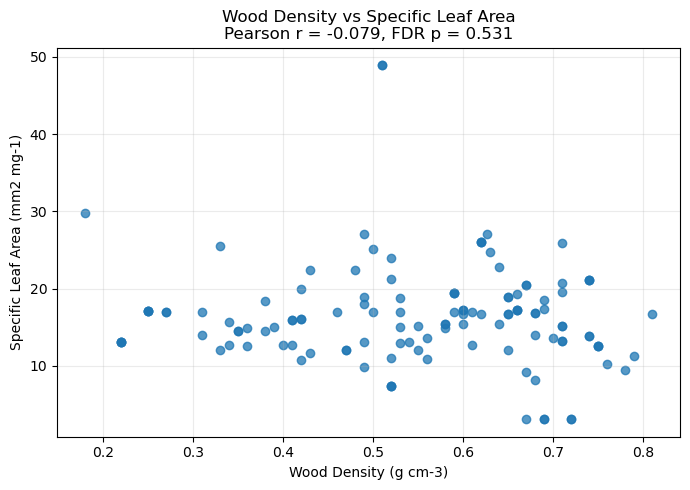

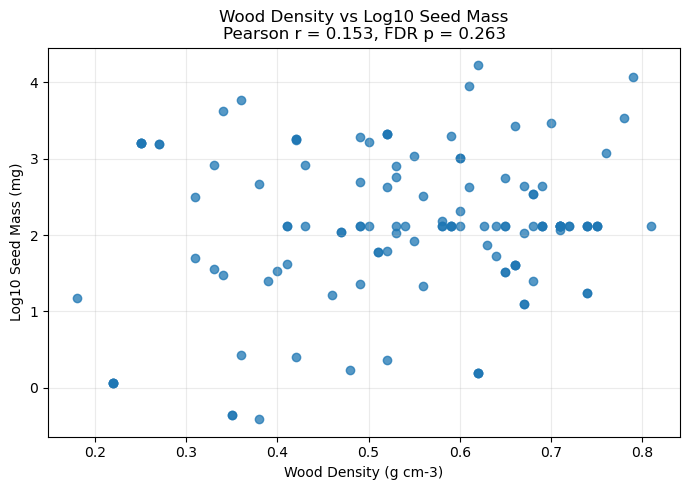

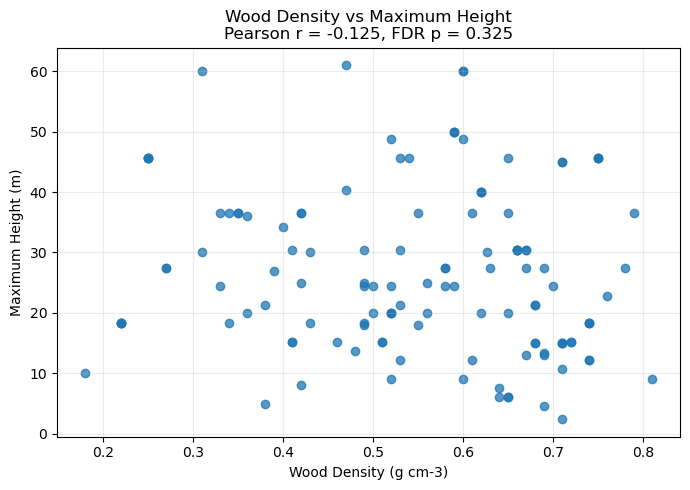

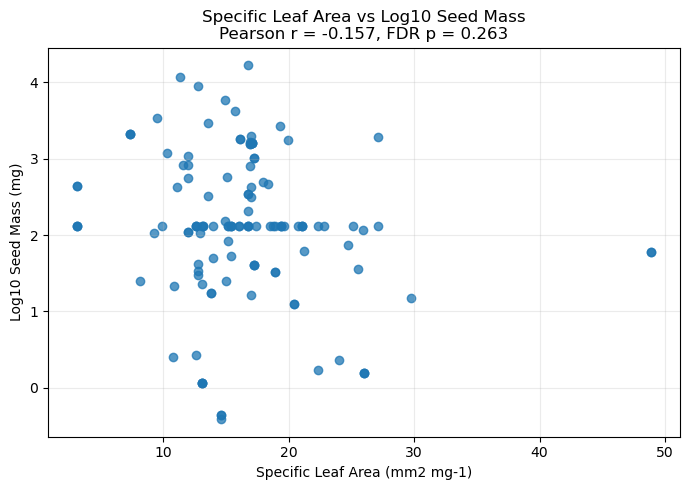

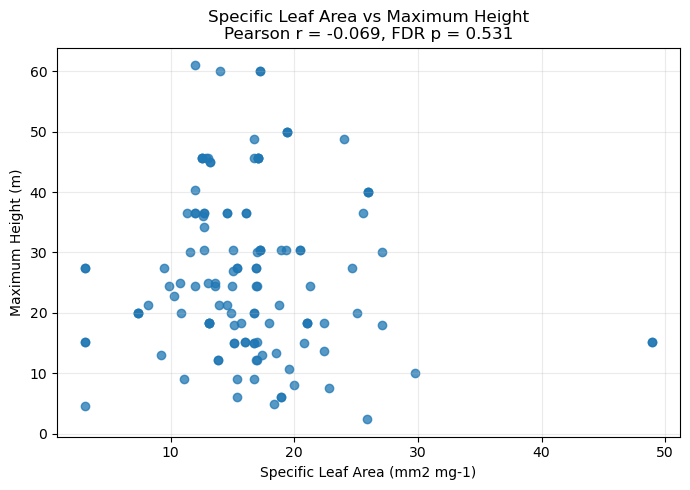

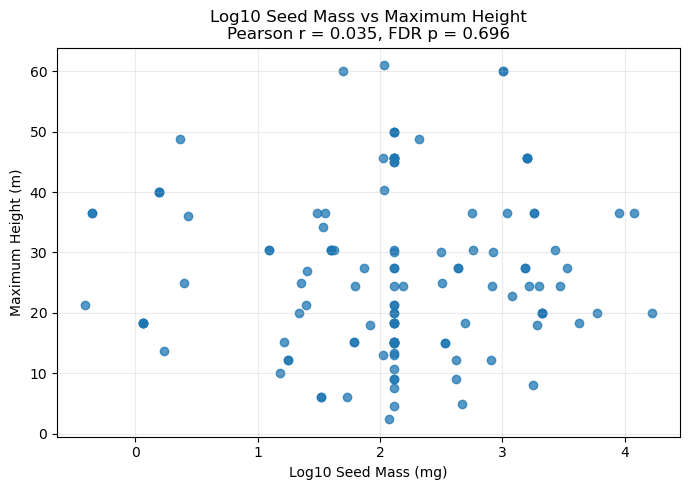


Trait-pair figures created
----------------------------------------------------------------------------------------------------
           Trait_1            Trait_2  Pearson_r  Pearson_p_FDR                                                                                                                                                        Plot_File
      Wood Density Specific Leaf Area    -0.0785         0.5314            C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\trait_pair_plots\omo_trait_pair_wd_analysis_vs_sla_analysis_07C.png
      Wood Density    Log10 Seed Mass     0.1527         0.2634         C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\trait_pair_plots\omo_trait_pair_wd_analysis_vs_log10_seed_mass_07C.png
      Wood Density     Maximum Height    -0.1252         0.3250     C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\trait_pair_plots\omo_trait_pair_wd_analysis_vs

In [11]:
# =============================================================================
# SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS
# Code Block 4.2 — Trait-pair visualization and interpretation-ready summary
# =============================================================================

import matplotlib.pyplot as plt

print("=" * 100)
print("SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS")
print("CODE BLOCK 4.2 — TRAIT-PAIR VISUALIZATION AND INTERPRETATION SUMMARY")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define readable plotting labels
# -----------------------------------------------------------------------------

plot_trait_map = {
    "WD_Analysis": "Wood Density (g cm-3)",
    "SLA_Analysis": "Specific Leaf Area (mm2 mg-1)",
    "Log10_Seed_Mass": "Log10 Seed Mass (mg)",
    "Max_Height_Analysis": "Maximum Height (m)",
}


# -----------------------------------------------------------------------------
# 2. Create pairwise scatterplots
#
# One plot per figure to avoid overcrowding and preserve readability.
# No statistical smoother is imposed because the observed relationships
# are weak and formal tests have already been conducted.
# -----------------------------------------------------------------------------

PAIRPLOT_DIR = FUNCTIONAL_ANALYSIS_DIR / "trait_pair_plots"
PAIRPLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_records = []

for trait1, trait2 in combinations(formal_trait_cols, 2):

    x = correlation_data[trait1].astype(float)
    y = correlation_data[trait2].astype(float)

    result_row = formal_correlations.loc[
        (
            (formal_correlations["Column_1"] == trait1)
            &
            (formal_correlations["Column_2"] == trait2)
        )
        |
        (
            (formal_correlations["Column_1"] == trait2)
            &
            (formal_correlations["Column_2"] == trait1)
        )
    ].iloc[0]

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        x,
        y,
        alpha=0.75
    )

    ax.set_xlabel(plot_trait_map[trait1])
    ax.set_ylabel(plot_trait_map[trait2])

    ax.set_title(
        f"{formal_trait_map[trait1]} vs {formal_trait_map[trait2]}\n"
        f"Pearson r = {result_row['Pearson_r']:.3f}, "
        f"FDR p = {result_row['Pearson_p_FDR']:.3f}"
    )

    ax.grid(alpha=0.25)

    plt.tight_layout()

    safe_name_1 = trait1.lower().replace(" ", "_")
    safe_name_2 = trait2.lower().replace(" ", "_")

    plot_file = (
        PAIRPLOT_DIR
        / f"omo_trait_pair_{safe_name_1}_vs_{safe_name_2}_07C.png"
    )

    fig.savefig(
        plot_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    plot_records.append({
        "Trait_1": formal_trait_map[trait1],
        "Trait_2": formal_trait_map[trait2],
        "Plot_File": str(plot_file),
        "Pearson_r": result_row["Pearson_r"],
        "Pearson_p_FDR": result_row["Pearson_p_FDR"],
        "Spearman_rho": result_row["Spearman_rho"],
        "Spearman_p_FDR": result_row["Spearman_p_FDR"],
    })


trait_pair_plot_manifest = pd.DataFrame(plot_records)

print("\nTrait-pair figures created")
print("-" * 100)

print(
    trait_pair_plot_manifest[
        [
            "Trait_1",
            "Trait_2",
            "Pearson_r",
            "Pearson_p_FDR",
            "Plot_File"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 3. Build ecological interpretation categories
#
# This deliberately avoids calling weak, non-significant correlations
# "trade-offs" or "syndromes".
# -----------------------------------------------------------------------------

def ecological_relation_statement(row):

    r = row["Pearson_r"]
    rho = row["Spearman_rho"]

    strength = row["Pearson_Strength"]
    sig = row["Pearson_FDR_Significant"]

    if sig and strength in ["MODERATE", "STRONG"]:

        if r > 0:
            return "SUPPORTED_POSITIVE_ASSOCIATION"
        else:
            return "SUPPORTED_NEGATIVE_ASSOCIATION"

    elif strength == "WEAK":

        if r > 0:
            return "WEAK_POSITIVE_TENDENCY"
        else:
            return "WEAK_NEGATIVE_TENDENCY"

    else:
        return "NO_MEANINGFUL_PAIRWISE_ASSOCIATION"


formal_correlations["Ecological_Relation_Class"] = (
    formal_correlations.apply(
        ecological_relation_statement,
        axis=1
    )
)


# -----------------------------------------------------------------------------
# 4. Add cautious ecological interpretation text
# -----------------------------------------------------------------------------

interpretation_lookup = {
    (
        "Specific Leaf Area",
        "Log10 Seed Mass"
    ): (
        "Weak negative tendency: taxa with higher SLA may tend to have "
        "slightly smaller seeds, but the relationship is not statistically "
        "supported after FDR correction."
    ),

    (
        "Wood Density",
        "Log10 Seed Mass"
    ): (
        "Weak positive tendency: denser-wood taxa may tend to have "
        "slightly larger seeds, but evidence is insufficient to infer "
        "a robust functional syndrome."
    ),

    (
        "Wood Density",
        "Maximum Height"
    ): (
        "Weak negative tendency: greater wood density is associated with "
        "slightly lower maximum height, but this relationship is not "
        "statistically supported after FDR correction."
    ),

    (
        "Wood Density",
        "Specific Leaf Area"
    ): (
        "No meaningful pairwise association detected between wood density "
        "and SLA."
    ),

    (
        "Specific Leaf Area",
        "Maximum Height"
    ): (
        "No meaningful pairwise association detected between SLA and "
        "maximum height."
    ),

    (
        "Log10 Seed Mass",
        "Maximum Height"
    ): (
        "No meaningful pairwise association detected between seed mass "
        "and maximum height."
    ),
}


def lookup_interpretation(row):

    key = (
        row["Trait_1"],
        row["Trait_2"]
    )

    reverse_key = (
        row["Trait_2"],
        row["Trait_1"]
    )

    if key in interpretation_lookup:
        return interpretation_lookup[key]

    if reverse_key in interpretation_lookup:
        return interpretation_lookup[reverse_key]

    return "No predefined interpretation."


formal_correlations["Ecological_Interpretation"] = (
    formal_correlations.apply(
        lookup_interpretation,
        axis=1
    )
)


# -----------------------------------------------------------------------------
# 5. Interpretation-ready table
# -----------------------------------------------------------------------------

interpretation_table = formal_correlations[
    [
        "Trait_1",
        "Trait_2",
        "Pearson_r",
        "Pearson_p_FDR",
        "Pearson_Strength",
        "Spearman_rho",
        "Spearman_p_FDR",
        "Ecological_Relation_Class",
        "Ecological_Interpretation",
    ]
].copy()

print("\nInterpretation-ready correlation table")
print("-" * 100)

print(
    interpretation_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Overall functional-strategy conclusion
# -----------------------------------------------------------------------------

max_abs_r = formal_correlations["Abs_Pearson_r"].max()
n_fdr_sig = formal_correlations["Pearson_FDR_Significant"].sum()
n_moderate_or_strong = formal_correlations[
    "Pearson_Strength"
].isin(["MODERATE", "STRONG"]).sum()

print("\nOverall functional-strategy diagnostic")
print("-" * 100)

print(f"Maximum absolute Pearson r        : {max_abs_r:.4f}")
print(f"FDR-significant Pearson pairs     : {n_fdr_sig}")
print(f"Moderate/strong Pearson pairs     : {n_moderate_or_strong}")

if (
    max_abs_r < 0.30
    and n_fdr_sig == 0
    and n_moderate_or_strong == 0
):

    overall_strategy_conclusion = (
        "The four measured traits behave largely as independent functional "
        "dimensions within the Omo woody-flora dataset. No strong pairwise "
        "trait syndrome or trade-off is supported."
    )

else:

    overall_strategy_conclusion = (
        "At least one trait pair shows sufficient association to warrant "
        "further functional-strategy interpretation."
    )

print("\nOverall interpretation")
print("-" * 100)
print(overall_strategy_conclusion)


# -----------------------------------------------------------------------------
# 7. Export Section 4.0 interpretation products
# -----------------------------------------------------------------------------

TRAIT_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_correlation_interpretation_07C.csv"
)

TRAIT_PAIR_PLOT_MANIFEST_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_pair_plot_manifest_07C.csv"
)

interpretation_table.to_csv(
    TRAIT_INTERPRETATION_FILE,
    index=False
)

trait_pair_plot_manifest.to_csv(
    TRAIT_PAIR_PLOT_MANIFEST_FILE,
    index=False
)

print("\nSection 4.0 exports")
print("-" * 100)

print(
    f"Interpretation table : "
    f"{TRAIT_INTERPRETATION_FILE}"
)

print(
    f"Plot manifest        : "
    f"{TRAIT_PAIR_PLOT_MANIFEST_FILE}"
)

print(
    f"Trait-pair figures   : "
    f"{PAIRPLOT_DIR}"
)


# -----------------------------------------------------------------------------
# 8. Validation
# -----------------------------------------------------------------------------

block_4_2_checks = {

    "Six pairwise figures recorded":
        len(trait_pair_plot_manifest) == 6,

    "Six interpretation rows":
        len(interpretation_table) == 6,

    "No FDR-significant Pearson correlations":
        formal_correlations[
            "Pearson_FDR_Significant"
        ].sum() == 0,

    "No FDR-significant Spearman correlations":
        formal_correlations[
            "Spearman_FDR_Significant"
        ].sum() == 0,

    "No moderate or strong Pearson correlations":
        formal_correlations[
            "Pearson_Strength"
        ].isin(["MODERATE", "STRONG"]).sum() == 0,

    "All Pearson-Spearman directions consistent":
        formal_correlations[
            "Direction_Consistent"
        ].all(),

    "Maximum absolute Pearson correlation < 0.30":
        formal_correlations[
            "Abs_Pearson_r"
        ].max() < 0.30,
}

print("\n" + "=" * 100)
print("CODE BLOCK 4.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_4_2_checks.items():
    print(
        f"{label:<60}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_4_2_checks.values()
)

print("-" * 100)
print(
    f"Validation checks requiring review : {n_review}"
)


# -----------------------------------------------------------------------------
# 9. Stop before Section 4.0 closure / PCA
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 4.2 COMPLETE")
print("=" * 100)

print(
    "\nTrait-pair relationships have now been visualized and "
    "summarized conservatively."
)

print(
    "No PCA, Euclidean trait distance, CWM, functional-diversity, "
    "habitat, zone, or structural-functional analysis was performed."
)

In [12]:
# =============================================================================
# SECTION 4.0 — TRAIT CORRELATION AND FUNCTIONAL STRATEGY ANALYSIS
# Code Block 4.3 — Formal section closure and export validation
# =============================================================================

print("=" * 100)
print("SECTION 4.0 — FORMAL CLOSURE AND EXPORT VALIDATION")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Reload Section 4.0 exported products
# -----------------------------------------------------------------------------

formal_corr_check = pd.read_csv(
    FORMAL_CORRELATION_FILE
)

interpretation_check = pd.read_csv(
    TRAIT_INTERPRETATION_FILE
)

plot_manifest_check = pd.read_csv(
    TRAIT_PAIR_PLOT_MANIFEST_FILE
)

print("\nReloaded Section 4.0 products")
print("-" * 100)

print(
    f"Formal correlations      : "
    f"{formal_corr_check.shape[0]} rows"
)

print(
    f"Interpretation table     : "
    f"{interpretation_check.shape[0]} rows"
)

print(
    f"Trait-pair plot manifest : "
    f"{plot_manifest_check.shape[0]} rows"
)


# -----------------------------------------------------------------------------
# 2. Confirm six unique trait pairs
# -----------------------------------------------------------------------------

def canonical_pair(row):
    return tuple(sorted([
        str(row["Trait_1"]),
        str(row["Trait_2"])
    ]))

formal_pairs = set(
    formal_corr_check.apply(
        canonical_pair,
        axis=1
    )
)

interpretation_pairs = set(
    interpretation_check.apply(
        canonical_pair,
        axis=1
    )
)

plot_pairs = set(
    plot_manifest_check.apply(
        canonical_pair,
        axis=1
    )
)

print("\nTrait-pair identity audit")
print("-" * 100)

print(f"Formal unique pairs         : {len(formal_pairs)}")
print(f"Interpretation unique pairs : {len(interpretation_pairs)}")
print(f"Plot-manifest unique pairs  : {len(plot_pairs)}")

print(
    f"Pair sets identical         : "
    f"{formal_pairs == interpretation_pairs == plot_pairs}"
)


# -----------------------------------------------------------------------------
# 3. Confirm statistical result consistency after export
# -----------------------------------------------------------------------------

export_sig_pearson = (
    formal_corr_check["Pearson_p_FDR"] < 0.05
).sum()

export_sig_spearman = (
    formal_corr_check["Spearman_p_FDR"] < 0.05
).sum()

max_abs_pearson_export = (
    formal_corr_check["Pearson_r"]
    .abs()
    .max()
)

max_abs_spearman_export = (
    formal_corr_check["Spearman_rho"]
    .abs()
    .max()
)

print("\nStatistical export audit")
print("-" * 100)

print(
    f"Pearson FDR-significant pairs  : "
    f"{export_sig_pearson}"
)

print(
    f"Spearman FDR-significant pairs : "
    f"{export_sig_spearman}"
)

print(
    f"Maximum |Pearson r|            : "
    f"{max_abs_pearson_export:.4f}"
)

print(
    f"Maximum |Spearman rho|         : "
    f"{max_abs_spearman_export:.4f}"
)


# -----------------------------------------------------------------------------
# 4. Confirm figures exist
# -----------------------------------------------------------------------------

plot_manifest_check["Plot_Exists"] = (
    plot_manifest_check["Plot_File"]
    .apply(lambda p: Path(p).exists())
)

n_existing_plots = int(
    plot_manifest_check["Plot_Exists"].sum()
)

print("\nTrait-pair figure integrity")
print("-" * 100)

print(
    f"Figures recorded : {len(plot_manifest_check)}"
)

print(
    f"Figures existing : {n_existing_plots}"
)

if not plot_manifest_check["Plot_Exists"].all():
    print("\nMissing figures")
    print("-" * 100)

    print(
        plot_manifest_check.loc[
            ~plot_manifest_check["Plot_Exists"],
            ["Trait_1", "Trait_2", "Plot_File"]
        ].to_string(index=False)
    )


# -----------------------------------------------------------------------------
# 5. Create concise Section 4.0 summary table
# -----------------------------------------------------------------------------

section_4_summary = pd.DataFrame([
    {
        "Metric": "Number of trait pairs",
        "Value": 6
    },
    {
        "Metric": "Pearson FDR-significant pairs",
        "Value": int(export_sig_pearson)
    },
    {
        "Metric": "Spearman FDR-significant pairs",
        "Value": int(export_sig_spearman)
    },
    {
        "Metric": "Maximum absolute Pearson correlation",
        "Value": float(max_abs_pearson_export)
    },
    {
        "Metric": "Maximum absolute Spearman correlation",
        "Value": float(max_abs_spearman_export)
    },
    {
        "Metric": "Moderate or strong Pearson associations",
        "Value": int(
            formal_corr_check["Pearson_Strength"]
            .isin(["MODERATE", "STRONG"])
            .sum()
        )
    },
    {
        "Metric": "Trait-pair figures",
        "Value": int(len(plot_manifest_check))
    },
])

SECTION_4_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_section_4_trait_correlation_summary_07C.csv"
)

section_4_summary.to_csv(
    SECTION_4_SUMMARY_FILE,
    index=False
)

print("\nSection 4.0 summary")
print("-" * 100)

print(
    section_4_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 6. Final Section 4.0 validation
# -----------------------------------------------------------------------------

section_4_checks = {

    "Six formal trait pairs retained":
        len(formal_corr_check) == 6,

    "Six interpretation rows retained":
        len(interpretation_check) == 6,

    "Six plot-manifest rows retained":
        len(plot_manifest_check) == 6,

    "Trait-pair sets match exactly":
        formal_pairs == interpretation_pairs == plot_pairs,

    "All six trait-pair figures exist":
        n_existing_plots == 6,

    "No Pearson FDR-significant associations":
        export_sig_pearson == 0,

    "No Spearman FDR-significant associations":
        export_sig_spearman == 0,

    "Maximum absolute Pearson correlation < 0.30":
        max_abs_pearson_export < 0.30,

    "No moderate or strong Pearson associations":
        formal_corr_check[
            "Pearson_Strength"
        ].isin(
            ["MODERATE", "STRONG"]
        ).sum() == 0,
}

print("\n" + "=" * 100)
print("SECTION 4.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_4_checks.items():
    print(
        f"{label:<62}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_4_checks.values()
)

print("-" * 100)
print(
    f"Validation checks requiring review : {n_failed}"
)

if n_failed == 0:
    print(
        "SECTION 4.0 STATUS                  : FORMALLY CLOSED"
    )
else:
    print(
        "SECTION 4.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 7. Final ecological statement for Section 4.0
# -----------------------------------------------------------------------------

print("\nFinal Section 4.0 ecological statement")
print("-" * 100)

print(
    "Across the 126 taxa with complete four-trait profiles, "
    "pairwise relationships among Wood Density, Specific Leaf Area, "
    "log10 Seed Mass, and Maximum Height were weak or negligible."
)

print(
    "No correlation remained significant after FDR correction, "
    "and no moderate or strong pairwise association was detected."
)

print(
    "Accordingly, the four traits are retained as complementary "
    "functional dimensions for subsequent multivariate ordination."
)

print("\n" + "=" * 100)
print("CODE BLOCK 4.3 COMPLETE")
print("=" * 100)

SECTION 4.0 — FORMAL CLOSURE AND EXPORT VALIDATION

Reloaded Section 4.0 products
----------------------------------------------------------------------------------------------------
Formal correlations      : 6 rows
Interpretation table     : 6 rows
Trait-pair plot manifest : 6 rows

Trait-pair identity audit
----------------------------------------------------------------------------------------------------
Formal unique pairs         : 6
Interpretation unique pairs : 6
Plot-manifest unique pairs  : 6
Pair sets identical         : True

Statistical export audit
----------------------------------------------------------------------------------------------------
Pearson FDR-significant pairs  : 0
Spearman FDR-significant pairs : 0
Maximum |Pearson r|            : 0.1566
Maximum |Spearman rho|         : 0.1564

Trait-pair figure integrity
----------------------------------------------------------------------------------------------------
Figures recorded : 6
Figures existing : 6

Sectio

In [13]:
# =============================================================================
# SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION
# Code Block 5.1 — PCA variance structure, loadings and species scores
# =============================================================================

from sklearn.decomposition import PCA

print("=" * 100)
print("SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION")
print("CODE BLOCK 5.1 — PCA VARIANCE STRUCTURE, LOADINGS AND SPECIES SCORES")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define authoritative PCA input
# -----------------------------------------------------------------------------

pca_input = trait_matrix_numeric_4trait.copy()

print("\nAuthoritative PCA input")
print("-" * 100)

print(f"Taxa   : {pca_input.shape[0]}")
print(f"Traits : {pca_input.shape[1]}")

print("\nTrait columns")
for col in pca_input.columns:
    print(f"  {col}")


# -----------------------------------------------------------------------------
# 2. PCA input integrity
# -----------------------------------------------------------------------------

pca_values = pca_input.to_numpy(dtype=float)

print("\nPCA input integrity")
print("-" * 100)

print(
    f"Missing values       : "
    f"{np.isnan(pca_values).sum()}"
)

print(
    f"Infinite values      : "
    f"{np.isinf(pca_values).sum()}"
)

print(
    f"All values finite    : "
    f"{np.isfinite(pca_values).all()}"
)

print(
    f"Matrix rank          : "
    f"{np.linalg.matrix_rank(pca_values)}"
)

print(
    f"Maximum possible rank: "
    f"{pca_input.shape[1]}"
)


# -----------------------------------------------------------------------------
# 3. Confirm standardization before PCA
# -----------------------------------------------------------------------------

pca_input_summary = pd.DataFrame({
    "Trait": pca_input.columns,
    "Mean": pca_input.mean().values,
    "SD": pca_input.std(ddof=1).values
})

print("\nPCA input standardization audit")
print("-" * 100)

print(
    pca_input_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Fit full PCA
#
# Four traits -> four principal components.
# No additional scaling is performed here.
# -----------------------------------------------------------------------------

pca_model = PCA(
    n_components=4
)

pca_scores_array = pca_model.fit_transform(
    pca_values
)


# -----------------------------------------------------------------------------
# 5. Eigenvalues and explained variance
# -----------------------------------------------------------------------------

pca_variance = pd.DataFrame({
    "PC": [
        f"PC{i}"
        for i in range(1, 5)
    ],
    "Eigenvalue": pca_model.explained_variance_,
    "Explained_Variance_Ratio":
        pca_model.explained_variance_ratio_,
    "Explained_Variance_Percent":
        pca_model.explained_variance_ratio_ * 100,
})

pca_variance["Cumulative_Variance_Percent"] = (
    pca_variance[
        "Explained_Variance_Percent"
    ].cumsum()
)

print("\nPCA variance structure")
print("-" * 100)

print(
    pca_variance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 6. PCA component coefficients
#
# sklearn components_ gives unit eigenvectors.
# Rows = PCs
# Columns = original standardized traits.
# -----------------------------------------------------------------------------

pca_component_coefficients = pd.DataFrame(
    pca_model.components_.T,
    index=pca_input.columns,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4"
    ]
)

print("\nPCA component coefficients (eigenvectors)")
print("-" * 100)

print(
    pca_component_coefficients.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 7. PCA variable loadings
#
# Loadings = eigenvector coefficient × sqrt(eigenvalue)
#
# These represent correlations between standardized original traits
# and principal components.
# -----------------------------------------------------------------------------

pca_loadings = (
    pca_model.components_.T
    *
    np.sqrt(
        pca_model.explained_variance_
    )
)

pca_loadings = pd.DataFrame(
    pca_loadings,
    index=pca_input.columns,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4"
    ]
)

print("\nPCA trait loadings")
print("-" * 100)

print(
    pca_loadings.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Absolute loadings for interpretation
# -----------------------------------------------------------------------------

absolute_loadings = (
    pca_loadings
    .abs()
)

print("\nAbsolute PCA trait loadings")
print("-" * 100)

print(
    absolute_loadings.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Dominant trait per principal component
# -----------------------------------------------------------------------------

dominant_trait_records = []

for pc in pca_loadings.columns:

    dominant_trait = (
        absolute_loadings[pc]
        .idxmax()
    )

    dominant_loading = (
        pca_loadings.loc[
            dominant_trait,
            pc
        ]
    )

    dominant_trait_records.append({
        "PC": pc,
        "Dominant_Trait": dominant_trait,
        "Loading": dominant_loading,
        "Absolute_Loading":
            abs(dominant_loading)
    })

dominant_traits = pd.DataFrame(
    dominant_trait_records
)

print("\nDominant trait by principal component")
print("-" * 100)

print(
    dominant_traits.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Species PCA scores
# -----------------------------------------------------------------------------

pca_species_scores = pd.DataFrame(
    pca_scores_array,
    index=pca_input.index,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4"
    ]
)

pca_species_scores.index.name = (
    "Canonical_Species"
)

print("\nSpecies PCA score preview")
print("-" * 100)

print(
    pca_species_scores
    .head(10)
    .to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Species-score descriptive statistics
# -----------------------------------------------------------------------------

pca_score_summary = (
    pca_species_scores
    .describe()
    .T
)

print("\nSpecies PCA score summary")
print("-" * 100)

print(
    pca_score_summary.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Confirm PC scores are centered and orthogonal
# -----------------------------------------------------------------------------

score_means = (
    pca_species_scores.mean()
)

score_correlations = (
    pca_species_scores.corr()
)

print("\nPCA score centering")
print("-" * 100)

print(
    score_means.to_string(
        float_format=lambda x: f"{x:.10f}"
    )
)

print("\nPCA score correlation matrix")
print("-" * 100)

print(
    score_correlations.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 13. Variance reconstruction diagnostic
#
# Because four standardized variables are used with sample SD = 1,
# total variance should equal 4.
# -----------------------------------------------------------------------------

total_input_variance = (
    pca_input.var(ddof=1).sum()
)

total_pca_variance = (
    pca_model.explained_variance_.sum()
)

print("\nVariance reconstruction")
print("-" * 100)

print(
    f"Total standardized input variance : "
    f"{total_input_variance:.8f}"
)

print(
    f"Total PCA eigenvalue variance     : "
    f"{total_pca_variance:.8f}"
)

print(
    f"Difference                        : "
    f"{abs(total_input_variance - total_pca_variance):.12f}"
)


# -----------------------------------------------------------------------------
# 14. Reconstruction from all four PCs
# -----------------------------------------------------------------------------

reconstructed_values = (
    pca_model.inverse_transform(
        pca_scores_array
    )
)

reconstruction_error = (
    np.abs(
        reconstructed_values
        - pca_values
    )
)

max_reconstruction_error = (
    reconstruction_error.max()
)

mean_reconstruction_error = (
    reconstruction_error.mean()
)

print("\nFull four-component reconstruction")
print("-" * 100)

print(
    f"Maximum absolute reconstruction error : "
    f"{max_reconstruction_error:.12e}"
)

print(
    f"Mean absolute reconstruction error    : "
    f"{mean_reconstruction_error:.12e}"
)


# -----------------------------------------------------------------------------
# 15. Cumulative variance thresholds
# -----------------------------------------------------------------------------

threshold_records = []

for threshold in [50, 60, 70, 80, 90, 95]:

    pcs_required = int(
        np.argmax(
            pca_variance[
                "Cumulative_Variance_Percent"
            ].values >= threshold
        ) + 1
    )

    achieved_variance = (
        pca_variance.loc[
            pcs_required - 1,
            "Cumulative_Variance_Percent"
        ]
    )

    threshold_records.append({
        "Target_Variance_Percent": threshold,
        "PCs_Required": pcs_required,
        "Achieved_Variance_Percent":
            achieved_variance
    })

variance_thresholds = pd.DataFrame(
    threshold_records
)

print("\nCumulative variance thresholds")
print("-" * 100)

print(
    variance_thresholds.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 16. Kaiser criterion diagnostic
#
# For PCA of standardized variables, eigenvalue > 1 is commonly used
# as a descriptive dimensionality diagnostic.
# It is not used alone to determine the final ecological representation.
# -----------------------------------------------------------------------------

n_kaiser = int(
    (
        pca_variance["Eigenvalue"] > 1.0
    ).sum()
)

print("\nKaiser eigenvalue diagnostic")
print("-" * 100)

print(
    f"Components with eigenvalue > 1 : "
    f"{n_kaiser}"
)

print(
    "NOTE: The Kaiser criterion is treated as descriptive only; "
    "variance retention, trait loadings, ecological interpretability, "
    "and downstream functional-diversity requirements will also be considered."
)


# -----------------------------------------------------------------------------
# 17. PCA integrity validation
# -----------------------------------------------------------------------------

off_diagonal_corr = (
    score_correlations.values
    - np.eye(4)
)

pca_checks = {

    "PCA input has 126 taxa":
        pca_input.shape[0] == 126,

    "PCA input has four traits":
        pca_input.shape[1] == 4,

    "PCA input contains no missing values":
        np.isnan(pca_values).sum() == 0,

    "PCA input contains no infinite values":
        np.isfinite(pca_values).all(),

    "PCA input matrix is full rank":
        np.linalg.matrix_rank(
            pca_values
        ) == 4,

    "Four principal components produced":
        pca_scores_array.shape == (126, 4),

    "Explained variance sums to 100%":
        np.isclose(
            pca_model
            .explained_variance_ratio_
            .sum(),
            1.0,
            atol=1e-12
        ),

    "Eigenvalues sum to total input variance":
        np.isclose(
            total_input_variance,
            total_pca_variance,
            atol=1e-12
        ),

    "PC scores centered approximately at zero":
        np.allclose(
            score_means.values,
            np.zeros(4),
            atol=1e-12
        ),

    "PC scores mutually orthogonal":
        np.allclose(
            off_diagonal_corr,
            np.zeros((4, 4)),
            atol=1e-12
        ),

    "Full PCA reconstructs original matrix":
        max_reconstruction_error < 1e-10,
}


print("\n" + "=" * 100)
print("CODE BLOCK 5.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in pca_checks.items():
    print(
        f"{label:<62}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in pca_checks.values()
)

print("-" * 100)
print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 18. Stop before PCA ecological interpretation
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("CODE BLOCK 5.1 COMPLETE")
print("=" * 100)

print(
    "\nThe complete four-component PCA has been fitted and mathematically "
    "validated."
)

print(
    "No decision on retained PCA dimensionality has yet been locked."
)

print(
    "No PCA biplot, ecological axis interpretation, habitat/zone comparison, "
    "functional-diversity calculation, or community-weighted analysis "
    "was performed."
)

SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION
CODE BLOCK 5.1 — PCA VARIANCE STRUCTURE, LOADINGS AND SPECIES SCORES

Authoritative PCA input
----------------------------------------------------------------------------------------------------
Taxa   : 126
Traits : 4

Trait columns
  Z_WD
  Z_SLA
  Z_Log10_Seed_Mass
  Z_Max_Height

PCA input integrity
----------------------------------------------------------------------------------------------------
Missing values       : 0
Infinite values      : 0
All values finite    : True
Matrix rank          : 4
Maximum possible rank: 4

PCA input standardization audit
----------------------------------------------------------------------------------------------------
            Trait        Mean         SD
             Z_WD  0.00000000 1.00000000
            Z_SLA -0.00000000 1.00000000
Z_Log10_Seed_Mass  0.00000000 1.00000000
     Z_Max_Height -0.00000000 1.00000000

PCA variance structure
-------------------------------------------------------

SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION
CODE BLOCK 5.2 — PCA DIMENSIONALITY AND ECOLOGICAL AXIS INTERPRETATION

Formal PCA dimensionality strategy
----------------------------------------------------------------------------------------------------
                           Purpose                Representation  N_Dimensions  Variance_Retained_Percent Decision
  Primary ordination visualization                       PC1-PC2             2                    59.2881   RETAIN
Extended ecological interpretation                       PC1-PC3             3                    80.3888   RETAIN
Distance-based functional analyses FULL_STANDARDIZED_TRAIT_SPACE             4                   100.0000   RETAIN

Ranked PCA loadings
----------------------------------------------------------------------------------------------------

PC1
             Trait  Loading  Absolute_Loading  Rank_Within_PC
   Log10 Seed Mass   0.7165            0.7165          1.0000
      Wood Density   0.6184      

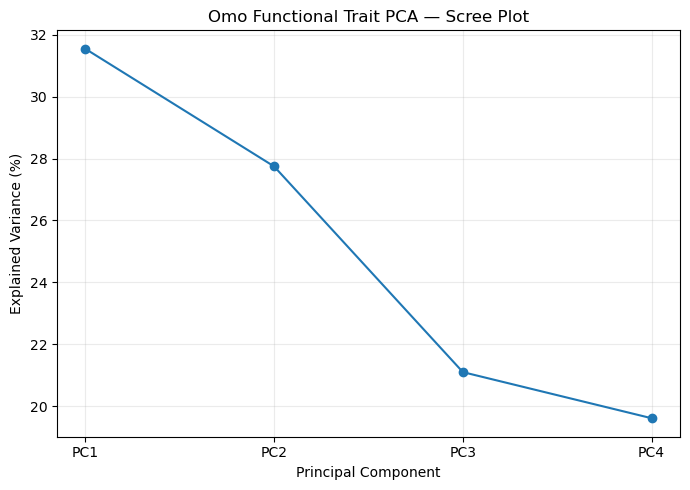


Scree plot
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures\omo_functional_traits_pca_scree_07C.png


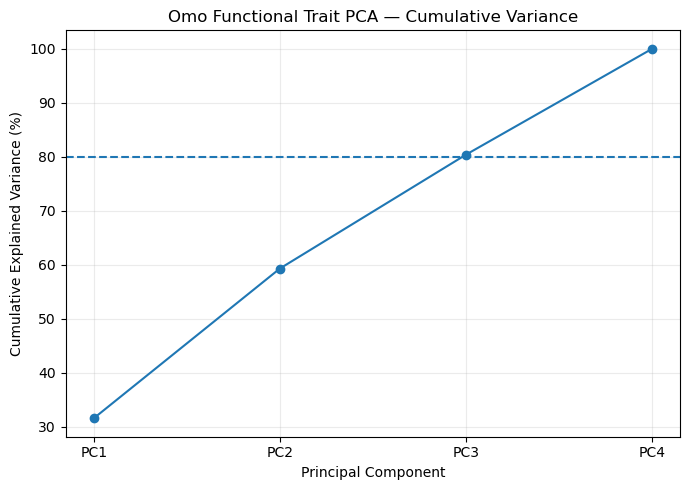


Cumulative variance plot
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures\omo_functional_traits_pca_cumulative_variance_07C.png


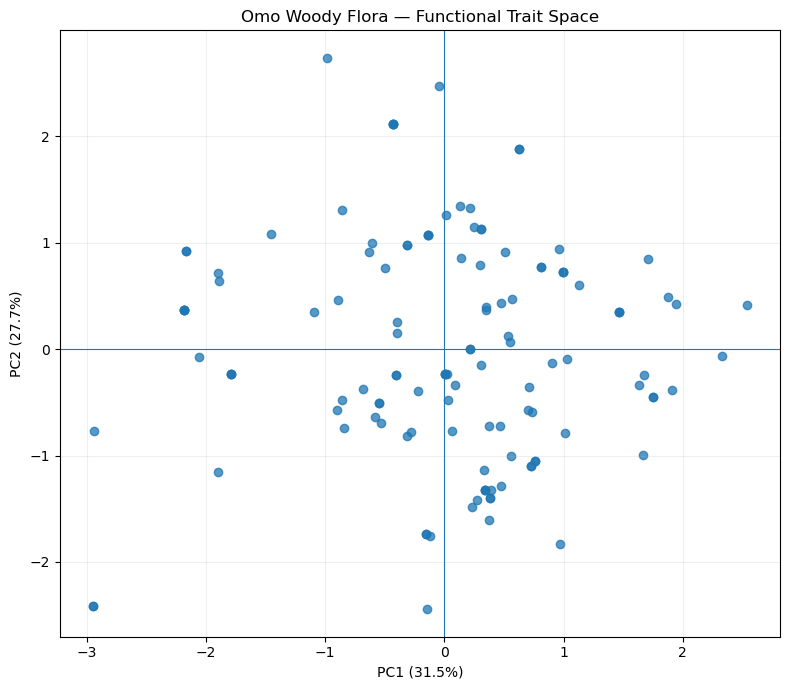


PC1–PC2 species ordination
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures\omo_functional_traits_pca_PC1_PC2_species_ordination_07C.png


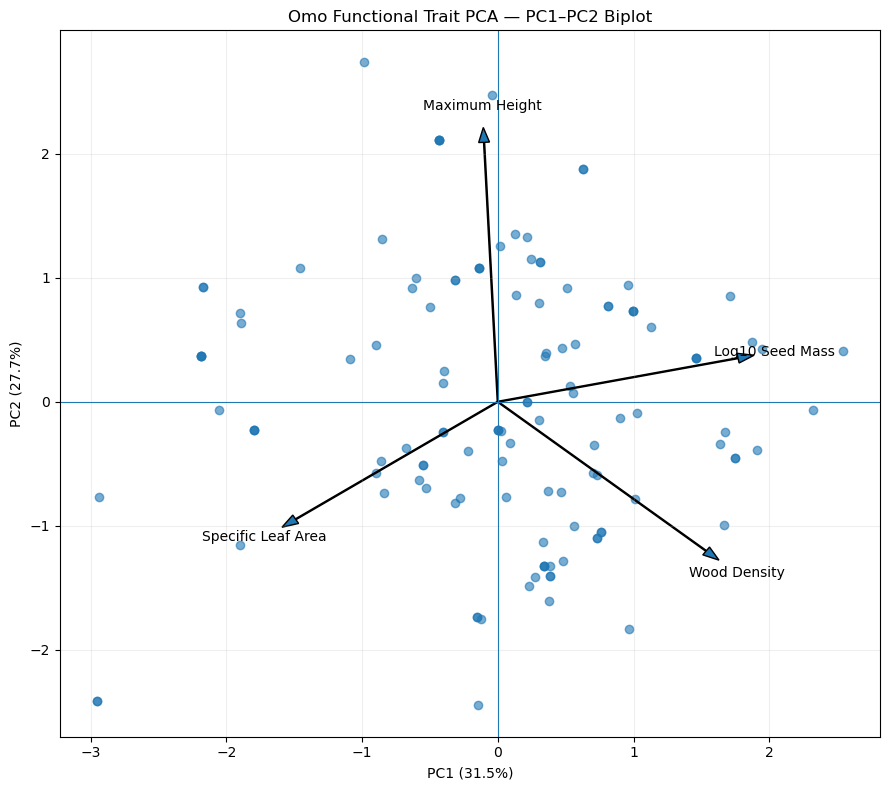


PC1–PC2 biplot
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures\omo_functional_traits_pca_PC1_PC2_biplot_07C.png


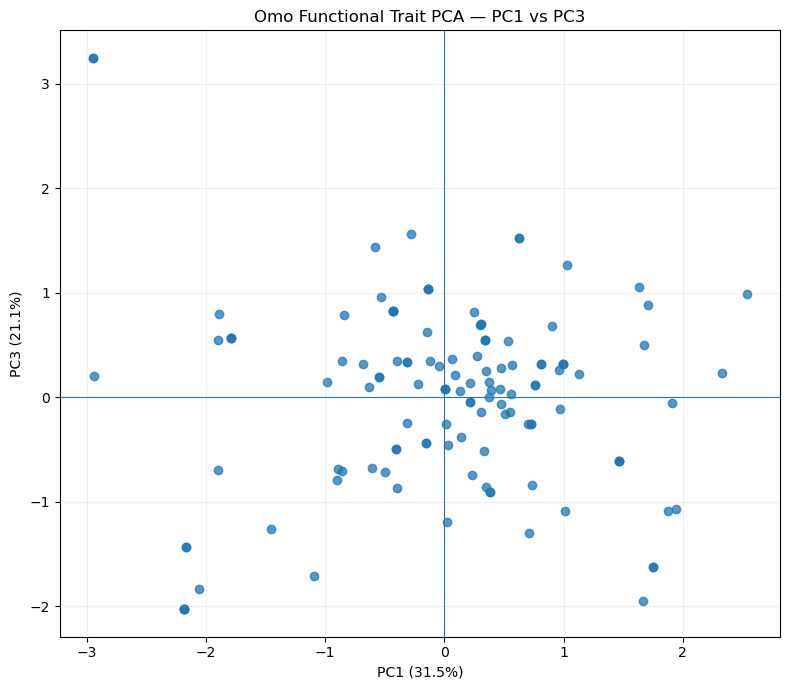


PC1–PC3 ordination
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures\omo_functional_traits_pca_PC1_PC3_species_ordination_07C.png

PCA analytical exports
----------------------------------------------------------------------------------------------------
Variance structure       : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_pca_variance_07C.csv
Trait loadings           : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_pca_loadings_07C.csv
Species scores           : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_pca_species_scores_07C.csv
Axis interpretation      : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_pca_ax

In [14]:
# =============================================================================
# SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION
# Code Block 5.2 — PCA dimensionality decision, axis interpretation,
#                  scree plot and PC1–PC2 biplot
# =============================================================================

import matplotlib.pyplot as plt

print("=" * 100)
print("SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION")
print("CODE BLOCK 5.2 — PCA DIMENSIONALITY AND ECOLOGICAL AXIS INTERPRETATION")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Formal dimensionality strategy
# -----------------------------------------------------------------------------

pca_dimensionality_strategy = pd.DataFrame([
    {
        "Purpose": "Primary ordination visualization",
        "Representation": "PC1-PC2",
        "N_Dimensions": 2,
        "Variance_Retained_Percent":
            pca_variance.loc[1, "Cumulative_Variance_Percent"],
        "Decision": "RETAIN"
    },
    {
        "Purpose": "Extended ecological interpretation",
        "Representation": "PC1-PC3",
        "N_Dimensions": 3,
        "Variance_Retained_Percent":
            pca_variance.loc[2, "Cumulative_Variance_Percent"],
        "Decision": "RETAIN"
    },
    {
        "Purpose": "Distance-based functional analyses",
        "Representation": "FULL_STANDARDIZED_TRAIT_SPACE",
        "N_Dimensions": 4,
        "Variance_Retained_Percent": 100.0,
        "Decision": "RETAIN"
    },
])

print("\nFormal PCA dimensionality strategy")
print("-" * 100)

print(
    pca_dimensionality_strategy.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 2. Human-readable trait names for PCA interpretation
# -----------------------------------------------------------------------------

pca_trait_labels = {
    "Z_WD": "Wood Density",
    "Z_SLA": "Specific Leaf Area",
    "Z_Log10_Seed_Mass": "Log10 Seed Mass",
    "Z_Max_Height": "Maximum Height",
}


# -----------------------------------------------------------------------------
# 3. Rank trait contributions to each principal component
#
# NOTE:
# PCA axis signs are arbitrary. Therefore interpretation focuses primarily
# on magnitude and relative opposition among traits, not on absolute sign.
# -----------------------------------------------------------------------------

loading_long_records = []

for pc in pca_loadings.columns:

    for trait in pca_loadings.index:

        loading = pca_loadings.loc[trait, pc]

        loading_long_records.append({
            "PC": pc,
            "Trait_Code": trait,
            "Trait": pca_trait_labels[trait],
            "Loading": loading,
            "Absolute_Loading": abs(loading),
        })

pca_loading_long = pd.DataFrame(
    loading_long_records
)

pca_loading_long["Rank_Within_PC"] = (
    pca_loading_long
    .groupby("PC")["Absolute_Loading"]
    .rank(
        method="first",
        ascending=False
    )
)

print("\nRanked PCA loadings")
print("-" * 100)

for pc in ["PC1", "PC2", "PC3", "PC4"]:

    temp = (
        pca_loading_long[
            pca_loading_long["PC"] == pc
        ]
        .sort_values(
            "Absolute_Loading",
            ascending=False
        )
    )

    print(f"\n{pc}")
    print(
        temp[
            [
                "Trait",
                "Loading",
                "Absolute_Loading",
                "Rank_Within_PC"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 4. Construct cautious axis interpretations
#
# These statements describe the mathematical loading structure.
# They do not imply statistically established ecological trade-offs.
# -----------------------------------------------------------------------------

axis_interpretation = pd.DataFrame([
    {
        "PC": "PC1",
        "Explained_Variance_Percent":
            pca_variance.loc[
                pca_variance["PC"] == "PC1",
                "Explained_Variance_Percent"
            ].iloc[0],
        "Primary_Traits":
            "Seed Mass, Wood Density, Specific Leaf Area",
        "Interpretation":
            (
                "A composite seed-size / tissue-strategy axis. "
                "Seed Mass and Wood Density load in one direction, "
                "while SLA loads in the opposing direction. "
                "Maximum Height contributes very little to PC1."
            )
    },
    {
        "PC": "PC2",
        "Explained_Variance_Percent":
            pca_variance.loc[
                pca_variance["PC"] == "PC2",
                "Explained_Variance_Percent"
            ].iloc[0],
        "Primary_Traits":
            "Maximum Height, Wood Density, Specific Leaf Area",
        "Interpretation":
            (
                "Primarily a stature axis dominated by Maximum Height, "
                "with secondary contributions from Wood Density and SLA."
            )
    },
    {
        "PC": "PC3",
        "Explained_Variance_Percent":
            pca_variance.loc[
                pca_variance["PC"] == "PC3",
                "Explained_Variance_Percent"
            ].iloc[0],
        "Primary_Traits":
            "Specific Leaf Area, Seed Mass",
        "Interpretation":
            (
                "A secondary leaf-economics axis dominated by SLA, "
                "with additional contribution from Seed Mass."
            )
    },
    {
        "PC": "PC4",
        "Explained_Variance_Percent":
            pca_variance.loc[
                pca_variance["PC"] == "PC4",
                "Explained_Variance_Percent"
            ].iloc[0],
        "Primary_Traits":
            "Wood Density, Seed Mass, Maximum Height",
        "Interpretation":
            (
                "Residual multivariate variation involving primarily "
                "Wood Density, Seed Mass, and Maximum Height."
            )
    },
])

print("\nInterpretation-ready PCA axis table")
print("-" * 100)

print(
    axis_interpretation.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Identify species occupying extreme positions on each PC
#
# Useful for checking whether ecological interpretation is consistent
# with actual taxa occupying the ends of the axes.
# -----------------------------------------------------------------------------

extreme_species_records = []

N_EXTREME = 5

for pc in ["PC1", "PC2", "PC3", "PC4"]:

    ordered = (
        pca_species_scores[pc]
        .sort_values()
    )

    low_species = ordered.head(
        N_EXTREME
    )

    high_species = ordered.tail(
        N_EXTREME
    ).sort_values(
        ascending=False
    )

    for species, score in low_species.items():

        extreme_species_records.append({
            "PC": pc,
            "Extreme_End": "LOW",
            "Canonical_Species": species,
            "PC_Score": score
        })

    for species, score in high_species.items():

        extreme_species_records.append({
            "PC": pc,
            "Extreme_End": "HIGH",
            "Canonical_Species": species,
            "PC_Score": score
        })

pca_extreme_species = pd.DataFrame(
    extreme_species_records
)

print("\nSpecies occupying PCA extremes")
print("-" * 100)

for pc in ["PC1", "PC2", "PC3", "PC4"]:

    print(f"\n{pc}")

    print(
        pca_extreme_species[
            pca_extreme_species["PC"] == pc
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 6. Add original trait values to extreme-species table
# -----------------------------------------------------------------------------

extreme_species_traits = (
    pca_extreme_species
    .merge(
        complete_trait_data,
        on="Canonical_Species",
        how="left",
        validate="many_to_one"
    )
)

print("\nPCA extremes with functional traits — preview")
print("-" * 100)

print(
    extreme_species_traits.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Scree plot
# -----------------------------------------------------------------------------

PCA_FIGURE_DIR = (
    FUNCTIONAL_ANALYSIS_DIR
    / "pca_figures"
)

PCA_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SCREE_FILE = (
    PCA_FIGURE_DIR
    / "omo_functional_traits_pca_scree_07C.png"
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    pca_variance["PC"],
    pca_variance["Explained_Variance_Percent"],
    marker="o"
)

ax.set_xlabel(
    "Principal Component"
)

ax.set_ylabel(
    "Explained Variance (%)"
)

ax.set_title(
    "Omo Functional Trait PCA — Scree Plot"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

fig.savefig(
    SCREE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nScree plot")
print("-" * 100)
print(SCREE_FILE)


# -----------------------------------------------------------------------------
# 8. Cumulative explained variance plot
# -----------------------------------------------------------------------------

CUMULATIVE_FILE = (
    PCA_FIGURE_DIR
    / "omo_functional_traits_pca_cumulative_variance_07C.png"
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    pca_variance["PC"],
    pca_variance["Cumulative_Variance_Percent"],
    marker="o"
)

ax.axhline(
    80,
    linestyle="--"
)

ax.set_xlabel(
    "Principal Component"
)

ax.set_ylabel(
    "Cumulative Explained Variance (%)"
)

ax.set_title(
    "Omo Functional Trait PCA — Cumulative Variance"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nCumulative variance plot")
print("-" * 100)
print(CUMULATIVE_FILE)


# -----------------------------------------------------------------------------
# 9. PC1–PC2 species ordination
# -----------------------------------------------------------------------------

PC12_FILE = (
    PCA_FIGURE_DIR
    / "omo_functional_traits_pca_PC1_PC2_species_ordination_07C.png"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    pca_species_scores["PC1"],
    pca_species_scores["PC2"],
    alpha=0.75
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    f"PC1 ({pca_variance.loc[0, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca_variance.loc[1, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_title(
    "Omo Woody Flora — Functional Trait Space"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

fig.savefig(
    PC12_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nPC1–PC2 species ordination")
print("-" * 100)
print(PC12_FILE)


# -----------------------------------------------------------------------------
# 10. PC1–PC2 biplot
#
# Loading vectors are scaled for visual display only.
# Their directions are meaningful; displayed vector lengths are graphical.
# -----------------------------------------------------------------------------

PC12_BIPLOT_FILE = (
    PCA_FIGURE_DIR
    / "omo_functional_traits_pca_PC1_PC2_biplot_07C.png"
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

ax.scatter(
    pca_species_scores["PC1"],
    pca_species_scores["PC2"],
    alpha=0.60
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)


# Scaling factor for visible arrows
score_extent = max(
    abs(pca_species_scores["PC1"]).max(),
    abs(pca_species_scores["PC2"]).max()
)

loading_extent = max(
    abs(pca_loadings["PC1"]).max(),
    abs(pca_loadings["PC2"]).max()
)

arrow_scale = (
    0.75
    * score_extent
    / loading_extent
)

for trait in pca_loadings.index:

    x_loading = (
        pca_loadings.loc[
            trait,
            "PC1"
        ]
        * arrow_scale
    )

    y_loading = (
        pca_loadings.loc[
            trait,
            "PC2"
        ]
        * arrow_scale
    )

    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        width=0.008,
        head_width=0.08,
        length_includes_head=True
    )

    ax.text(
        x_loading * 1.08,
        y_loading * 1.08,
        pca_trait_labels[trait],
        ha="center",
        va="center"
    )

ax.set_xlabel(
    f"PC1 ({pca_variance.loc[0, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca_variance.loc[1, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_title(
    "Omo Functional Trait PCA — PC1–PC2 Biplot"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

fig.savefig(
    PC12_BIPLOT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nPC1–PC2 biplot")
print("-" * 100)
print(PC12_BIPLOT_FILE)


# -----------------------------------------------------------------------------
# 11. PC1–PC3 ordination
#
# PC1–PC3 together do not equal 80.39%;
# the first THREE PCs cumulatively explain 80.39%.
# This plot is therefore supplementary rather than a replacement
# for the full three-dimensional interpretation.
# -----------------------------------------------------------------------------

PC13_FILE = (
    PCA_FIGURE_DIR
    / "omo_functional_traits_pca_PC1_PC3_species_ordination_07C.png"
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    pca_species_scores["PC1"],
    pca_species_scores["PC3"],
    alpha=0.75
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    f"PC1 ({pca_variance.loc[0, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_ylabel(
    f"PC3 ({pca_variance.loc[2, 'Explained_Variance_Percent']:.1f}%)"
)

ax.set_title(
    "Omo Functional Trait PCA — PC1 vs PC3"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()

fig.savefig(
    PC13_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nPC1–PC3 ordination")
print("-" * 100)
print(PC13_FILE)


# -----------------------------------------------------------------------------
# 12. Export PCA results
# -----------------------------------------------------------------------------

PCA_VARIANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_variance_07C.csv"
)

PCA_LOADINGS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_loadings_07C.csv"
)

PCA_SCORES_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_species_scores_07C.csv"
)

PCA_AXIS_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_axis_interpretation_07C.csv"
)

PCA_EXTREMES_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_extreme_species_07C.csv"
)

PCA_DIMENSIONALITY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_dimensionality_strategy_07C.csv"
)


pca_variance.to_csv(
    PCA_VARIANCE_FILE,
    index=False
)

pca_loadings.reset_index(
    names="Trait_Code"
).to_csv(
    PCA_LOADINGS_FILE,
    index=False
)

pca_species_scores.reset_index().to_csv(
    PCA_SCORES_FILE,
    index=False
)

axis_interpretation.to_csv(
    PCA_AXIS_INTERPRETATION_FILE,
    index=False
)

extreme_species_traits.to_csv(
    PCA_EXTREMES_FILE,
    index=False
)

pca_dimensionality_strategy.to_csv(
    PCA_DIMENSIONALITY_FILE,
    index=False
)


print("\nPCA analytical exports")
print("-" * 100)

print(
    f"Variance structure       : {PCA_VARIANCE_FILE}"
)

print(
    f"Trait loadings           : {PCA_LOADINGS_FILE}"
)

print(
    f"Species scores           : {PCA_SCORES_FILE}"
)

print(
    f"Axis interpretation      : {PCA_AXIS_INTERPRETATION_FILE}"
)

print(
    f"Extreme species          : {PCA_EXTREMES_FILE}"
)

print(
    f"Dimensionality strategy  : {PCA_DIMENSIONALITY_FILE}"
)


# -----------------------------------------------------------------------------
# 13. PCA interpretation validation
# -----------------------------------------------------------------------------

pca_5_2_checks = {

    "PC1 explains > 25% variance":
        pca_variance.loc[
            0,
            "Explained_Variance_Percent"
        ] > 25,

    "PC1-PC2 retain > 50% variance":
        pca_variance.loc[
            1,
            "Cumulative_Variance_Percent"
        ] > 50,

    "First three PCs retain >= 80% variance":
        pca_variance.loc[
            2,
            "Cumulative_Variance_Percent"
        ] >= 80,

    "All four PCs retain 100% variance":
        np.isclose(
            pca_variance.loc[
                3,
                "Cumulative_Variance_Percent"
            ],
            100.0
        ),

    "Four axis interpretations produced":
        len(axis_interpretation) == 4,

    "Forty extreme-species records produced":
        len(pca_extreme_species) == 40,

    "PCA score table contains 126 taxa":
        len(pca_species_scores) == 126,

    "Primary ordination retains PC1-PC2":
        (
            pca_dimensionality_strategy
            .loc[
                pca_dimensionality_strategy["Purpose"]
                == "Primary ordination visualization",
                "Representation"
            ]
            .iloc[0]
            == "PC1-PC2"
        ),

    "Full four-dimensional space retained for distance analyses":
        (
            pca_dimensionality_strategy
            .loc[
                pca_dimensionality_strategy["Purpose"]
                == "Distance-based functional analyses",
                "N_Dimensions"
            ]
            .iloc[0]
            == 4
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 5.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in pca_5_2_checks.items():

    print(
        f"{label:<65}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in pca_5_2_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 14. Formal methodological declaration
# -----------------------------------------------------------------------------

print("\nPCA dimensionality declaration")
print("-" * 100)

print(
    "PC1-PC2 : retained as the primary two-dimensional visualization "
    f"({pca_variance.loc[1, 'Cumulative_Variance_Percent']:.2f}% variance)."
)

print(
    "PC1-PC3 : first three PCs retained for broader ecological "
    f"interpretation ({pca_variance.loc[2, 'Cumulative_Variance_Percent']:.2f}% cumulative variance)."
)

print(
    "Full standardized 4-D trait space : retained for subsequent "
    "distance-based functional analyses so that no validated core trait "
    "dimension is discarded."
)

print(
    "\nIMPORTANT: PCA axis signs are arbitrary. Ecological interpretation "
    "is based on relative loading magnitude and opposition among traits, "
    "not on the intrinsic meaning of positive versus negative PC scores."
)


print("\n" + "=" * 100)
print("CODE BLOCK 5.2 COMPLETE")
print("=" * 100)

print(
    "\nNo community-weighted means, functional-diversity metrics, "
    "habitat/zone tests, or structural-functional analyses were performed."
)

In [15]:
# =============================================================================
# SECTION 5.0 — FUNCTIONAL TRAIT-SPACE ORDINATION
# Code Block 5.3 — Correct dimensionality labels and formal section closure
# =============================================================================

print("=" * 100)
print("SECTION 5.0 — PCA DIMENSIONALITY CORRECTION AND FORMAL CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Correct the dimensionality-strategy wording
#
# Important distinction:
# - PC1-PC2 is a 2-D visualization.
# - PC1-PC3 is a supplementary 2-D projection.
# - PC1+PC2+PC3 is the three-dimensional representation explaining 80.39%.
# -----------------------------------------------------------------------------

pca_dimensionality_strategy_corrected = pd.DataFrame([
    {
        "Purpose": "Primary ordination visualization",
        "Representation": "PC1-PC2",
        "N_Dimensions": 2,
        "Variance_Retained_Percent":
            pca_variance.loc[1, "Cumulative_Variance_Percent"],
        "Decision": "RETAIN"
    },
    {
        "Purpose": "Extended ecological interpretation",
        "Representation": "PC1-PC2-PC3",
        "N_Dimensions": 3,
        "Variance_Retained_Percent":
            pca_variance.loc[2, "Cumulative_Variance_Percent"],
        "Decision": "RETAIN"
    },
    {
        "Purpose": "Supplementary two-dimensional projection",
        "Representation": "PC1-PC3",
        "N_Dimensions": 2,
        "Variance_Retained_Percent":
            (
                pca_variance.loc[
                    pca_variance["PC"] == "PC1",
                    "Explained_Variance_Percent"
                ].iloc[0]
                +
                pca_variance.loc[
                    pca_variance["PC"] == "PC3",
                    "Explained_Variance_Percent"
                ].iloc[0]
            ),
        "Decision": "SUPPLEMENTARY"
    },
    {
        "Purpose": "Distance-based functional analyses",
        "Representation": "FULL_STANDARDIZED_TRAIT_SPACE",
        "N_Dimensions": 4,
        "Variance_Retained_Percent": 100.0,
        "Decision": "RETAIN"
    },
])

print("\nCorrected PCA dimensionality strategy")
print("-" * 100)

print(
    pca_dimensionality_strategy_corrected.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 2. Confirm variance values explicitly
# -----------------------------------------------------------------------------

pc1_var = pca_variance.loc[
    pca_variance["PC"] == "PC1",
    "Explained_Variance_Percent"
].iloc[0]

pc2_var = pca_variance.loc[
    pca_variance["PC"] == "PC2",
    "Explained_Variance_Percent"
].iloc[0]

pc3_var = pca_variance.loc[
    pca_variance["PC"] == "PC3",
    "Explained_Variance_Percent"
].iloc[0]

pc4_var = pca_variance.loc[
    pca_variance["PC"] == "PC4",
    "Explained_Variance_Percent"
].iloc[0]

print("\nVariance accounting")
print("-" * 100)

print(f"PC1                     : {pc1_var:.4f}%")
print(f"PC2                     : {pc2_var:.4f}%")
print(f"PC3                     : {pc3_var:.4f}%")
print(f"PC4                     : {pc4_var:.4f}%")
print(f"PC1 + PC2               : {pc1_var + pc2_var:.4f}%")
print(f"PC1 + PC3               : {pc1_var + pc3_var:.4f}%")
print(f"PC1 + PC2 + PC3         : {pc1_var + pc2_var + pc3_var:.4f}%")
print(f"All four PCs            : {pc1_var + pc2_var + pc3_var + pc4_var:.4f}%")


# -----------------------------------------------------------------------------
# 3. Corrected methodological declaration
# -----------------------------------------------------------------------------

print("\nCorrected PCA interpretation declaration")
print("-" * 100)

print(
    f"PC1-PC2 is retained as the primary 2-D ordination "
    f"({pc1_var + pc2_var:.2f}% variance)."
)

print(
    f"PC1-PC2-PC3 is retained as the extended 3-D ecological representation "
    f"({pc1_var + pc2_var + pc3_var:.2f}% cumulative variance)."
)

print(
    f"PC1-PC3 is retained only as a supplementary 2-D projection "
    f"({pc1_var + pc3_var:.2f}% variance)."
)

print(
    "The full standardized four-dimensional trait space is retained "
    "for distance-based functional analyses."
)


# -----------------------------------------------------------------------------
# 4. Export corrected dimensionality strategy
# -----------------------------------------------------------------------------

PCA_DIMENSIONALITY_FILE_CORRECTED = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_dimensionality_strategy_07C.csv"
)

pca_dimensionality_strategy_corrected.to_csv(
    PCA_DIMENSIONALITY_FILE_CORRECTED,
    index=False
)

print("\nCorrected dimensionality strategy export")
print("-" * 100)
print(PCA_DIMENSIONALITY_FILE_CORRECTED)


# -----------------------------------------------------------------------------
# 5. Section 5.0 summary table
# -----------------------------------------------------------------------------

section_5_summary = pd.DataFrame([
    {
        "Metric": "PCA taxa",
        "Value": 126
    },
    {
        "Metric": "PCA traits",
        "Value": 4
    },
    {
        "Metric": "PC1 variance percent",
        "Value": pc1_var
    },
    {
        "Metric": "PC2 variance percent",
        "Value": pc2_var
    },
    {
        "Metric": "PC3 variance percent",
        "Value": pc3_var
    },
    {
        "Metric": "PC4 variance percent",
        "Value": pc4_var
    },
    {
        "Metric": "PC1-PC2 cumulative variance percent",
        "Value": pc1_var + pc2_var
    },
    {
        "Metric": "PC1-PC2-PC3 cumulative variance percent",
        "Value": pc1_var + pc2_var + pc3_var
    },
    {
        "Metric": "Full four-dimensional variance percent",
        "Value": 100.0
    },
])

SECTION_5_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_section_5_pca_summary_07C.csv"
)

section_5_summary.to_csv(
    SECTION_5_SUMMARY_FILE,
    index=False
)

print("\nSection 5.0 summary")
print("-" * 100)

print(
    section_5_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Reload key PCA exports for closure validation
# -----------------------------------------------------------------------------

variance_check = pd.read_csv(
    PCA_VARIANCE_FILE
)

loadings_check = pd.read_csv(
    PCA_LOADINGS_FILE
)

scores_check = pd.read_csv(
    PCA_SCORES_FILE
)

dimension_check = pd.read_csv(
    PCA_DIMENSIONALITY_FILE_CORRECTED
)

print("\nReloaded PCA export dimensions")
print("-" * 100)

print(
    f"Variance table      : "
    f"{variance_check.shape[0]} rows"
)

print(
    f"Loadings table      : "
    f"{loadings_check.shape[0]} rows"
)

print(
    f"Species-score table : "
    f"{scores_check.shape[0]} rows"
)

print(
    f"Dimensionality table: "
    f"{dimension_check.shape[0]} rows"
)


# -----------------------------------------------------------------------------
# 7. Figure integrity
# -----------------------------------------------------------------------------

pca_figure_files = [
    SCREE_FILE,
    CUMULATIVE_FILE,
    PC12_FILE,
    PC12_BIPLOT_FILE,
    PC13_FILE,
]

print("\nPCA figure integrity")
print("-" * 100)

for file_path in pca_figure_files:
    print(
        f"{Path(file_path).name:<70}: "
        f"{'PRESENT' if Path(file_path).exists() else 'MISSING'}"
    )


# -----------------------------------------------------------------------------
# 8. Formal Section 5.0 validation checks
# -----------------------------------------------------------------------------

section_5_checks = {

    "PCA variance table has four components":
        len(variance_check) == 4,

    "PCA loadings table has four traits":
        len(loadings_check) == 4,

    "PCA species-score table has 126 taxa":
        len(scores_check) == 126,

    "PC1-PC2 variance is 59.29% approximately":
        np.isclose(
            pc1_var + pc2_var,
            59.288063,
            atol=1e-4
        ),

    "PC1-PC2-PC3 variance is 80.39% approximately":
        np.isclose(
            pc1_var + pc2_var + pc3_var,
            80.388799,
            atol=1e-4
        ),

    "PC1-PC3 correctly treated as two-dimensional":
        (
            dimension_check.loc[
                dimension_check["Representation"] == "PC1-PC3",
                "N_Dimensions"
            ].iloc[0]
            == 2
        ),

    "Three-dimensional representation correctly labelled PC1-PC2-PC3":
        (
            dimension_check.loc[
                dimension_check["Purpose"]
                == "Extended ecological interpretation",
                "Representation"
            ].iloc[0]
            == "PC1-PC2-PC3"
        ),

    "Full four-dimensional space retained for distance analyses":
        (
            dimension_check.loc[
                dimension_check["Purpose"]
                == "Distance-based functional analyses",
                "N_Dimensions"
            ].iloc[0]
            == 4
        ),

    "All PCA figures present":
        all(
            Path(file_path).exists()
            for file_path in pca_figure_files
        ),
}


print("\n" + "=" * 100)
print("SECTION 5.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_5_checks.items():
    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_5_checks.values()
)

print("-" * 100)
print(
    f"Validation checks requiring review : {n_failed}"
)

if n_failed == 0:
    print(
        "SECTION 5.0 STATUS                  : FORMALLY CLOSED"
    )
else:
    print(
        "SECTION 5.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 9. Final ecological interpretation
# -----------------------------------------------------------------------------

print("\nFinal Section 5.0 ecological interpretation")
print("-" * 100)

print(
    "Functional trait variation is distributed across several independent "
    "dimensions rather than concentrated in a single dominant axis."
)

print(
    "PC1 represents a composite seed-size / tissue-strategy gradient, "
    "PC2 is dominated by plant stature, and PC3 captures substantial "
    "additional SLA-related variation."
)

print(
    "Because the first two PCs explain only 59.29% of total trait variance, "
    "PC1-PC2 is used primarily for visualization rather than as the sole "
    "basis for functional-distance calculations."
)

print(
    "The complete standardized four-trait space is therefore preserved "
    "for downstream functional-diversity analyses."
)


print("\n" + "=" * 100)
print("CODE BLOCK 5.3 COMPLETE")
print("=" * 100)

SECTION 5.0 — PCA DIMENSIONALITY CORRECTION AND FORMAL CLOSURE

Corrected PCA dimensionality strategy
----------------------------------------------------------------------------------------------------
                                 Purpose                Representation  N_Dimensions  Variance_Retained_Percent      Decision
        Primary ordination visualization                       PC1-PC2             2                    59.2881        RETAIN
      Extended ecological interpretation                   PC1-PC2-PC3             3                    80.3888        RETAIN
Supplementary two-dimensional projection                       PC1-PC3             2                    52.6443 SUPPLEMENTARY
      Distance-based functional analyses FULL_STANDARDIZED_TRAIT_SPACE             4                   100.0000        RETAIN

Variance accounting
----------------------------------------------------------------------------------------------------
PC1                     : 31.5436%
PC2       

In [16]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.1 — Plot-level CWM calculation and coverage validation
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.1 — PLOT-LEVEL CWM CALCULATION AND COVERAGE VALIDATION")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Prepare species × trait table aligned exactly to community columns
# -----------------------------------------------------------------------------

cwm_trait_table = (
    traits_preprocessed[
        [
            "Canonical_Species",
            "WD_Analysis",
            "SLA_Analysis",
            "Seed_Mass_mg",
            "Log10_Seed_Mass",
            "Max_Height_Analysis",
        ]
    ]
    .copy()
    .set_index("Canonical_Species")
)

# Reorder to exact community-matrix species-column order
cwm_trait_table = cwm_trait_table.reindex(
    species_columns
)

print("\nCWM trait-table alignment")
print("-" * 100)

print(f"Community species columns : {len(species_columns)}")
print(f"Trait rows after reindex  : {len(cwm_trait_table)}")
print(
    f"Missing taxon rows        : "
    f"{cwm_trait_table.index.isna().sum()}"
)

assert list(cwm_trait_table.index) == list(species_columns)


# -----------------------------------------------------------------------------
# 2. Trait completeness relevant to CWM
# -----------------------------------------------------------------------------

print("\nTrait completeness for CWM calculation")
print("-" * 100)

for col in [
    "WD_Analysis",
    "SLA_Analysis",
    "Seed_Mass_mg",
    "Log10_Seed_Mass",
    "Max_Height_Analysis",
]:

    print(
        f"{col:<25}: "
        f"N numeric = {cwm_trait_table[col].notna().sum():>3} | "
        f"Missing = {cwm_trait_table[col].isna().sum():>2}"
    )


# -----------------------------------------------------------------------------
# 3. Community abundance matrix
# -----------------------------------------------------------------------------

abundance_matrix = (
    community[species_columns]
    .apply(
        pd.to_numeric,
        errors="raise"
    )
    .copy()
)

plot_total_abundance = abundance_matrix.sum(axis=1)

print("\nCommunity abundance basis")
print("-" * 100)

print(f"Plots                  : {len(abundance_matrix)}")
print(
    f"Total individuals      : "
    f"{int(abundance_matrix.to_numpy().sum())}"
)
print(
    f"Minimum plot abundance : "
    f"{int(plot_total_abundance.min())}"
)
print(
    f"Maximum plot abundance : "
    f"{int(plot_total_abundance.max())}"
)


# -----------------------------------------------------------------------------
# 4. Weighted-mean helper
#
# Missing trait values are excluded trait-specifically from both numerator
# and denominator. No value is imputed.
# -----------------------------------------------------------------------------

def weighted_trait_mean(
    abundance_df,
    trait_series
):
    """
    Calculate plot-level abundance-weighted trait means.

    Returns:
    - weighted mean
    - abundance represented by numeric trait values
    - total plot abundance
    - percent abundance coverage
    """

    trait_series = pd.to_numeric(
        trait_series,
        errors="coerce"
    )

    valid_trait = trait_series.notna()

    valid_species = trait_series.index[
        valid_trait
    ]

    valid_abundance = abundance_df[
        valid_species
    ]

    valid_trait_values = trait_series.loc[
        valid_species
    ].to_numpy(dtype=float)

    numerator = (
        valid_abundance.to_numpy(dtype=float)
        * valid_trait_values
    ).sum(axis=1)

    represented_abundance = (
        valid_abundance.sum(axis=1)
    )

    total_abundance = (
        abundance_df.sum(axis=1)
    )

    weighted_mean = numerator / represented_abundance

    coverage_percent = (
        represented_abundance
        / total_abundance
        * 100
    )

    return (
        weighted_mean,
        represented_abundance,
        total_abundance,
        coverage_percent
    )


# -----------------------------------------------------------------------------
# 5. Wood Density CWM
# -----------------------------------------------------------------------------

(
    cwm_wd,
    wd_represented_abundance,
    _,
    wd_coverage
) = weighted_trait_mean(
    abundance_matrix,
    cwm_trait_table["WD_Analysis"]
)


# -----------------------------------------------------------------------------
# 6. SLA CWM
# -----------------------------------------------------------------------------

(
    cwm_sla,
    sla_represented_abundance,
    _,
    sla_coverage
) = weighted_trait_mean(
    abundance_matrix,
    cwm_trait_table["SLA_Analysis"]
)


# -----------------------------------------------------------------------------
# 7. Maximum Height CWM
# -----------------------------------------------------------------------------

(
    cwm_height,
    height_represented_abundance,
    _,
    height_coverage
) = weighted_trait_mean(
    abundance_matrix,
    cwm_trait_table["Max_Height_Analysis"]
)


# -----------------------------------------------------------------------------
# 8. Seed Mass CWM
#
# Primary analysis representation:
# abundance-weighted mean of log10 Seed Mass.
#
# Back-transformed value:
# 10 ** CWM_Log10_Seed_Mass
# This is an abundance-weighted geometric representation in mg.
#
# Raw-mg arithmetic CWM is also retained descriptively.
# -----------------------------------------------------------------------------

(
    cwm_log_seed,
    seed_represented_abundance,
    _,
    seed_coverage
) = weighted_trait_mean(
    abundance_matrix,
    cwm_trait_table["Log10_Seed_Mass"]
)

cwm_seed_geometric_mg = (
    10 ** cwm_log_seed
)

(
    cwm_seed_raw_mg,
    seed_raw_represented_abundance,
    _,
    seed_raw_coverage
) = weighted_trait_mean(
    abundance_matrix,
    cwm_trait_table["Seed_Mass_mg"]
)


# -----------------------------------------------------------------------------
# 9. Assemble plot-level CWM table
# -----------------------------------------------------------------------------

cwm_plot = community[
    ["Plot_ID", "Zone", "Habitat"]
].copy()

cwm_plot["Plot_Total_Individuals"] = (
    plot_total_abundance.values
)

cwm_plot["CWM_WD"] = (
    np.asarray(cwm_wd)
)

cwm_plot["CWM_SLA"] = (
    np.asarray(cwm_sla)
)

cwm_plot["CWM_Log10_Seed_Mass"] = (
    np.asarray(cwm_log_seed)
)

cwm_plot["CWM_Seed_Mass_Geometric_mg"] = (
    np.asarray(cwm_seed_geometric_mg)
)

cwm_plot["CWM_Seed_Mass_Arithmetic_mg"] = (
    np.asarray(cwm_seed_raw_mg)
)

cwm_plot["CWM_Max_Height_m"] = (
    np.asarray(cwm_height)
)

cwm_plot["Seed_Mass_Individuals_Represented"] = (
    np.asarray(seed_represented_abundance)
)

cwm_plot["Seed_Mass_Coverage_Percent"] = (
    np.asarray(seed_coverage)
)


# -----------------------------------------------------------------------------
# 10. Display CWM preview
# -----------------------------------------------------------------------------

print("\nPlot-level CWM preview")
print("-" * 100)

print(
    cwm_plot.head(15).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Plot-level CWM descriptive statistics
# -----------------------------------------------------------------------------

cwm_columns = [
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Seed_Mass_Geometric_mg",
    "CWM_Seed_Mass_Arithmetic_mg",
    "CWM_Max_Height_m",
]

cwm_summary = (
    cwm_plot[cwm_columns]
    .describe()
    .T
)

print("\nPlot-level CWM descriptive statistics")
print("-" * 100)

print(
    cwm_summary.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Seed Mass coverage audit
# -----------------------------------------------------------------------------

print("\nSeed Mass CWM coverage audit")
print("-" * 100)

print(
    f"Plots with 100% Seed Mass abundance coverage : "
    f"{(cwm_plot['Seed_Mass_Coverage_Percent'] == 100).sum()}"
)

print(
    f"Plots with <100% Seed Mass coverage          : "
    f"{(cwm_plot['Seed_Mass_Coverage_Percent'] < 100).sum()}"
)

print(
    f"Minimum Seed Mass coverage                   : "
    f"{cwm_plot['Seed_Mass_Coverage_Percent'].min():.4f}%"
)

print(
    f"Median Seed Mass coverage                    : "
    f"{cwm_plot['Seed_Mass_Coverage_Percent'].median():.4f}%"
)

print(
    f"Mean Seed Mass coverage                      : "
    f"{cwm_plot['Seed_Mass_Coverage_Percent'].mean():.4f}%"
)


seed_incomplete_plots = cwm_plot.loc[
    cwm_plot["Seed_Mass_Coverage_Percent"] < 100,
    [
        "Plot_ID",
        "Zone",
        "Habitat",
        "Plot_Total_Individuals",
        "Seed_Mass_Individuals_Represented",
        "Seed_Mass_Coverage_Percent",
        "CWM_Log10_Seed_Mass",
        "CWM_Seed_Mass_Geometric_mg",
    ]
]

print("\nPlots affected by the Musa sapiensis Seed Mass exception")
print("-" * 100)

if seed_incomplete_plots.empty:

    print("None")

else:

    print(
        seed_incomplete_plots.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 13. Confirm exactly where Musa sapiensis occurs
# -----------------------------------------------------------------------------

musa_abundance = abundance_matrix[
    "Musa sapiensis"
]

musa_plots = community.loc[
    musa_abundance > 0,
    ["Plot_ID", "Zone", "Habitat"]
].copy()

musa_plots["Musa_Individuals"] = (
    musa_abundance.loc[
        musa_abundance > 0
    ].values
)

print("\nMusa sapiensis occurrence relevant to Seed Mass CWM")
print("-" * 100)

print(
    musa_plots.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 14. Check that complete traits have 100% abundance coverage in every plot
# -----------------------------------------------------------------------------

coverage_checks = {
    "WD coverage is 100% in every plot":
        np.allclose(
            wd_coverage,
            100.0
        ),

    "SLA coverage is 100% in every plot":
        np.allclose(
            sla_coverage,
            100.0
        ),

    "Maximum Height coverage is 100% in every plot":
        np.allclose(
            height_coverage,
            100.0
        ),

    "Raw and log Seed Mass use identical represented abundance":
        np.allclose(
            seed_represented_abundance,
            seed_raw_represented_abundance
        ),

    "Raw and log Seed Mass coverage is identical":
        np.allclose(
            seed_coverage,
            seed_raw_coverage
        ),
}

print("\nTrait-specific abundance-coverage validation")
print("-" * 100)

for label, passed in coverage_checks.items():
    print(
        f"{label:<65}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


# -----------------------------------------------------------------------------
# 15. Weighted-mean range sanity checks
#
# A weighted mean must lie within the observed trait range represented.
# -----------------------------------------------------------------------------

range_checks = {

    "CWM WD within species trait range":
        (
            cwm_plot["CWM_WD"].min()
            >= cwm_trait_table["WD_Analysis"].min()
        )
        and
        (
            cwm_plot["CWM_WD"].max()
            <= cwm_trait_table["WD_Analysis"].max()
        ),

    "CWM SLA within species trait range":
        (
            cwm_plot["CWM_SLA"].min()
            >= cwm_trait_table["SLA_Analysis"].min()
        )
        and
        (
            cwm_plot["CWM_SLA"].max()
            <= cwm_trait_table["SLA_Analysis"].max()
        ),

    "CWM log Seed Mass within species trait range":
        (
            cwm_plot["CWM_Log10_Seed_Mass"].min()
            >= cwm_trait_table["Log10_Seed_Mass"].min()
        )
        and
        (
            cwm_plot["CWM_Log10_Seed_Mass"].max()
            <= cwm_trait_table["Log10_Seed_Mass"].max()
        ),

    "CWM Maximum Height within species trait range":
        (
            cwm_plot["CWM_Max_Height_m"].min()
            >= cwm_trait_table["Max_Height_Analysis"].min()
        )
        and
        (
            cwm_plot["CWM_Max_Height_m"].max()
            <= cwm_trait_table["Max_Height_Analysis"].max()
        ),
}

print("\nWeighted-mean range validation")
print("-" * 100)

for label, passed in range_checks.items():
    print(
        f"{label:<65}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


# -----------------------------------------------------------------------------
# 16. Confirm CWM table integrity
# -----------------------------------------------------------------------------

cwm_integrity_checks = {

    "CWM table contains 90 plots":
        len(cwm_plot) == 90,

    "CWM Plot_ID values unique":
        cwm_plot["Plot_ID"].nunique() == 90,

    "No missing WD CWM values":
        cwm_plot["CWM_WD"].notna().all(),

    "No missing SLA CWM values":
        cwm_plot["CWM_SLA"].notna().all(),

    "No missing Seed Mass CWM values":
        cwm_plot[
            "CWM_Log10_Seed_Mass"
        ].notna().all(),

    "No missing Maximum Height CWM values":
        cwm_plot[
            "CWM_Max_Height_m"
        ].notna().all(),

    "Seed geometric values equal 10^log CWM":
        np.allclose(
            cwm_plot[
                "CWM_Seed_Mass_Geometric_mg"
            ],
            10 ** cwm_plot[
                "CWM_Log10_Seed_Mass"
            ]
        ),

    "Musa remains unimputed":
        traits_preprocessed.loc[
            traits_preprocessed[
                "Canonical_Species"
            ] == "Musa sapiensis",
            "Seed_Mass_mg"
        ].isna().all(),
}


# -----------------------------------------------------------------------------
# 17. Combined validation summary
# -----------------------------------------------------------------------------

block_6_1_checks = {
    **coverage_checks,
    **range_checks,
    **cwm_integrity_checks,
}

print("\n" + "=" * 100)
print("CODE BLOCK 6.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_1_checks.items():

    print(
        f"{label:<68}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_1_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 18. Stop before habitat/zone comparisons or inferential analysis
# -----------------------------------------------------------------------------

print("\nCWM methodological declaration")
print("-" * 100)

print(
    "Abundance weighting basis : individual counts within each plot."
)

print(
    "Wood Density CWM         : abundance-weighted raw WD."
)

print(
    "SLA CWM                  : abundance-weighted raw SLA."
)

print(
    "Primary Seed Mass CWM    : abundance-weighted log10 Seed Mass."
)

print(
    "Seed Mass interpretation : back-transformed geometric value in mg "
    "is retained for ecological interpretation."
)

print(
    "Raw Seed Mass CWM        : retained descriptively but not designated "
    "as the primary inferential Seed Mass representation."
)

print(
    "Maximum Height CWM       : abundance-weighted raw Maximum Height."
)

print(
    "Musa sapiensis           : retained in community abundance; excluded "
    "only from the Seed Mass numerator and denominator because no numeric "
    "Seed Mass exists. No imputation was performed."
)

print("\n" + "=" * 100)
print("CODE BLOCK 6.1 COMPLETE")
print("=" * 100)

print(
    "\nNo habitat comparison, zone comparison, hypothesis test, "
    "functional-diversity metric, or structural-functional analysis "
    "was performed."
)


SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.1 — PLOT-LEVEL CWM CALCULATION AND COVERAGE VALIDATION

CWM trait-table alignment
----------------------------------------------------------------------------------------------------
Community species columns : 127
Trait rows after reindex  : 127
Missing taxon rows        : 0

Trait completeness for CWM calculation
----------------------------------------------------------------------------------------------------
WD_Analysis              : N numeric = 127 | Missing =  0
SLA_Analysis             : N numeric = 127 | Missing =  0
Seed_Mass_mg             : N numeric = 126 | Missing =  1
Log10_Seed_Mass          : N numeric = 126 | Missing =  1
Max_Height_Analysis      : N numeric = 127 | Missing =  0

Community abundance basis
----------------------------------------------------------------------------------------------------
Plots                  : 90
Total individuals      : 1750
Minimum plot abundance : 6
Maximum plot abundanc

In [17]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.2 — Descriptive CWM structure by Habitat, Zone,
#                  and Habitat × Zone
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.2 — DESCRIPTIVE CWM STRUCTURE BY HABITAT AND ZONE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define authoritative CWM variables
# -----------------------------------------------------------------------------

primary_cwm_traits = {
    "Wood Density": "CWM_WD",
    "Specific Leaf Area": "CWM_SLA",
    "Log10 Seed Mass": "CWM_Log10_Seed_Mass",
    "Maximum Height": "CWM_Max_Height_m",
}

descriptive_seed_mass_fields = {
    "Seed Mass Geometric mg":
        "CWM_Seed_Mass_Geometric_mg",

    "Seed Mass Arithmetic mg":
        "CWM_Seed_Mass_Arithmetic_mg",
}

print("\nPrimary CWM variables")
print("-" * 100)

for trait, column in primary_cwm_traits.items():
    print(
        f"{trait:<25}: {column}"
    )


# -----------------------------------------------------------------------------
# 2. Confirm balanced sampling design
# -----------------------------------------------------------------------------

design_table = pd.crosstab(
    cwm_plot["Habitat"],
    cwm_plot["Zone"],
    margins=True
)

print("\nHabitat × Zone sampling structure")
print("-" * 100)

print(design_table)


# -----------------------------------------------------------------------------
# 3. Helper for grouped descriptive statistics
# -----------------------------------------------------------------------------

def grouped_cwm_summary(
    data,
    group_columns,
    trait_mapping
):
    """
    Produce long-format grouped descriptive statistics
    for selected CWM variables.
    """

    records = []

    grouped = data.groupby(
        group_columns,
        observed=False
    )

    for group_key, group_df in grouped:

        if not isinstance(
            group_key,
            tuple
        ):
            group_key = (
                group_key,
            )

        group_info = dict(
            zip(
                group_columns,
                group_key
            )
        )

        for trait_name, column in trait_mapping.items():

            values = pd.to_numeric(
                group_df[column],
                errors="coerce"
            ).dropna()

            record = {
                **group_info,
                "Trait": trait_name,
                "Column": column,
                "N_Plots": len(values),
                "Mean": values.mean(),
                "SD": values.std(ddof=1),
                "Median": values.median(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max(),
            }

            records.append(record)

    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# 4. Habitat-level summaries
# -----------------------------------------------------------------------------

cwm_by_habitat = grouped_cwm_summary(
    cwm_plot,
    ["Habitat"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Habitat")
print("-" * 100)

print(
    cwm_by_habitat.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Zone-level summaries
# -----------------------------------------------------------------------------

cwm_by_zone = grouped_cwm_summary(
    cwm_plot,
    ["Zone"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Zone")
print("-" * 100)

print(
    cwm_by_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Habitat × Zone summaries
# -----------------------------------------------------------------------------

cwm_by_habitat_zone = grouped_cwm_summary(
    cwm_plot,
    ["Habitat", "Zone"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Habitat × Zone")
print("-" * 100)

print(
    cwm_by_habitat_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Back-transformed Seed Mass descriptive summaries
#
# IMPORTANT:
# These are summaries of plot-level back-transformed CWM values.
# Primary inferential Seed Mass remains CWM_Log10_Seed_Mass.
# -----------------------------------------------------------------------------

seed_by_habitat = grouped_cwm_summary(
    cwm_plot,
    ["Habitat"],
    descriptive_seed_mass_fields
)

seed_by_zone = grouped_cwm_summary(
    cwm_plot,
    ["Zone"],
    descriptive_seed_mass_fields
)

seed_by_habitat_zone = grouped_cwm_summary(
    cwm_plot,
    ["Habitat", "Zone"],
    descriptive_seed_mass_fields
)

print("\nBack-transformed/descriptive Seed Mass CWM by Habitat")
print("-" * 100)

print(
    seed_by_habitat.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nBack-transformed/descriptive Seed Mass CWM by Zone")
print("-" * 100)

print(
    seed_by_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Mean CWM comparison matrices
# -----------------------------------------------------------------------------

print("\nMean primary CWM traits — Habitat")
print("-" * 100)

habitat_mean_matrix = (
    cwm_plot
    .groupby(
        "Habitat",
        observed=False
    )[list(primary_cwm_traits.values())]
    .mean()
)

print(
    habitat_mean_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\nMean primary CWM traits — Zone")
print("-" * 100)

zone_mean_matrix = (
    cwm_plot
    .groupby(
        "Zone",
        observed=False
    )[list(primary_cwm_traits.values())]
    .mean()
)

print(
    zone_mean_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Rank Habitat means trait by trait
#
# Descriptive only — not statistical significance.
# -----------------------------------------------------------------------------

habitat_rank_records = []

for trait_name, column in primary_cwm_traits.items():

    temp = (
        habitat_mean_matrix[column]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        habitat,
        mean_value
    ) in enumerate(
        temp.items(),
        start=1
    ):

        habitat_rank_records.append({
            "Trait": trait_name,
            "Habitat": habitat,
            "Mean_CWM": mean_value,
            "Descriptive_Rank": rank
        })

habitat_ranks = pd.DataFrame(
    habitat_rank_records
)

print("\nDescriptive Habitat ranking by CWM")
print("-" * 100)

print(
    habitat_ranks.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Rank Zone means trait by trait
# -----------------------------------------------------------------------------

zone_rank_records = []

for trait_name, column in primary_cwm_traits.items():

    temp = (
        zone_mean_matrix[column]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        zone,
        mean_value
    ) in enumerate(
        temp.items(),
        start=1
    ):

        zone_rank_records.append({
            "Trait": trait_name,
            "Zone": zone,
            "Mean_CWM": mean_value,
            "Descriptive_Rank": rank
        })

zone_ranks = pd.DataFrame(
    zone_rank_records
)

print("\nDescriptive Zone ranking by CWM")
print("-" * 100)

print(
    zone_ranks.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Habitat × Zone mean matrix for each trait
# -----------------------------------------------------------------------------

print("\nHabitat × Zone mean CWM matrices")
print("-" * 100)

habitat_zone_mean_tables = {}

for trait_name, column in primary_cwm_traits.items():

    table = pd.pivot_table(
        cwm_plot,
        index="Habitat",
        columns="Zone",
        values=column,
        aggfunc="mean",
        observed=False
    )

    habitat_zone_mean_tables[
        trait_name
    ] = table

    print(f"\n{trait_name}")
    print(
        table.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 12. Seed Mass coverage by Habitat × Zone
# -----------------------------------------------------------------------------

seed_coverage_by_cell = (
    cwm_plot
    .groupby(
        ["Habitat", "Zone"],
        observed=False
    )
    .agg(
        N_Plots=(
            "Plot_ID",
            "size"
        ),
        Mean_Seed_Mass_Coverage_Percent=(
            "Seed_Mass_Coverage_Percent",
            "mean"
        ),
        Minimum_Seed_Mass_Coverage_Percent=(
            "Seed_Mass_Coverage_Percent",
            "min"
        ),
        N_Plots_Below_100_Percent=(
            "Seed_Mass_Coverage_Percent",
            lambda x: int(
                (x < 100).sum()
            )
        )
    )
    .reset_index()
)

print("\nSeed Mass CWM coverage by Habitat × Zone")
print("-" * 100)

print(
    seed_coverage_by_cell.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 13. Export descriptive CWM products
# -----------------------------------------------------------------------------

CWM_PLOT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_plot_level_cwm_traits_07C.csv"
)

CWM_HABITAT_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_habitat_07C.csv"
)

CWM_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_zone_07C.csv"
)

CWM_HABITAT_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_habitat_zone_07C.csv"
)

CWM_HABITAT_RANK_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_descriptive_habitat_ranks_07C.csv"
)

CWM_ZONE_RANK_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_descriptive_zone_ranks_07C.csv"
)

CWM_SEED_COVERAGE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_seed_mass_coverage_by_habitat_zone_07C.csv"
)


cwm_plot.to_csv(
    CWM_PLOT_FILE,
    index=False
)

cwm_by_habitat.to_csv(
    CWM_HABITAT_SUMMARY_FILE,
    index=False
)

cwm_by_zone.to_csv(
    CWM_ZONE_SUMMARY_FILE,
    index=False
)

cwm_by_habitat_zone.to_csv(
    CWM_HABITAT_ZONE_SUMMARY_FILE,
    index=False
)

habitat_ranks.to_csv(
    CWM_HABITAT_RANK_FILE,
    index=False
)

zone_ranks.to_csv(
    CWM_ZONE_RANK_FILE,
    index=False
)

seed_coverage_by_cell.to_csv(
    CWM_SEED_COVERAGE_FILE,
    index=False
)


print("\nSection 6.0 descriptive exports")
print("-" * 100)

print(
    f"Plot-level CWM table       : {CWM_PLOT_FILE}"
)

print(
    f"Habitat summary            : {CWM_HABITAT_SUMMARY_FILE}"
)

print(
    f"Zone summary               : {CWM_ZONE_SUMMARY_FILE}"
)

print(
    f"Habitat × Zone summary     : {CWM_HABITAT_ZONE_SUMMARY_FILE}"
)

print(
    f"Habitat descriptive ranks  : {CWM_HABITAT_RANK_FILE}"
)

print(
    f"Zone descriptive ranks     : {CWM_ZONE_RANK_FILE}"
)

print(
    f"Seed Mass coverage summary : {CWM_SEED_COVERAGE_FILE}"
)


# -----------------------------------------------------------------------------
# 14. Validation
# -----------------------------------------------------------------------------

block_6_2_checks = {

    "Habitat summary contains 12 trait rows":
        len(cwm_by_habitat) == 12,

    "Zone summary contains 12 trait rows":
        len(cwm_by_zone) == 12,

    "Habitat × Zone summary contains 36 trait rows":
        len(cwm_by_habitat_zone) == 36,

    "Every Habitat summary uses 30 plots":
        (
            cwm_by_habitat[
                "N_Plots"
            ] == 30
        ).all(),

    "Every Zone summary uses 30 plots":
        (
            cwm_by_zone[
                "N_Plots"
            ] == 30
        ).all(),

    "Every Habitat × Zone trait summary uses 10 plots":
        (
            cwm_by_habitat_zone[
                "N_Plots"
            ] == 10
        ).all(),

    "Habitat ranks contain 12 records":
        len(habitat_ranks) == 12,

    "Zone ranks contain 12 records":
        len(zone_ranks) == 12,

    "Seed coverage table contains nine design cells":
        len(seed_coverage_by_cell) == 9,

    "Exactly one design cell contains incomplete Seed Mass coverage":
        (
            seed_coverage_by_cell[
                "N_Plots_Below_100_Percent"
            ] > 0
        ).sum() == 1,

    "Exactly one plot overall has incomplete Seed Mass coverage":
        (
            seed_coverage_by_cell[
                "N_Plots_Below_100_Percent"
            ].sum()
            == 1
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 6.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_2_checks.items():

    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_2_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : {n_review}"
)


# -----------------------------------------------------------------------------
# 15. Methodological boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "Habitat and Zone rankings in this block are descriptive only."
)

print(
    "A higher or lower group mean must not yet be interpreted as a "
    "statistically supported ecological difference."
)

print(
    "Primary Seed Mass comparisons use CWM_Log10_Seed_Mass; "
    "back-transformed geometric mg values are retained for ecological "
    "communication."
)

print(
    "The single reduced-coverage plot (TuP4) remains included and "
    "flagged for later Seed Mass sensitivity analysis."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.2 COMPLETE")
print("=" * 100)

print(
    "\nNo hypothesis testing, post-hoc comparison, functional-diversity "
    "metric, or structural-functional analysis was performed."
)

SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.2 — DESCRIPTIVE CWM STRUCTURE BY HABITAT AND ZONE

Primary CWM variables
----------------------------------------------------------------------------------------------------
Wood Density             : CWM_WD
Specific Leaf Area       : CWM_SLA
Log10 Seed Mass          : CWM_Log10_Seed_Mass
Maximum Height           : CWM_Max_Height_m

Habitat × Zone sampling structure
----------------------------------------------------------------------------------------------------
Zone         Buffer  Core  Transition  All
Habitat                                   
Major River      10    10          10   30
Stream           10    10          10   30
Upland           10    10          10   30
All              30    30          30   90

Primary CWM traits by Habitat
----------------------------------------------------------------------------------------------------
    Habitat              Trait              Column  N_Plots    Mean     SD  Median

In [18]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.2 — Descriptive CWM structure by Habitat, Zone,
#                  and Habitat × Zone
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.2 — DESCRIPTIVE CWM STRUCTURE BY HABITAT AND ZONE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Define authoritative CWM variables
# -----------------------------------------------------------------------------

primary_cwm_traits = {
    "Wood Density": "CWM_WD",
    "Specific Leaf Area": "CWM_SLA",
    "Log10 Seed Mass": "CWM_Log10_Seed_Mass",
    "Maximum Height": "CWM_Max_Height_m",
}

descriptive_seed_mass_fields = {
    "Seed Mass Geometric mg":
        "CWM_Seed_Mass_Geometric_mg",

    "Seed Mass Arithmetic mg":
        "CWM_Seed_Mass_Arithmetic_mg",
}

print("\nPrimary CWM variables")
print("-" * 100)

for trait, column in primary_cwm_traits.items():
    print(
        f"{trait:<25}: {column}"
    )


# -----------------------------------------------------------------------------
# 2. Confirm balanced sampling design
# -----------------------------------------------------------------------------

design_table = pd.crosstab(
    cwm_plot["Habitat"],
    cwm_plot["Zone"],
    margins=True
)

print("\nHabitat × Zone sampling structure")
print("-" * 100)

print(design_table)


# -----------------------------------------------------------------------------
# 3. Helper for grouped descriptive statistics
# -----------------------------------------------------------------------------

def grouped_cwm_summary(
    data,
    group_columns,
    trait_mapping
):
    """
    Produce long-format grouped descriptive statistics
    for selected CWM variables.
    """

    records = []

    grouped = data.groupby(
        group_columns,
        observed=False
    )

    for group_key, group_df in grouped:

        if not isinstance(
            group_key,
            tuple
        ):
            group_key = (
                group_key,
            )

        group_info = dict(
            zip(
                group_columns,
                group_key
            )
        )

        for trait_name, column in trait_mapping.items():

            values = pd.to_numeric(
                group_df[column],
                errors="coerce"
            ).dropna()

            record = {
                **group_info,
                "Trait": trait_name,
                "Column": column,
                "N_Plots": len(values),
                "Mean": values.mean(),
                "SD": values.std(ddof=1),
                "Median": values.median(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max(),
            }

            records.append(record)

    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# 4. Habitat-level summaries
# -----------------------------------------------------------------------------

cwm_by_habitat = grouped_cwm_summary(
    cwm_plot,
    ["Habitat"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Habitat")
print("-" * 100)

print(
    cwm_by_habitat.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Zone-level summaries
# -----------------------------------------------------------------------------

cwm_by_zone = grouped_cwm_summary(
    cwm_plot,
    ["Zone"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Zone")
print("-" * 100)

print(
    cwm_by_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Habitat × Zone summaries
# -----------------------------------------------------------------------------

cwm_by_habitat_zone = grouped_cwm_summary(
    cwm_plot,
    ["Habitat", "Zone"],
    primary_cwm_traits
)

print("\nPrimary CWM traits by Habitat × Zone")
print("-" * 100)

print(
    cwm_by_habitat_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Back-transformed Seed Mass descriptive summaries
#
# IMPORTANT:
# These are summaries of plot-level back-transformed CWM values.
# Primary inferential Seed Mass remains CWM_Log10_Seed_Mass.
# -----------------------------------------------------------------------------

seed_by_habitat = grouped_cwm_summary(
    cwm_plot,
    ["Habitat"],
    descriptive_seed_mass_fields
)

seed_by_zone = grouped_cwm_summary(
    cwm_plot,
    ["Zone"],
    descriptive_seed_mass_fields
)

seed_by_habitat_zone = grouped_cwm_summary(
    cwm_plot,
    ["Habitat", "Zone"],
    descriptive_seed_mass_fields
)

print("\nBack-transformed/descriptive Seed Mass CWM by Habitat")
print("-" * 100)

print(
    seed_by_habitat.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nBack-transformed/descriptive Seed Mass CWM by Zone")
print("-" * 100)

print(
    seed_by_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Mean CWM comparison matrices
# -----------------------------------------------------------------------------

print("\nMean primary CWM traits — Habitat")
print("-" * 100)

habitat_mean_matrix = (
    cwm_plot
    .groupby(
        "Habitat",
        observed=False
    )[list(primary_cwm_traits.values())]
    .mean()
)

print(
    habitat_mean_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\nMean primary CWM traits — Zone")
print("-" * 100)

zone_mean_matrix = (
    cwm_plot
    .groupby(
        "Zone",
        observed=False
    )[list(primary_cwm_traits.values())]
    .mean()
)

print(
    zone_mean_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Rank Habitat means trait by trait
#
# Descriptive only — not statistical significance.
# -----------------------------------------------------------------------------

habitat_rank_records = []

for trait_name, column in primary_cwm_traits.items():

    temp = (
        habitat_mean_matrix[column]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        habitat,
        mean_value
    ) in enumerate(
        temp.items(),
        start=1
    ):

        habitat_rank_records.append({
            "Trait": trait_name,
            "Habitat": habitat,
            "Mean_CWM": mean_value,
            "Descriptive_Rank": rank
        })

habitat_ranks = pd.DataFrame(
    habitat_rank_records
)

print("\nDescriptive Habitat ranking by CWM")
print("-" * 100)

print(
    habitat_ranks.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Rank Zone means trait by trait
# -----------------------------------------------------------------------------

zone_rank_records = []

for trait_name, column in primary_cwm_traits.items():

    temp = (
        zone_mean_matrix[column]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        zone,
        mean_value
    ) in enumerate(
        temp.items(),
        start=1
    ):

        zone_rank_records.append({
            "Trait": trait_name,
            "Zone": zone,
            "Mean_CWM": mean_value,
            "Descriptive_Rank": rank
        })

zone_ranks = pd.DataFrame(
    zone_rank_records
)

print("\nDescriptive Zone ranking by CWM")
print("-" * 100)

print(
    zone_ranks.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Habitat × Zone mean matrix for each trait
# -----------------------------------------------------------------------------

print("\nHabitat × Zone mean CWM matrices")
print("-" * 100)

habitat_zone_mean_tables = {}

for trait_name, column in primary_cwm_traits.items():

    table = pd.pivot_table(
        cwm_plot,
        index="Habitat",
        columns="Zone",
        values=column,
        aggfunc="mean",
        observed=False
    )

    habitat_zone_mean_tables[
        trait_name
    ] = table

    print(f"\n{trait_name}")
    print(
        table.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 12. Seed Mass coverage by Habitat × Zone
# -----------------------------------------------------------------------------

seed_coverage_by_cell = (
    cwm_plot
    .groupby(
        ["Habitat", "Zone"],
        observed=False
    )
    .agg(
        N_Plots=(
            "Plot_ID",
            "size"
        ),
        Mean_Seed_Mass_Coverage_Percent=(
            "Seed_Mass_Coverage_Percent",
            "mean"
        ),
        Minimum_Seed_Mass_Coverage_Percent=(
            "Seed_Mass_Coverage_Percent",
            "min"
        ),
        N_Plots_Below_100_Percent=(
            "Seed_Mass_Coverage_Percent",
            lambda x: int(
                (x < 100).sum()
            )
        )
    )
    .reset_index()
)

print("\nSeed Mass CWM coverage by Habitat × Zone")
print("-" * 100)

print(
    seed_coverage_by_cell.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 13. Export descriptive CWM products
# -----------------------------------------------------------------------------

CWM_PLOT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_plot_level_cwm_traits_07C.csv"
)

CWM_HABITAT_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_habitat_07C.csv"
)

CWM_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_zone_07C.csv"
)

CWM_HABITAT_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_summary_by_habitat_zone_07C.csv"
)

CWM_HABITAT_RANK_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_descriptive_habitat_ranks_07C.csv"
)

CWM_ZONE_RANK_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_descriptive_zone_ranks_07C.csv"
)

CWM_SEED_COVERAGE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_seed_mass_coverage_by_habitat_zone_07C.csv"
)


cwm_plot.to_csv(
    CWM_PLOT_FILE,
    index=False
)

cwm_by_habitat.to_csv(
    CWM_HABITAT_SUMMARY_FILE,
    index=False
)

cwm_by_zone.to_csv(
    CWM_ZONE_SUMMARY_FILE,
    index=False
)

cwm_by_habitat_zone.to_csv(
    CWM_HABITAT_ZONE_SUMMARY_FILE,
    index=False
)

habitat_ranks.to_csv(
    CWM_HABITAT_RANK_FILE,
    index=False
)

zone_ranks.to_csv(
    CWM_ZONE_RANK_FILE,
    index=False
)

seed_coverage_by_cell.to_csv(
    CWM_SEED_COVERAGE_FILE,
    index=False
)


print("\nSection 6.0 descriptive exports")
print("-" * 100)

print(
    f"Plot-level CWM table       : {CWM_PLOT_FILE}"
)

print(
    f"Habitat summary            : {CWM_HABITAT_SUMMARY_FILE}"
)

print(
    f"Zone summary               : {CWM_ZONE_SUMMARY_FILE}"
)

print(
    f"Habitat × Zone summary     : {CWM_HABITAT_ZONE_SUMMARY_FILE}"
)

print(
    f"Habitat descriptive ranks  : {CWM_HABITAT_RANK_FILE}"
)

print(
    f"Zone descriptive ranks     : {CWM_ZONE_RANK_FILE}"
)

print(
    f"Seed Mass coverage summary : {CWM_SEED_COVERAGE_FILE}"
)


# -----------------------------------------------------------------------------
# 14. Validation
# -----------------------------------------------------------------------------

block_6_2_checks = {

    "Habitat summary contains 12 trait rows":
        len(cwm_by_habitat) == 12,

    "Zone summary contains 12 trait rows":
        len(cwm_by_zone) == 12,

    "Habitat × Zone summary contains 36 trait rows":
        len(cwm_by_habitat_zone) == 36,

    "Every Habitat summary uses 30 plots":
        (
            cwm_by_habitat[
                "N_Plots"
            ] == 30
        ).all(),

    "Every Zone summary uses 30 plots":
        (
            cwm_by_zone[
                "N_Plots"
            ] == 30
        ).all(),

    "Every Habitat × Zone trait summary uses 10 plots":
        (
            cwm_by_habitat_zone[
                "N_Plots"
            ] == 10
        ).all(),

    "Habitat ranks contain 12 records":
        len(habitat_ranks) == 12,

    "Zone ranks contain 12 records":
        len(zone_ranks) == 12,

    "Seed coverage table contains nine design cells":
        len(seed_coverage_by_cell) == 9,

    "Exactly one design cell contains incomplete Seed Mass coverage":
        (
            seed_coverage_by_cell[
                "N_Plots_Below_100_Percent"
            ] > 0
        ).sum() == 1,

    "Exactly one plot overall has incomplete Seed Mass coverage":
        (
            seed_coverage_by_cell[
                "N_Plots_Below_100_Percent"
            ].sum()
            == 1
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 6.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_2_checks.items():

    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_2_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : {n_review}"
)


# -----------------------------------------------------------------------------
# 15. Methodological boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "Habitat and Zone rankings in this block are descriptive only."
)

print(
    "A higher or lower group mean must not yet be interpreted as a "
    "statistically supported ecological difference."
)

print(
    "Primary Seed Mass comparisons use CWM_Log10_Seed_Mass; "
    "back-transformed geometric mg values are retained for ecological "
    "communication."
)

print(
    "The single reduced-coverage plot (TuP4) remains included and "
    "flagged for later Seed Mass sensitivity analysis."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.2 COMPLETE")
print("=" * 100)

print(
    "\nNo hypothesis testing, post-hoc comparison, functional-diversity "
    "metric, or structural-functional analysis was performed."
)

SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.2 — DESCRIPTIVE CWM STRUCTURE BY HABITAT AND ZONE

Primary CWM variables
----------------------------------------------------------------------------------------------------
Wood Density             : CWM_WD
Specific Leaf Area       : CWM_SLA
Log10 Seed Mass          : CWM_Log10_Seed_Mass
Maximum Height           : CWM_Max_Height_m

Habitat × Zone sampling structure
----------------------------------------------------------------------------------------------------
Zone         Buffer  Core  Transition  All
Habitat                                   
Major River      10    10          10   30
Stream           10    10          10   30
Upland           10    10          10   30
All              30    30          30   90

Primary CWM traits by Habitat
----------------------------------------------------------------------------------------------------
    Habitat              Trait              Column  N_Plots    Mean     SD  Median

In [19]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.3 — Habitat × Zone factorial-model assumption diagnostics
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.3 — FACTORIAL-MODEL ASSUMPTION DIAGNOSTICS")
print("=" * 100)

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


# -----------------------------------------------------------------------------
# 1. Define primary inferential CWM traits
# -----------------------------------------------------------------------------

inferential_cwm_traits = {
    "Wood Density": "CWM_WD",
    "Specific Leaf Area": "CWM_SLA",
    "Log10 Seed Mass": "CWM_Log10_Seed_Mass",
    "Maximum Height": "CWM_Max_Height_m",
}

print("\nPrimary inferential CWM traits")
print("-" * 100)

for trait, column in inferential_cwm_traits.items():
    print(f"{trait:<25}: {column}")


# -----------------------------------------------------------------------------
# 2. Confirm factorial design structure
# -----------------------------------------------------------------------------

design_counts = (
    cwm_plot
    .groupby(
        ["Habitat", "Zone"],
        observed=False
    )
    .size()
    .reset_index(name="N_Plots")
)

print("\nFactorial design structure")
print("-" * 100)

print(
    design_counts.to_string(
        index=False
    )
)

balanced_design = (
    design_counts["N_Plots"].nunique() == 1
    and design_counts["N_Plots"].iloc[0] == 10
    and len(design_counts) == 9
)

print(
    f"\nBalanced 3 × 3 design : "
    f"{balanced_design}"
)


# -----------------------------------------------------------------------------
# 3. Fit full factorial models
#
# These models are fitted only to diagnose residual assumptions.
# No ecological inference is made in this block.
# -----------------------------------------------------------------------------

diagnostic_models = {}
diagnostic_records = []

for trait_name, column in inferential_cwm_traits.items():

    formula = (
        f"{column} ~ "
        f"C(Habitat) * C(Zone)"
    )

    model = smf.ols(
        formula=formula,
        data=cwm_plot
    ).fit()

    diagnostic_models[
        trait_name
    ] = model

    residuals = model.resid
    fitted = model.fittedvalues

    # ---------------------------------------------------------
    # Shapiro-Wilk residual normality
    # ---------------------------------------------------------

    shapiro_w, shapiro_p = (
        stats.shapiro(
            residuals
        )
    )

    # ---------------------------------------------------------
    # Levene test across nine Habitat × Zone cells
    # median-centred version is robust
    # ---------------------------------------------------------

    cell_residual_groups = []

    for (
        habitat,
        zone
    ), group in cwm_plot.groupby(
        ["Habitat", "Zone"],
        observed=False
    ):

        idx = group.index

        cell_residual_groups.append(
            residuals.loc[idx].to_numpy()
        )

    levene_stat, levene_p = (
        stats.levene(
            *cell_residual_groups,
            center="median"
        )
    )

    # ---------------------------------------------------------
    # Brown-Forsythe is equivalent to median-centred Levene;
    # retain explicit naming for reporting.
    # ---------------------------------------------------------

    brown_forsythe_stat = levene_stat
    brown_forsythe_p = levene_p

    # ---------------------------------------------------------
    # Breusch-Pagan heteroscedasticity diagnostic
    # ---------------------------------------------------------

    bp_stat, bp_p, bp_f_stat, bp_f_p = (
        sm.stats.diagnostic.het_breuschpagan(
            residuals,
            model.model.exog
        )
    )

    # ---------------------------------------------------------
    # Durbin-Watson reported descriptively only.
    # Plot independence is primarily a sampling-design issue,
    # not something established by this statistic.
    # ---------------------------------------------------------

    durbin_watson = (
        sm.stats.stattools.durbin_watson(
            residuals
        )
    )

    # ---------------------------------------------------------
    # Influence diagnostics
    # ---------------------------------------------------------

    influence = model.get_influence()

    cooks_d = (
        influence.cooks_distance[0]
    )

    leverage = (
        influence.hat_matrix_diag
    )

    studentized_residuals = (
        influence.resid_studentized_external
    )

    n = len(cwm_plot)
    p = int(model.df_model) + 1

    cooks_threshold = 4 / n

    leverage_threshold = (
        2 * p / n
    )

    n_cooks_flagged = int(
        np.sum(
            cooks_d > cooks_threshold
        )
    )

    n_leverage_flagged = int(
        np.sum(
            leverage > leverage_threshold
        )
    )

    n_studentized_flagged = int(
        np.sum(
            np.abs(
                studentized_residuals
            ) > 3
        )
    )

    # ---------------------------------------------------------
    # Residual skewness / kurtosis
    # ---------------------------------------------------------

    residual_skewness = (
        stats.skew(
            residuals,
            bias=False
        )
    )

    residual_kurtosis = (
        stats.kurtosis(
            residuals,
            fisher=True,
            bias=False
        )
    )

    diagnostic_records.append({
        "Trait": trait_name,
        "Column": column,
        "N_Plots": n,
        "Model_Parameters": p,
        "Residual_Shapiro_W":
            shapiro_w,
        "Residual_Shapiro_p":
            shapiro_p,
        "Residual_Skewness":
            residual_skewness,
        "Residual_Excess_Kurtosis":
            residual_kurtosis,
        "Brown_Forsythe_Statistic":
            brown_forsythe_stat,
        "Brown_Forsythe_p":
            brown_forsythe_p,
        "Breusch_Pagan_Statistic":
            bp_stat,
        "Breusch_Pagan_p":
            bp_p,
        "Breusch_Pagan_F":
            bp_f_stat,
        "Breusch_Pagan_F_p":
            bp_f_p,
        "Durbin_Watson":
            durbin_watson,
        "Cooks_D_Threshold":
            cooks_threshold,
        "N_Cooks_D_Flagged":
            n_cooks_flagged,
        "Leverage_Threshold":
            leverage_threshold,
        "N_Leverage_Flagged":
            n_leverage_flagged,
        "N_Abs_Studentized_Residual_GT3":
            n_studentized_flagged,
        "Maximum_Abs_Studentized_Residual":
            np.nanmax(
                np.abs(
                    studentized_residuals
                )
            ),
    })


diagnostic_table = pd.DataFrame(
    diagnostic_records
)


# -----------------------------------------------------------------------------
# 4. Display assumption diagnostics
# -----------------------------------------------------------------------------

print("\nFactorial-model residual diagnostics")
print("-" * 100)

print(
    diagnostic_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Assumption-status classification
#
# These are diagnostic classifications, not automatic decisions.
# -----------------------------------------------------------------------------

def classify_normality(p):
    if p >= 0.05:
        return "NO_STRONG_EVIDENCE_OF_NONNORMALITY"
    elif p >= 0.01:
        return "MILD_NORMALITY_CONCERN"
    else:
        return "STRONG_NORMALITY_CONCERN"


def classify_variance(p):
    if p >= 0.05:
        return "NO_STRONG_EVIDENCE_OF_HETEROSCEDASTICITY"
    elif p >= 0.01:
        return "MILD_VARIANCE_CONCERN"
    else:
        return "STRONG_VARIANCE_CONCERN"


diagnostic_table[
    "Residual_Normality_Status"
] = diagnostic_table[
    "Residual_Shapiro_p"
].apply(
    classify_normality
)

diagnostic_table[
    "Cell_Variance_Status"
] = diagnostic_table[
    "Brown_Forsythe_p"
].apply(
    classify_variance
)

diagnostic_table[
    "BP_Variance_Status"
] = diagnostic_table[
    "Breusch_Pagan_p"
].apply(
    classify_variance
)


print("\nDiagnostic classifications")
print("-" * 100)

print(
    diagnostic_table[
        [
            "Trait",
            "Residual_Normality_Status",
            "Cell_Variance_Status",
            "BP_Variance_Status",
            "N_Cooks_D_Flagged",
            "N_Leverage_Flagged",
            "N_Abs_Studentized_Residual_GT3",
        ]
    ].to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 6. Cell-level distribution diagnostics
# -----------------------------------------------------------------------------

cell_distribution_records = []

for trait_name, column in inferential_cwm_traits.items():

    for (
        habitat,
        zone
    ), group in cwm_plot.groupby(
        ["Habitat", "Zone"],
        observed=False
    ):

        values = pd.to_numeric(
            group[column],
            errors="coerce"
        ).dropna()

        shapiro_w, shapiro_p = (
            stats.shapiro(
                values
            )
        )

        cell_distribution_records.append({
            "Trait": trait_name,
            "Habitat": habitat,
            "Zone": zone,
            "N_Plots": len(values),
            "Mean": values.mean(),
            "SD": values.std(ddof=1),
            "Skewness": stats.skew(
                values,
                bias=False
            ),
            "Shapiro_W": shapiro_w,
            "Shapiro_p": shapiro_p,
        })


cell_distribution_diagnostics = pd.DataFrame(
    cell_distribution_records
)

print("\nHabitat × Zone cell-level distribution diagnostics")
print("-" * 100)

print(
    cell_distribution_diagnostics.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Count cell-level normality flags
#
# Cell tests have low power at n=10 and are supplementary only.
# -----------------------------------------------------------------------------

cell_normality_summary = (
    cell_distribution_diagnostics
    .assign(
        Shapiro_Flag=lambda x:
            x["Shapiro_p"] < 0.05
    )
    .groupby(
        "Trait",
        observed=False
    )
    .agg(
        N_Cells=(
            "Shapiro_Flag",
            "size"
        ),
        N_Cells_Shapiro_p_LT_0_05=(
            "Shapiro_Flag",
            "sum"
        ),
        Minimum_Cell_Shapiro_p=(
            "Shapiro_p",
            "min"
        ),
        Maximum_Abs_Cell_Skewness=(
            "Skewness",
            lambda x:
                np.nanmax(
                    np.abs(x)
                )
        )
    )
    .reset_index()
)

print("\nCell-level normality summary")
print("-" * 100)

print(
    cell_normality_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Identify influential observations for inspection
# -----------------------------------------------------------------------------

influence_records = []

for trait_name, model in diagnostic_models.items():

    influence = model.get_influence()

    cooks_d = influence.cooks_distance[0]

    leverage = influence.hat_matrix_diag

    studentized = (
        influence.resid_studentized_external
    )

    n = len(cwm_plot)
    p = int(model.df_model) + 1

    cooks_threshold = 4 / n
    leverage_threshold = 2 * p / n

    for i in range(n):

        if (
            cooks_d[i] > cooks_threshold
            or leverage[i] > leverage_threshold
            or abs(studentized[i]) > 3
        ):

            influence_records.append({
                "Trait": trait_name,
                "Plot_ID":
                    cwm_plot.iloc[i]["Plot_ID"],
                "Habitat":
                    cwm_plot.iloc[i]["Habitat"],
                "Zone":
                    cwm_plot.iloc[i]["Zone"],
                "Cooks_D":
                    cooks_d[i],
                "Leverage":
                    leverage[i],
                "Studentized_Residual":
                    studentized[i],
                "Cooks_Flag":
                    cooks_d[i] > cooks_threshold,
                "Leverage_Flag":
                    leverage[i] > leverage_threshold,
                "Studentized_GT3":
                    abs(studentized[i]) > 3,
            })


influence_table = pd.DataFrame(
    influence_records
)

print("\nPotentially influential observations")
print("-" * 100)

if influence_table.empty:

    print("None flagged.")

else:

    print(
        influence_table.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 9. Explicit Seed Mass sensitivity flag
# -----------------------------------------------------------------------------

seed_sensitivity_plot = cwm_plot.loc[
    cwm_plot[
        "Seed_Mass_Coverage_Percent"
    ] < 100,
    [
        "Plot_ID",
        "Habitat",
        "Zone",
        "Seed_Mass_Coverage_Percent",
        "CWM_Log10_Seed_Mass",
    ]
].copy()

print("\nSeed Mass reduced-coverage sensitivity plot")
print("-" * 100)

print(
    seed_sensitivity_plot.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Export diagnostics
# -----------------------------------------------------------------------------

CWM_ASSUMPTION_DIAGNOSTICS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_factorial_assumption_diagnostics_07C.csv"
)

CWM_CELL_DIAGNOSTICS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_habitat_zone_cell_diagnostics_07C.csv"
)

CWM_INFLUENCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_factorial_influence_diagnostics_07C.csv"
)

diagnostic_table.to_csv(
    CWM_ASSUMPTION_DIAGNOSTICS_FILE,
    index=False
)

cell_distribution_diagnostics.to_csv(
    CWM_CELL_DIAGNOSTICS_FILE,
    index=False
)

influence_table.to_csv(
    CWM_INFLUENCE_FILE,
    index=False
)


print("\nDiagnostic exports")
print("-" * 100)

print(
    f"Model diagnostics : "
    f"{CWM_ASSUMPTION_DIAGNOSTICS_FILE}"
)

print(
    f"Cell diagnostics  : "
    f"{CWM_CELL_DIAGNOSTICS_FILE}"
)

print(
    f"Influence audit   : "
    f"{CWM_INFLUENCE_FILE}"
)


# -----------------------------------------------------------------------------
# 11. Validation checks
# -----------------------------------------------------------------------------

block_6_3_checks = {

    "Balanced 3 × 3 factorial design confirmed":
        balanced_design,

    "Four factorial diagnostic models fitted":
        len(diagnostic_models) == 4,

    "Diagnostic table contains four traits":
        len(diagnostic_table) == 4,

    "All diagnostic models use 90 plots":
        (
            diagnostic_table[
                "N_Plots"
            ] == 90
        ).all(),

    "Cell diagnostic table contains 36 rows":
        len(
            cell_distribution_diagnostics
        ) == 36,

    "Every cell diagnostic uses 10 plots":
        (
            cell_distribution_diagnostics[
                "N_Plots"
            ] == 10
        ).all(),

    "All residual Shapiro p-values valid":
        diagnostic_table[
            "Residual_Shapiro_p"
        ].between(
            0,
            1
        ).all(),

    "All Brown-Forsythe p-values valid":
        diagnostic_table[
            "Brown_Forsythe_p"
        ].between(
            0,
            1
        ).all(),

    "All Breusch-Pagan p-values valid":
        diagnostic_table[
            "Breusch_Pagan_p"
        ].between(
            0,
            1
        ).all(),

    "Exactly one Seed Mass plot has reduced coverage":
        len(
            seed_sensitivity_plot
        ) == 1,

    "Reduced-coverage Seed Mass plot is TuP4":
        (
            len(seed_sensitivity_plot) == 1
            and
            seed_sensitivity_plot[
                "Plot_ID"
            ].iloc[0]
            == "TuP4"
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 6.3 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_3_checks.items():

    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_3_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 12. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nDiagnostic interpretation boundary")
print("-" * 100)

print(
    "The full Habitat × Zone factorial models were fitted only to "
    "evaluate residual distributions, variance structure, and influence."
)

print(
    "No Habitat effect, Zone effect, or Habitat × Zone interaction "
    "is interpreted as statistically significant in this block."
)

print(
    "Shapiro-Wilk tests are treated as diagnostics rather than as an "
    "automatic decision rule."
)

print(
    "The balanced design and the combined evidence from residual shape, "
    "variance diagnostics, and influence will determine the inferential "
    "strategy in the next block."
)

print(
    "Plot independence remains a sampling-design assumption; "
    "Durbin-Watson is reported descriptively and is not used to establish "
    "spatial independence."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.3 COMPLETE")
print("=" * 100)

print(
    "\nNo formal Habitat, Zone, interaction, post-hoc, functional-diversity, "
    "or structural-functional inference was performed."
)

SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.3 — FACTORIAL-MODEL ASSUMPTION DIAGNOSTICS

Primary inferential CWM traits
----------------------------------------------------------------------------------------------------
Wood Density             : CWM_WD
Specific Leaf Area       : CWM_SLA
Log10 Seed Mass          : CWM_Log10_Seed_Mass
Maximum Height           : CWM_Max_Height_m

Factorial design structure
----------------------------------------------------------------------------------------------------
    Habitat       Zone  N_Plots
Major River     Buffer       10
Major River       Core       10
Major River Transition       10
     Stream     Buffer       10
     Stream       Core       10
     Stream Transition       10
     Upland     Buffer       10
     Upland       Core       10
     Upland Transition       10

Balanced 3 × 3 design : True

Factorial-model residual diagnostics
-----------------------------------------------------------------------------------------

In [20]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.4 — Formal Habitat × Zone factorial inference
#                  with classical and HC3-robust Type III tests
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.4 — FORMAL HABITAT × ZONE FACTORIAL INFERENCE")
print("=" * 100)

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


# -----------------------------------------------------------------------------
# 1. Inferential policy
# -----------------------------------------------------------------------------

print("\nInferential policy")
print("-" * 100)

print(
    "Model structure       : CWM trait ~ Habitat × Zone"
)

print(
    "Factor coding         : Sum contrasts"
)

print(
    "Omnibus test          : Type III"
)

print(
    "Primary inference     : HC3 heteroscedasticity-robust Type III tests"
)

print(
    "Secondary comparison : Classical Type III ANOVA"
)

print(
    "Effect size           : partial eta-squared from classical sums of squares"
)

print(
    "Significance level    : alpha = 0.05"
)

print(
    "Post-hoc tests        : deferred until omnibus interaction/main-effect "
    "results are reviewed"
)


# -----------------------------------------------------------------------------
# 2. Fit factorial models using sum contrasts
#
# Sum contrasts allow Type III main-effect tests to represent marginal
# factor effects in the presence of the interaction.
# -----------------------------------------------------------------------------

factorial_models = {}

classical_anova_tables = {}
robust_anova_tables = {}

factorial_results_records = []


for trait_name, column in inferential_cwm_traits.items():

    formula = (
        f"{column} ~ "
        f"C(Habitat, Sum) * C(Zone, Sum)"
    )

    model = smf.ols(
        formula=formula,
        data=cwm_plot
    ).fit()

    factorial_models[trait_name] = model

    # ---------------------------------------------------------
    # Classical Type III ANOVA
    # ---------------------------------------------------------

    classical = anova_lm(
        model,
        typ=3
    )

    classical_anova_tables[
        trait_name
    ] = classical

    # ---------------------------------------------------------
    # HC3 robust Type III ANOVA
    # ---------------------------------------------------------

    robust = anova_lm(
        model,
        typ=3,
        robust="hc3"
    )

    robust_anova_tables[
        trait_name
    ] = robust

    # ---------------------------------------------------------
    # Error SS for partial eta-squared
    # ---------------------------------------------------------

    residual_ss = (
        classical.loc[
            "Residual",
            "sum_sq"
        ]
    )

    # ---------------------------------------------------------
    # Extract factorial terms
    # ---------------------------------------------------------

    term_mapping = {
        "C(Habitat, Sum)": "Habitat",
        "C(Zone, Sum)": "Zone",
        "C(Habitat, Sum):C(Zone, Sum)":
            "Habitat_x_Zone",
    }

    for raw_term, clean_term in term_mapping.items():

        classical_ss = classical.loc[
            raw_term,
            "sum_sq"
        ]

        partial_eta_sq = (
            classical_ss
            /
            (
                classical_ss
                + residual_ss
            )
        )

        factorial_results_records.append({
            "Trait": trait_name,
            "Column": column,
            "Effect": clean_term,

            "DF":
                classical.loc[
                    raw_term,
                    "df"
                ],

            "Classical_F":
                classical.loc[
                    raw_term,
                    "F"
                ],

            "Classical_p":
                classical.loc[
                    raw_term,
                    "PR(>F)"
                ],

            "HC3_F":
                robust.loc[
                    raw_term,
                    "F"
                ],

            "HC3_p":
                robust.loc[
                    raw_term,
                    "PR(>F)"
                ],

            "Partial_Eta_Squared":
                partial_eta_sq,

            "Residual_DF":
                model.df_resid
        })


factorial_results = pd.DataFrame(
    factorial_results_records
)


# -----------------------------------------------------------------------------
# 3. Effect-size interpretation
#
# Conventional descriptive benchmarks:
# ~0.01 small
# ~0.06 medium
# ~0.14 large
#
# These are guides, not biological thresholds.
# -----------------------------------------------------------------------------

def eta_squared_strength(value):

    if value < 0.01:
        return "NEGLIGIBLE"

    elif value < 0.06:
        return "SMALL"

    elif value < 0.14:
        return "MEDIUM"

    else:
        return "LARGE"


factorial_results[
    "Effect_Size_Class"
] = factorial_results[
    "Partial_Eta_Squared"
].apply(
    eta_squared_strength
)


# -----------------------------------------------------------------------------
# 4. Add primary significance status
# -----------------------------------------------------------------------------

ALPHA = 0.05

factorial_results[
    "HC3_Significant"
] = (
    factorial_results[
        "HC3_p"
    ] < ALPHA
)

factorial_results[
    "Classical_Significant"
] = (
    factorial_results[
        "Classical_p"
    ] < ALPHA
)


# -----------------------------------------------------------------------------
# 5. Compare robust and classical conclusions
# -----------------------------------------------------------------------------

factorial_results[
    "Inference_Agreement"
] = (
    factorial_results[
        "HC3_Significant"
    ]
    ==
    factorial_results[
        "Classical_Significant"
    ]
)


# -----------------------------------------------------------------------------
# 6. Display complete factorial results
# -----------------------------------------------------------------------------

print("\nFormal Habitat × Zone factorial results")
print("-" * 100)

display_columns = [
    "Trait",
    "Effect",
    "DF",
    "Classical_F",
    "Classical_p",
    "HC3_F",
    "HC3_p",
    "Partial_Eta_Squared",
    "Effect_Size_Class",
    "Classical_Significant",
    "HC3_Significant",
    "Inference_Agreement",
]

print(
    factorial_results[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Trait-by-trait omnibus summary
# -----------------------------------------------------------------------------

print("\nTrait-by-trait HC3 omnibus interpretation")
print("=" * 100)

for trait_name in inferential_cwm_traits.keys():

    temp = factorial_results.loc[
        factorial_results[
            "Trait"
        ] == trait_name
    ]

    print(f"\n{trait_name}")
    print("-" * 100)

    for _, row in temp.iterrows():

        significance = (
            "SIGNIFICANT"
            if row["HC3_Significant"]
            else "NOT SIGNIFICANT"
        )

        print(
            f"{row['Effect']:<20} "
            f"F = {row['HC3_F']:.4f} | "
            f"p = {row['HC3_p']:.6f} | "
            f"partial eta² = "
            f"{row['Partial_Eta_Squared']:.4f} "
            f"({row['Effect_Size_Class']}) | "
            f"{significance}"
        )


# -----------------------------------------------------------------------------
# 8. Determine appropriate interpretation pathway
#
# If interaction is significant, main effects should not be interpreted
# in isolation; simple effects/post-hoc contrasts will be required.
# -----------------------------------------------------------------------------

pathway_records = []

for trait_name in inferential_cwm_traits.keys():

    temp = factorial_results.loc[
        factorial_results["Trait"]
        == trait_name
    ]

    interaction_sig = bool(
        temp.loc[
            temp["Effect"]
            == "Habitat_x_Zone",
            "HC3_Significant"
        ].iloc[0]
    )

    habitat_sig = bool(
        temp.loc[
            temp["Effect"]
            == "Habitat",
            "HC3_Significant"
        ].iloc[0]
    )

    zone_sig = bool(
        temp.loc[
            temp["Effect"]
            == "Zone",
            "HC3_Significant"
        ].iloc[0]
    )

    if interaction_sig:

        pathway = (
            "INTERACTION_SIGNIFICANT_SIMPLE_EFFECTS_REQUIRED"
        )

    elif habitat_sig and zone_sig:

        pathway = (
            "BOTH_MAIN_EFFECTS_SIGNIFICANT_PAIRWISE_COMPARISONS_REQUIRED"
        )

    elif habitat_sig:

        pathway = (
            "HABITAT_MAIN_EFFECT_SIGNIFICANT_PAIRWISE_COMPARISONS_REQUIRED"
        )

    elif zone_sig:

        pathway = (
            "ZONE_MAIN_EFFECT_SIGNIFICANT_PAIRWISE_COMPARISONS_REQUIRED"
        )

    else:

        pathway = (
            "NO_SIGNIFICANT_FACTORIAL_EFFECT"
        )

    pathway_records.append({
        "Trait": trait_name,
        "Habitat_HC3_Significant":
            habitat_sig,
        "Zone_HC3_Significant":
            zone_sig,
        "Interaction_HC3_Significant":
            interaction_sig,
        "Next_Inference_Pathway":
            pathway
    })


inference_pathways = pd.DataFrame(
    pathway_records
)

print("\nPost-omnibus inference pathway")
print("-" * 100)

print(
    inference_pathways.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 9. Robust-vs-classical disagreement audit
# -----------------------------------------------------------------------------

disagreement_table = factorial_results.loc[
    ~factorial_results[
        "Inference_Agreement"
    ],
    display_columns
].copy()

print("\nClassical versus HC3 inference disagreement")
print("-" * 100)

if disagreement_table.empty:

    print(
        "No significance-status disagreements."
    )

else:

    print(
        disagreement_table.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 10. Seed Mass sensitivity analysis excluding TuP4
#
# TuP4 is retained in the primary model.
# This sensitivity model tests whether its reduced trait coverage changes
# the omnibus conclusion.
# -----------------------------------------------------------------------------

seed_sensitivity_data = (
    cwm_plot.loc[
        cwm_plot["Plot_ID"] != "TuP4"
    ]
    .copy()
)

seed_sensitivity_formula = (
    "CWM_Log10_Seed_Mass ~ "
    "C(Habitat, Sum) * C(Zone, Sum)"
)

seed_sensitivity_model = smf.ols(
    formula=seed_sensitivity_formula,
    data=seed_sensitivity_data
).fit()

seed_sensitivity_hc3 = anova_lm(
    seed_sensitivity_model,
    typ=3,
    robust="hc3"
)

print("\nSeed Mass sensitivity — excluding TuP4")
print("-" * 100)

print(
    seed_sensitivity_hc3.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Compare primary and sensitivity Seed Mass HC3 p-values
# -----------------------------------------------------------------------------

seed_primary = factorial_results.loc[
    factorial_results[
        "Trait"
    ] == "Log10 Seed Mass"
].set_index(
    "Effect"
)

seed_term_mapping = {
    "C(Habitat, Sum)": "Habitat",
    "C(Zone, Sum)": "Zone",
    "C(Habitat, Sum):C(Zone, Sum)":
        "Habitat_x_Zone",
}

seed_sensitivity_records = []

for raw_term, clean_term in seed_term_mapping.items():

    primary_p = (
        seed_primary.loc[
            clean_term,
            "HC3_p"
        ]
    )

    sensitivity_p = (
        seed_sensitivity_hc3.loc[
            raw_term,
            "PR(>F)"
        ]
    )

    seed_sensitivity_records.append({
        "Effect": clean_term,
        "Primary_HC3_p":
            primary_p,
        "Exclude_TuP4_HC3_p":
            sensitivity_p,
        "Primary_Significant":
            primary_p < ALPHA,
        "Exclude_TuP4_Significant":
            sensitivity_p < ALPHA,
        "Conclusion_Stable":
            (
                (primary_p < ALPHA)
                ==
                (sensitivity_p < ALPHA)
            )
    })


seed_sensitivity_comparison = pd.DataFrame(
    seed_sensitivity_records
)

print("\nSeed Mass TuP4 sensitivity comparison")
print("-" * 100)

print(
    seed_sensitivity_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Export factorial inference products
# -----------------------------------------------------------------------------

CWM_FACTORIAL_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_habitat_zone_factorial_results_07C.csv"
)

CWM_INFERENCE_PATHWAY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_post_omnibus_inference_pathways_07C.csv"
)

CWM_FACTORIAL_DISAGREEMENT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_classical_vs_hc3_disagreement_07C.csv"
)

CWM_SEED_SENSITIVITY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_seed_mass_TuP4_sensitivity_07C.csv"
)

factorial_results.to_csv(
    CWM_FACTORIAL_RESULTS_FILE,
    index=False
)

inference_pathways.to_csv(
    CWM_INFERENCE_PATHWAY_FILE,
    index=False
)

disagreement_table.to_csv(
    CWM_FACTORIAL_DISAGREEMENT_FILE,
    index=False
)

seed_sensitivity_comparison.to_csv(
    CWM_SEED_SENSITIVITY_FILE,
    index=False
)


print("\nFactorial-inference exports")
print("-" * 100)

print(
    f"Factorial results       : "
    f"{CWM_FACTORIAL_RESULTS_FILE}"
)

print(
    f"Inference pathways      : "
    f"{CWM_INFERENCE_PATHWAY_FILE}"
)

print(
    f"HC3/classical audit     : "
    f"{CWM_FACTORIAL_DISAGREEMENT_FILE}"
)

print(
    f"Seed Mass sensitivity   : "
    f"{CWM_SEED_SENSITIVITY_FILE}"
)


# -----------------------------------------------------------------------------
# 13. Formal validation
# -----------------------------------------------------------------------------

block_6_4_checks = {

    "Four factorial models fitted":
        len(factorial_models) == 4,

    "Twelve factorial effects tested":
        len(factorial_results) == 12,

    "Each trait has Habitat, Zone, and interaction tests":
        (
            factorial_results
            .groupby("Trait")[
                "Effect"
            ]
            .nunique()
            .eq(3)
            .all()
        ),

    "All models have 81 residual df":
        (
            factorial_results[
                "Residual_DF"
            ] == 81
        ).all(),

    "All classical p-values valid":
        factorial_results[
            "Classical_p"
        ].between(
            0,
            1
        ).all(),

    "All HC3 p-values valid":
        factorial_results[
            "HC3_p"
        ].between(
            0,
            1
        ).all(),

    "All partial eta-squared values valid":
        factorial_results[
            "Partial_Eta_Squared"
        ].between(
            0,
            1
        ).all(),

    "Four inference pathways produced":
        len(inference_pathways) == 4,

    "Seed sensitivity uses 89 plots":
        int(
            seed_sensitivity_model.nobs
        ) == 89,

    "Seed sensitivity compares three effects":
        len(
            seed_sensitivity_comparison
        ) == 3,

    "TuP4 sensitivity conclusions recorded":
        seed_sensitivity_comparison[
            "Conclusion_Stable"
        ].notna().all(),
}


print("\n" + "=" * 100)
print("CODE BLOCK 6.4 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_4_checks.items():

    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_4_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 14. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "HC3-robust Type III tests are designated as the primary omnibus "
    "inference because diagnostics showed mild-to-strong assumption "
    "departures for some traits."
)

print(
    "Classical Type III ANOVA is retained as a comparison and effect-size "
    "source, not as the sole basis for inference."
)

print(
    "If a Habitat × Zone interaction is significant, marginal Habitat "
    "and Zone means will not be interpreted independently until simple "
    "effects are examined."
)

print(
    "Pairwise comparisons are intentionally deferred until the omnibus "
    "results identify which traits and factors require them."
)

print(
    "TuP4 remains in the primary Seed Mass analysis; exclusion is used "
    "only as a sensitivity check."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.4 COMPLETE")
print("=" * 100)

SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.4 — FORMAL HABITAT × ZONE FACTORIAL INFERENCE

Inferential policy
----------------------------------------------------------------------------------------------------
Model structure       : CWM trait ~ Habitat × Zone
Factor coding         : Sum contrasts
Omnibus test          : Type III
Primary inference     : HC3 heteroscedasticity-robust Type III tests
Secondary comparison : Classical Type III ANOVA
Effect size           : partial eta-squared from classical sums of squares
Significance level    : alpha = 0.05
Post-hoc tests        : deferred until omnibus interaction/main-effect results are reviewed

Formal Habitat × Zone factorial results
----------------------------------------------------------------------------------------------------
             Trait         Effect       DF  Classical_F  Classical_p      HC3_F    HC3_p  Partial_Eta_Squared Effect_Size_Class  Classical_Significant  HC3_Significant  Inference_Agreement
 

In [21]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.5 — HC3 robust simple effects and post-hoc contrasts
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS")
print("CODE BLOCK 6.5 — HC3 ROBUST SIMPLE EFFECTS AND POST-HOC CONTRASTS")
print("=" * 100)

from itertools import combinations
from patsy import build_design_matrices
from statsmodels.stats.multitest import multipletests


# -----------------------------------------------------------------------------
# 1. Factor levels in authoritative order
# -----------------------------------------------------------------------------

habitat_levels = [
    "Major River",
    "Stream",
    "Upland"
]

zone_levels = [
    "Buffer",
    "Core",
    "Transition"
]

print("\nFactor levels")
print("-" * 100)

print("Habitats :", habitat_levels)
print("Zones    :", zone_levels)


# -----------------------------------------------------------------------------
# 2. Helper: construct model design vector for one Habitat × Zone combination
# -----------------------------------------------------------------------------

def design_vector(model, habitat, zone):

    new_data = pd.DataFrame({
        "Habitat": [habitat],
        "Zone": [zone]
    })

    design_info = model.model.data.design_info

    matrix = build_design_matrices(
        [design_info],
        new_data,
        return_type="dataframe"
    )[0]

    return matrix.iloc[0].to_numpy(dtype=float)


# -----------------------------------------------------------------------------
# 3. Helper: HC3 robust result object
# -----------------------------------------------------------------------------

robust_factorial_models = {}

for trait_name, model in factorial_models.items():

    robust_factorial_models[trait_name] = (
        model.get_robustcov_results(
            cov_type="HC3"
        )
    )


# -----------------------------------------------------------------------------
# 4. Helper: contrast test
# -----------------------------------------------------------------------------

def hc3_contrast_test(
    trait_name,
    vector_a,
    vector_b,
    label_a,
    label_b,
    family
):

    robust_model = robust_factorial_models[
        trait_name
    ]

    contrast_vector = (
        vector_a - vector_b
    )

    test = robust_model.t_test(
        contrast_vector
    )

    estimate = float(
        np.asarray(
            test.effect
        ).squeeze()
    )

    se = float(
        np.asarray(
            test.sd
        ).squeeze()
    )

    t_value = float(
        np.asarray(
            test.tvalue
        ).squeeze()
    )

    p_value = float(
        np.asarray(
            test.pvalue
        ).squeeze()
    )

    ci = np.asarray(
        test.conf_int(
            alpha=0.05
        )
    ).reshape(-1)

    return {
        "Trait": trait_name,
        "Comparison_Family": family,
        "Level_A": label_a,
        "Level_B": label_b,
        "Difference_A_minus_B": estimate,
        "HC3_SE": se,
        "HC3_t": t_value,
        "Raw_p": p_value,
        "CI95_Lower": ci[0],
        "CI95_Upper": ci[1],
    }


# -----------------------------------------------------------------------------
# 5. Simple Habitat effects within each Zone
#
# Required for interaction-significant traits:
# - Wood Density
# - Log10 Seed Mass
# - Maximum Height
# -----------------------------------------------------------------------------

interaction_traits = [
    "Wood Density",
    "Log10 Seed Mass",
    "Maximum Height"
]

simple_effect_records = []


for trait_name in interaction_traits:

    model = factorial_models[
        trait_name
    ]

    for zone in zone_levels:

        for habitat_a, habitat_b in combinations(
            habitat_levels,
            2
        ):

            vec_a = design_vector(
                model,
                habitat_a,
                zone
            )

            vec_b = design_vector(
                model,
                habitat_b,
                zone
            )

            simple_effect_records.append(
                hc3_contrast_test(
                    trait_name=trait_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    label_a=habitat_a,
                    label_b=habitat_b,
                    family=(
                        f"Habitat_within_{zone}"
                    )
                )
            )


# -----------------------------------------------------------------------------
# 6. Simple Zone effects within each Habitat
# -----------------------------------------------------------------------------

for trait_name in interaction_traits:

    model = factorial_models[
        trait_name
    ]

    for habitat in habitat_levels:

        for zone_a, zone_b in combinations(
            zone_levels,
            2
        ):

            vec_a = design_vector(
                model,
                habitat,
                zone_a
            )

            vec_b = design_vector(
                model,
                habitat,
                zone_b
            )

            simple_effect_records.append(
                hc3_contrast_test(
                    trait_name=trait_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    label_a=zone_a,
                    label_b=zone_b,
                    family=(
                        f"Zone_within_{habitat}"
                    )
                )
            )


simple_effect_results = pd.DataFrame(
    simple_effect_records
)


# -----------------------------------------------------------------------------
# 7. Holm adjustment within each trait × comparison family
#
# Each family contains the three pairwise contrasts appropriate to one
# simple-effect question.
# -----------------------------------------------------------------------------

simple_effect_results[
    "Holm_p"
] = np.nan

for (
    trait_name,
    family
), idx in simple_effect_results.groupby(
    [
        "Trait",
        "Comparison_Family"
    ]
).groups.items():

    pvals = simple_effect_results.loc[
        idx,
        "Raw_p"
    ].to_numpy()

    _, adjusted_p, _, _ = multipletests(
        pvals,
        alpha=0.05,
        method="holm"
    )

    simple_effect_results.loc[
        idx,
        "Holm_p"
    ] = adjusted_p


simple_effect_results[
    "Holm_Significant"
] = (
    simple_effect_results[
        "Holm_p"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 8. SLA Zone marginal comparisons
#
# SLA has no significant interaction, so Zone comparisons are estimated
# as marginal contrasts averaged equally across the three habitats.
# -----------------------------------------------------------------------------

sla_trait = "Specific Leaf Area"
sla_model = factorial_models[
    sla_trait
]

sla_posthoc_records = []


def marginal_zone_vector(
    model,
    zone
):

    vectors = [
        design_vector(
            model,
            habitat,
            zone
        )
        for habitat
        in habitat_levels
    ]

    return np.mean(
        np.vstack(
            vectors
        ),
        axis=0
    )


for zone_a, zone_b in combinations(
    zone_levels,
    2
):

    vec_a = marginal_zone_vector(
        sla_model,
        zone_a
    )

    vec_b = marginal_zone_vector(
        sla_model,
        zone_b
    )

    sla_posthoc_records.append(
        hc3_contrast_test(
            trait_name=sla_trait,
            vector_a=vec_a,
            vector_b=vec_b,
            label_a=zone_a,
            label_b=zone_b,
            family="Marginal_Zone"
        )
    )


sla_zone_posthoc = pd.DataFrame(
    sla_posthoc_records
)

_, sla_adjusted_p, _, _ = multipletests(
    sla_zone_posthoc[
        "Raw_p"
    ].to_numpy(),
    alpha=0.05,
    method="holm"
)

sla_zone_posthoc[
    "Holm_p"
] = sla_adjusted_p

sla_zone_posthoc[
    "Holm_Significant"
] = (
    sla_zone_posthoc[
        "Holm_p"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 9. Display simple Habitat effects
# -----------------------------------------------------------------------------

print("\nHC3 simple Habitat effects within Zone")
print("=" * 100)

habitat_simple = simple_effect_results.loc[
    simple_effect_results[
        "Comparison_Family"
    ].str.startswith(
        "Habitat_within_"
    )
]

for trait_name in interaction_traits:

    print(f"\n{trait_name}")
    print("-" * 100)

    temp = habitat_simple.loc[
        habitat_simple[
            "Trait"
        ] == trait_name
    ]

    print(
        temp[
            [
                "Comparison_Family",
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "HC3_SE",
                "HC3_t",
                "Raw_p",
                "Holm_p",
                "CI95_Lower",
                "CI95_Upper",
                "Holm_Significant",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 10. Display simple Zone effects
# -----------------------------------------------------------------------------

print("\nHC3 simple Zone effects within Habitat")
print("=" * 100)

zone_simple = simple_effect_results.loc[
    simple_effect_results[
        "Comparison_Family"
    ].str.startswith(
        "Zone_within_"
    )
]

for trait_name in interaction_traits:

    print(f"\n{trait_name}")
    print("-" * 100)

    temp = zone_simple.loc[
        zone_simple[
            "Trait"
        ] == trait_name
    ]

    print(
        temp[
            [
                "Comparison_Family",
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "HC3_SE",
                "HC3_t",
                "Raw_p",
                "Holm_p",
                "CI95_Lower",
                "CI95_Upper",
                "Holm_Significant",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 11. Display SLA marginal Zone comparisons
# -----------------------------------------------------------------------------

print("\nSpecific Leaf Area — marginal Zone comparisons")
print("-" * 100)

print(
    sla_zone_posthoc[
        [
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Significant contrast summary
# -----------------------------------------------------------------------------

significant_simple_effects = (
    simple_effect_results.loc[
        simple_effect_results[
            "Holm_Significant"
        ]
    ]
    .copy()
)

significant_sla_posthoc = (
    sla_zone_posthoc.loc[
        sla_zone_posthoc[
            "Holm_Significant"
        ]
    ]
    .copy()
)


print("\nSignificant HC3/Holm simple-effect contrasts")
print("-" * 100)

if significant_simple_effects.empty:

    print(
        "No significant simple-effect contrasts."
    )

else:

    print(
        significant_simple_effects[
            [
                "Trait",
                "Comparison_Family",
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "Holm_p",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


print("\nSignificant SLA marginal Zone contrasts")
print("-" * 100)

if significant_sla_posthoc.empty:

    print(
        "No significant SLA Zone contrasts."
    )

else:

    print(
        significant_sla_posthoc[
            [
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "Holm_p",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 13. Back-transform Log10 Seed Mass differences to multiplicative ratios
#
# Difference in log10 means:
# ratio = 10 ** difference
#
# Example:
# +0.30 corresponds approximately to 2× geometric Seed Mass.
# -----------------------------------------------------------------------------

seed_mask = (
    simple_effect_results[
        "Trait"
    ] == "Log10 Seed Mass"
)

simple_effect_results.loc[
    seed_mask,
    "Seed_Mass_Ratio_A_over_B"
] = (
    10
    **
    simple_effect_results.loc[
        seed_mask,
        "Difference_A_minus_B"
    ]
)

simple_effect_results.loc[
    seed_mask,
    "Seed_Mass_Ratio_CI95_Lower"
] = (
    10
    **
    simple_effect_results.loc[
        seed_mask,
        "CI95_Lower"
    ]
)

simple_effect_results.loc[
    seed_mask,
    "Seed_Mass_Ratio_CI95_Upper"
] = (
    10
    **
    simple_effect_results.loc[
        seed_mask,
        "CI95_Upper"
    ]
)


print("\nLog10 Seed Mass contrasts expressed as multiplicative ratios")
print("-" * 100)

print(
    simple_effect_results.loc[
        seed_mask,
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Seed_Mass_Ratio_A_over_B",
            "Seed_Mass_Ratio_CI95_Lower",
            "Seed_Mass_Ratio_CI95_Upper",
            "Holm_p",
            "Holm_Significant",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 14. Build concise interpretation pathway summary
# -----------------------------------------------------------------------------

posthoc_summary_records = []

for trait_name in interaction_traits:

    trait_results = simple_effect_results.loc[
        simple_effect_results[
            "Trait"
        ] == trait_name
    ]

    posthoc_summary_records.append({
        "Trait": trait_name,
        "Inference_Type":
            "INTERACTION_SIMPLE_EFFECTS",
        "N_Contrasts_Tested":
            len(trait_results),
        "N_Holm_Significant":
            int(
                trait_results[
                    "Holm_Significant"
                ].sum()
            ),
    })


posthoc_summary_records.append({
    "Trait":
        "Specific Leaf Area",
    "Inference_Type":
        "ZONE_MARGINAL_PAIRWISE",
    "N_Contrasts_Tested":
        len(
            sla_zone_posthoc
        ),
    "N_Holm_Significant":
        int(
            sla_zone_posthoc[
                "Holm_Significant"
            ].sum()
        ),
})


posthoc_summary = pd.DataFrame(
    posthoc_summary_records
)

print("\nPost-hoc summary")
print("-" * 100)

print(
    posthoc_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 15. Export post-hoc results
# -----------------------------------------------------------------------------

CWM_SIMPLE_EFFECTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_hc3_simple_effects_07C.csv"
)

CWM_SLA_POSTHOC_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_sla_zone_posthoc_hc3_07C.csv"
)

CWM_POSTHOC_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_posthoc_summary_07C.csv"
)

simple_effect_results.to_csv(
    CWM_SIMPLE_EFFECTS_FILE,
    index=False
)

sla_zone_posthoc.to_csv(
    CWM_SLA_POSTHOC_FILE,
    index=False
)

posthoc_summary.to_csv(
    CWM_POSTHOC_SUMMARY_FILE,
    index=False
)


print("\nPost-hoc exports")
print("-" * 100)

print(
    f"Interaction simple effects : "
    f"{CWM_SIMPLE_EFFECTS_FILE}"
)

print(
    f"SLA Zone post-hoc          : "
    f"{CWM_SLA_POSTHOC_FILE}"
)

print(
    f"Post-hoc summary           : "
    f"{CWM_POSTHOC_SUMMARY_FILE}"
)


# -----------------------------------------------------------------------------
# 16. Validation
# -----------------------------------------------------------------------------

block_6_5_checks = {

    "Three interaction traits analysed":
        simple_effect_results[
            "Trait"
        ].nunique() == 3,

    "Each interaction trait has 18 pairwise simple-effect contrasts":
        (
            simple_effect_results
            .groupby("Trait")
            .size()
            .eq(18)
            .all()
        ),

    "Total interaction simple-effect contrasts = 54":
        len(
            simple_effect_results
        ) == 54,

    "SLA has three marginal Zone comparisons":
        len(
            sla_zone_posthoc
        ) == 3,

    "All simple-effect raw p-values valid":
        simple_effect_results[
            "Raw_p"
        ].between(
            0,
            1
        ).all(),

    "All simple-effect Holm p-values valid":
        simple_effect_results[
            "Holm_p"
        ].between(
            0,
            1
        ).all(),

    "All SLA post-hoc Holm p-values valid":
        sla_zone_posthoc[
            "Holm_p"
        ].between(
            0,
            1
        ).all(),

    "All confidence intervals finite":
        np.isfinite(
            simple_effect_results[
                [
                    "CI95_Lower",
                    "CI95_Upper"
                ]
            ].to_numpy()
        ).all(),

    "Seed Mass ratios generated for all 18 Seed Mass contrasts":
        simple_effect_results.loc[
            seed_mask,
            "Seed_Mass_Ratio_A_over_B"
        ].notna().sum() == 18,

    "Four post-hoc summary rows produced":
        len(
            posthoc_summary
        ) == 4,
}


print("\n" + "=" * 100)
print("CODE BLOCK 6.5 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_6_5_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_6_5_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 17. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "For interaction-significant traits, only simple effects are used "
    "to localize Habitat and Zone differences."
)

print(
    "Marginal Habitat or Zone main effects for those traits are not "
    "interpreted independently of the interaction."
)

print(
    "Holm adjustment is applied separately within each biologically "
    "defined three-comparison family."
)

print(
    "Specific Leaf Area is treated differently because its Habitat × Zone "
    "interaction was not significant; its significant Zone main effect is "
    "followed by marginal Zone comparisons averaged across habitats."
)

print(
    "Seed Mass log10 contrasts are additionally expressed as ratios to aid "
    "ecological interpretation."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.5 COMPLETE")
print("=" * 100)

SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
CODE BLOCK 6.5 — HC3 ROBUST SIMPLE EFFECTS AND POST-HOC CONTRASTS

Factor levels
----------------------------------------------------------------------------------------------------
Habitats : ['Major River', 'Stream', 'Upland']
Zones    : ['Buffer', 'Core', 'Transition']

HC3 simple Habitat effects within Zone

Wood Density
----------------------------------------------------------------------------------------------------
        Comparison_Family     Level_A Level_B  Difference_A_minus_B   HC3_SE     HC3_t    Raw_p   Holm_p  CI95_Lower  CI95_Upper  Holm_Significant
    Habitat_within_Buffer Major River  Stream              0.042784 0.020322  2.105291 0.038364 0.076729    0.002349    0.083218             False
    Habitat_within_Buffer Major River  Upland             -0.033189 0.025721 -1.290354 0.200599 0.200599   -0.084366    0.017988             False
    Habitat_within_Buffer      Stream  Upland             -0.075973 0.024057 -3.157983

In [22]:
# =============================================================================
# SECTION 6.0 — COMMUNITY-WEIGHTED MEAN TRAITS
# Code Block 6.6 — Ecological interpretation, results summary,
#                  and formal Section 6.0 closure
# =============================================================================

print("=" * 100)
print("SECTION 6.0 — CWM ECOLOGICAL INTERPRETATION AND FORMAL CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Build concise interpretation records
# -----------------------------------------------------------------------------

cwm_interpretation_records = [
    {
        "Trait": "Wood Density",
        "Primary_Inference": "SIGNIFICANT_HABITAT_X_ZONE_INTERACTION",
        "Ecological_Interpretation": (
            "Community-weighted Wood Density varies jointly with Habitat and Zone. "
            "Core plots generally support denser-wood assemblages, whereas "
            "Transition plots tend toward lower wood density. The magnitude of "
            "these differences depends on habitat, with especially strong "
            "Transition contrasts in Stream and Upland."
        )
    },
    {
        "Trait": "Specific Leaf Area",
        "Primary_Inference": "SIGNIFICANT_ZONE_MAIN_EFFECT_NO_INTERACTION",
        "Ecological_Interpretation": (
            "Community-weighted SLA differs consistently among management zones "
            "without evidence of Habitat × Zone interaction. Transition plots "
            "have the highest SLA, Buffer plots are intermediate, and Core plots "
            "have the lowest SLA, indicating a strong zone-associated shift in "
            "leaf economic strategy."
        )
    },
    {
        "Trait": "Log10 Seed Mass",
        "Primary_Inference": "SIGNIFICANT_HABITAT_X_ZONE_INTERACTION",
        "Ecological_Interpretation": (
            "Community-weighted Seed Mass varies through a Habitat × Zone "
            "interaction. In Core plots, Major River communities are larger-seeded "
            "than Stream and Upland communities. In Transition plots, Upland "
            "communities are markedly larger-seeded than Stream communities. "
            "Within Upland, Transition communities exceed both Buffer and Core "
            "in geometric Seed Mass."
        )
    },
    {
        "Trait": "Maximum Height",
        "Primary_Inference": "SIGNIFICANT_HABITAT_X_ZONE_INTERACTION",
        "Ecological_Interpretation": (
            "Community-weighted Maximum Height shows a strong Habitat × Zone "
            "interaction rather than a uniform Habitat or Zone effect. The main "
            "contrast is associated with Upland Transition plots, which are "
            "shorter than Major River Transition and Stream Transition plots, "
            "and shorter than Upland Core plots."
        )
    }
]

cwm_interpretation = pd.DataFrame(
    cwm_interpretation_records
)

print("\nCWM ecological interpretation summary")
print("-" * 100)

print(
    cwm_interpretation.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 2. Extract key significant contrast counts
# -----------------------------------------------------------------------------

significant_counts = (
    posthoc_summary[
        [
            "Trait",
            "Inference_Type",
            "N_Contrasts_Tested",
            "N_Holm_Significant"
        ]
    ]
    .copy()
)

print("\nPost-hoc significance summary")
print("-" * 100)

print(
    significant_counts.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 3. Extract selected ecologically important Seed Mass ratios
# -----------------------------------------------------------------------------

seed_key_contrasts = simple_effect_results.loc[
    (
        simple_effect_results["Trait"] == "Log10 Seed Mass"
    )
    &
    (
        simple_effect_results["Holm_Significant"]
    ),
    [
        "Comparison_Family",
        "Level_A",
        "Level_B",
        "Difference_A_minus_B",
        "Seed_Mass_Ratio_A_over_B",
        "Seed_Mass_Ratio_CI95_Lower",
        "Seed_Mass_Ratio_CI95_Upper",
        "Holm_p"
    ]
].copy()

print("\nSignificant Seed Mass contrasts with multiplicative interpretation")
print("-" * 100)

print(
    seed_key_contrasts.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Build headline CWM results table
# -----------------------------------------------------------------------------

headline_results = pd.DataFrame([
    {
        "Trait": "Wood Density",
        "Key_Result": (
            "Significant Habitat × Zone interaction; "
            "14 of 18 Holm-adjusted simple contrasts significant."
        )
    },
    {
        "Trait": "Specific Leaf Area",
        "Key_Result": (
            "Significant Zone effect without interaction; "
            "Transition > Buffer > Core."
        )
    },
    {
        "Trait": "Log10 Seed Mass",
        "Key_Result": (
            "Significant Habitat × Zone interaction; "
            "6 of 18 Holm-adjusted simple contrasts significant."
        )
    },
    {
        "Trait": "Maximum Height",
        "Key_Result": (
            "Significant Habitat × Zone interaction; "
            "3 of 18 Holm-adjusted simple contrasts significant."
        )
    }
])

print("\nHeadline CWM findings")
print("-" * 100)

print(
    headline_results.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 5. Explicit TuP4 sensitivity conclusion
# -----------------------------------------------------------------------------

seed_sensitivity_stable = (
    seed_sensitivity_comparison[
        "Conclusion_Stable"
    ].all()
)

print("\nSeed Mass sensitivity conclusion")
print("-" * 100)

print(
    f"All omnibus conclusions stable after excluding TuP4 : "
    f"{seed_sensitivity_stable}"
)

print(
    "The documented Musa sapiensis Seed Mass exception therefore does not "
    "alter the Habitat, Zone, or interaction significance conclusions."
)


# -----------------------------------------------------------------------------
# 6. Export interpretation products
# -----------------------------------------------------------------------------

CWM_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_ecological_interpretation_07C.csv"
)

CWM_HEADLINE_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_headline_results_07C.csv"
)

CWM_SIGNIFICANT_SEED_RATIOS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_significant_seed_mass_ratios_07C.csv"
)

cwm_interpretation.to_csv(
    CWM_INTERPRETATION_FILE,
    index=False
)

headline_results.to_csv(
    CWM_HEADLINE_RESULTS_FILE,
    index=False
)

seed_key_contrasts.to_csv(
    CWM_SIGNIFICANT_SEED_RATIOS_FILE,
    index=False
)

print("\nSection 6.0 interpretation exports")
print("-" * 100)

print(
    f"Ecological interpretation : "
    f"{CWM_INTERPRETATION_FILE}"
)

print(
    f"Headline results          : "
    f"{CWM_HEADLINE_RESULTS_FILE}"
)

print(
    f"Seed Mass ratios          : "
    f"{CWM_SIGNIFICANT_SEED_RATIOS_FILE}"
)


# -----------------------------------------------------------------------------
# 7. Formal Section 6.0 validation summary
# -----------------------------------------------------------------------------

section_6_checks = {

    "Plot-level CWM table has 90 plots":
        len(cwm_plot) == 90,

    "All four primary CWM traits complete":
        cwm_plot[
            list(
                primary_cwm_traits.values()
            )
        ].notna().all().all(),

    "Factorial inference completed for four traits":
        factorial_results[
            "Trait"
        ].nunique() == 4,

    "Three traits have significant interactions":
        (
            inference_pathways[
                "Interaction_HC3_Significant"
            ].sum()
            == 3
        ),

    "SLA has significant Zone effect without interaction":
        (
            inference_pathways.loc[
                inference_pathways["Trait"]
                == "Specific Leaf Area",
                "Zone_HC3_Significant"
            ].iloc[0]
            and
            not inference_pathways.loc[
                inference_pathways["Trait"]
                == "Specific Leaf Area",
                "Interaction_HC3_Significant"
            ].iloc[0]
        ),

    "Wood Density simple effects completed":
        posthoc_summary.loc[
            posthoc_summary["Trait"]
            == "Wood Density",
            "N_Contrasts_Tested"
        ].iloc[0] == 18,

    "Seed Mass simple effects completed":
        posthoc_summary.loc[
            posthoc_summary["Trait"]
            == "Log10 Seed Mass",
            "N_Contrasts_Tested"
        ].iloc[0] == 18,

    "Maximum Height simple effects completed":
        posthoc_summary.loc[
            posthoc_summary["Trait"]
            == "Maximum Height",
            "N_Contrasts_Tested"
        ].iloc[0] == 18,

    "SLA Zone post-hoc completed":
        len(
            sla_zone_posthoc
        ) == 3,

    "All Seed Mass TuP4 conclusions stable":
        seed_sensitivity_stable,

    "Musa sapiensis remains unimputed":
        traits_preprocessed.loc[
            traits_preprocessed[
                "Canonical_Species"
            ] == "Musa sapiensis",
            "Seed_Mass_mg"
        ].isna().all(),
}


print("\n" + "=" * 100)
print("SECTION 6.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_6_checks.items():

    print(
        f"{label:<70}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_6_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_failed}"
)

if n_failed == 0:

    print(
        "SECTION 6.0 STATUS                  : FORMALLY CLOSED"
    )

else:

    print(
        "SECTION 6.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 8. Final methodological statement
# -----------------------------------------------------------------------------

print("\nFinal Section 6.0 methodological statement")
print("-" * 100)

print(
    "Community-weighted means were calculated using individual abundance "
    "weights at plot level."
)

print(
    "Wood Density, SLA, and Maximum Height used complete 127-taxon trait "
    "coverage."
)

print(
    "Seed Mass used 126 numeric taxa, with Musa sapiensis excluded only "
    "from the Seed Mass numerator and denominator in the single affected plot."
)

print(
    "HC3-robust Type III factorial inference was used as the primary "
    "inferential framework."
)

print(
    "Interaction-significant traits were interpreted using HC3 simple "
    "effects with Holm correction."
)

print(
    "SLA was interpreted using marginal Zone comparisons because its "
    "Habitat × Zone interaction was not significant."
)


print("\n" + "=" * 100)
print("CODE BLOCK 6.6 COMPLETE")
print("=" * 100)

print(
    "\nIf all checks pass, Section 6.0 is complete and the notebook can "
    "proceed to Section 7.0 — Functional Diversity Metrics."
)

SECTION 6.0 — CWM ECOLOGICAL INTERPRETATION AND FORMAL CLOSURE

CWM ecological interpretation summary
----------------------------------------------------------------------------------------------------
             Trait                           Primary_Inference                                                                                                                                                                                                                                                                                                                                    Ecological_Interpretation
      Wood Density      SIGNIFICANT_HABITAT_X_ZONE_INTERACTION                                                Community-weighted Wood Density varies jointly with Habitat and Zone. Core plots generally support denser-wood assemblages, whereas Transition plots tend toward lower wood density. The magnitude of these differences depends on habitat, with especially strong Transition contr

In [23]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.1 — Metric feasibility audit and trait-distance preparation
# CORRECTED COMPLETE VERSION
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.1 — METRIC FEASIBILITY AUDIT AND TRAIT-DISTANCE PREPARATION")
print("=" * 100)

from pathlib import Path
import numpy as np
import pandas as pd

from scipy.spatial.distance import pdist, squareform
from scipy.spatial import ConvexHull
from scipy.spatial import QhullError


# -----------------------------------------------------------------------------
# 1. Authoritative standardized-trait input
#
# Reload the formally closed Section 3.0 product rather than depending
# on an earlier in-memory dataframe name.
# -----------------------------------------------------------------------------

STANDARDIZED_TRAITS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_standardized_4trait_07C.csv"
)

print("\nAuthoritative standardized-trait source")
print("-" * 100)

print(
    f"File   : {STANDARDIZED_TRAITS_FILE}"
)

print(
    f"Exists : {STANDARDIZED_TRAITS_FILE.exists()}"
)

if not STANDARDIZED_TRAITS_FILE.exists():
    raise FileNotFoundError(
        "Authoritative Section 3.0 standardized trait matrix not found:\n"
        f"{STANDARDIZED_TRAITS_FILE}"
    )


standardized_traits_fd = pd.read_csv(
    STANDARDIZED_TRAITS_FILE
)


# -----------------------------------------------------------------------------
# 1A. Define authoritative four-dimensional trait columns
# -----------------------------------------------------------------------------

fd_trait_columns = [
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height"
]

required_fd_columns = [
    "Canonical_Species",
    *fd_trait_columns
]

missing_fd_columns = [
    col
    for col in required_fd_columns
    if col not in standardized_traits_fd.columns
]

if missing_fd_columns:
    raise ValueError(
        "Required standardized trait columns are missing: "
        f"{missing_fd_columns}"
    )


fd_trait_taxa = (
    standardized_traits_fd[
        "Canonical_Species"
    ]
    .astype(str)
    .tolist()
)


community_species = [
    c
    for c in community.columns
    if c not in [
        "Plot_ID",
        "Zone",
        "Habitat"
    ]
]


print("\nAuthoritative FD inputs")
print("-" * 100)

print(
    f"Community plots                  : "
    f"{len(community)}"
)

print(
    f"Community species columns        : "
    f"{len(community_species)}"
)

print(
    f"Complete four-trait taxa         : "
    f"{len(fd_trait_taxa)}"
)

print(
    f"Standardized trait dimensions    : "
    f"{len(fd_trait_columns)}"
)

print(
    "Trait-space basis                : "
    "full standardized four-dimensional trait space"
)


# -----------------------------------------------------------------------------
# 1B. Reloaded standardized-trait validation
# -----------------------------------------------------------------------------

print("\nReloaded standardized-trait matrix")
print("-" * 100)

print(
    f"Rows                   : "
    f"{len(standardized_traits_fd)}"
)

print(
    f"Unique taxa            : "
    f"{standardized_traits_fd['Canonical_Species'].nunique()}"
)

print(
    f"Missing trait values   : "
    f"{int(standardized_traits_fd[fd_trait_columns].isna().sum().sum())}"
)

print(
    f"All trait values finite: "
    f"{np.isfinite(standardized_traits_fd[fd_trait_columns].to_numpy()).all()}"
)


# -----------------------------------------------------------------------------
# 2. Taxonomic correspondence
# -----------------------------------------------------------------------------

community_species_set = set(
    community_species
)

fd_trait_taxa_set = set(
    fd_trait_taxa
)

shared_fd_taxa = sorted(
    community_species_set
    &
    fd_trait_taxa_set
)

community_without_complete_traits = sorted(
    community_species_set
    -
    fd_trait_taxa_set
)

trait_taxa_not_in_community = sorted(
    fd_trait_taxa_set
    -
    community_species_set
)


print("\nTaxonomic correspondence")
print("-" * 100)

print(
    f"Shared community/trait taxa      : "
    f"{len(shared_fd_taxa)}"
)

print(
    f"Community taxa without 4 traits  : "
    f"{len(community_without_complete_traits)}"
)

print(
    f"Trait taxa absent from community : "
    f"{len(trait_taxa_not_in_community)}"
)

if community_without_complete_traits:

    print(
        "\nCommunity taxa lacking complete "
        "four-trait vectors:"
    )

    for taxon in community_without_complete_traits:
        print(f"  {taxon}")


# -----------------------------------------------------------------------------
# 3. Prepare authoritative numeric trait-space matrix
# -----------------------------------------------------------------------------

fd_traits = (
    standardized_traits_fd[
        [
            "Canonical_Species",
            *fd_trait_columns
        ]
    ]
    .copy()
)

fd_traits[
    "Canonical_Species"
] = (
    fd_traits[
        "Canonical_Species"
    ]
    .astype(str)
)

fd_traits = (
    fd_traits
    .set_index(
        "Canonical_Species"
    )
    .loc[
        shared_fd_taxa,
        fd_trait_columns
    ]
    .copy()
)


print("\nFunctional trait-space matrix")
print("-" * 100)

print(
    f"Taxa       : "
    f"{fd_traits.shape[0]}"
)

print(
    f"Dimensions : "
    f"{fd_traits.shape[1]}"
)

print(
    f"Missing    : "
    f"{int(fd_traits.isna().sum().sum())}"
)

print(
    f"All finite : "
    f"{np.isfinite(fd_traits.to_numpy()).all()}"
)


# -----------------------------------------------------------------------------
# 4. Euclidean trait-distance matrix
#
# Because all four traits are z-standardized, Euclidean distance gives
# equal scale contribution to each retained trait dimension.
# -----------------------------------------------------------------------------

fd_distance_array = squareform(
    pdist(
        fd_traits.to_numpy(
            dtype=float
        ),
        metric="euclidean"
    )
)

fd_distance = pd.DataFrame(
    fd_distance_array,
    index=fd_traits.index,
    columns=fd_traits.index
)


pairwise_distances = pdist(
    fd_traits.to_numpy(
        dtype=float
    ),
    metric="euclidean"
)


print("\nEuclidean functional-distance matrix")
print("-" * 100)

print(
    f"Dimensions          : "
    f"{fd_distance.shape[0]} × "
    f"{fd_distance.shape[1]}"
)

print(
    f"Minimum distance    : "
    f"{fd_distance_array.min():.6f}"
)

print(
    f"Maximum distance    : "
    f"{fd_distance_array.max():.6f}"
)

print(
    f"Mean pair distance  : "
    f"{pairwise_distances.mean():.6f}"
)

print(
    f"Symmetric           : "
    f"{np.allclose(fd_distance_array, fd_distance_array.T)}"
)

print(
    f"Zero diagonal       : "
    f"{np.allclose(np.diag(fd_distance_array), 0)}"
)


# -----------------------------------------------------------------------------
# 5. Build FD-compatible abundance matrix
#
# Musa sapiensis remains in the authoritative community matrix but cannot
# participate in four-trait distance-based FD metrics.
# -----------------------------------------------------------------------------

fd_abundance = (
    community[
        [
            "Plot_ID",
            "Zone",
            "Habitat",
            *shared_fd_taxa
        ]
    ]
    .copy()
)

fd_abundance_values = (
    fd_abundance[
        shared_fd_taxa
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
)

fd_abundance[
    shared_fd_taxa
] = fd_abundance_values


# -----------------------------------------------------------------------------
# 6. Plot-level richness and abundance coverage
# -----------------------------------------------------------------------------

plot_fd_diagnostics = []

for _, row in fd_abundance.iterrows():

    plot_id = row["Plot_ID"]

    abundances = (
        row[
            shared_fd_taxa
        ]
        .astype(float)
    )

    occupied_taxa = (
        abundances[
            abundances > 0
        ]
        .index
        .tolist()
    )

    original_row = (
        community.loc[
            community[
                "Plot_ID"
            ] == plot_id
        ]
        .iloc[0]
    )

    original_species_values = (
        pd.to_numeric(
            original_row[
                community_species
            ],
            errors="coerce"
        )
        .fillna(0)
    )

    original_total = float(
        original_species_values.sum()
    )

    represented_total = float(
        abundances.sum()
    )

    excluded_total = (
        original_total
        -
        represented_total
    )

    original_richness = int(
        (
            original_species_values
            > 0
        ).sum()
    )

    fd_richness = len(
        occupied_taxa
    )

    plot_fd_diagnostics.append({
        "Plot_ID":
            plot_id,

        "Zone":
            row["Zone"],

        "Habitat":
            row["Habitat"],

        "Original_Abundance":
            original_total,

        "FD_Represented_Abundance":
            represented_total,

        "FD_Excluded_Abundance":
            excluded_total,

        "Original_Richness":
            original_richness,

        "FD_Richness":
            fd_richness,

        "Percent_Abundance_Represented":
            (
                100
                *
                represented_total
                /
                original_total
                if original_total > 0
                else np.nan
            )
    })


plot_fd_diagnostics = pd.DataFrame(
    plot_fd_diagnostics
)


print("\nPlot-level FD coverage diagnostic")
print("-" * 100)

print(
    plot_fd_diagnostics[
        [
            "Original_Abundance",
            "FD_Represented_Abundance",
            "FD_Excluded_Abundance",
            "Original_Richness",
            "FD_Richness",
            "Percent_Abundance_Represented"
        ]
    ]
    .describe()
    .round(4)
)


# -----------------------------------------------------------------------------
# 7. Identify plots affected by incomplete trait coverage
# -----------------------------------------------------------------------------

affected_fd_plots = (
    plot_fd_diagnostics.loc[
        plot_fd_diagnostics[
            "FD_Excluded_Abundance"
        ] > 0
    ]
    .copy()
)


print("\nPlots affected by incomplete four-trait coverage")
print("-" * 100)

if affected_fd_plots.empty:

    print(
        "No plots affected."
    )

else:

    print(
        affected_fd_plots[
            [
                "Plot_ID",
                "Zone",
                "Habitat",
                "Original_Abundance",
                "FD_Represented_Abundance",
                "FD_Excluded_Abundance",
                "Original_Richness",
                "FD_Richness",
                "Percent_Abundance_Represented"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 8. FRic feasibility in full four-dimensional space
#
# A non-degenerate 4-D convex hull requires at least five taxa and
# sufficient affine dimensionality.
# -----------------------------------------------------------------------------

FRIC_DIMENSIONS = 4
FRIC_MIN_TAXA = (
    FRIC_DIMENSIONS
    + 1
)

fric_diagnostics = []


for _, row in fd_abundance.iterrows():

    abundances = (
        row[
            shared_fd_taxa
        ]
        .astype(float)
    )

    occupied_taxa = (
        abundances[
            abundances > 0
        ]
        .index
        .tolist()
    )

    richness = len(
        occupied_taxa
    )

    affine_rank = np.nan
    fric_feasible = False
    hull_status = None

    if richness < FRIC_MIN_TAXA:

        hull_status = (
            "INSUFFICIENT_TAXA"
        )

    else:

        plot_traits = (
            fd_traits
            .loc[
                occupied_taxa,
                fd_trait_columns
            ]
            .to_numpy(
                dtype=float
            )
        )

        centred = (
            plot_traits
            -
            plot_traits.mean(
                axis=0
            )
        )

        affine_rank = int(
            np.linalg.matrix_rank(
                centred
            )
        )

        if affine_rank < FRIC_DIMENSIONS:

            hull_status = (
                "AFFINE_DIMENSION_BELOW_4"
            )

        else:

            try:

                hull = ConvexHull(
                    plot_traits
                )

                fric_feasible = True

                hull_status = (
                    "FRIC_4D_FEASIBLE"
                )

            except QhullError:

                hull_status = (
                    "QHULL_FAILURE"
                )

    fric_diagnostics.append({
        "Plot_ID":
            row["Plot_ID"],

        "Zone":
            row["Zone"],

        "Habitat":
            row["Habitat"],

        "FD_Richness":
            richness,

        "Affine_Rank":
            affine_rank,

        "FRic_Minimum_Taxa":
            FRIC_MIN_TAXA,

        "FRic_4D_Feasible":
            fric_feasible,

        "FRic_Status":
            hull_status
    })


fric_diagnostics = pd.DataFrame(
    fric_diagnostics
)


print("\nFRic feasibility in full four-dimensional trait space")
print("-" * 100)

print(
    fric_diagnostics[
        "FRic_Status"
    ].value_counts(
        dropna=False
    )
)


print("\nFRic feasibility by Habitat × Zone")
print("-" * 100)

fric_by_design = (
    fric_diagnostics
    .groupby(
        [
            "Habitat",
            "Zone",
            "FRic_Status"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="N_Plots"
    )
)

print(
    fric_by_design.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 9. Richness distribution relative to FRic requirement
# -----------------------------------------------------------------------------

print("\nFD richness distribution")
print("-" * 100)

print(
    plot_fd_diagnostics[
        "FD_Richness"
    ]
    .describe()
    .round(4)
)


n_below_fric_minimum = int(
    (
        plot_fd_diagnostics[
            "FD_Richness"
        ]
        < FRIC_MIN_TAXA
    ).sum()
)

print(
    f"\nPlots with fewer than "
    f"{FRIC_MIN_TAXA} FD taxa : "
    f"{n_below_fric_minimum}"
)


# -----------------------------------------------------------------------------
# 10. Duplicate standardized trait-vector diagnostic
#
# Distinct taxon names may occasionally have identical standardized vectors.
# This is not automatically an error, but it affects geometric redundancy.
# -----------------------------------------------------------------------------

trait_vector_duplicates = (
    fd_traits
    .reset_index()
    .groupby(
        fd_trait_columns,
        dropna=False
    )
    .agg(
        N_Taxa=(
            "Canonical_Species",
            "size"
        ),
        Taxa=(
            "Canonical_Species",
            lambda x:
                " | ".join(
                    sorted(
                        x.astype(str)
                    )
                )
        )
    )
    .reset_index()
)

trait_vector_duplicates = (
    trait_vector_duplicates.loc[
        trait_vector_duplicates[
            "N_Taxa"
        ] > 1
    ]
    .copy()
)


print("\nDuplicate standardized trait-vector diagnostic")
print("-" * 100)

print(
    f"Duplicated trait-vector groups : "
    f"{len(trait_vector_duplicates)}"
)

print(
    f"Taxa involved                 : "
    f"{int(trait_vector_duplicates['N_Taxa'].sum()) if len(trait_vector_duplicates) else 0}"
)

if not trait_vector_duplicates.empty:

    print(
        "\nDuplicated vector groups:"
    )

    print(
        trait_vector_duplicates.to_string(
            index=False
        )
    )


# -----------------------------------------------------------------------------
# 11. Metric eligibility declaration
# -----------------------------------------------------------------------------

metric_eligibility = pd.DataFrame([
    {
        "Metric":
            "FRic",

        "Trait_Space":
            "Full standardized 4-D",

        "Abundance_Weighted":
            False,

        "Primary_Feasibility_Requirement":
            ">=5 occupied taxa and affine rank 4",

        "Planned_Status":
            "PLOT_SPECIFIC_FEASIBILITY"
    },
    {
        "Metric":
            "FDis",

        "Trait_Space":
            "Full standardized 4-D",

        "Abundance_Weighted":
            True,

        "Primary_Feasibility_Requirement":
            "At least one represented taxon",

        "Planned_Status":
            "RETAIN"
    },
    {
        "Metric":
            "RaoQ",

        "Trait_Space":
            "Euclidean 4-D distance",

        "Abundance_Weighted":
            True,

        "Primary_Feasibility_Requirement":
            "Valid abundance proportions and distances",

        "Planned_Status":
            "RETAIN"
    },
    {
        "Metric":
            "FEve",

        "Trait_Space":
            "Euclidean 4-D distance",

        "Abundance_Weighted":
            True,

        "Primary_Feasibility_Requirement":
            "Multiple occupied taxa; MST-based calculation",

        "Planned_Status":
            "ASSESS_AFTER_DIAGNOSTIC"
    },
    {
        "Metric":
            "FDiv",

        "Trait_Space":
            "Convex-hull based",

        "Abundance_Weighted":
            True,

        "Primary_Feasibility_Requirement":
            "Sufficient species and valid convex hull",

        "Planned_Status":
            "ASSESS_AFTER_FRIC_DIAGNOSTIC"
    }
])


print("\nFunctional-diversity metric eligibility framework")
print("-" * 100)

print(
    metric_eligibility.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 12. Export diagnostic products
# -----------------------------------------------------------------------------

FD_DISTANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_euclidean_distance_4D_07C.csv"
)

FD_PLOT_DIAGNOSTIC_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_plot_diagnostics_07C.csv"
)

FD_FRIC_DIAGNOSTIC_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fric_4D_feasibility_diagnostic_07C.csv"
)

FD_DUPLICATE_VECTOR_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_duplicate_vectors_07C.csv"
)

FD_METRIC_ELIGIBILITY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_metric_eligibility_07C.csv"
)


fd_distance.to_csv(
    FD_DISTANCE_FILE
)

plot_fd_diagnostics.to_csv(
    FD_PLOT_DIAGNOSTIC_FILE,
    index=False
)

fric_diagnostics.to_csv(
    FD_FRIC_DIAGNOSTIC_FILE,
    index=False
)

trait_vector_duplicates.to_csv(
    FD_DUPLICATE_VECTOR_FILE,
    index=False
)

metric_eligibility.to_csv(
    FD_METRIC_ELIGIBILITY_FILE,
    index=False
)


print("\nSection 7.0 diagnostic exports")
print("-" * 100)

print(
    f"Trait distance matrix : "
    f"{FD_DISTANCE_FILE}"
)

print(
    f"Plot diagnostics      : "
    f"{FD_PLOT_DIAGNOSTIC_FILE}"
)

print(
    f"FRic diagnostics      : "
    f"{FD_FRIC_DIAGNOSTIC_FILE}"
)

print(
    f"Duplicate vectors     : "
    f"{FD_DUPLICATE_VECTOR_FILE}"
)

print(
    f"Metric eligibility    : "
    f"{FD_METRIC_ELIGIBILITY_FILE}"
)


# -----------------------------------------------------------------------------
# 13. Validation
# -----------------------------------------------------------------------------

block_7_1_checks = {

    "Community matrix has 90 plots":
        len(
            community
        ) == 90,

    "Community matrix has 127 species":
        len(
            community_species
        ) == 127,

    "Complete four-trait space has 126 taxa":
        len(
            fd_traits
        ) == 126,

    "Exactly one community taxon lacks complete four traits":
        len(
            community_without_complete_traits
        ) == 1,

    "Incomplete taxon is Musa sapiensis":
        community_without_complete_traits
        == ["Musa sapiensis"],

    "Trait-space matrix has four dimensions":
        fd_traits.shape[
            1
        ] == 4,

    "Trait-space matrix has no missing values":
        not fd_traits.isna().any().any(),

    "Trait-space matrix contains only finite values":
        np.isfinite(
            fd_traits.to_numpy(
                dtype=float
            )
        ).all(),

    "Distance matrix is 126 × 126":
        fd_distance.shape
        == (
            126,
            126
        ),

    "Distance matrix is symmetric":
        np.allclose(
            fd_distance_array,
            fd_distance_array.T
        ),

    "Distance diagonal is zero":
        np.allclose(
            np.diag(
                fd_distance_array
            ),
            0
        ),

    "Plot FD diagnostic has 90 rows":
        len(
            plot_fd_diagnostics
        ) == 90,

    "FRic feasibility diagnostic has 90 rows":
        len(
            fric_diagnostics
        ) == 90,

    "No negative represented abundance":
        (
            plot_fd_diagnostics[
                "FD_Represented_Abundance"
            ]
            >= 0
        ).all(),

    "No FD richness exceeds original richness":
        (
            plot_fd_diagnostics[
                "FD_Richness"
            ]
            <=
            plot_fd_diagnostics[
                "Original_Richness"
            ]
        ).all(),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_1_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_1_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 14. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "This block prepares the authoritative four-dimensional Euclidean "
    "functional-distance structure and diagnoses metric feasibility."
)

print(
    "FRic has NOT yet been calculated as a final ecological metric."
)

print(
    "No PCA dimensionality reduction has been introduced for FD calculations."
)

print(
    "No missing Seed Mass value has been imputed."
)

print(
    "No plot has been removed because of richness or convex-hull feasibility."
)

print(
    "The feasibility results will determine which functional-diversity "
    "metrics can be calculated consistently and compared across all 90 plots."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.1 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.1 — METRIC FEASIBILITY AUDIT AND TRAIT-DISTANCE PREPARATION

Authoritative standardized-trait source
----------------------------------------------------------------------------------------------------
File   : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\omo_functional_traits_standardized_4trait_07C.csv
Exists : True

Authoritative FD inputs
----------------------------------------------------------------------------------------------------
Community plots                  : 90
Community species columns        : 127
Complete four-trait taxa         : 126
Standardized trait dimensions    : 4
Trait-space basis                : full standardized four-dimensional trait space

Reloaded standardized-trait matrix
----------------------------------------------------------------------------------------------------
Rows                   : 126
Unique taxa            : 126
Missing trait values   : 0
All 

In [24]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.2 — Core functional-diversity calculation,
#                  FRic supplementary calculation, and eligibility audit
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.2 — CORE FD CALCULATION AND METRIC ELIGIBILITY")
print("=" * 100)

from scipy.spatial import ConvexHull
from scipy.spatial import QhullError
from scipy.sparse.csgraph import minimum_spanning_tree


# -----------------------------------------------------------------------------
# 1. Helper functions
# -----------------------------------------------------------------------------

def calculate_fdis(trait_matrix, abundances):
    """
    Abundance-weighted mean Euclidean distance of species to the
    abundance-weighted centroid in standardized trait space.
    """

    X = np.asarray(
        trait_matrix,
        dtype=float
    )

    a = np.asarray(
        abundances,
        dtype=float
    )

    if len(a) == 0 or a.sum() <= 0:
        return np.nan

    p = a / a.sum()

    centroid = np.average(
        X,
        axis=0,
        weights=p
    )

    distances = np.linalg.norm(
        X - centroid,
        axis=1
    )

    return float(
        np.sum(
            p * distances
        )
    )


def calculate_raoq(distance_matrix, abundances):
    """
    Rao's quadratic entropy:
        Q = sum_i sum_j p_i p_j d_ij
    """

    D = np.asarray(
        distance_matrix,
        dtype=float
    )

    a = np.asarray(
        abundances,
        dtype=float
    )

    if len(a) == 0 or a.sum() <= 0:
        return np.nan

    p = a / a.sum()

    return float(
        p @ D @ p
    )


def calculate_fric(trait_matrix):
    """
    Four-dimensional convex-hull volume.
    Returns NaN if fewer than five taxa or affine rank < 4.
    """

    X = np.asarray(
        trait_matrix,
        dtype=float
    )

    if X.shape[0] < 5:
        return np.nan

    centred = (
        X
        -
        X.mean(
            axis=0
        )
    )

    if np.linalg.matrix_rank(
        centred
    ) < 4:
        return np.nan

    try:

        hull = ConvexHull(
            X
        )

        return float(
            hull.volume
        )

    except QhullError:

        return np.nan


def calculate_feve(distance_matrix, abundances):
    """
    Functional Evenness following the MST-based structure of Villéger-style
    FEve.

    Zero-distance edges caused by identical functional vectors are retained
    explicitly. FEve is defined for communities with at least three occupied
    taxa and positive total MST branch length.
    """

    D = np.asarray(
        distance_matrix,
        dtype=float
    )

    a = np.asarray(
        abundances,
        dtype=float
    )

    n_species = len(a)

    if n_species < 3:
        return np.nan

    if a.sum() <= 0:
        return np.nan

    # Construct MST.
    #
    # scipy's sparse graph representation treats numerical zero as absence
    # of an edge, so genuine zero-distance pairs require a tiny positive
    # computational surrogate during MST construction.
    #
    # The original zero distance is restored afterwards when calculating
    # branch contributions.

    D_mst = D.copy()

    offdiag_zero = (
        (D_mst == 0)
        &
        (~np.eye(
            n_species,
            dtype=bool
        ))
    )

    if offdiag_zero.any():

        positive_distances = D_mst[
            D_mst > 0
        ]

        if len(
            positive_distances
        ) == 0:

            return np.nan

        epsilon = (
            positive_distances.min()
            * 1e-12
        )

        D_mst[
            offdiag_zero
        ] = epsilon

    mst_sparse = minimum_spanning_tree(
        D_mst
    )

    mst_array = mst_sparse.toarray()

    edge_rows, edge_cols = np.where(
        mst_array > 0
    )

    if len(edge_rows) != (
        n_species - 1
    ):
        return np.nan

    p = (
        a
        /
        a.sum()
    )

    weighted_edges = []

    for i, j in zip(
        edge_rows,
        edge_cols
    ):

        original_distance = D[
            i,
            j
        ]

        abundance_weight = (
            p[i]
            +
            p[j]
        )

        if abundance_weight <= 0:
            return np.nan

        weighted_edges.append(
            original_distance
            /
            abundance_weight
        )

    weighted_edges = np.asarray(
        weighted_edges,
        dtype=float
    )

    total_weighted_edge = (
        weighted_edges.sum()
    )

    if total_weighted_edge <= 0:
        return np.nan

    pe = (
        weighted_edges
        /
        total_weighted_edge
    )

    target = (
        1
        /
        (
            n_species - 1
        )
    )

    denominator = (
        1
        -
        target
    )

    if denominator <= 0:
        return np.nan

    feve = (
        1
        -
        (
            np.sum(
                np.abs(
                    pe
                    -
                    target
                )
            )
            /
            denominator
        )
    )

    return float(
        feve
    )


# -----------------------------------------------------------------------------
# 2. Calculate plot-level FD metrics
# -----------------------------------------------------------------------------

fd_metric_records = []

for _, row in fd_abundance.iterrows():

    plot_id = row[
        "Plot_ID"
    ]

    zone = row[
        "Zone"
    ]

    habitat = row[
        "Habitat"
    ]

    abundances_all = (
        row[
            shared_fd_taxa
        ]
        .astype(float)
    )

    occupied_taxa = (
        abundances_all[
            abundances_all > 0
        ]
        .index
        .tolist()
    )

    abundances = (
        abundances_all.loc[
            occupied_taxa
        ]
        .to_numpy(
            dtype=float
        )
    )

    X = (
        fd_traits.loc[
            occupied_taxa,
            fd_trait_columns
        ]
        .to_numpy(
            dtype=float
        )
    )

    D = (
        fd_distance.loc[
            occupied_taxa,
            occupied_taxa
        ]
        .to_numpy(
            dtype=float
        )
    )

    richness = len(
        occupied_taxa
    )

    # Number of unique functional vectors actually represented
    unique_functional_vectors = int(
        np.unique(
            X,
            axis=0
        ).shape[0]
    )

    # Number of zero-distance taxon pairs
    if richness > 1:

        upper = D[
            np.triu_indices(
                richness,
                k=1
            )
        ]

        zero_distance_pairs = int(
            np.isclose(
                upper,
                0.0
            ).sum()
        )

    else:

        zero_distance_pairs = 0

    fdis = calculate_fdis(
        X,
        abundances
    )

    raoq = calculate_raoq(
        D,
        abundances
    )

    feve = calculate_feve(
        D,
        abundances
    )

    fric = calculate_fric(
        X
    )

    fd_metric_records.append({
        "Plot_ID":
            plot_id,

        "Zone":
            zone,

        "Habitat":
            habitat,

        "FD_Richness":
            richness,

        "Unique_Functional_Vectors":
            unique_functional_vectors,

        "Zero_Distance_Taxon_Pairs":
            zero_distance_pairs,

        "FDis":
            fdis,

        "RaoQ":
            raoq,

        "FEve":
            feve,

        "FRic_4D":
            fric
    })


fd_metrics = pd.DataFrame(
    fd_metric_records
)


# -----------------------------------------------------------------------------
# 3. Join coverage information
# -----------------------------------------------------------------------------

fd_metrics = (
    fd_metrics
    .merge(
        plot_fd_diagnostics[
            [
                "Plot_ID",
                "Original_Abundance",
                "FD_Represented_Abundance",
                "FD_Excluded_Abundance",
                "Percent_Abundance_Represented"
            ]
        ],
        on="Plot_ID",
        how="left",
        validate="one_to_one"
    )
)


print("\nPlot-level functional-diversity metric table")
print("-" * 100)

print(
    fd_metrics.head(
        10
    ).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Metric completeness
# -----------------------------------------------------------------------------

metric_columns = [
    "FDis",
    "RaoQ",
    "FEve",
    "FRic_4D"
]

metric_completeness = []

for metric in metric_columns:

    n_numeric = int(
        fd_metrics[
            metric
        ].notna().sum()
    )

    n_missing = int(
        fd_metrics[
            metric
        ].isna().sum()
    )

    metric_completeness.append({
        "Metric":
            metric,

        "N_Numeric":
            n_numeric,

        "N_Missing":
            n_missing,

        "Percent_Complete":
            100
            *
            n_numeric
            /
            len(
                fd_metrics
            )
    })


metric_completeness = pd.DataFrame(
    metric_completeness
)


print("\nFunctional-diversity metric completeness")
print("-" * 100)

print(
    metric_completeness.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Metric descriptive statistics
# -----------------------------------------------------------------------------

print("\nFunctional-diversity descriptive statistics")
print("-" * 100)

print(
    fd_metrics[
        metric_columns
    ]
    .describe()
    .round(
        6
    )
)


# -----------------------------------------------------------------------------
# 6. FEve diagnostic
# -----------------------------------------------------------------------------

feve_missing = (
    fd_metrics.loc[
        fd_metrics[
            "FEve"
        ].isna()
    ]
    .copy()
)


print("\nFEve feasibility diagnostic")
print("-" * 100)

print(
    f"FEve numeric plots : "
    f"{fd_metrics['FEve'].notna().sum()}"
)

print(
    f"FEve missing plots : "
    f"{fd_metrics['FEve'].isna().sum()}"
)

if not feve_missing.empty:

    print(
        "\nPlots without valid FEve:"
    )

    print(
        feve_missing[
            [
                "Plot_ID",
                "Zone",
                "Habitat",
                "FD_Richness",
                "Unique_Functional_Vectors",
                "Zero_Distance_Taxon_Pairs"
            ]
        ].to_string(
            index=False
        )
    )


# -----------------------------------------------------------------------------
# 7. Duplicate-vector exposure at plot level
# -----------------------------------------------------------------------------

plots_with_zero_distance_pairs = (
    fd_metrics.loc[
        fd_metrics[
            "Zero_Distance_Taxon_Pairs"
        ] > 0
    ]
    .copy()
)


print("\nPlot-level exposure to duplicate functional vectors")
print("-" * 100)

print(
    f"Plots containing >=1 zero-distance taxon pair : "
    f"{len(plots_with_zero_distance_pairs)}"
)

print(
    f"Plots without zero-distance taxon pairs        : "
    f"{len(fd_metrics) - len(plots_with_zero_distance_pairs)}"
)

if not plots_with_zero_distance_pairs.empty:

    print(
        "\nAffected plots:"
    )

    print(
        plots_with_zero_distance_pairs[
            [
                "Plot_ID",
                "Zone",
                "Habitat",
                "FD_Richness",
                "Unique_Functional_Vectors",
                "Zero_Distance_Taxon_Pairs",
                "FEve"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 8. FRic availability
# -----------------------------------------------------------------------------

fric_available = (
    fd_metrics.loc[
        fd_metrics[
            "FRic_4D"
        ].notna()
    ]
    .copy()
)

fric_unavailable = (
    fd_metrics.loc[
        fd_metrics[
            "FRic_4D"
        ].isna()
    ]
    .copy()
)


print("\nFRic availability")
print("-" * 100)

print(
    f"FRic numeric plots : "
    f"{len(fric_available)}"
)

print(
    f"FRic missing plots : "
    f"{len(fric_unavailable)}"
)


if not fric_unavailable.empty:

    print(
        "\nPlots without valid 4-D FRic:"
    )

    print(
        fric_unavailable[
            [
                "Plot_ID",
                "Zone",
                "Habitat",
                "FD_Richness",
                "Unique_Functional_Vectors"
            ]
        ].to_string(
            index=False
        )
    )


# -----------------------------------------------------------------------------
# 9. Confirm FRic missingness against Code Block 7.1 feasibility
# -----------------------------------------------------------------------------

fric_check = (
    fd_metrics[
        [
            "Plot_ID",
            "FRic_4D"
        ]
    ]
    .merge(
        fric_diagnostics[
            [
                "Plot_ID",
                "FRic_4D_Feasible",
                "FRic_Status"
            ]
        ],
        on="Plot_ID",
        how="left",
        validate="one_to_one"
    )
)

fric_check[
    "Calculated_FRic_Available"
] = (
    fric_check[
        "FRic_4D"
    ].notna()
)

fric_check[
    "Feasibility_Agreement"
] = (
    fric_check[
        "Calculated_FRic_Available"
    ]
    ==
    fric_check[
        "FRic_4D_Feasible"
    ]
)


print("\nFRic feasibility/calculation agreement")
print("-" * 100)

print(
    f"Agreement plots : "
    f"{fric_check['Feasibility_Agreement'].sum()} / "
    f"{len(fric_check)}"
)


# -----------------------------------------------------------------------------
# 10. Primary metric policy
# -----------------------------------------------------------------------------

fdis_complete = (
    fd_metrics[
        "FDis"
    ].notna().all()
)

raoq_complete = (
    fd_metrics[
        "RaoQ"
    ].notna().all()
)

feve_complete = (
    fd_metrics[
        "FEve"
    ].notna().all()
)

fric_complete = (
    fd_metrics[
        "FRic_4D"
    ].notna().all()
)


metric_policy = pd.DataFrame([
    {
        "Metric":
            "FDis",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FDis"
                ].notna().sum()
            ),

        "Coverage":
            "ALL_90"
            if fdis_complete
            else "PARTIAL",

        "Analytical_Role":
            "PRIMARY",

        "Reason":
            (
                "Abundance-weighted dispersion in the full "
                "standardized four-dimensional trait space."
            )
    },
    {
        "Metric":
            "RaoQ",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "RaoQ"
                ].notna().sum()
            ),

        "Coverage":
            "ALL_90"
            if raoq_complete
            else "PARTIAL",

        "Analytical_Role":
            "PRIMARY",

        "Reason":
            (
                "Abundance-weighted pairwise functional "
                "dissimilarity in the full 4-D distance space."
            )
    },
    {
        "Metric":
            "FEve",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FEve"
                ].notna().sum()
            ),

        "Coverage":
            "ALL_90"
            if feve_complete
            else "PARTIAL",

        "Analytical_Role":
            (
                "PRIMARY_CANDIDATE"
                if feve_complete
                else "SUPPLEMENTARY"
            ),

        "Reason":
            (
                "MST-based functional evenness; final role "
                "depends on complete feasibility and duplicate-vector audit."
            )
    },
    {
        "Metric":
            "FRic_4D",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FRic_4D"
                ].notna().sum()
            ),

        "Coverage":
            "ALL_90"
            if fric_complete
            else "PARTIAL",

        "Analytical_Role":
            "SUPPLEMENTARY",

        "Reason":
            (
                "Full 4-D convex-hull richness is undefined "
                "for plots with fewer than five represented taxa; "
                "missingness is concentrated in Transition plots."
            )
    }
])


print("\nFunctional-diversity analytical policy")
print("-" * 100)

print(
    metric_policy.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 11. Export Code Block 7.2 products
# -----------------------------------------------------------------------------

FD_METRICS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_plot_metrics_07C.csv"
)

FD_METRIC_COMPLETENESS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_metric_completeness_07C.csv"
)

FD_METRIC_POLICY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_metric_policy_07C.csv"
)

FD_FRIC_CALCULATION_AUDIT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fric_calculation_audit_07C.csv"
)


fd_metrics.to_csv(
    FD_METRICS_FILE,
    index=False
)

metric_completeness.to_csv(
    FD_METRIC_COMPLETENESS_FILE,
    index=False
)

metric_policy.to_csv(
    FD_METRIC_POLICY_FILE,
    index=False
)

fric_check.to_csv(
    FD_FRIC_CALCULATION_AUDIT_FILE,
    index=False
)


print("\nCode Block 7.2 exports")
print("-" * 100)

print(
    f"Plot FD metrics      : "
    f"{FD_METRICS_FILE}"
)

print(
    f"Metric completeness  : "
    f"{FD_METRIC_COMPLETENESS_FILE}"
)

print(
    f"Metric policy        : "
    f"{FD_METRIC_POLICY_FILE}"
)

print(
    f"FRic audit           : "
    f"{FD_FRIC_CALCULATION_AUDIT_FILE}"
)


# -----------------------------------------------------------------------------
# 12. Validation
# -----------------------------------------------------------------------------

block_7_2_checks = {

    "FD metric table has 90 plots":
        len(
            fd_metrics
        ) == 90,

    "FD metric Plot_ID values are unique":
        fd_metrics[
            "Plot_ID"
        ].nunique() == 90,

    "FDis available for all plots":
        fdis_complete,

    "RaoQ available for all plots":
        raoq_complete,

    "All FDis values finite":
        np.isfinite(
            fd_metrics[
                "FDis"
            ]
        ).all(),

    "All RaoQ values finite":
        np.isfinite(
            fd_metrics[
                "RaoQ"
            ]
        ).all(),

    "No negative FDis values":
        (
            fd_metrics[
                "FDis"
            ] >= 0
        ).all(),

    "No negative RaoQ values":
        (
            fd_metrics[
                "RaoQ"
            ] >= 0
        ).all(),

    "FRic available for 83 plots":
        fd_metrics[
            "FRic_4D"
        ].notna().sum() == 83,

    "FRic missing for exactly 7 plots":
        fd_metrics[
            "FRic_4D"
        ].isna().sum() == 7,

    "FRic feasibility agrees with Code Block 7.1":
        fric_check[
            "Feasibility_Agreement"
        ].all(),

    "No plot lost during FD calculation":
        set(
            fd_metrics[
                "Plot_ID"
            ]
        )
        ==
        set(
            community[
                "Plot_ID"
            ]
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_2_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_2_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 13. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "FDis and Rao's Q are calculated directly in the complete standardized "
    "four-dimensional trait space for all eligible community taxa."
)

print(
    "FRic is calculated only where a valid four-dimensional convex hull exists "
    "and is retained as a supplementary metric because seven plots are "
    "structurally ineligible."
)

print(
    "FEve has been calculated with explicit handling of genuine zero-distance "
    "functional vectors; its final analytical role will be decided from the "
    "feasibility output."
)

print(
    "No PCA dimensionality reduction, trait imputation, richness filtering, "
    "or plot deletion was introduced."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.2 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.2 — CORE FD CALCULATION AND METRIC ELIGIBILITY

Plot-level functional-diversity metric table
----------------------------------------------------------------------------------------------------
Plot_ID Zone     Habitat  FD_Richness  Unique_Functional_Vectors  Zero_Distance_Taxon_Pairs     FDis     RaoQ     FEve  FRic_4D  Original_Abundance  FD_Represented_Abundance  FD_Excluded_Abundance  Percent_Abundance_Represented
   CmP1 Core Major River           12                         12                          0 1.549649 2.045302 0.539452 1.974610           27.000000                 27.000000               0.000000                     100.000000
   CmP2 Core Major River           15                         15                          0 1.372120 1.810099 0.391783 3.873760           33.000000                 33.000000               0.000000                     100.000000
   CmP3 Core Major River           12                         12  

In [25]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.2A — Correct FEve calculation and formal validation
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.2A — CORRECT FEVE CALCULATION AND VALIDATION")
print("=" * 100)

import numpy as np
import pandas as pd

from scipy.sparse.csgraph import minimum_spanning_tree


# -----------------------------------------------------------------------------
# 1. Correct Villéger-style FEve function
#
# For each MST branch:
#
# EW_l = distance_ij / (relative_abundance_i + relative_abundance_j)
#
# PEW_l = EW_l / sum(EW)
#
# FEve =
# [sum(min(PEW_l, 1/(S-1))) - 1/(S-1)]
# -----------------------------------------------------
# [1 - 1/(S-1)]
#
# FEve is defined on [0, 1].
# Communities with fewer than 3 occupied taxa are treated as undefined.
# -----------------------------------------------------------------------------

def calculate_feve_corrected(
    distance_matrix,
    abundances
):
    """
    Calculate Villéger-style Functional Evenness (FEve).

    Parameters
    ----------
    distance_matrix : array-like
        Pairwise functional-distance matrix for occupied taxa.

    abundances : array-like
        Abundance values for occupied taxa.

    Returns
    -------
    float
        FEve in the interval [0, 1], or NaN if undefined.
    """

    D = np.asarray(
        distance_matrix,
        dtype=float
    )

    a = np.asarray(
        abundances,
        dtype=float
    )

    S = len(
        a
    )

    # FEve requires at least 3 occupied taxa
    if S < 3:
        return np.nan

    if a.sum() <= 0:
        return np.nan

    if D.shape != (
        S,
        S
    ):
        return np.nan

    if not np.isfinite(
        D
    ).all():
        return np.nan

    if not np.isfinite(
        a
    ).all():
        return np.nan

    # Relative abundances
    p = (
        a
        /
        a.sum()
    )

    # -------------------------------------------------------------------------
    # scipy sparse MST treats numerical zeros as absent edges.
    #
    # Genuine zero-distance functional pairs therefore need a tiny positive
    # surrogate only for choosing the MST topology.
    #
    # The ORIGINAL functional distance is restored when calculating FEve.
    # -------------------------------------------------------------------------

    D_for_mst = D.copy()

    off_diagonal_mask = ~np.eye(
        S,
        dtype=bool
    )

    zero_distance_mask = (
        np.isclose(
            D_for_mst,
            0.0
        )
        &
        off_diagonal_mask
    )

    if zero_distance_mask.any():

        positive_distances = D_for_mst[
            D_for_mst > 0
        ]

        if len(
            positive_distances
        ) == 0:
            return np.nan

        epsilon = (
            positive_distances.min()
            * 1e-12
        )

        D_for_mst[
            zero_distance_mask
        ] = epsilon


    # -------------------------------------------------------------------------
    # Minimum spanning tree
    # -------------------------------------------------------------------------

    mst = minimum_spanning_tree(
        D_for_mst
    )

    mst_array = mst.toarray()

    edge_i, edge_j = np.where(
        mst_array > 0
    )

    # An MST for S taxa must contain exactly S - 1 edges
    if len(
        edge_i
    ) != (
        S - 1
    ):
        return np.nan


    # -------------------------------------------------------------------------
    # Compute abundance-weighted branch quantities EW
    # -------------------------------------------------------------------------

    EW = []

    for i, j in zip(
        edge_i,
        edge_j
    ):

        # Restore original distance
        distance_ij = D[
            i,
            j
        ]

        abundance_sum = (
            p[i]
            +
            p[j]
        )

        if abundance_sum <= 0:
            return np.nan

        EW.append(
            distance_ij
            /
            abundance_sum
        )


    EW = np.asarray(
        EW,
        dtype=float
    )

    if not np.isfinite(
        EW
    ).all():
        return np.nan

    if EW.sum() <= 0:
        return np.nan


    # -------------------------------------------------------------------------
    # Partial weighted evenness
    # -------------------------------------------------------------------------

    PEW = (
        EW
        /
        EW.sum()
    )

    target = (
        1.0
        /
        (
            S - 1
        )
    )


    # -------------------------------------------------------------------------
    # Correct Villéger normalization
    # -------------------------------------------------------------------------

    numerator = (
        np.minimum(
            PEW,
            target
        ).sum()
        -
        target
    )

    denominator = (
        1.0
        -
        target
    )

    if denominator <= 0:
        return np.nan

    feve = (
        numerator
        /
        denominator
    )


    # Floating-point safeguard only
    if (
        feve < 0
        and
        np.isclose(
            feve,
            0,
            atol=1e-12
        )
    ):
        feve = 0.0

    if (
        feve > 1
        and
        np.isclose(
            feve,
            1,
            atol=1e-12
        )
    ):
        feve = 1.0

    return float(
        feve
    )


# -----------------------------------------------------------------------------
# 2. Preserve previous FEve values for audit
# -----------------------------------------------------------------------------

fd_metrics[
    "FEve_PreCorrection"
] = (
    fd_metrics[
        "FEve"
    ]
    .copy()
)


# -----------------------------------------------------------------------------
# 3. Recalculate FEve plot by plot
# -----------------------------------------------------------------------------

corrected_feve_records = []

for _, row in fd_abundance.iterrows():

    plot_id = row[
        "Plot_ID"
    ]

    abundances_all = (
        row[
            shared_fd_taxa
        ]
        .astype(float)
    )

    occupied_taxa = (
        abundances_all[
            abundances_all > 0
        ]
        .index
        .tolist()
    )

    abundances = (
        abundances_all.loc[
            occupied_taxa
        ]
        .to_numpy(
            dtype=float
        )
    )

    D = (
        fd_distance.loc[
            occupied_taxa,
            occupied_taxa
        ]
        .to_numpy(
            dtype=float
        )
    )

    corrected_feve = (
        calculate_feve_corrected(
            D,
            abundances
        )
    )

    corrected_feve_records.append({
        "Plot_ID":
            plot_id,

        "FEve_Corrected":
            corrected_feve,

        "FD_Richness_Check":
            len(
                occupied_taxa
            )
    })


corrected_feve = pd.DataFrame(
    corrected_feve_records
)


# -----------------------------------------------------------------------------
# 4. Merge corrected FEve into authoritative FD table
# -----------------------------------------------------------------------------

fd_metrics = (
    fd_metrics
    .merge(
        corrected_feve,
        on="Plot_ID",
        how="left",
        validate="one_to_one"
    )
)

fd_metrics[
    "FEve"
] = (
    fd_metrics[
        "FEve_Corrected"
    ]
)

fd_metrics = (
    fd_metrics
    .drop(
        columns=[
            "FEve_Corrected",
            "FD_Richness_Check"
        ]
    )
)


# -----------------------------------------------------------------------------
# 5. Compare old and corrected FEve
# -----------------------------------------------------------------------------

feve_comparison = (
    fd_metrics[
        [
            "Plot_ID",
            "Zone",
            "Habitat",
            "FD_Richness",
            "Unique_Functional_Vectors",
            "Zero_Distance_Taxon_Pairs",
            "FEve_PreCorrection",
            "FEve"
        ]
    ]
    .copy()
)

feve_comparison[
    "Absolute_Change"
] = (
    feve_comparison[
        "FEve"
    ]
    -
    feve_comparison[
        "FEve_PreCorrection"
    ]
).abs()


print("\nFEve correction comparison")
print("-" * 100)

print(
    feve_comparison[
        [
            "FEve_PreCorrection",
            "FEve",
            "Absolute_Change"
        ]
    ]
    .describe()
    .round(
        6
    )
)


# -----------------------------------------------------------------------------
# 6. Corrected FEve completeness
# -----------------------------------------------------------------------------

print("\nCorrected FEve completeness")
print("-" * 100)

n_feve_numeric = int(
    fd_metrics[
        "FEve"
    ].notna().sum()
)

n_feve_missing = int(
    fd_metrics[
        "FEve"
    ].isna().sum()
)

print(
    f"Numeric FEve plots : "
    f"{n_feve_numeric}"
)

print(
    f"Missing FEve plots : "
    f"{n_feve_missing}"
)


# -----------------------------------------------------------------------------
# 7. Corrected FEve descriptive statistics
# -----------------------------------------------------------------------------

print("\nCorrected FEve descriptive statistics")
print("-" * 100)

print(
    fd_metrics[
        "FEve"
    ]
    .describe()
    .round(
        6
    )
)


# -----------------------------------------------------------------------------
# 8. Validate FEve bounds
# -----------------------------------------------------------------------------

numeric_feve = (
    fd_metrics[
        "FEve"
    ]
    .dropna()
)

print("\nCorrected FEve bounds")
print("-" * 100)

print(
    f"Minimum FEve : "
    f"{numeric_feve.min():.6f}"
)

print(
    f"Maximum FEve : "
    f"{numeric_feve.max():.6f}"
)

print(
    f"All FEve >= 0: "
    f"{(numeric_feve >= 0).all()}"
)

print(
    f"All FEve <= 1: "
    f"{(numeric_feve <= 1).all()}"
)


# -----------------------------------------------------------------------------
# 9. Identify missing FEve plots
# -----------------------------------------------------------------------------

feve_missing_corrected = (
    fd_metrics.loc[
        fd_metrics[
            "FEve"
        ].isna(),
        [
            "Plot_ID",
            "Zone",
            "Habitat",
            "FD_Richness",
            "Unique_Functional_Vectors",
            "Zero_Distance_Taxon_Pairs"
        ]
    ]
    .copy()
)

print("\nPlots without defined corrected FEve")
print("-" * 100)

if feve_missing_corrected.empty:

    print(
        "None."
    )

else:

    print(
        feve_missing_corrected.to_string(
            index=False
        )
    )


# -----------------------------------------------------------------------------
# 10. Zero-distance vector audit after correction
# -----------------------------------------------------------------------------

duplicate_vector_plots = (
    fd_metrics.loc[
        fd_metrics[
            "Zero_Distance_Taxon_Pairs"
        ] > 0,
        [
            "Plot_ID",
            "Zone",
            "Habitat",
            "FD_Richness",
            "Unique_Functional_Vectors",
            "Zero_Distance_Taxon_Pairs",
            "FEve"
        ]
    ]
    .copy()
)


print("\nCorrected FEve for plots containing zero-distance taxa")
print("-" * 100)

if duplicate_vector_plots.empty:

    print(
        "No affected plots."
    )

else:

    print(
        duplicate_vector_plots.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 11. Rebuild completeness table
# -----------------------------------------------------------------------------

metric_columns = [
    "FDis",
    "RaoQ",
    "FEve",
    "FRic_4D"
]

metric_completeness_corrected = []

for metric in metric_columns:

    n_numeric = int(
        fd_metrics[
            metric
        ].notna().sum()
    )

    n_missing = int(
        fd_metrics[
            metric
        ].isna().sum()
    )

    metric_completeness_corrected.append({
        "Metric":
            metric,

        "N_Numeric":
            n_numeric,

        "N_Missing":
            n_missing,

        "Percent_Complete":
            100
            *
            n_numeric
            /
            len(
                fd_metrics
            )
    })


metric_completeness_corrected = pd.DataFrame(
    metric_completeness_corrected
)


print("\nCorrected metric completeness")
print("-" * 100)

print(
    metric_completeness_corrected.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Updated FD metric policy
#
# FEve remains supplementary because it is undefined for the single
# two-species community, even though it is now mathematically valid for
# the other 89 plots.
# -----------------------------------------------------------------------------

metric_policy_corrected = pd.DataFrame([
    {
        "Metric":
            "FDis",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FDis"
                ].notna().sum()
            ),

        "Analytical_Role":
            "PRIMARY",

        "Reason":
            (
                "Defined for all 90 plots; abundance-weighted "
                "functional dispersion in full standardized 4-D space."
            )
    },

    {
        "Metric":
            "RaoQ",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "RaoQ"
                ].notna().sum()
            ),

        "Analytical_Role":
            "PRIMARY",

        "Reason":
            (
                "Defined for all 90 plots; abundance-weighted "
                "pairwise functional dissimilarity."
            )
    },

    {
        "Metric":
            "FEve",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FEve"
                ].notna().sum()
            ),

        "Analytical_Role":
            "SUPPLEMENTARY",

        "Reason":
            (
                "Corrected Villéger-style FEve is bounded [0,1] "
                "and valid for 89 plots; undefined for the single "
                "two-taxon community TuP3."
            )
    },

    {
        "Metric":
            "FRic_4D",

        "N_Valid_Plots":
            int(
                fd_metrics[
                    "FRic_4D"
                ].notna().sum()
            ),

        "Analytical_Role":
            "SUPPLEMENTARY",

        "Reason":
            (
                "Valid for 83 plots; seven low-richness plots "
                "cannot form a four-dimensional convex hull."
            )
    }
])


print("\nUpdated functional-diversity analytical policy")
print("-" * 100)

print(
    metric_policy_corrected.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 13. Overwrite Section 7.2 exports with corrected FEve
# -----------------------------------------------------------------------------

fd_metrics.to_csv(
    FD_METRICS_FILE,
    index=False
)

metric_completeness_corrected.to_csv(
    FD_METRIC_COMPLETENESS_FILE,
    index=False
)

metric_policy_corrected.to_csv(
    FD_METRIC_POLICY_FILE,
    index=False
)


FEVE_CORRECTION_AUDIT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_feve_correction_audit_07C.csv"
)

feve_comparison.to_csv(
    FEVE_CORRECTION_AUDIT_FILE,
    index=False
)


print("\nCorrected Section 7.2 exports")
print("-" * 100)

print(
    f"Plot FD metrics      : "
    f"{FD_METRICS_FILE}"
)

print(
    f"Metric completeness  : "
    f"{FD_METRIC_COMPLETENESS_FILE}"
)

print(
    f"Metric policy        : "
    f"{FD_METRIC_POLICY_FILE}"
)

print(
    f"FEve correction audit: "
    f"{FEVE_CORRECTION_AUDIT_FILE}"
)


# -----------------------------------------------------------------------------
# 14. Formal validation
# -----------------------------------------------------------------------------

block_7_2a_checks = {

    "Corrected FEve numeric for 89 plots":
        fd_metrics[
            "FEve"
        ].notna().sum() == 89,

    "Corrected FEve missing for exactly one plot":
        fd_metrics[
            "FEve"
        ].isna().sum() == 1,

    "Only missing FEve plot is TuP3":
        (
            feve_missing_corrected[
                "Plot_ID"
            ].tolist()
            ==
            ["TuP3"]
        ),

    "TuP3 has exactly two FD taxa":
        (
            feve_missing_corrected[
                "FD_Richness"
            ].iloc[0]
            == 2
        ),

    "All numeric FEve values >= 0":
        (
            numeric_feve
            >= 0
        ).all(),

    "All numeric FEve values <= 1":
        (
            numeric_feve
            <= 1
        ).all(),

    "FDis remains complete for 90 plots":
        fd_metrics[
            "FDis"
        ].notna().sum() == 90,

    "RaoQ remains complete for 90 plots":
        fd_metrics[
            "RaoQ"
        ].notna().sum() == 90,

    "FRic remains available for 83 plots":
        fd_metrics[
            "FRic_4D"
        ].notna().sum() == 83,

    "No plots lost during FEve correction":
        len(
            fd_metrics
        ) == 90,

    "Zero-distance plot retains valid FEve":
        (
            duplicate_vector_plots[
                "FEve"
            ].notna().all()
        ),

}


print("\n" + "=" * 100)
print("CODE BLOCK 7.2A VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_2a_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_2a_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 15. Final metric declaration after correction
# -----------------------------------------------------------------------------

print("\nFunctional-diversity metric declaration")
print("-" * 100)

print(
    "FDis : PRIMARY metric — available for all 90 plots."
)

print(
    "RaoQ : PRIMARY metric — available for all 90 plots."
)

print(
    "FEve : SUPPLEMENTARY metric — corrected and valid for 89 plots; "
    "undefined for TuP3 because the community contains only two "
    "four-trait taxa."
)

print(
    "FRic : SUPPLEMENTARY metric — valid for 83 plots; seven "
    "low-richness communities cannot form a four-dimensional convex hull."
)

print(
    "FDiv : not yet adopted. Its convex-hull dependency will be evaluated "
    "before deciding whether it adds scientifically useful information."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.2A COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.2A — CORRECT FEVE CALCULATION AND VALIDATION

FEve correction comparison
----------------------------------------------------------------------------------------------------
       FEve_PreCorrection       FEve  Absolute_Change
count           89.000000  89.000000        89.000000
mean             0.534031   0.767016         0.232984
std              0.170775   0.085387         0.085387
min             -0.147192   0.426404         0.030567
25%              0.450094   0.725047         0.175787
50%              0.539452   0.769726         0.230274
75%              0.648426   0.824213         0.274953
max              0.938867   0.969433         0.573596

Corrected FEve completeness
----------------------------------------------------------------------------------------------------
Numeric FEve plots : 89
Missing FEve plots : 1

Corrected FEve descriptive statistics
--------------------------------------------------------------------

In [26]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.3 — Descriptive FD structure and factorial assumption diagnostics
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.3 — DESCRIPTIVE STRUCTURE AND FACTORIAL ASSUMPTION DIAGNOSTICS")
print("=" * 100)

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


# -----------------------------------------------------------------------------
# 1. Define primary and supplementary FD metrics
# -----------------------------------------------------------------------------

primary_fd_metrics = {
    "Functional Dispersion": "FDis",
    "Rao Quadratic Entropy": "RaoQ",
}

supplementary_fd_metrics = {
    "Functional Evenness": "FEve",
    "Functional Richness": "FRic_4D",
}

print("\nPrimary FD metrics")
print("-" * 100)

for label, col in primary_fd_metrics.items():
    print(f"{label:<30}: {col}")

print("\nSupplementary FD metrics")
print("-" * 100)

for label, col in supplementary_fd_metrics.items():
    print(f"{label:<30}: {col}")


# -----------------------------------------------------------------------------
# 2. Confirm metric completeness
# -----------------------------------------------------------------------------

print("\nMetric completeness")
print("-" * 100)

for col in [
    "FDis",
    "RaoQ",
    "FEve",
    "FRic_4D",
]:

    print(
        f"{col:<12} "
        f"N={fd_metrics[col].notna().sum():>3} | "
        f"Missing={fd_metrics[col].isna().sum():>2}"
    )


# -----------------------------------------------------------------------------
# 3. Descriptive summary by Habitat
# -----------------------------------------------------------------------------

def grouped_metric_summary(
    data,
    group_cols,
    metric_map
):

    records = []

    for group_key, group_df in data.groupby(
        group_cols,
        observed=False
    ):

        if not isinstance(
            group_key,
            tuple
        ):
            group_key = (
                group_key,
            )

        group_info = dict(
            zip(
                group_cols,
                group_key
            )
        )

        for metric_name, col in metric_map.items():

            x = pd.to_numeric(
                group_df[col],
                errors="coerce"
            ).dropna()

            records.append({
                **group_info,
                "Metric": metric_name,
                "Column": col,
                "N_Plots": len(x),
                "Mean": x.mean(),
                "SD": x.std(ddof=1),
                "Median": x.median(),
                "Min": x.min(),
                "Q1": x.quantile(0.25),
                "Q3": x.quantile(0.75),
                "Max": x.max(),
            })

    return pd.DataFrame(
        records
    )


fd_by_habitat = grouped_metric_summary(
    fd_metrics,
    ["Habitat"],
    primary_fd_metrics
)

fd_by_zone = grouped_metric_summary(
    fd_metrics,
    ["Zone"],
    primary_fd_metrics
)

fd_by_habitat_zone = grouped_metric_summary(
    fd_metrics,
    ["Habitat", "Zone"],
    primary_fd_metrics
)

print("\nPrimary FD metrics by Habitat")
print("-" * 100)

print(
    fd_by_habitat.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nPrimary FD metrics by Zone")
print("-" * 100)

print(
    fd_by_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nPrimary FD metrics by Habitat × Zone")
print("-" * 100)

print(
    fd_by_habitat_zone.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Mean matrices
# -----------------------------------------------------------------------------

print("\nMean primary FD metrics — Habitat")
print("-" * 100)

fd_habitat_means = (
    fd_metrics
    .groupby(
        "Habitat",
        observed=False
    )[["FDis", "RaoQ"]]
    .mean()
)

print(
    fd_habitat_means.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nMean primary FD metrics — Zone")
print("-" * 100)

fd_zone_means = (
    fd_metrics
    .groupby(
        "Zone",
        observed=False
    )[["FDis", "RaoQ"]]
    .mean()
)

print(
    fd_zone_means.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Habitat × Zone mean matrices
# -----------------------------------------------------------------------------

print("\nHabitat × Zone mean matrices")
print("-" * 100)

for metric_name, col in primary_fd_metrics.items():

    table = pd.pivot_table(
        fd_metrics,
        index="Habitat",
        columns="Zone",
        values=col,
        aggfunc="mean",
        observed=False
    )

    print(f"\n{metric_name}")

    print(
        table.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


# -----------------------------------------------------------------------------
# 6. Supplementary metric descriptive coverage by design cell
# -----------------------------------------------------------------------------

supplementary_coverage = (
    fd_metrics
    .groupby(
        ["Habitat", "Zone"],
        observed=False
    )
    .agg(
        N_Plots=("Plot_ID", "size"),

        N_FEve=(
            "FEve",
            lambda x: int(
                x.notna().sum()
            )
        ),

        N_FRic=(
            "FRic_4D",
            lambda x: int(
                x.notna().sum()
            )
        ),

        Mean_FEve=(
            "FEve",
            "mean"
        ),

        Mean_FRic=(
            "FRic_4D",
            "mean"
        )
    )
    .reset_index()
)

print("\nSupplementary metric coverage by Habitat × Zone")
print("-" * 100)

print(
    supplementary_coverage.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Factorial-model assumption diagnostics for primary metrics
# -----------------------------------------------------------------------------

fd_diagnostic_models = {}
fd_diagnostic_records = []

for metric_name, col in primary_fd_metrics.items():

    formula = (
        f"{col} ~ "
        f"C(Habitat) * C(Zone)"
    )

    model = smf.ols(
        formula=formula,
        data=fd_metrics
    ).fit()

    fd_diagnostic_models[
        metric_name
    ] = model

    residuals = (
        model.resid
    )

    # ---------------------------------------------------------
    # Residual normality
    # ---------------------------------------------------------

    shapiro_w, shapiro_p = stats.shapiro(
        residuals
    )

    # ---------------------------------------------------------
    # Brown-Forsythe / median-centred Levene across 9 cells
    # ---------------------------------------------------------

    residual_groups = []

    for (
        habitat,
        zone
    ), group in fd_metrics.groupby(
        ["Habitat", "Zone"],
        observed=False
    ):

        idx = group.index

        residual_groups.append(
            residuals.loc[
                idx
            ].to_numpy()
        )

    bf_stat, bf_p = stats.levene(
        *residual_groups,
        center="median"
    )

    # ---------------------------------------------------------
    # Breusch-Pagan
    # ---------------------------------------------------------

    bp_stat, bp_p, bp_f, bp_f_p = (
        sm.stats.diagnostic.het_breuschpagan(
            residuals,
            model.model.exog
        )
    )

    # ---------------------------------------------------------
    # Influence
    # ---------------------------------------------------------

    influence = (
        model.get_influence()
    )

    cooks_d = (
        influence.cooks_distance[0]
    )

    leverage = (
        influence.hat_matrix_diag
    )

    studentized = (
        influence.resid_studentized_external
    )

    n = int(
        model.nobs
    )

    p = (
        int(
            model.df_model
        )
        + 1
    )

    cooks_threshold = (
        4
        /
        n
    )

    leverage_threshold = (
        2
        *
        p
        /
        n
    )

    fd_diagnostic_records.append({
        "Metric":
            metric_name,

        "Column":
            col,

        "N_Plots":
            n,

        "Residual_Shapiro_W":
            shapiro_w,

        "Residual_Shapiro_p":
            shapiro_p,

        "Residual_Skewness":
            stats.skew(
                residuals,
                bias=False
            ),

        "Residual_Excess_Kurtosis":
            stats.kurtosis(
                residuals,
                fisher=True,
                bias=False
            ),

        "Brown_Forsythe_Statistic":
            bf_stat,

        "Brown_Forsythe_p":
            bf_p,

        "Breusch_Pagan_Statistic":
            bp_stat,

        "Breusch_Pagan_p":
            bp_p,

        "Breusch_Pagan_F":
            bp_f,

        "Breusch_Pagan_F_p":
            bp_f_p,

        "N_Cooks_D_Flagged":
            int(
                np.sum(
                    cooks_d
                    >
                    cooks_threshold
                )
            ),

        "N_Leverage_Flagged":
            int(
                np.sum(
                    leverage
                    >
                    leverage_threshold
                )
            ),

        "N_Abs_Studentized_Residual_GT3":
            int(
                np.sum(
                    np.abs(
                        studentized
                    )
                    > 3
                )
            ),

        "Max_Abs_Studentized_Residual":
            np.nanmax(
                np.abs(
                    studentized
                )
            ),
    })


fd_diagnostic_table = pd.DataFrame(
    fd_diagnostic_records
)


print("\nPrimary FD factorial-model diagnostics")
print("-" * 100)

print(
    fd_diagnostic_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Diagnostic classifications
# -----------------------------------------------------------------------------

def classify_fd_normality(p):

    if p >= 0.05:
        return "NO_STRONG_EVIDENCE_OF_NONNORMALITY"

    elif p >= 0.01:
        return "MILD_NORMALITY_CONCERN"

    else:
        return "STRONG_NORMALITY_CONCERN"


def classify_fd_variance(p):

    if p >= 0.05:
        return "NO_STRONG_EVIDENCE_OF_HETEROSCEDASTICITY"

    elif p >= 0.01:
        return "MILD_VARIANCE_CONCERN"

    else:
        return "STRONG_VARIANCE_CONCERN"


fd_diagnostic_table[
    "Residual_Normality_Status"
] = (
    fd_diagnostic_table[
        "Residual_Shapiro_p"
    ]
    .apply(
        classify_fd_normality
    )
)

fd_diagnostic_table[
    "Cell_Variance_Status"
] = (
    fd_diagnostic_table[
        "Brown_Forsythe_p"
    ]
    .apply(
        classify_fd_variance
    )
)

fd_diagnostic_table[
    "BP_Variance_Status"
] = (
    fd_diagnostic_table[
        "Breusch_Pagan_p"
    ]
    .apply(
        classify_fd_variance
    )
)


print("\nPrimary FD diagnostic classifications")
print("-" * 100)

print(
    fd_diagnostic_table[
        [
            "Metric",
            "Residual_Normality_Status",
            "Cell_Variance_Status",
            "BP_Variance_Status",
            "N_Cooks_D_Flagged",
            "N_Leverage_Flagged",
            "N_Abs_Studentized_Residual_GT3"
        ]
    ].to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 9. Cell-level distribution diagnostics
# -----------------------------------------------------------------------------

fd_cell_records = []

for metric_name, col in primary_fd_metrics.items():

    for (
        habitat,
        zone
    ), group in fd_metrics.groupby(
        ["Habitat", "Zone"],
        observed=False
    ):

        values = (
            pd.to_numeric(
                group[
                    col
                ],
                errors="coerce"
            )
            .dropna()
        )

        shapiro_w, shapiro_p = stats.shapiro(
            values
        )

        fd_cell_records.append({
            "Metric":
                metric_name,

            "Habitat":
                habitat,

            "Zone":
                zone,

            "N_Plots":
                len(
                    values
                ),

            "Mean":
                values.mean(),

            "SD":
                values.std(
                    ddof=1
                ),

            "Skewness":
                stats.skew(
                    values,
                    bias=False
                ),

            "Shapiro_W":
                shapiro_w,

            "Shapiro_p":
                shapiro_p
        })


fd_cell_diagnostics = pd.DataFrame(
    fd_cell_records
)


print("\nPrimary FD Habitat × Zone cell diagnostics")
print("-" * 100)

print(
    fd_cell_diagnostics.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Correlation between FDis and RaoQ
#
# This is important because both metrics summarize abundance-weighted
# functional dispersion and may be strongly redundant.
# -----------------------------------------------------------------------------

fdis_raoq_pearson_r, fdis_raoq_pearson_p = (
    stats.pearsonr(
        fd_metrics[
            "FDis"
        ],
        fd_metrics[
            "RaoQ"
        ]
    )
)

fdis_raoq_spearman_rho, fdis_raoq_spearman_p = (
    stats.spearmanr(
        fd_metrics[
            "FDis"
        ],
        fd_metrics[
            "RaoQ"
        ]
    )
)

print("\nFDis–RaoQ redundancy diagnostic")
print("-" * 100)

print(
    f"Pearson r    : "
    f"{fdis_raoq_pearson_r:.6f}"
)

print(
    f"Pearson p    : "
    f"{fdis_raoq_pearson_p:.6e}"
)

print(
    f"Spearman rho : "
    f"{fdis_raoq_spearman_rho:.6f}"
)

print(
    f"Spearman p   : "
    f"{fdis_raoq_spearman_p:.6e}"
)


# -----------------------------------------------------------------------------
# 11. Export descriptive/diagnostic products
# -----------------------------------------------------------------------------

FD_HABITAT_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_summary_by_habitat_07C.csv"
)

FD_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_summary_by_zone_07C.csv"
)

FD_HABITAT_ZONE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_summary_by_habitat_zone_07C.csv"
)

FD_ASSUMPTION_DIAGNOSTICS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_factorial_assumption_diagnostics_07C.csv"
)

FD_CELL_DIAGNOSTICS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_habitat_zone_cell_diagnostics_07C.csv"
)

FD_SUPPLEMENTARY_COVERAGE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_supplementary_metric_coverage_07C.csv"
)


fd_by_habitat.to_csv(
    FD_HABITAT_SUMMARY_FILE,
    index=False
)

fd_by_zone.to_csv(
    FD_ZONE_SUMMARY_FILE,
    index=False
)

fd_by_habitat_zone.to_csv(
    FD_HABITAT_ZONE_SUMMARY_FILE,
    index=False
)

fd_diagnostic_table.to_csv(
    FD_ASSUMPTION_DIAGNOSTICS_FILE,
    index=False
)

fd_cell_diagnostics.to_csv(
    FD_CELL_DIAGNOSTICS_FILE,
    index=False
)

supplementary_coverage.to_csv(
    FD_SUPPLEMENTARY_COVERAGE_FILE,
    index=False
)


print("\nCode Block 7.3 exports")
print("-" * 100)

print(
    f"Habitat summary          : "
    f"{FD_HABITAT_SUMMARY_FILE}"
)

print(
    f"Zone summary             : "
    f"{FD_ZONE_SUMMARY_FILE}"
)

print(
    f"Habitat × Zone summary   : "
    f"{FD_HABITAT_ZONE_SUMMARY_FILE}"
)

print(
    f"Model diagnostics        : "
    f"{FD_ASSUMPTION_DIAGNOSTICS_FILE}"
)

print(
    f"Cell diagnostics         : "
    f"{FD_CELL_DIAGNOSTICS_FILE}"
)

print(
    f"Supplementary coverage   : "
    f"{FD_SUPPLEMENTARY_COVERAGE_FILE}"
)


# -----------------------------------------------------------------------------
# 12. Validation
# -----------------------------------------------------------------------------

block_7_3_checks = {

    "FDis complete for 90 plots":
        fd_metrics[
            "FDis"
        ].notna().sum()
        == 90,

    "RaoQ complete for 90 plots":
        fd_metrics[
            "RaoQ"
        ].notna().sum()
        == 90,

    "Habitat summary contains six primary rows":
        len(
            fd_by_habitat
        )
        == 6,

    "Zone summary contains six primary rows":
        len(
            fd_by_zone
        )
        == 6,

    "Habitat × Zone summary contains 18 rows":
        len(
            fd_by_habitat_zone
        )
        == 18,

    "Every primary Habitat × Zone cell has 10 plots":
        (
            fd_by_habitat_zone[
                "N_Plots"
            ]
            == 10
        ).all(),

    "Two primary factorial diagnostic models fitted":
        len(
            fd_diagnostic_models
        )
        == 2,

    "Diagnostic table contains two primary metrics":
        len(
            fd_diagnostic_table
        )
        == 2,

    "All residual Shapiro p-values valid":
        fd_diagnostic_table[
            "Residual_Shapiro_p"
        ].between(
            0,
            1
        ).all(),

    "All Brown-Forsythe p-values valid":
        fd_diagnostic_table[
            "Brown_Forsythe_p"
        ].between(
            0,
            1
        ).all(),

    "All Breusch-Pagan p-values valid":
        fd_diagnostic_table[
            "Breusch_Pagan_p"
        ].between(
            0,
            1
        ).all(),

    "FDis–RaoQ Pearson correlation finite":
        np.isfinite(
            fdis_raoq_pearson_r
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.3 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_3_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_3_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 13. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "This block describes primary functional-diversity patterns and "
    "diagnoses the assumptions of Habitat × Zone factorial models."
)

print(
    "No Habitat, Zone, or interaction effect has yet been declared "
    "statistically significant."
)

print(
    "FDis and RaoQ remain the only metrics with complete 90-plot coverage."
)

print(
    "FEve and FRic remain supplementary because of structural missingness."
)

print(
    "The FDis–RaoQ correlation is diagnostic and will determine whether "
    "the two primary metrics provide substantially independent information."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.3 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.3 — DESCRIPTIVE STRUCTURE AND FACTORIAL ASSUMPTION DIAGNOSTICS

Primary FD metrics
----------------------------------------------------------------------------------------------------
Functional Dispersion         : FDis
Rao Quadratic Entropy         : RaoQ

Supplementary FD metrics
----------------------------------------------------------------------------------------------------
Functional Evenness           : FEve
Functional Richness           : FRic_4D

Metric completeness
----------------------------------------------------------------------------------------------------
FDis         N= 90 | Missing= 0
RaoQ         N= 90 | Missing= 0
FEve         N= 89 | Missing= 1
FRic_4D      N= 83 | Missing= 7

Primary FD metrics by Habitat
----------------------------------------------------------------------------------------------------
    Habitat                Metric Column  N_Plots   Mean     SD  Median    Min     Q1     Q3    Max


In [27]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.4 — HC3 robust Habitat × Zone factorial inference,
#                  FDis primary / RaoQ corroborative,
#                  with influence sensitivity analysis
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.4 — HC3 ROBUST FACTORIAL INFERENCE AND SENSITIVITY")
print("=" * 100)

import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm


# -----------------------------------------------------------------------------
# 1. Lock analytical roles
# -----------------------------------------------------------------------------

fd_inferential_policy = pd.DataFrame([
    {
        "Metric": "FDis",
        "Ecological_Name": "Functional Dispersion",
        "N_Plots": 90,
        "Analytical_Role": "PRIMARY",
        "Reason": (
            "Complete 90-plot coverage and direct abundance-weighted "
            "dispersion in the full standardized four-dimensional trait space."
        )
    },
    {
        "Metric": "RaoQ",
        "Ecological_Name": "Rao Quadratic Entropy",
        "N_Plots": 90,
        "Analytical_Role": "CORROBORATIVE",
        "Reason": (
            "Complete 90-plot coverage but very high redundancy with FDis "
            "(Pearson r = 0.9697); retained to test robustness of conclusions."
        )
    }
])

print("\nFunctional-diversity inferential policy")
print("-" * 100)

print(
    fd_inferential_policy.to_string(
        index=False
    )
)

print(
    "\nPrimary omnibus inference : HC3-robust Type III factorial tests"
)

print(
    "Model structure           : FD metric ~ Habitat × Zone"
)

print(
    "Factor coding             : Sum contrasts"
)

print(
    "Classical Type III ANOVA  : retained for comparison/effect size only"
)

print(
    "Influential observations  : retained in primary analysis; "
    "tested only through sensitivity analysis"
)


# -----------------------------------------------------------------------------
# 2. Fit full factorial models
# -----------------------------------------------------------------------------

fd_factorial_models = {}

fd_classical_tables = {}
fd_hc3_tables = {}

fd_factorial_records = []


fd_inference_metrics = {
    "Functional Dispersion": "FDis",
    "Rao Quadratic Entropy": "RaoQ"
}


for metric_name, column in fd_inference_metrics.items():

    formula = (
        f"{column} ~ "
        f"C(Habitat, Sum) * C(Zone, Sum)"
    )

    model = smf.ols(
        formula=formula,
        data=fd_metrics
    ).fit()

    fd_factorial_models[
        metric_name
    ] = model


    # -------------------------------------------------------------------------
    # Classical Type III ANOVA
    # -------------------------------------------------------------------------

    classical = anova_lm(
        model,
        typ=3
    )

    fd_classical_tables[
        metric_name
    ] = classical


    # -------------------------------------------------------------------------
    # HC3 robust Type III
    # -------------------------------------------------------------------------

    robust = anova_lm(
        model,
        typ=3,
        robust="hc3"
    )

    fd_hc3_tables[
        metric_name
    ] = robust


    # -------------------------------------------------------------------------
    # Residual SS for partial eta-squared
    # -------------------------------------------------------------------------

    residual_ss = (
        classical.loc[
            "Residual",
            "sum_sq"
        ]
    )


    term_mapping = {
        "C(Habitat, Sum)":
            "Habitat",

        "C(Zone, Sum)":
            "Zone",

        "C(Habitat, Sum):C(Zone, Sum)":
            "Habitat_x_Zone",
    }


    for raw_term, clean_term in term_mapping.items():

        effect_ss = (
            classical.loc[
                raw_term,
                "sum_sq"
            ]
        )

        partial_eta_squared = (
            effect_ss
            /
            (
                effect_ss
                +
                residual_ss
            )
        )

        fd_factorial_records.append({
            "Metric":
                metric_name,

            "Column":
                column,

            "Effect":
                clean_term,

            "DF":
                classical.loc[
                    raw_term,
                    "df"
                ],

            "Classical_F":
                classical.loc[
                    raw_term,
                    "F"
                ],

            "Classical_p":
                classical.loc[
                    raw_term,
                    "PR(>F)"
                ],

            "HC3_F":
                robust.loc[
                    raw_term,
                    "F"
                ],

            "HC3_p":
                robust.loc[
                    raw_term,
                    "PR(>F)"
                ],

            "Partial_Eta_Squared":
                partial_eta_squared,

            "Residual_DF":
                model.df_resid
        })


fd_factorial_results = pd.DataFrame(
    fd_factorial_records
)


# -----------------------------------------------------------------------------
# 3. Effect-size classification
# -----------------------------------------------------------------------------

def fd_eta_class(value):

    if value < 0.01:
        return "NEGLIGIBLE"

    elif value < 0.06:
        return "SMALL"

    elif value < 0.14:
        return "MEDIUM"

    else:
        return "LARGE"


fd_factorial_results[
    "Effect_Size_Class"
] = (
    fd_factorial_results[
        "Partial_Eta_Squared"
    ]
    .apply(
        fd_eta_class
    )
)


ALPHA = 0.05

fd_factorial_results[
    "HC3_Significant"
] = (
    fd_factorial_results[
        "HC3_p"
    ] < ALPHA
)

fd_factorial_results[
    "Classical_Significant"
] = (
    fd_factorial_results[
        "Classical_p"
    ] < ALPHA
)

fd_factorial_results[
    "Classical_HC3_Agreement"
] = (
    fd_factorial_results[
        "HC3_Significant"
    ]
    ==
    fd_factorial_results[
        "Classical_Significant"
    ]
)


# -----------------------------------------------------------------------------
# 4. Display formal factorial results
# -----------------------------------------------------------------------------

print("\nFormal FD Habitat × Zone factorial results")
print("-" * 100)

print(
    fd_factorial_results[
        [
            "Metric",
            "Effect",
            "DF",
            "Classical_F",
            "Classical_p",
            "HC3_F",
            "HC3_p",
            "Partial_Eta_Squared",
            "Effect_Size_Class",
            "Classical_Significant",
            "HC3_Significant",
            "Classical_HC3_Agreement"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Trait-by-trait HC3 interpretation
# -----------------------------------------------------------------------------

print("\nHC3 omnibus interpretation")
print("=" * 100)

for metric_name in fd_inference_metrics.keys():

    print(f"\n{metric_name}")
    print("-" * 100)

    temp = fd_factorial_results.loc[
        fd_factorial_results[
            "Metric"
        ] == metric_name
    ]

    for _, row in temp.iterrows():

        status = (
            "SIGNIFICANT"
            if row[
                "HC3_Significant"
            ]
            else
            "NOT SIGNIFICANT"
        )

        print(
            f"{row['Effect']:<20} "
            f"F = {row['HC3_F']:.4f} | "
            f"p = {row['HC3_p']:.6f} | "
            f"partial eta² = "
            f"{row['Partial_Eta_Squared']:.4f} "
            f"({row['Effect_Size_Class']}) | "
            f"{status}"
        )


# -----------------------------------------------------------------------------
# 6. Determine post-omnibus pathway
# -----------------------------------------------------------------------------

fd_inference_pathway_records = []


for metric_name in fd_inference_metrics.keys():

    temp = (
        fd_factorial_results.loc[
            fd_factorial_results[
                "Metric"
            ] == metric_name
        ]
        .set_index(
            "Effect"
        )
    )

    habitat_sig = bool(
        temp.loc[
            "Habitat",
            "HC3_Significant"
        ]
    )

    zone_sig = bool(
        temp.loc[
            "Zone",
            "HC3_Significant"
        ]
    )

    interaction_sig = bool(
        temp.loc[
            "Habitat_x_Zone",
            "HC3_Significant"
        ]
    )


    if interaction_sig:

        pathway = (
            "INTERACTION_SIGNIFICANT_SIMPLE_EFFECTS_REQUIRED"
        )

    elif habitat_sig and zone_sig:

        pathway = (
            "BOTH_MAIN_EFFECTS_SIGNIFICANT_PAIRWISE_REQUIRED"
        )

    elif habitat_sig:

        pathway = (
            "HABITAT_MAIN_EFFECT_SIGNIFICANT_PAIRWISE_REQUIRED"
        )

    elif zone_sig:

        pathway = (
            "ZONE_MAIN_EFFECT_SIGNIFICANT_PAIRWISE_REQUIRED"
        )

    else:

        pathway = (
            "NO_SIGNIFICANT_FACTORIAL_EFFECT"
        )


    fd_inference_pathway_records.append({
        "Metric":
            metric_name,

        "Habitat_HC3_Significant":
            habitat_sig,

        "Zone_HC3_Significant":
            zone_sig,

        "Interaction_HC3_Significant":
            interaction_sig,

        "Next_Inference_Pathway":
            pathway
    })


fd_inference_pathways = pd.DataFrame(
    fd_inference_pathway_records
)


print("\nPost-omnibus inference pathway")
print("-" * 100)

print(
    fd_inference_pathways.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 7. Classical versus HC3 disagreement
# -----------------------------------------------------------------------------

fd_disagreement = (
    fd_factorial_results.loc[
        ~fd_factorial_results[
            "Classical_HC3_Agreement"
        ]
    ]
    .copy()
)


print("\nClassical versus HC3 inference disagreement")
print("-" * 100)

if fd_disagreement.empty:

    print(
        "No significance-status disagreements."
    )

else:

    print(
        fd_disagreement[
            [
                "Metric",
                "Effect",
                "Classical_F",
                "Classical_p",
                "HC3_F",
                "HC3_p",
                "Partial_Eta_Squared"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 8. Identify strongly influential observations
#
# Sensitivity rule:
# externally studentized residual |r| > 3.
#
# These observations are NOT removed from the primary analysis.
# -----------------------------------------------------------------------------

fd_extreme_influence_records = []


for metric_name, model in fd_factorial_models.items():

    influence = (
        model.get_influence()
    )

    studentized = (
        influence.resid_studentized_external
    )

    cooks_d = (
        influence.cooks_distance[0]
    )

    for i, value in enumerate(
        studentized
    ):

        if abs(
            value
        ) > 3:

            fd_extreme_influence_records.append({
                "Metric":
                    metric_name,

                "Plot_ID":
                    fd_metrics.iloc[
                        i
                    ][
                        "Plot_ID"
                    ],

                "Habitat":
                    fd_metrics.iloc[
                        i
                    ][
                        "Habitat"
                    ],

                "Zone":
                    fd_metrics.iloc[
                        i
                    ][
                        "Zone"
                    ],

                "Studentized_Residual":
                    value,

                "Cooks_D":
                    cooks_d[
                        i
                    ]
            })


fd_extreme_influence = pd.DataFrame(
    fd_extreme_influence_records
)


print("\nStrongly influential observations (|studentized residual| > 3)")
print("-" * 100)

if fd_extreme_influence.empty:

    print(
        "None."
    )

else:

    print(
        fd_extreme_influence.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 9. HC3 sensitivity excluding only |studentized residual| > 3 plots
#
# This is NOT the primary analysis.
# It tests whether omnibus conclusions depend on the most extreme residuals.
# -----------------------------------------------------------------------------

fd_sensitivity_records = []


term_mapping = {
    "C(Habitat, Sum)":
        "Habitat",

    "C(Zone, Sum)":
        "Zone",

    "C(Habitat, Sum):C(Zone, Sum)":
        "Habitat_x_Zone"
}


for metric_name, column in fd_inference_metrics.items():

    metric_extremes = (
        fd_extreme_influence.loc[
            fd_extreme_influence[
                "Metric"
            ] == metric_name,
            "Plot_ID"
        ]
        .tolist()
    )

    sensitivity_data = (
        fd_metrics.loc[
            ~fd_metrics[
                "Plot_ID"
            ].isin(
                metric_extremes
            )
        ]
        .copy()
    )

    formula = (
        f"{column} ~ "
        f"C(Habitat, Sum) * C(Zone, Sum)"
    )

    sensitivity_model = smf.ols(
        formula=formula,
        data=sensitivity_data
    ).fit()

    sensitivity_hc3 = anova_lm(
        sensitivity_model,
        typ=3,
        robust="hc3"
    )

    primary_metric = (
        fd_factorial_results.loc[
            fd_factorial_results[
                "Metric"
            ] == metric_name
        ]
        .set_index(
            "Effect"
        )
    )


    for raw_term, clean_term in term_mapping.items():

        primary_p = float(
            primary_metric.loc[
                clean_term,
                "HC3_p"
            ]
        )

        sensitivity_p = float(
            sensitivity_hc3.loc[
                raw_term,
                "PR(>F)"
            ]
        )

        fd_sensitivity_records.append({
            "Metric":
                metric_name,

            "Effect":
                clean_term,

            "Primary_N":
                90,

            "Sensitivity_N":
                int(
                    sensitivity_model.nobs
                ),

            "N_Extreme_Plots_Excluded":
                len(
                    metric_extremes
                ),

            "Excluded_Plots":
                " | ".join(
                    metric_extremes
                )
                if metric_extremes
                else "",

            "Primary_HC3_p":
                primary_p,

            "Sensitivity_HC3_p":
                sensitivity_p,

            "Primary_Significant":
                primary_p < ALPHA,

            "Sensitivity_Significant":
                sensitivity_p < ALPHA,

            "Conclusion_Stable":
                (
                    (primary_p < ALPHA)
                    ==
                    (sensitivity_p < ALPHA)
                )
        })


fd_influence_sensitivity = pd.DataFrame(
    fd_sensitivity_records
)


print("\nInfluence sensitivity analysis")
print("-" * 100)

print(
    fd_influence_sensitivity.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. FDis–RaoQ inferential concordance
# -----------------------------------------------------------------------------

fdis_result = (
    fd_factorial_results.loc[
        fd_factorial_results[
            "Metric"
        ] == "Functional Dispersion"
    ]
    .set_index(
        "Effect"
    )
)

raoq_result = (
    fd_factorial_results.loc[
        fd_factorial_results[
            "Metric"
        ] == "Rao Quadratic Entropy"
    ]
    .set_index(
        "Effect"
    )
)


concordance_records = []


for effect in [
    "Habitat",
    "Zone",
    "Habitat_x_Zone"
]:

    fdis_sig = bool(
        fdis_result.loc[
            effect,
            "HC3_Significant"
        ]
    )

    raoq_sig = bool(
        raoq_result.loc[
            effect,
            "HC3_Significant"
        ]
    )

    concordance_records.append({
        "Effect":
            effect,

        "FDis_HC3_p":
            fdis_result.loc[
                effect,
                "HC3_p"
            ],

        "RaoQ_HC3_p":
            raoq_result.loc[
                effect,
                "HC3_p"
            ],

        "FDis_Significant":
            fdis_sig,

        "RaoQ_Significant":
            raoq_sig,

        "Significance_Concordant":
            (
                fdis_sig
                ==
                raoq_sig
            )
    })


fd_metric_concordance = pd.DataFrame(
    concordance_records
)


print("\nFDis–RaoQ inferential concordance")
print("-" * 100)

print(
    fd_metric_concordance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Export inference products
# -----------------------------------------------------------------------------

FD_FACTORIAL_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_habitat_zone_factorial_results_07C.csv"
)

FD_INFERENCE_PATHWAY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_post_omnibus_inference_pathways_07C.csv"
)

FD_INFLUENCE_SENSITIVITY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_influence_sensitivity_07C.csv"
)

FD_METRIC_CONCORDANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_fdis_raoq_inferential_concordance_07C.csv"
)

FD_INFERENTIAL_POLICY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_inferential_policy_07C.csv"
)


fd_factorial_results.to_csv(
    FD_FACTORIAL_RESULTS_FILE,
    index=False
)

fd_inference_pathways.to_csv(
    FD_INFERENCE_PATHWAY_FILE,
    index=False
)

fd_influence_sensitivity.to_csv(
    FD_INFLUENCE_SENSITIVITY_FILE,
    index=False
)

fd_metric_concordance.to_csv(
    FD_METRIC_CONCORDANCE_FILE,
    index=False
)

fd_inferential_policy.to_csv(
    FD_INFERENTIAL_POLICY_FILE,
    index=False
)


print("\nCode Block 7.4 exports")
print("-" * 100)

print(
    f"Factorial results          : "
    f"{FD_FACTORIAL_RESULTS_FILE}"
)

print(
    f"Inference pathways         : "
    f"{FD_INFERENCE_PATHWAY_FILE}"
)

print(
    f"Influence sensitivity      : "
    f"{FD_INFLUENCE_SENSITIVITY_FILE}"
)

print(
    f"FDis–RaoQ concordance      : "
    f"{FD_METRIC_CONCORDANCE_FILE}"
)

print(
    f"Inferential policy         : "
    f"{FD_INFERENTIAL_POLICY_FILE}"
)


# -----------------------------------------------------------------------------
# 12. Validation
# -----------------------------------------------------------------------------

block_7_4_checks = {

    "Two factorial models fitted":
        len(
            fd_factorial_models
        ) == 2,

    "Six factorial effects tested":
        len(
            fd_factorial_results
        ) == 6,

    "Each metric has three factorial effects":
        (
            fd_factorial_results
            .groupby(
                "Metric"
            )[
                "Effect"
            ]
            .nunique()
            .eq(
                3
            )
            .all()
        ),

    "All primary models have 81 residual df":
        (
            fd_factorial_results[
                "Residual_DF"
            ]
            == 81
        ).all(),

    "All HC3 p-values valid":
        fd_factorial_results[
            "HC3_p"
        ].between(
            0,
            1
        ).all(),

    "All partial eta-squared values valid":
        fd_factorial_results[
            "Partial_Eta_Squared"
        ].between(
            0,
            1
        ).all(),

    "Two inference pathways produced":
        len(
            fd_inference_pathways
        ) == 2,

    "Sensitivity results cover six effects":
        len(
            fd_influence_sensitivity
        ) == 6,

    "Sensitivity conclusions recorded":
        fd_influence_sensitivity[
            "Conclusion_Stable"
        ].notna().all(),

    "Three FDis–RaoQ concordance rows produced":
        len(
            fd_metric_concordance
        ) == 3,

    "FDis remains designated primary":
        (
            fd_inferential_policy.loc[
                fd_inferential_policy[
                    "Metric"
                ] == "FDis",
                "Analytical_Role"
            ]
            .iloc[0]
            ==
            "PRIMARY"
        ),

    "RaoQ remains designated corroborative":
        (
            fd_inferential_policy.loc[
                fd_inferential_policy[
                    "Metric"
                ] == "RaoQ",
                "Analytical_Role"
            ]
            .iloc[0]
            ==
            "CORROBORATIVE"
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.4 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_4_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_4_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 13. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "FDis is designated as the principal inferential functional-diversity "
    "response because RaoQ is extremely strongly correlated with FDis."
)

print(
    "RaoQ is retained as a corroborative metric rather than treated as an "
    "independent ecological response."
)

print(
    "HC3-robust Type III tests are the primary inference because both metrics "
    "show strong residual and variance-assumption departures."
)

print(
    "Plots with |studentized residual| > 3 remain in the primary analysis; "
    "their exclusion is used only to assess conclusion stability."
)

print(
    "No post-hoc contrasts are performed until the omnibus interaction and "
    "main-effect results are reviewed."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.4 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.4 — HC3 ROBUST FACTORIAL INFERENCE AND SENSITIVITY

Functional-diversity inferential policy
----------------------------------------------------------------------------------------------------
Metric       Ecological_Name  N_Plots Analytical_Role                                                                                                                         Reason
  FDis Functional Dispersion       90         PRIMARY      Complete 90-plot coverage and direct abundance-weighted dispersion in the full standardized four-dimensional trait space.
  RaoQ Rao Quadratic Entropy       90   CORROBORATIVE Complete 90-plot coverage but very high redundancy with FDis (Pearson r = 0.9697); retained to test robustness of conclusions.

Primary omnibus inference : HC3-robust Type III factorial tests
Model structure           : FD metric ~ Habitat × Zone
Factor coding             : Sum contrasts
Classical Type III ANOVA  : retained for compa

In [28]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.5 — HC3 robust simple effects for FDis and RaoQ
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.5 — HC3 ROBUST SIMPLE EFFECTS FOR FUNCTIONAL DIVERSITY")
print("=" * 100)

import numpy as np
import pandas as pd

from itertools import combinations
from patsy import build_design_matrices
from statsmodels.stats.multitest import multipletests


# -----------------------------------------------------------------------------
# 1. Authoritative factor-level order
# -----------------------------------------------------------------------------

habitat_levels_fd = [
    "Major River",
    "Stream",
    "Upland"
]

zone_levels_fd = [
    "Buffer",
    "Core",
    "Transition"
]


print("\nFactor levels")
print("-" * 100)

print(
    "Habitats : "
    f"{habitat_levels_fd}"
)

print(
    "Zones    : "
    f"{zone_levels_fd}"
)


# -----------------------------------------------------------------------------
# 2. HC3 robust result objects
# -----------------------------------------------------------------------------

fd_robust_models = {}

for metric_name, model in fd_factorial_models.items():

    fd_robust_models[
        metric_name
    ] = model.get_robustcov_results(
        cov_type="HC3"
    )


# -----------------------------------------------------------------------------
# 3. Helper to build model design vector
# -----------------------------------------------------------------------------

def fd_design_vector(
    model,
    habitat,
    zone
):

    new_data = pd.DataFrame({
        "Habitat": [
            habitat
        ],
        "Zone": [
            zone
        ]
    })

    design_info = (
        model.model.data.design_info
    )

    matrix = build_design_matrices(
        [
            design_info
        ],
        new_data,
        return_type="dataframe"
    )[0]

    return (
        matrix
        .iloc[0]
        .to_numpy(
            dtype=float
        )
    )


# -----------------------------------------------------------------------------
# 4. Helper for HC3 pairwise contrast
# -----------------------------------------------------------------------------

def fd_hc3_contrast(
    metric_name,
    vector_a,
    vector_b,
    level_a,
    level_b,
    comparison_family
):

    robust_model = (
        fd_robust_models[
            metric_name
        ]
    )

    contrast_vector = (
        vector_a
        -
        vector_b
    )

    test = (
        robust_model
        .t_test(
            contrast_vector
        )
    )

    estimate = float(
        np.asarray(
            test.effect
        ).squeeze()
    )

    se = float(
        np.asarray(
            test.sd
        ).squeeze()
    )

    t_value = float(
        np.asarray(
            test.tvalue
        ).squeeze()
    )

    p_value = float(
        np.asarray(
            test.pvalue
        ).squeeze()
    )

    ci = (
        np.asarray(
            test.conf_int(
                alpha=0.05
            )
        )
        .reshape(
            -1
        )
    )

    return {
        "Metric":
            metric_name,

        "Comparison_Family":
            comparison_family,

        "Level_A":
            level_a,

        "Level_B":
            level_b,

        "Difference_A_minus_B":
            estimate,

        "HC3_SE":
            se,

        "HC3_t":
            t_value,

        "Raw_p":
            p_value,

        "CI95_Lower":
            ci[0],

        "CI95_Upper":
            ci[1],
    }


# -----------------------------------------------------------------------------
# 5. Habitat simple effects within each Zone
# -----------------------------------------------------------------------------

fd_simple_effect_records = []


for metric_name in [
    "Functional Dispersion",
    "Rao Quadratic Entropy"
]:

    model = (
        fd_factorial_models[
            metric_name
        ]
    )

    for zone in zone_levels_fd:

        for (
            habitat_a,
            habitat_b
        ) in combinations(
            habitat_levels_fd,
            2
        ):

            vec_a = fd_design_vector(
                model,
                habitat_a,
                zone
            )

            vec_b = fd_design_vector(
                model,
                habitat_b,
                zone
            )

            fd_simple_effect_records.append(
                fd_hc3_contrast(
                    metric_name=metric_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    level_a=habitat_a,
                    level_b=habitat_b,
                    comparison_family=(
                        f"Habitat_within_{zone}"
                    )
                )
            )


# -----------------------------------------------------------------------------
# 6. Zone simple effects within each Habitat
# -----------------------------------------------------------------------------

for metric_name in [
    "Functional Dispersion",
    "Rao Quadratic Entropy"
]:

    model = (
        fd_factorial_models[
            metric_name
        ]
    )

    for habitat in habitat_levels_fd:

        for (
            zone_a,
            zone_b
        ) in combinations(
            zone_levels_fd,
            2
        ):

            vec_a = fd_design_vector(
                model,
                habitat,
                zone_a
            )

            vec_b = fd_design_vector(
                model,
                habitat,
                zone_b
            )

            fd_simple_effect_records.append(
                fd_hc3_contrast(
                    metric_name=metric_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    level_a=zone_a,
                    level_b=zone_b,
                    comparison_family=(
                        f"Zone_within_{habitat}"
                    )
                )
            )


fd_simple_effects = pd.DataFrame(
    fd_simple_effect_records
)


# -----------------------------------------------------------------------------
# 7. Holm correction within each metric × biological comparison family
#
# Each family contains three pairwise contrasts.
# -----------------------------------------------------------------------------

fd_simple_effects[
    "Holm_p"
] = np.nan


for (
    metric_name,
    family
), idx in (
    fd_simple_effects
    .groupby(
        [
            "Metric",
            "Comparison_Family"
        ]
    )
    .groups
    .items()
):

    p_values = (
        fd_simple_effects
        .loc[
            idx,
            "Raw_p"
        ]
        .to_numpy()
    )

    _, adjusted_p, _, _ = (
        multipletests(
            p_values,
            alpha=0.05,
            method="holm"
        )
    )

    fd_simple_effects.loc[
        idx,
        "Holm_p"
    ] = adjusted_p


fd_simple_effects[
    "Holm_Significant"
] = (
    fd_simple_effects[
        "Holm_p"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 8. Separate FDis and RaoQ result sets
# -----------------------------------------------------------------------------

fdis_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Metric"
        ]
        ==
        "Functional Dispersion"
    ]
    .copy()
)

raoq_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Metric"
        ]
        ==
        "Rao Quadratic Entropy"
    ]
    .copy()
)


# -----------------------------------------------------------------------------
# 9. Display FDis simple Habitat effects
# -----------------------------------------------------------------------------

print("\nFDis — HC3 Habitat simple effects within Zone")
print("=" * 100)

fdis_habitat_simple = (
    fdis_simple_effects.loc[
        fdis_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Habitat_within_"
        )
    ]
)

print(
    fdis_habitat_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Display FDis simple Zone effects
# -----------------------------------------------------------------------------

print("\nFDis — HC3 Zone simple effects within Habitat")
print("=" * 100)

fdis_zone_simple = (
    fdis_simple_effects.loc[
        fdis_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Zone_within_"
        )
    ]
)

print(
    fdis_zone_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Display RaoQ simple effects
# -----------------------------------------------------------------------------

print("\nRaoQ — HC3 Habitat simple effects within Zone")
print("=" * 100)

raoq_habitat_simple = (
    raoq_simple_effects.loc[
        raoq_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Habitat_within_"
        )
    ]
)

print(
    raoq_habitat_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\nRaoQ — HC3 Zone simple effects within Habitat")
print("=" * 100)

raoq_zone_simple = (
    raoq_simple_effects.loc[
        raoq_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Zone_within_"
        )
    ]
)

print(
    raoq_zone_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 12. Significant contrasts only
# -----------------------------------------------------------------------------

significant_fd_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Holm_Significant"
        ]
    ]
    .copy()
)


print("\nSignificant FD simple-effect contrasts")
print("-" * 100)

if significant_fd_simple_effects.empty:

    print(
        "No Holm-significant simple-effect contrasts."
    )

else:

    print(
        significant_fd_simple_effects[
            [
                "Metric",
                "Comparison_Family",
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "Holm_p",
                "CI95_Lower",
                "CI95_Upper"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 13. Build metric-level simple-effect summaries
# -----------------------------------------------------------------------------

fd_posthoc_summary_records = []


for metric_name in [
    "Functional Dispersion",
    "Rao Quadratic Entropy"
]:

    temp = (
        fd_simple_effects.loc[
            fd_simple_effects[
                "Metric"
            ] == metric_name
        ]
    )

    habitat_temp = (
        temp.loc[
            temp[
                "Comparison_Family"
            ]
            .str.startswith(
                "Habitat_within_"
            )
        ]
    )

    zone_temp = (
        temp.loc[
            temp[
                "Comparison_Family"
            ]
            .str.startswith(
                "Zone_within_"
            )
        ]
    )

    fd_posthoc_summary_records.append({
        "Metric":
            metric_name,

        "N_Total_Contrasts":
            len(
                temp
            ),

        "N_Habitat_Within_Zone_Contrasts":
            len(
                habitat_temp
            ),

        "N_Habitat_Within_Zone_Significant":
            int(
                habitat_temp[
                    "Holm_Significant"
                ].sum()
            ),

        "N_Zone_Within_Habitat_Contrasts":
            len(
                zone_temp
            ),

        "N_Zone_Within_Habitat_Significant":
            int(
                zone_temp[
                    "Holm_Significant"
                ].sum()
            ),

        "N_Total_Holm_Significant":
            int(
                temp[
                    "Holm_Significant"
                ].sum()
            )
    })


fd_posthoc_summary = pd.DataFrame(
    fd_posthoc_summary_records
)


print("\nFD post-hoc summary")
print("-" * 100)

print(
    fd_posthoc_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 14. FDis–RaoQ simple-effect concordance
#
# Compare significance and direction for the exact same contrasts.
# -----------------------------------------------------------------------------

fdis_concordance = (
    fdis_simple_effects[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "Holm_Significant"
        ]
    ]
    .rename(
        columns={
            "Difference_A_minus_B":
                "FDis_Difference",

            "Holm_p":
                "FDis_Holm_p",

            "Holm_Significant":
                "FDis_Significant"
        }
    )
)


raoq_concordance = (
    raoq_simple_effects[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "Holm_Significant"
        ]
    ]
    .rename(
        columns={
            "Difference_A_minus_B":
                "RaoQ_Difference",

            "Holm_p":
                "RaoQ_Holm_p",

            "Holm_Significant":
                "RaoQ_Significant"
        }
    )
)


fd_simple_concordance = (
    fdis_concordance
    .merge(
        raoq_concordance,
        on=[
            "Comparison_Family",
            "Level_A",
            "Level_B"
        ],
        how="inner",
        validate="one_to_one"
    )
)


fd_simple_concordance[
    "Direction_Concordant"
] = (
    np.sign(
        fd_simple_concordance[
            "FDis_Difference"
        ]
    )
    ==
    np.sign(
        fd_simple_concordance[
            "RaoQ_Difference"
        ]
    )
)


fd_simple_concordance[
    "Significance_Concordant"
] = (
    fd_simple_concordance[
        "FDis_Significant"
    ]
    ==
    fd_simple_concordance[
        "RaoQ_Significant"
    ]
)


print("\nFDis–RaoQ simple-effect concordance")
print("-" * 100)

print(
    fd_simple_concordance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 15. Export post-hoc products
# -----------------------------------------------------------------------------

FD_SIMPLE_EFFECTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_hc3_simple_effects_07C.csv"
)

FD_POSTHOC_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_posthoc_summary_07C.csv"
)

FD_SIMPLE_CONCORDANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_fdis_raoq_simple_effect_concordance_07C.csv"
)


fd_simple_effects.to_csv(
    FD_SIMPLE_EFFECTS_FILE,
    index=False
)

fd_posthoc_summary.to_csv(
    FD_POSTHOC_SUMMARY_FILE,
    index=False
)

fd_simple_concordance.to_csv(
    FD_SIMPLE_CONCORDANCE_FILE,
    index=False
)


print("\nCode Block 7.5 exports")
print("-" * 100)

print(
    f"Simple effects      : "
    f"{FD_SIMPLE_EFFECTS_FILE}"
)

print(
    f"Post-hoc summary    : "
    f"{FD_POSTHOC_SUMMARY_FILE}"
)

print(
    f"Metric concordance  : "
    f"{FD_SIMPLE_CONCORDANCE_FILE}"
)


# -----------------------------------------------------------------------------
# 16. Validation
# -----------------------------------------------------------------------------

block_7_5_checks = {

    "Two FD metrics analysed":
        fd_simple_effects[
            "Metric"
        ].nunique() == 2,

    "Each FD metric has 18 simple-effect contrasts":
        (
            fd_simple_effects
            .groupby(
                "Metric"
            )
            .size()
            .eq(
                18
            )
            .all()
        ),

    "Total simple-effect contrasts = 36":
        len(
            fd_simple_effects
        ) == 36,

    "Each metric has 9 Habitat-within-Zone contrasts":
        (
            fd_simple_effects.loc[
                fd_simple_effects[
                    "Comparison_Family"
                ]
                .str.startswith(
                    "Habitat_within_"
                )
            ]
            .groupby(
                "Metric"
            )
            .size()
            .eq(
                9
            )
            .all()
        ),

    "Each metric has 9 Zone-within-Habitat contrasts":
        (
            fd_simple_effects.loc[
                fd_simple_effects[
                    "Comparison_Family"
                ]
                .str.startswith(
                    "Zone_within_"
                )
            ]
            .groupby(
                "Metric"
            )
            .size()
            .eq(
                9
            )
            .all()
        ),

    "All raw p-values valid":
        fd_simple_effects[
            "Raw_p"
        ].between(
            0,
            1
        ).all(),

    "All Holm p-values valid":
        fd_simple_effects[
            "Holm_p"
        ].between(
            0,
            1
        ).all(),

    "All confidence intervals finite":
        np.isfinite(
            fd_simple_effects[
                [
                    "CI95_Lower",
                    "CI95_Upper"
                ]
            ]
            .to_numpy()
        ).all(),

    "Two post-hoc summary rows produced":
        len(
            fd_posthoc_summary
        ) == 2,

    "Eighteen concordance rows produced":
        len(
            fd_simple_concordance
        ) == 18,

    "All concordance directions recorded":
        fd_simple_concordance[
            "Direction_Concordant"
        ].notna().all(),

    "All significance concordance values recorded":
        fd_simple_concordance[
            "Significance_Concordant"
        ].notna().all(),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.5 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_5_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_5_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 17. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "Because the Habitat × Zone interaction is significant for both primary "
    "and corroborative FD metrics, marginal Habitat and Zone means are not "
    "interpreted independently."
)

print(
    "FDis simple effects are the principal post-hoc results."
)

print(
    "RaoQ simple effects are used to assess whether the same ecological "
    "pattern is reproduced by an alternative abundance-weighted FD metric."
)

print(
    "Holm correction is applied separately within each biologically defined "
    "three-comparison family."
)

print(
    "FEve and FRic remain supplementary and are not included in these "
    "balanced 90-plot factorial post-hoc tests."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.5 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.5 — HC3 ROBUST SIMPLE EFFECTS FOR FUNCTIONAL DIVERSITY

Factor levels
----------------------------------------------------------------------------------------------------
Habitats : ['Major River', 'Stream', 'Upland']
Zones    : ['Buffer', 'Core', 'Transition']

FDis — HC3 Habitat simple effects within Zone
        Comparison_Family     Level_A Level_B  Difference_A_minus_B   HC3_SE     HC3_t    Raw_p   Holm_p  CI95_Lower  CI95_Upper  Holm_Significant
    Habitat_within_Buffer Major River  Stream              0.130815 0.085672  1.526924 0.130676 0.261351   -0.039646    0.301275             False
    Habitat_within_Buffer Major River  Upland              0.137289 0.070424  1.949458 0.054702 0.164105   -0.002833    0.277411             False
    Habitat_within_Buffer      Stream  Upland              0.006474 0.093207  0.069461 0.944794 0.944794   -0.178979    0.191927             False
      Habitat_within_Core Major River  Stream  

In [29]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.5 — HC3 robust simple effects for FDis and RaoQ
# CLEAN COMPLETE VERSION
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS")
print("CODE BLOCK 7.5 — HC3 ROBUST SIMPLE EFFECTS FOR FUNCTIONAL DIVERSITY")
print("=" * 100)

import numpy as np
import pandas as pd

from itertools import combinations
from patsy import build_design_matrices
from statsmodels.stats.multitest import multipletests


# -----------------------------------------------------------------------------
# 1. Factor levels
# -----------------------------------------------------------------------------

habitat_levels_fd = [
    "Major River",
    "Stream",
    "Upland"
]

zone_levels_fd = [
    "Buffer",
    "Core",
    "Transition"
]

print("\nFactor levels")
print("-" * 100)
print("Habitats :", habitat_levels_fd)
print("Zones    :", zone_levels_fd)


# -----------------------------------------------------------------------------
# 2. HC3 robust model objects
# -----------------------------------------------------------------------------

fd_robust_models = {}

for metric_name, model in fd_factorial_models.items():

    fd_robust_models[metric_name] = (
        model.get_robustcov_results(
            cov_type="HC3"
        )
    )


# -----------------------------------------------------------------------------
# 3. Helper: design vector
# -----------------------------------------------------------------------------

def fd_design_vector(
    model,
    habitat,
    zone
):

    new_data = pd.DataFrame({
        "Habitat": [habitat],
        "Zone": [zone]
    })

    design_info = (
        model.model.data.design_info
    )

    design_matrix = build_design_matrices(
        [design_info],
        new_data,
        return_type="dataframe"
    )[0]

    return (
        design_matrix.iloc[0]
        .to_numpy(dtype=float)
    )


# -----------------------------------------------------------------------------
# 4. Helper: HC3 contrast
# -----------------------------------------------------------------------------

def fd_hc3_contrast(
    metric_name,
    vector_a,
    vector_b,
    level_a,
    level_b,
    comparison_family
):

    robust_model = (
        fd_robust_models[
            metric_name
        ]
    )

    contrast_vector = (
        vector_a
        -
        vector_b
    )

    test = robust_model.t_test(
        contrast_vector
    )

    estimate = float(
        np.asarray(
            test.effect
        ).squeeze()
    )

    se = float(
        np.asarray(
            test.sd
        ).squeeze()
    )

    t_value = float(
        np.asarray(
            test.tvalue
        ).squeeze()
    )

    p_value = float(
        np.asarray(
            test.pvalue
        ).squeeze()
    )

    ci = np.asarray(
        test.conf_int(alpha=0.05)
    ).reshape(-1)

    return {
        "Metric": metric_name,
        "Comparison_Family": comparison_family,
        "Level_A": level_a,
        "Level_B": level_b,
        "Difference_A_minus_B": estimate,
        "HC3_SE": se,
        "HC3_t": t_value,
        "Raw_p": p_value,
        "CI95_Lower": ci[0],
        "CI95_Upper": ci[1],
    }


# -----------------------------------------------------------------------------
# 5. Habitat simple effects within Zone
# -----------------------------------------------------------------------------

fd_simple_effect_records = []

metrics_for_simple_effects = [
    "Functional Dispersion",
    "Rao Quadratic Entropy"
]

for metric_name in metrics_for_simple_effects:

    model = (
        fd_factorial_models[
            metric_name
        ]
    )

    for zone in zone_levels_fd:

        for habitat_a, habitat_b in combinations(
            habitat_levels_fd,
            2
        ):

            vec_a = fd_design_vector(
                model,
                habitat_a,
                zone
            )

            vec_b = fd_design_vector(
                model,
                habitat_b,
                zone
            )

            fd_simple_effect_records.append(
                fd_hc3_contrast(
                    metric_name=metric_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    level_a=habitat_a,
                    level_b=habitat_b,
                    comparison_family=(
                        f"Habitat_within_{zone}"
                    )
                )
            )


# -----------------------------------------------------------------------------
# 6. Zone simple effects within Habitat
# -----------------------------------------------------------------------------

for metric_name in metrics_for_simple_effects:

    model = (
        fd_factorial_models[
            metric_name
        ]
    )

    for habitat in habitat_levels_fd:

        for zone_a, zone_b in combinations(
            zone_levels_fd,
            2
        ):

            vec_a = fd_design_vector(
                model,
                habitat,
                zone_a
            )

            vec_b = fd_design_vector(
                model,
                habitat,
                zone_b
            )

            fd_simple_effect_records.append(
                fd_hc3_contrast(
                    metric_name=metric_name,
                    vector_a=vec_a,
                    vector_b=vec_b,
                    level_a=zone_a,
                    level_b=zone_b,
                    comparison_family=(
                        f"Zone_within_{habitat}"
                    )
                )
            )


fd_simple_effects = pd.DataFrame(
    fd_simple_effect_records
)


# -----------------------------------------------------------------------------
# 7. Holm correction within each metric × comparison family
# -----------------------------------------------------------------------------

fd_simple_effects["Holm_p"] = np.nan

grouped_indices = (
    fd_simple_effects
    .groupby(
        [
            "Metric",
            "Comparison_Family"
        ]
    )
    .groups
)

for key, idx in grouped_indices.items():

    p_values = (
        fd_simple_effects
        .loc[
            idx,
            "Raw_p"
        ]
        .to_numpy()
    )

    _, adjusted_p, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="holm"
    )

    fd_simple_effects.loc[
        idx,
        "Holm_p"
    ] = adjusted_p


fd_simple_effects[
    "Holm_Significant"
] = (
    fd_simple_effects[
        "Holm_p"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 8. Split into FDis and RaoQ
# -----------------------------------------------------------------------------

fdis_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Metric"
        ]
        ==
        "Functional Dispersion"
    ]
    .copy()
)

raoq_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Metric"
        ]
        ==
        "Rao Quadratic Entropy"
    ]
    .copy()
)


# -----------------------------------------------------------------------------
# 9. FDis Habitat simple effects
# -----------------------------------------------------------------------------

print("\nFDis — HC3 Habitat simple effects within Zone")
print("=" * 100)

fdis_habitat_simple = (
    fdis_simple_effects.loc[
        fdis_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Habitat_within_"
        )
    ]
)

print(
    fdis_habitat_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. FDis Zone simple effects
# -----------------------------------------------------------------------------

print("\nFDis — HC3 Zone simple effects within Habitat")
print("=" * 100)

fdis_zone_simple = (
    fdis_simple_effects.loc[
        fdis_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Zone_within_"
        )
    ]
)

print(
    fdis_zone_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. RaoQ Habitat simple effects
# -----------------------------------------------------------------------------

print("\nRaoQ — HC3 Habitat simple effects within Zone")
print("=" * 100)

raoq_habitat_simple = (
    raoq_simple_effects.loc[
        raoq_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Habitat_within_"
        )
    ]
)

print(
    raoq_habitat_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 12. RaoQ Zone simple effects
# -----------------------------------------------------------------------------

print("\nRaoQ — HC3 Zone simple effects within Habitat")
print("=" * 100)

raoq_zone_simple = (
    raoq_simple_effects.loc[
        raoq_simple_effects[
            "Comparison_Family"
        ]
        .str.startswith(
            "Zone_within_"
        )
    ]
)

print(
    raoq_zone_simple[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper",
            "Holm_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 13. Significant contrasts only
# -----------------------------------------------------------------------------

significant_fd_simple_effects = (
    fd_simple_effects.loc[
        fd_simple_effects[
            "Holm_Significant"
        ]
    ]
    .copy()
)

print("\nSignificant FD simple-effect contrasts")
print("-" * 100)

if significant_fd_simple_effects.empty:

    print(
        "No Holm-significant simple-effect contrasts."
    )

else:

    print(
        significant_fd_simple_effects[
            [
                "Metric",
                "Comparison_Family",
                "Level_A",
                "Level_B",
                "Difference_A_minus_B",
                "Holm_p",
                "CI95_Lower",
                "CI95_Upper"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 14. Post-hoc summary
# -----------------------------------------------------------------------------

fd_posthoc_summary_records = []

for metric_name in metrics_for_simple_effects:

    temp = (
        fd_simple_effects.loc[
            fd_simple_effects[
                "Metric"
            ] == metric_name
        ]
    )

    habitat_temp = (
        temp.loc[
            temp[
                "Comparison_Family"
            ]
            .str.startswith(
                "Habitat_within_"
            )
        ]
    )

    zone_temp = (
        temp.loc[
            temp[
                "Comparison_Family"
            ]
            .str.startswith(
                "Zone_within_"
            )
        ]
    )

    fd_posthoc_summary_records.append({
        "Metric":
            metric_name,

        "N_Total_Contrasts":
            len(temp),

        "N_Habitat_Within_Zone_Contrasts":
            len(habitat_temp),

        "N_Habitat_Within_Zone_Significant":
            int(
                habitat_temp[
                    "Holm_Significant"
                ].sum()
            ),

        "N_Zone_Within_Habitat_Contrasts":
            len(zone_temp),

        "N_Zone_Within_Habitat_Significant":
            int(
                zone_temp[
                    "Holm_Significant"
                ].sum()
            ),

        "N_Total_Holm_Significant":
            int(
                temp[
                    "Holm_Significant"
                ].sum()
            )
    })


fd_posthoc_summary = pd.DataFrame(
    fd_posthoc_summary_records
)

print("\nFD post-hoc summary")
print("-" * 100)

print(
    fd_posthoc_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 15. FDis–RaoQ simple-effect concordance
# -----------------------------------------------------------------------------

fdis_concordance = (
    fdis_simple_effects[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "Holm_Significant"
        ]
    ]
    .rename(
        columns={
            "Difference_A_minus_B":
                "FDis_Difference",

            "Holm_p":
                "FDis_Holm_p",

            "Holm_Significant":
                "FDis_Significant"
        }
    )
)


raoq_concordance = (
    raoq_simple_effects[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "Holm_Significant"
        ]
    ]
    .rename(
        columns={
            "Difference_A_minus_B":
                "RaoQ_Difference",

            "Holm_p":
                "RaoQ_Holm_p",

            "Holm_Significant":
                "RaoQ_Significant"
        }
    )
)


fd_simple_concordance = (
    fdis_concordance
    .merge(
        raoq_concordance,
        on=[
            "Comparison_Family",
            "Level_A",
            "Level_B"
        ],
        how="inner",
        validate="one_to_one"
    )
)


fd_simple_concordance[
    "Direction_Concordant"
] = (
    np.sign(
        fd_simple_concordance[
            "FDis_Difference"
        ]
    )
    ==
    np.sign(
        fd_simple_concordance[
            "RaoQ_Difference"
        ]
    )
)


fd_simple_concordance[
    "Significance_Concordant"
] = (
    fd_simple_concordance[
        "FDis_Significant"
    ]
    ==
    fd_simple_concordance[
        "RaoQ_Significant"
    ]
)


print("\nFDis–RaoQ simple-effect concordance")
print("-" * 100)

print(
    fd_simple_concordance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 16. Export results
# -----------------------------------------------------------------------------

FD_SIMPLE_EFFECTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_hc3_simple_effects_07C.csv"
)

FD_POSTHOC_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_posthoc_summary_07C.csv"
)

FD_SIMPLE_CONCORDANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_fdis_raoq_simple_effect_concordance_07C.csv"
)


fd_simple_effects.to_csv(
    FD_SIMPLE_EFFECTS_FILE,
    index=False
)

fd_posthoc_summary.to_csv(
    FD_POSTHOC_SUMMARY_FILE,
    index=False
)

fd_simple_concordance.to_csv(
    FD_SIMPLE_CONCORDANCE_FILE,
    index=False
)


print("\nCode Block 7.5 exports")
print("-" * 100)

print(
    f"Simple effects      : "
    f"{FD_SIMPLE_EFFECTS_FILE}"
)

print(
    f"Post-hoc summary    : "
    f"{FD_POSTHOC_SUMMARY_FILE}"
)

print(
    f"Metric concordance  : "
    f"{FD_SIMPLE_CONCORDANCE_FILE}"
)


# -----------------------------------------------------------------------------
# 17. Validation
# -----------------------------------------------------------------------------

block_7_5_checks = {

    "Two FD metrics analysed":
        fd_simple_effects[
            "Metric"
        ].nunique() == 2,

    "Each FD metric has 18 simple-effect contrasts":
        (
            fd_simple_effects
            .groupby(
                "Metric"
            )
            .size()
            .eq(18)
            .all()
        ),

    "Total simple-effect contrasts = 36":
        len(
            fd_simple_effects
        ) == 36,

    "Each metric has 9 Habitat-within-Zone contrasts":
        (
            fd_simple_effects.loc[
                fd_simple_effects[
                    "Comparison_Family"
                ]
                .str.startswith(
                    "Habitat_within_"
                )
            ]
            .groupby(
                "Metric"
            )
            .size()
            .eq(9)
            .all()
        ),

    "Each metric has 9 Zone-within-Habitat contrasts":
        (
            fd_simple_effects.loc[
                fd_simple_effects[
                    "Comparison_Family"
                ]
                .str.startswith(
                    "Zone_within_"
                )
            ]
            .groupby(
                "Metric"
            )
            .size()
            .eq(9)
            .all()
        ),

    "All raw p-values valid":
        fd_simple_effects[
            "Raw_p"
        ].between(
            0,
            1
        ).all(),

    "All Holm p-values valid":
        fd_simple_effects[
            "Holm_p"
        ].between(
            0,
            1
        ).all(),

    "All confidence intervals finite":
        np.isfinite(
            fd_simple_effects[
                [
                    "CI95_Lower",
                    "CI95_Upper"
                ]
            ]
            .to_numpy()
        ).all(),

    "Two post-hoc summary rows produced":
        len(
            fd_posthoc_summary
        ) == 2,

    "Eighteen concordance rows produced":
        len(
            fd_simple_concordance
        ) == 18,

    "All concordance directions recorded":
        fd_simple_concordance[
            "Direction_Concordant"
        ].notna().all(),

    "All significance concordance values recorded":
        fd_simple_concordance[
            "Significance_Concordant"
        ].notna().all(),
}


print("\n" + "=" * 100)
print("CODE BLOCK 7.5 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_7_5_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_7_5_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 18. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "Because the Habitat × Zone interaction is significant for both FDis "
    "and RaoQ, marginal Habitat and Zone means are not interpreted independently."
)

print(
    "FDis simple effects are the principal post-hoc results."
)

print(
    "RaoQ simple effects are used as a corroborative check on the same "
    "ecological pattern."
)

print(
    "Holm correction is applied separately within each biologically defined "
    "three-comparison family."
)

print(
    "FEve and FRic remain supplementary and are not used in the balanced "
    "90-plot factorial post-hoc framework."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.5 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
CODE BLOCK 7.5 — HC3 ROBUST SIMPLE EFFECTS FOR FUNCTIONAL DIVERSITY

Factor levels
----------------------------------------------------------------------------------------------------
Habitats : ['Major River', 'Stream', 'Upland']
Zones    : ['Buffer', 'Core', 'Transition']

FDis — HC3 Habitat simple effects within Zone
        Comparison_Family     Level_A Level_B  Difference_A_minus_B   HC3_SE     HC3_t    Raw_p   Holm_p  CI95_Lower  CI95_Upper  Holm_Significant
    Habitat_within_Buffer Major River  Stream              0.130815 0.085672  1.526924 0.130676 0.261351   -0.039646    0.301275             False
    Habitat_within_Buffer Major River  Upland              0.137289 0.070424  1.949458 0.054702 0.164105   -0.002833    0.277411             False
    Habitat_within_Buffer      Stream  Upland              0.006474 0.093207  0.069461 0.944794 0.944794   -0.178979    0.191927             False
      Habitat_within_Core Major River  Stream  

In [30]:
# =============================================================================
# SECTION 7.0 — FUNCTIONAL DIVERSITY METRICS
# Code Block 7.6 — Ecological interpretation and formal Section 7.0 closure
# =============================================================================

print("=" * 100)
print("SECTION 7.0 — FUNCTIONAL DIVERSITY INTERPRETATION AND FORMAL CLOSURE")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Final analytical role of FD metrics
# -----------------------------------------------------------------------------

final_fd_metric_policy = pd.DataFrame([
    {
        "Metric": "FDis",
        "Role": "PRIMARY",
        "Coverage": "90 / 90 plots",
        "Final_Decision": "RETAIN",
        "Rationale": (
            "Complete design coverage and direct abundance-weighted "
            "dispersion in the full standardized four-dimensional trait space."
        )
    },
    {
        "Metric": "RaoQ",
        "Role": "CORROBORATIVE",
        "Coverage": "90 / 90 plots",
        "Final_Decision": "RETAIN",
        "Rationale": (
            "Complete coverage but very high redundancy with FDis; "
            "used to corroborate the principal functional-diversity pattern."
        )
    },
    {
        "Metric": "FEve",
        "Role": "SUPPLEMENTARY",
        "Coverage": "89 / 90 plots",
        "Final_Decision": "RETAIN_SUPPLEMENTARY",
        "Rationale": (
            "Corrected Villéger-style FEve is mathematically valid and "
            "bounded [0,1], but undefined for the two-taxon TuP3 community."
        )
    },
    {
        "Metric": "FRic_4D",
        "Role": "SUPPLEMENTARY",
        "Coverage": "83 / 90 plots",
        "Final_Decision": "RETAIN_SUPPLEMENTARY",
        "Rationale": (
            "Valid only where a four-dimensional convex hull can be formed; "
            "seven low-richness plots are structurally ineligible."
        )
    },
    {
        "Metric": "FDiv",
        "Role": "NOT_ADOPTED",
        "Coverage": "Not calculated",
        "Final_Decision": "DO_NOT_ADOPT",
        "Rationale": (
            "Convex-hull dependency would inherit the same low-richness "
            "limitations as FRic while adding limited independent information "
            "to the current functional-diversity framework."
        )
    }
])

print("\nFinal functional-diversity metric policy")
print("-" * 100)

print(
    final_fd_metric_policy.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 2. Extract significant FDis contrasts
# -----------------------------------------------------------------------------

fdis_significant = (
    fdis_simple_effects.loc[
        fdis_simple_effects[
            "Holm_Significant"
        ]
    ]
    .copy()
)

print("\nSignificant principal FDis contrasts")
print("-" * 100)

print(
    fdis_significant[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 3. Extract significant RaoQ corroborative contrasts
# -----------------------------------------------------------------------------

raoq_significant = (
    raoq_simple_effects.loc[
        raoq_simple_effects[
            "Holm_Significant"
        ]
    ]
    .copy()
)

print("\nSignificant corroborative RaoQ contrasts")
print("-" * 100)

print(
    raoq_significant[
        [
            "Comparison_Family",
            "Level_A",
            "Level_B",
            "Difference_A_minus_B",
            "Holm_p",
            "CI95_Lower",
            "CI95_Upper"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 4. Build formal ecological interpretation table
# -----------------------------------------------------------------------------

fd_interpretation = pd.DataFrame([
    {
        "Result_Component":
            "Overall factorial structure",

        "Interpretation":
            (
                "Functional diversity does not differ consistently by Habitat "
                "or Zone alone. Instead, FDis varies through a significant "
                "Habitat × Zone interaction, indicating that spatial management "
                "zone effects depend on habitat context."
            )
    },

    {
        "Result_Component":
            "Core habitat contrast",

        "Interpretation":
            (
                "Within Core plots, Major River communities show significantly "
                "lower functional dispersion than both Stream and Upland "
                "communities. This indicates comparatively narrower abundance-"
                "weighted trait dispersion in Core Major River assemblages."
            )
    },

    {
        "Result_Component":
            "Major River zone contrast",

        "Interpretation":
            (
                "Within Major River habitat, Buffer plots show significantly "
                "higher functional dispersion than Core plots, indicating a "
                "broader spread of abundance-weighted functional strategies in "
                "the Buffer relative to the Core."
            )
    },

    {
        "Result_Component":
            "RaoQ corroboration",

        "Interpretation":
            (
                "Rao Quadratic Entropy reproduces the principal direction of "
                "FDis results and significantly corroborates the Core Major "
                "River versus Stream contrast and the Major River Buffer versus "
                "Core contrast."
            )
    },

    {
        "Result_Component":
            "Metric redundancy",

        "Interpretation":
            (
                "FDis and RaoQ are extremely strongly correlated and yield "
                "concordant omnibus inference. FDis is therefore retained as "
                "the principal functional-diversity response, while RaoQ is "
                "treated as corroborative rather than independent evidence."
            )
    },

    {
        "Result_Component":
            "Supplementary metrics",

        "Interpretation":
            (
                "FEve and FRic provide useful supplementary descriptions but "
                "are not used as primary factorial responses because one and "
                "seven plots, respectively, are structurally undefined."
            )
    }
])

print("\nFunctional-diversity ecological interpretation")
print("-" * 100)

print(
    fd_interpretation.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 5. Influence-sensitivity conclusion
# -----------------------------------------------------------------------------

all_fd_sensitivity_stable = (
    fd_influence_sensitivity[
        "Conclusion_Stable"
    ].all()
)

print("\nInfluence-sensitivity conclusion")
print("-" * 100)

print(
    f"All omnibus conclusions stable after excluding TuP1/TuP5 : "
    f"{all_fd_sensitivity_stable}"
)

print(
    "The significant Habitat × Zone interaction therefore does not depend "
    "on the two most extreme Upland-Transition observations."
)


# -----------------------------------------------------------------------------
# 6. FDis–RaoQ concordance summary
# -----------------------------------------------------------------------------

n_direction_concordant = int(
    fd_simple_concordance[
        "Direction_Concordant"
    ].sum()
)

n_significance_concordant = int(
    fd_simple_concordance[
        "Significance_Concordant"
    ].sum()
)

print("\nFDis–RaoQ post-hoc concordance")
print("-" * 100)

print(
    f"Direction-concordant contrasts    : "
    f"{n_direction_concordant} / {len(fd_simple_concordance)}"
)

print(
    f"Significance-concordant contrasts : "
    f"{n_significance_concordant} / {len(fd_simple_concordance)}"
)


# -----------------------------------------------------------------------------
# 7. Build headline Section 7.0 result table
# -----------------------------------------------------------------------------

fd_headline_results = pd.DataFrame([
    {
        "Metric": "FDis",
        "Key_Result": (
            "Significant Habitat × Zone interaction under HC3; "
            "three Holm-significant simple contrasts."
        )
    },
    {
        "Metric": "RaoQ",
        "Key_Result": (
            "Significant Habitat × Zone interaction under HC3; "
            "two Holm-significant simple contrasts and strong agreement with FDis."
        )
    },
    {
        "Metric": "FEve",
        "Key_Result": (
            "Supplementary metric; corrected and valid for 89 of 90 plots."
        )
    },
    {
        "Metric": "FRic_4D",
        "Key_Result": (
            "Supplementary metric; valid for 83 of 90 plots because seven "
            "communities lack sufficient taxa for a 4-D convex hull."
        )
    }
])

print("\nHeadline functional-diversity findings")
print("-" * 100)

print(
    fd_headline_results.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 8. Export final Section 7.0 products
# -----------------------------------------------------------------------------

FD_FINAL_POLICY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_final_metric_policy_07C.csv"
)

FD_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_ecological_interpretation_07C.csv"
)

FD_HEADLINE_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_headline_results_07C.csv"
)


final_fd_metric_policy.to_csv(
    FD_FINAL_POLICY_FILE,
    index=False
)

fd_interpretation.to_csv(
    FD_INTERPRETATION_FILE,
    index=False
)

fd_headline_results.to_csv(
    FD_HEADLINE_RESULTS_FILE,
    index=False
)


print("\nSection 7.0 final exports")
print("-" * 100)

print(
    f"Final metric policy      : "
    f"{FD_FINAL_POLICY_FILE}"
)

print(
    f"Ecological interpretation: "
    f"{FD_INTERPRETATION_FILE}"
)

print(
    f"Headline results         : "
    f"{FD_HEADLINE_RESULTS_FILE}"
)


# -----------------------------------------------------------------------------
# 9. Formal Section 7.0 validation
# -----------------------------------------------------------------------------

section_7_checks = {

    "FDis complete for 90 plots":
        fd_metrics[
            "FDis"
        ].notna().sum() == 90,

    "RaoQ complete for 90 plots":
        fd_metrics[
            "RaoQ"
        ].notna().sum() == 90,

    "FEve valid for 89 plots":
        fd_metrics[
            "FEve"
        ].notna().sum() == 89,

    "FRic valid for 83 plots":
        fd_metrics[
            "FRic_4D"
        ].notna().sum() == 83,

    "FDis designated primary":
        (
            final_fd_metric_policy.loc[
                final_fd_metric_policy[
                    "Metric"
                ] == "FDis",
                "Role"
            ].iloc[0]
            == "PRIMARY"
        ),

    "RaoQ designated corroborative":
        (
            final_fd_metric_policy.loc[
                final_fd_metric_policy[
                    "Metric"
                ] == "RaoQ",
                "Role"
            ].iloc[0]
            == "CORROBORATIVE"
        ),

    "FDiv not adopted":
        (
            final_fd_metric_policy.loc[
                final_fd_metric_policy[
                    "Metric"
                ] == "FDiv",
                "Final_Decision"
            ].iloc[0]
            == "DO_NOT_ADOPT"
        ),

    "FDis interaction significant":
        (
            fd_factorial_results.loc[
                (
                    fd_factorial_results[
                        "Metric"
                    ] == "Functional Dispersion"
                )
                &
                (
                    fd_factorial_results[
                        "Effect"
                    ] == "Habitat_x_Zone"
                ),
                "HC3_Significant"
            ].iloc[0]
        ),

    "RaoQ interaction significant":
        (
            fd_factorial_results.loc[
                (
                    fd_factorial_results[
                        "Metric"
                    ] == "Rao Quadratic Entropy"
                )
                &
                (
                    fd_factorial_results[
                        "Effect"
                    ] == "Habitat_x_Zone"
                ),
                "HC3_Significant"
            ].iloc[0]
        ),

    "FDis has three Holm-significant simple contrasts":
        int(
            fdis_simple_effects[
                "Holm_Significant"
            ].sum()
        ) == 3,

    "RaoQ has two Holm-significant simple contrasts":
        int(
            raoq_simple_effects[
                "Holm_Significant"
            ].sum()
        ) == 2,

    "All influence-sensitivity conclusions stable":
        all_fd_sensitivity_stable,

    "No plot removed from primary FD analysis":
        len(
            fd_metrics
        ) == 90,
}


print("\n" + "=" * 100)
print("SECTION 7.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_7_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_failed = sum(
    not passed
    for passed in section_7_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_failed}"
)

if n_failed == 0:

    print(
        "SECTION 7.0 STATUS                  : FORMALLY CLOSED"
    )

else:

    print(
        "SECTION 7.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 10. Final methodological declaration
# -----------------------------------------------------------------------------

print("\nFinal Section 7.0 methodological declaration")
print("-" * 100)

print(
    "Functional-diversity calculations used the full standardized "
    "four-dimensional trait space."
)

print(
    "FDis is the principal abundance-weighted functional-diversity response."
)

print(
    "RaoQ is retained as corroborative because of extreme redundancy with FDis."
)

print(
    "FEve and FRic are retained as supplementary descriptive metrics only."
)

print(
    "FDiv is not adopted because convex-hull dependence would inherit the same "
    "low-richness limitations already documented for FRic."
)

print(
    "HC3-robust Type III factorial inference and Holm-adjusted simple effects "
    "are the authoritative inferential framework."
)

print(
    "No trait imputation, PCA reduction, richness thresholding, or plot deletion "
    "was introduced into the primary functional-diversity analysis."
)


print("\n" + "=" * 100)
print("CODE BLOCK 7.6 COMPLETE")
print("=" * 100)

SECTION 7.0 — FUNCTIONAL DIVERSITY INTERPRETATION AND FORMAL CLOSURE

Final functional-diversity metric policy
----------------------------------------------------------------------------------------------------
 Metric          Role       Coverage       Final_Decision                                                                                                                                                                  Rationale
   FDis       PRIMARY  90 / 90 plots               RETAIN                                                   Complete design coverage and direct abundance-weighted dispersion in the full standardized four-dimensional trait space.
   RaoQ CORROBORATIVE  90 / 90 plots               RETAIN                                                      Complete coverage but very high redundancy with FDis; used to corroborate the principal functional-diversity pattern.
   FEve SUPPLEMENTARY  89 / 90 plots RETAIN_SUPPLEMENTARY                                            

In [31]:
# =============================================================================
# SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
# Code Block 8.1 — CWM–functional-diversity integration diagnostic
# =============================================================================

print("=" * 100)
print("SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION")
print("CODE BLOCK 8.1 — CWM–FUNCTIONAL DIVERSITY INTEGRATION DIAGNOSTIC")
print("=" * 100)

import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.multitest import multipletests


# -----------------------------------------------------------------------------
# 1. Define authoritative integration variables
# -----------------------------------------------------------------------------

integration_cwm_map = {
    "CWM Wood Density":
        "CWM_WD",

    "CWM Specific Leaf Area":
        "CWM_SLA",

    "CWM Log10 Seed Mass":
        "CWM_Log10_Seed_Mass",

    "CWM Maximum Height":
        "CWM_Max_Height_m",
}

integration_fd_map = {
    "Functional Dispersion":
        "FDis",

    "Rao Quadratic Entropy":
        "RaoQ",
}


print("\nCWM variables")
print("-" * 100)

for label, col in integration_cwm_map.items():
    print(
        f"{label:<30}: {col}"
    )

print("\nFD variables")
print("-" * 100)

for label, col in integration_fd_map.items():
    print(
        f"{label:<30}: {col}"
    )


# -----------------------------------------------------------------------------
# 2. Merge authoritative plot-level CWM and FD products
# -----------------------------------------------------------------------------

integration_data = (
    cwm_plot[
        [
            "Plot_ID",
            "Zone",
            "Habitat",
            *integration_cwm_map.values()
        ]
    ]
    .merge(
        fd_metrics[
            [
                "Plot_ID",
                "FDis",
                "RaoQ",
                "FEve",
                "FRic_4D"
            ]
        ],
        on="Plot_ID",
        how="inner",
        validate="one_to_one"
    )
)


print("\nIntegrated plot-level functional ecology table")
print("-" * 100)

print(
    f"Rows    : "
    f"{integration_data.shape[0]}"
)

print(
    f"Columns : "
    f"{integration_data.shape[1]}"
)

print(
    f"Unique Plot_ID values : "
    f"{integration_data['Plot_ID'].nunique()}"
)


# -----------------------------------------------------------------------------
# 3. Completeness audit
# -----------------------------------------------------------------------------

required_integration_columns = [
    *integration_cwm_map.values(),
    "FDis",
    "RaoQ",
]

print("\nPrimary integration completeness")
print("-" * 100)

for col in required_integration_columns:

    print(
        f"{col:<25} "
        f"N={integration_data[col].notna().sum():>3} | "
        f"Missing={integration_data[col].isna().sum():>2}"
    )


# -----------------------------------------------------------------------------
# 4. Formal pairwise correlation analysis
#
# Primary ecological emphasis is FDis.
# RaoQ is retained as a corroborative FD metric.
# -----------------------------------------------------------------------------

integration_correlation_records = []


for cwm_label, cwm_col in integration_cwm_map.items():

    for fd_label, fd_col in integration_fd_map.items():

        x = pd.to_numeric(
            integration_data[
                cwm_col
            ],
            errors="coerce"
        )

        y = pd.to_numeric(
            integration_data[
                fd_col
            ],
            errors="coerce"
        )

        valid = (
            x.notna()
            &
            y.notna()
        )

        x_valid = x.loc[
            valid
        ]

        y_valid = y.loc[
            valid
        ]

        pearson_r, pearson_p = (
            stats.pearsonr(
                x_valid,
                y_valid
            )
        )

        spearman_rho, spearman_p = (
            stats.spearmanr(
                x_valid,
                y_valid
            )
        )

        integration_correlation_records.append({
            "CWM_Trait":
                cwm_label,

            "CWM_Column":
                cwm_col,

            "FD_Metric":
                fd_label,

            "FD_Column":
                fd_col,

            "N_Plots":
                len(
                    x_valid
                ),

            "Pearson_r":
                pearson_r,

            "Pearson_p":
                pearson_p,

            "Spearman_rho":
                spearman_rho,

            "Spearman_p":
                spearman_p,
        })


integration_correlations = pd.DataFrame(
    integration_correlation_records
)


# -----------------------------------------------------------------------------
# 5. FDR correction
#
# Adjust separately for Pearson and Spearman across the eight tests.
# -----------------------------------------------------------------------------

_, pearson_fdr, _, _ = (
    multipletests(
        integration_correlations[
            "Pearson_p"
        ].to_numpy(),
        alpha=0.05,
        method="fdr_bh"
    )
)

_, spearman_fdr, _, _ = (
    multipletests(
        integration_correlations[
            "Spearman_p"
        ].to_numpy(),
        alpha=0.05,
        method="fdr_bh"
    )
)


integration_correlations[
    "Pearson_p_FDR"
] = pearson_fdr

integration_correlations[
    "Spearman_p_FDR"
] = spearman_fdr


integration_correlations[
    "Pearson_FDR_Significant"
] = (
    integration_correlations[
        "Pearson_p_FDR"
    ] < 0.05
)

integration_correlations[
    "Spearman_FDR_Significant"
] = (
    integration_correlations[
        "Spearman_p_FDR"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 6. Effect-size classification
# -----------------------------------------------------------------------------

def integration_strength(value):

    r = abs(
        value
    )

    if r < 0.10:
        return "NEGLIGIBLE"

    elif r < 0.30:
        return "WEAK"

    elif r < 0.50:
        return "MODERATE"

    else:
        return "STRONG"


integration_correlations[
    "Pearson_Strength"
] = (
    integration_correlations[
        "Pearson_r"
    ]
    .apply(
        integration_strength
    )
)

integration_correlations[
    "Spearman_Strength"
] = (
    integration_correlations[
        "Spearman_rho"
    ]
    .apply(
        integration_strength
    )
)


# -----------------------------------------------------------------------------
# 7. Direction consistency
# -----------------------------------------------------------------------------

integration_correlations[
    "Direction_Consistent"
] = (
    np.sign(
        integration_correlations[
            "Pearson_r"
        ]
    )
    ==
    np.sign(
        integration_correlations[
            "Spearman_rho"
        ]
    )
)


# -----------------------------------------------------------------------------
# 8. Sort by FDis first, then absolute Pearson correlation
# -----------------------------------------------------------------------------

integration_correlations[
    "FD_Role_Order"
] = np.where(
    integration_correlations[
        "FD_Column"
    ] == "FDis",
    0,
    1
)

integration_correlations[
    "Abs_Pearson_r"
] = (
    integration_correlations[
        "Pearson_r"
    ].abs()
)

integration_correlations = (
    integration_correlations
    .sort_values(
        [
            "FD_Role_Order",
            "Abs_Pearson_r"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# -----------------------------------------------------------------------------
# 9. Display integration correlations
# -----------------------------------------------------------------------------

print("\nCWM–functional diversity correlations")
print("-" * 100)

print(
    integration_correlations[
        [
            "CWM_Trait",
            "FD_Metric",
            "N_Plots",
            "Pearson_r",
            "Pearson_p",
            "Pearson_p_FDR",
            "Pearson_Strength",
            "Spearman_rho",
            "Spearman_p",
            "Spearman_p_FDR",
            "Spearman_Strength",
            "Direction_Consistent"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. FDis-specific integration summary
# -----------------------------------------------------------------------------

fdis_integration = (
    integration_correlations.loc[
        integration_correlations[
            "FD_Column"
        ] == "FDis"
    ]
    .copy()
)


print("\nPrincipal FDis–CWM relationships")
print("-" * 100)

print(
    fdis_integration[
        [
            "CWM_Trait",
            "Pearson_r",
            "Pearson_p_FDR",
            "Pearson_Strength",
            "Spearman_rho",
            "Spearman_p_FDR",
            "Spearman_Strength"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 11. Significant relationship summary
# -----------------------------------------------------------------------------

significant_integration = (
    integration_correlations.loc[
        integration_correlations[
            "Pearson_FDR_Significant"
        ]
        |
        integration_correlations[
            "Spearman_FDR_Significant"
        ]
    ]
    .copy()
)


print("\nFDR-supported CWM–FD relationships")
print("-" * 100)

if significant_integration.empty:

    print(
        "No CWM–FD relationship remains significant after FDR correction."
    )

else:

    print(
        significant_integration[
            [
                "CWM_Trait",
                "FD_Metric",
                "Pearson_r",
                "Pearson_p_FDR",
                "Spearman_rho",
                "Spearman_p_FDR"
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


# -----------------------------------------------------------------------------
# 12. Correlation structure among all primary functional variables
# -----------------------------------------------------------------------------

functional_integration_columns = [
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
    "FDis",
    "RaoQ"
]

integration_matrix = (
    integration_data[
        functional_integration_columns
    ]
    .corr(
        method="pearson"
    )
)


print("\nIntegrated functional-ecology Pearson correlation matrix")
print("-" * 100)

print(
    integration_matrix.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 13. Habitat × Zone descriptive FDis/CWM synthesis
#
# This remains descriptive; no new factorial testing here.
# -----------------------------------------------------------------------------

cell_integration_summary = (
    integration_data
    .groupby(
        [
            "Habitat",
            "Zone"
        ],
        observed=False
    )
    .agg(
        N_Plots=(
            "Plot_ID",
            "size"
        ),

        Mean_CWM_WD=(
            "CWM_WD",
            "mean"
        ),

        Mean_CWM_SLA=(
            "CWM_SLA",
            "mean"
        ),

        Mean_CWM_Log10_Seed_Mass=(
            "CWM_Log10_Seed_Mass",
            "mean"
        ),

        Mean_CWM_Max_Height=(
            "CWM_Max_Height_m",
            "mean"
        ),

        Mean_FDis=(
            "FDis",
            "mean"
        ),

        Mean_RaoQ=(
            "RaoQ",
            "mean"
        )
    )
    .reset_index()
)


print("\nHabitat × Zone functional composition–diversity synthesis")
print("-" * 100)

print(
    cell_integration_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 14. Export integration products
# -----------------------------------------------------------------------------

FUNCTIONAL_INTEGRATION_TABLE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_composition_diversity_plot_integration_07C.csv"
)

FUNCTIONAL_INTEGRATION_CORRELATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_correlations_07C.csv"
)

FUNCTIONAL_INTEGRATION_MATRIX_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_ecology_correlation_matrix_07C.csv"
)

FUNCTIONAL_CELL_SYNTHESIS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_ecology_habitat_zone_synthesis_07C.csv"
)


integration_data.to_csv(
    FUNCTIONAL_INTEGRATION_TABLE_FILE,
    index=False
)

integration_correlations.to_csv(
    FUNCTIONAL_INTEGRATION_CORRELATION_FILE,
    index=False
)

integration_matrix.to_csv(
    FUNCTIONAL_INTEGRATION_MATRIX_FILE
)

cell_integration_summary.to_csv(
    FUNCTIONAL_CELL_SYNTHESIS_FILE,
    index=False
)


print("\nSection 8.0 integration exports")
print("-" * 100)

print(
    f"Plot integration table : "
    f"{FUNCTIONAL_INTEGRATION_TABLE_FILE}"
)

print(
    f"CWM–FD correlations    : "
    f"{FUNCTIONAL_INTEGRATION_CORRELATION_FILE}"
)

print(
    f"Correlation matrix     : "
    f"{FUNCTIONAL_INTEGRATION_MATRIX_FILE}"
)

print(
    f"Habitat × Zone synthesis: "
    f"{FUNCTIONAL_CELL_SYNTHESIS_FILE}"
)


# -----------------------------------------------------------------------------
# 15. Validation
# -----------------------------------------------------------------------------

block_8_1_checks = {

    "Integrated table has 90 plots":
        len(
            integration_data
        ) == 90,

    "Integrated Plot_ID values unique":
        integration_data[
            "Plot_ID"
        ].nunique() == 90,

    "All four CWM variables complete":
        integration_data[
            list(
                integration_cwm_map.values()
            )
        ].notna().all().all(),

    "FDis complete in integration table":
        integration_data[
            "FDis"
        ].notna().all(),

    "RaoQ complete in integration table":
        integration_data[
            "RaoQ"
        ].notna().all(),

    "Eight CWM–FD correlation tests produced":
        len(
            integration_correlations
        ) == 8,

    "Every correlation uses 90 plots":
        (
            integration_correlations[
                "N_Plots"
            ] == 90
        ).all(),

    "All Pearson p-values valid":
        integration_correlations[
            "Pearson_p"
        ].between(
            0,
            1
        ).all(),

    "All Spearman p-values valid":
        integration_correlations[
            "Spearman_p"
        ].between(
            0,
            1
        ).all(),

    "All FDR p-values valid":
        (
            integration_correlations[
                "Pearson_p_FDR"
            ].between(
                0,
                1
            ).all()
            and
            integration_correlations[
                "Spearman_p_FDR"
            ].between(
                0,
                1
            ).all()
        ),

    "Habitat × Zone synthesis has nine cells":
        len(
            cell_integration_summary
        ) == 9,

    "Every synthesis cell contains 10 plots":
        (
            cell_integration_summary[
                "N_Plots"
            ] == 10
        ).all(),
}


print("\n" + "=" * 100)
print("CODE BLOCK 8.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_8_1_checks.items():

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )

n_review = sum(
    not passed
    for passed in block_8_1_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 16. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "This block integrates community-weighted trait composition with "
    "functional-diversity structure at plot level."
)

print(
    "FDis remains the principal diversity response; RaoQ is corroborative."
)

print(
    "Pairwise CWM–FD correlations are descriptive/inferential association "
    "tests and do not establish causal relationships."
)

print(
    "No multivariable regression, mediation, structural equation model, "
    "or causal inference was performed."
)


print("\n" + "=" * 100)
print("CODE BLOCK 8.1 COMPLETE")
print("=" * 100)

SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
CODE BLOCK 8.1 — CWM–FUNCTIONAL DIVERSITY INTEGRATION DIAGNOSTIC

CWM variables
----------------------------------------------------------------------------------------------------
CWM Wood Density              : CWM_WD
CWM Specific Leaf Area        : CWM_SLA
CWM Log10 Seed Mass           : CWM_Log10_Seed_Mass
CWM Maximum Height            : CWM_Max_Height_m

FD variables
----------------------------------------------------------------------------------------------------
Functional Dispersion         : FDis
Rao Quadratic Entropy         : RaoQ

Integrated plot-level functional ecology table
----------------------------------------------------------------------------------------------------
Rows    : 90
Columns : 11
Unique Plot_ID values : 90

Primary integration completeness
----------------------------------------------------------------------------------------------------
CWM_WD                    N= 90 | Missing= 0
CWM_SLA  

In [32]:
# =============================================================================
# SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
# Code Block 8.2 — Design-adjusted CWM–functional diversity associations
# =============================================================================

print("=" * 100)
print("SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION")
print("CODE BLOCK 8.2 — DESIGN-ADJUSTED CWM–FUNCTIONAL DIVERSITY ASSOCIATIONS")
print("=" * 100)

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests


# -----------------------------------------------------------------------------
# 1. Analytical policy
# -----------------------------------------------------------------------------

print("\nAnalytical policy")
print("-" * 100)

print(
    "Primary FD response      : FDis"
)

print(
    "Corroborative response   : RaoQ"
)

print(
    "Design adjustment        : Habitat × Zone"
)

print(
    "Primary emerging CWM     : CWM_Log10_Seed_Mass"
)

print(
    "Other CWM traits         : evaluated comparatively"
)

print(
    "Covariance estimator     : HC3"
)

print(
    "Interpretation           : adjusted association, not causation"
)


# -----------------------------------------------------------------------------
# 2. Define CWM predictors
# -----------------------------------------------------------------------------

adjusted_cwm_predictors = {
    "CWM Wood Density":
        "CWM_WD",

    "CWM Specific Leaf Area":
        "CWM_SLA",

    "CWM Log10 Seed Mass":
        "CWM_Log10_Seed_Mass",

    "CWM Maximum Height":
        "CWM_Max_Height_m",
}

adjusted_fd_responses = {
    "Functional Dispersion":
        "FDis",

    "Rao Quadratic Entropy":
        "RaoQ",
}


# -----------------------------------------------------------------------------
# 3. Fit one design-adjusted model per CWM predictor × FD response
#
# Model:
# FD ~ Habitat * Zone + CWM
#
# The CWM coefficient asks whether plots with higher/lower mean trait values
# differ in FD after accounting for the 3 × 3 design structure.
# -----------------------------------------------------------------------------

adjusted_model_records = []

adjusted_models = {}


for fd_name, fd_col in adjusted_fd_responses.items():

    for cwm_name, cwm_col in adjusted_cwm_predictors.items():

        formula = (
            f"{fd_col} ~ "
            f"C(Habitat, Sum) * C(Zone, Sum) + "
            f"{cwm_col}"
        )

        model = smf.ols(
            formula=formula,
            data=integration_data
        ).fit(
            cov_type="HC3"
        )

        model_key = (
            fd_name,
            cwm_name
        )

        adjusted_models[
            model_key
        ] = model


        estimate = (
            model.params[
                cwm_col
            ]
        )

        se = (
            model.bse[
                cwm_col
            ]
        )

        t_value = (
            model.tvalues[
                cwm_col
            ]
        )

        p_value = (
            model.pvalues[
                cwm_col
            ]
        )

        ci = (
            model.conf_int()
            .loc[
                cwm_col
            ]
        )

        adjusted_model_records.append({
            "FD_Response":
                fd_name,

            "FD_Column":
                fd_col,

            "CWM_Trait":
                cwm_name,

            "CWM_Column":
                cwm_col,

            "N_Plots":
                int(
                    model.nobs
                ),

            "Adjusted_Beta":
                estimate,

            "HC3_SE":
                se,

            "HC3_t":
                t_value,

            "Raw_p":
                p_value,

            "CI95_Lower":
                ci.iloc[0],

            "CI95_Upper":
                ci.iloc[1],

            "Model_R2":
                model.rsquared,

            "Model_Adjusted_R2":
                model.rsquared_adj,
        })


adjusted_cwm_fd = pd.DataFrame(
    adjusted_model_records
)


# -----------------------------------------------------------------------------
# 4. FDR correction across the eight adjusted CWM tests
# -----------------------------------------------------------------------------

_, adjusted_fdr_p, _, _ = multipletests(
    adjusted_cwm_fd[
        "Raw_p"
    ].to_numpy(),
    alpha=0.05,
    method="fdr_bh"
)

adjusted_cwm_fd[
    "FDR_p"
] = adjusted_fdr_p

adjusted_cwm_fd[
    "FDR_Significant"
] = (
    adjusted_cwm_fd[
        "FDR_p"
    ] < 0.05
)


# -----------------------------------------------------------------------------
# 5. Direction field
# -----------------------------------------------------------------------------

adjusted_cwm_fd[
    "Direction"
] = np.where(
    adjusted_cwm_fd[
        "Adjusted_Beta"
    ] > 0,
    "POSITIVE",
    np.where(
        adjusted_cwm_fd[
            "Adjusted_Beta"
        ] < 0,
        "NEGATIVE",
        "ZERO"
    )
)


# -----------------------------------------------------------------------------
# 6. Display adjusted association results
# -----------------------------------------------------------------------------

print("\nDesign-adjusted CWM–FD associations")
print("-" * 100)

print(
    adjusted_cwm_fd[
        [
            "FD_Response",
            "CWM_Trait",
            "N_Plots",
            "Adjusted_Beta",
            "HC3_SE",
            "HC3_t",
            "Raw_p",
            "FDR_p",
            "CI95_Lower",
            "CI95_Upper",
            "Direction",
            "FDR_Significant",
            "Model_R2",
            "Model_Adjusted_R2"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 7. Focus on principal FDis results
# -----------------------------------------------------------------------------

adjusted_fdis = (
    adjusted_cwm_fd.loc[
        adjusted_cwm_fd[
            "FD_Column"
        ] == "FDis"
    ]
    .copy()
    .sort_values(
        "FDR_p"
    )
)


print("\nPrincipal FDis adjusted associations")
print("-" * 100)

print(
    adjusted_fdis[
        [
            "CWM_Trait",
            "Adjusted_Beta",
            "HC3_SE",
            "Raw_p",
            "FDR_p",
            "CI95_Lower",
            "CI95_Upper",
            "Direction",
            "FDR_Significant"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Seed Mass-specific design-adjusted result
# -----------------------------------------------------------------------------

seed_fdis_adjusted = (
    adjusted_cwm_fd.loc[
        (
            adjusted_cwm_fd[
                "FD_Column"
            ] == "FDis"
        )
        &
        (
            adjusted_cwm_fd[
                "CWM_Column"
            ] == "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)

seed_raoq_adjusted = (
    adjusted_cwm_fd.loc[
        (
            adjusted_cwm_fd[
                "FD_Column"
            ] == "RaoQ"
        )
        &
        (
            adjusted_cwm_fd[
                "CWM_Column"
            ] == "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)


print("\nSeed Mass adjusted association summary")
print("-" * 100)

print(
    f"FDis beta         : "
    f"{seed_fdis_adjusted['Adjusted_Beta']:.6f}"
)

print(
    f"FDis HC3 p        : "
    f"{seed_fdis_adjusted['Raw_p']:.6f}"
)

print(
    f"FDis FDR p        : "
    f"{seed_fdis_adjusted['FDR_p']:.6f}"
)

print(
    f"RaoQ beta         : "
    f"{seed_raoq_adjusted['Adjusted_Beta']:.6f}"
)

print(
    f"RaoQ HC3 p        : "
    f"{seed_raoq_adjusted['Raw_p']:.6f}"
)

print(
    f"RaoQ FDR p        : "
    f"{seed_raoq_adjusted['FDR_p']:.6f}"
)


# -----------------------------------------------------------------------------
# 9. Compare pooled versus design-adjusted Seed Mass result
# -----------------------------------------------------------------------------

seed_fdis_pooled = (
    integration_correlations.loc[
        (
            integration_correlations[
                "CWM_Column"
            ] == "CWM_Log10_Seed_Mass"
        )
        &
        (
            integration_correlations[
                "FD_Column"
            ] == "FDis"
        )
    ]
    .iloc[0]
)


seed_comparison = pd.DataFrame([
    {
        "Analysis":
            "Pooled correlation",

        "Estimate":
            seed_fdis_pooled[
                "Pearson_r"
            ],

        "p_value":
            seed_fdis_pooled[
                "Pearson_p_FDR"
            ],

        "Interpretation":
            "Unadjusted across all 90 plots"
    },

    {
        "Analysis":
            "Design-adjusted regression",

        "Estimate":
            seed_fdis_adjusted[
                "Adjusted_Beta"
            ],

        "p_value":
            seed_fdis_adjusted[
                "FDR_p"
            ],

        "Interpretation":
            "Adjusted for Habitat × Zone"
    }
])


print("\nSeed Mass–FDis pooled versus adjusted comparison")
print("-" * 100)

print(
    seed_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 10. Cell-demeaned sensitivity analysis
#
# Removes Habitat × Zone cell means from both Seed Mass CWM and FDis.
# Correlation of residualized variables approximates the within-cell
# association and provides a useful non-model-based sensitivity check.
# -----------------------------------------------------------------------------

residualized_data = (
    integration_data
    .copy()
)


for column in [
    "CWM_Log10_Seed_Mass",
    "FDis",
    "RaoQ"
]:

    residualized_data[
        f"{column}_CellResidual"
    ] = (
        residualized_data[
            column
        ]
        -
        residualized_data
        .groupby(
            [
                "Habitat",
                "Zone"
            ],
            observed=False
        )[
            column
        ]
        .transform(
            "mean"
        )
    )


within_fdis_r, within_fdis_p = stats.pearsonr(
    residualized_data[
        "CWM_Log10_Seed_Mass_CellResidual"
    ],
    residualized_data[
        "FDis_CellResidual"
    ]
)

within_raoq_r, within_raoq_p = stats.pearsonr(
    residualized_data[
        "CWM_Log10_Seed_Mass_CellResidual"
    ],
    residualized_data[
        "RaoQ_CellResidual"
    ]
)


print("\nWithin-cell residualized Seed Mass association")
print("-" * 100)

print(
    f"Seed Mass vs FDis "
    f"r = {within_fdis_r:.6f}, "
    f"p = {within_fdis_p:.6f}"
)

print(
    f"Seed Mass vs RaoQ "
    f"r = {within_raoq_r:.6f}, "
    f"p = {within_raoq_p:.6f}"
)


# -----------------------------------------------------------------------------
# 11. Adjusted-association interpretation category
# -----------------------------------------------------------------------------

if (
    seed_fdis_adjusted[
        "FDR_Significant"
    ]
    and
    seed_fdis_adjusted[
        "Adjusted_Beta"
    ] < 0
):

    seed_adjusted_conclusion = (
        "NEGATIVE_ASSOCIATION_REMAINS_AFTER_DESIGN_ADJUSTMENT"
    )

elif (
    not seed_fdis_adjusted[
        "FDR_Significant"
    ]
):

    seed_adjusted_conclusion = (
        "POOLED_ASSOCIATION_NOT_SUPPORTED_AFTER_DESIGN_ADJUSTMENT"
    )

else:

    seed_adjusted_conclusion = (
        "ADJUSTED_ASSOCIATION_REQUIRES_REVIEW"
    )


print("\nSeed Mass integration conclusion")
print("-" * 100)

print(
    seed_adjusted_conclusion
)


# -----------------------------------------------------------------------------
# 12. Export Code Block 8.2 products
# -----------------------------------------------------------------------------

CWM_FD_ADJUSTED_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_design_adjusted_associations_07C.csv"
)

SEED_FDIS_COMPARISON_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_seed_mass_fdis_pooled_vs_adjusted_07C.csv"
)

CWM_FD_RESIDUALIZED_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_cell_residualized_07C.csv"
)


adjusted_cwm_fd.to_csv(
    CWM_FD_ADJUSTED_RESULTS_FILE,
    index=False
)

seed_comparison.to_csv(
    SEED_FDIS_COMPARISON_FILE,
    index=False
)

residualized_data.to_csv(
    CWM_FD_RESIDUALIZED_FILE,
    index=False
)


print("\nCode Block 8.2 exports")
print("-" * 100)

print(
    f"Adjusted associations : "
    f"{CWM_FD_ADJUSTED_RESULTS_FILE}"
)

print(
    f"Seed/FDis comparison  : "
    f"{SEED_FDIS_COMPARISON_FILE}"
)

print(
    f"Cell-residualized data: "
    f"{CWM_FD_RESIDUALIZED_FILE}"
)


# -----------------------------------------------------------------------------
# 13. Validation — corrected scalar Boolean checks
# -----------------------------------------------------------------------------

block_8_2_checks = {

    "Eight adjusted association models fitted":
        len(
            adjusted_cwm_fd
        ) == 8,

    "All adjusted models use 90 plots":
        (
            adjusted_cwm_fd[
                "N_Plots"
            ] == 90
        ).all(),

    "All raw p-values valid":
        adjusted_cwm_fd[
            "Raw_p"
        ].between(
            0,
            1
        ).all(),

    "All FDR p-values valid":
        adjusted_cwm_fd[
            "FDR_p"
        ].between(
            0,
            1
        ).all(),

    "All adjusted coefficients finite":
        np.isfinite(
            adjusted_cwm_fd[
                "Adjusted_Beta"
            ].to_numpy(
                dtype=float
            )
        ).all(),

    "All confidence intervals finite":
        np.isfinite(
            adjusted_cwm_fd[
                [
                    "CI95_Lower",
                    "CI95_Upper"
                ]
            ].to_numpy(
                dtype=float
            )
        ).all(),

    "Four FDis adjusted associations produced":
        len(
            adjusted_fdis
        ) == 4,

    "Seed Mass FDis result identified":
        bool(
            seed_fdis_adjusted[
                "CWM_Column"
            ]
            ==
            "CWM_Log10_Seed_Mass"
        ),

    "Residualized analysis contains 90 plots":
        len(
            residualized_data
        ) == 90,

    "Within-cell FDis correlation finite":
        bool(
            np.isfinite(
                within_fdis_r
            )
        ),

    "Within-cell RaoQ correlation finite":
        bool(
            np.isfinite(
                within_raoq_r
            )
        ),
}


print("\n" + "=" * 100)
print("CODE BLOCK 8.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_8_2_checks.items():

    # Defensive conversion ensures every validation result
    # is a single Python Boolean.
    passed = bool(
        passed
    )

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_review = sum(
    not bool(
        passed
    )
    for passed in block_8_2_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


# -----------------------------------------------------------------------------
# 14. Interpretation boundary
# -----------------------------------------------------------------------------

print("\nInterpretation boundary")
print("-" * 100)

print(
    "The CWM coefficient in each model represents association with functional "
    "diversity after accounting for Habitat, Zone, and their interaction."
)

print(
    "These are observational ecological associations and do not establish "
    "causal effects of community mean traits on functional diversity."
)

print(
    "The residualized within-cell analysis provides a sensitivity check on "
    "whether the Seed Mass relationship persists within the balanced design."
)

print(
    "No multivariable model containing all four CWM predictors simultaneously "
    "has yet been fitted."
)


print("\n" + "=" * 100)
print("CODE BLOCK 8.2 COMPLETE")
print("=" * 100)

SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
CODE BLOCK 8.2 — DESIGN-ADJUSTED CWM–FUNCTIONAL DIVERSITY ASSOCIATIONS

Analytical policy
----------------------------------------------------------------------------------------------------
Primary FD response      : FDis
Corroborative response   : RaoQ
Design adjustment        : Habitat × Zone
Primary emerging CWM     : CWM_Log10_Seed_Mass
Other CWM traits         : evaluated comparatively
Covariance estimator     : HC3
Interpretation           : adjusted association, not causation

Design-adjusted CWM–FD associations
----------------------------------------------------------------------------------------------------
          FD_Response              CWM_Trait  N_Plots  Adjusted_Beta   HC3_SE     HC3_t    Raw_p    FDR_p  CI95_Lower  CI95_Upper Direction  FDR_Significant  Model_R2  Model_Adjusted_R2
Functional Dispersion       CWM Wood Density       90      -1.400279 0.634600 -2.206553 0.027345 0.072921   -2.644073   -0.15648

In [33]:
# =============================================================================
# SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
# Code Block 8.3 — Multivariable CWM model, collinearity audit,
#                  and formal Section 8.0 closure
# =============================================================================

print("=" * 100)
print("SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION")
print("CODE BLOCK 8.3 — MULTIVARIABLE CWM MODEL AND FORMAL CLOSURE")
print("=" * 100)

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor


# -----------------------------------------------------------------------------
# 1. Multivariable model specification
# -----------------------------------------------------------------------------

multivariable_formula_fdis = (
    "FDis ~ "
    "C(Habitat, Sum) * C(Zone, Sum) + "
    "CWM_WD + "
    "CWM_SLA + "
    "CWM_Log10_Seed_Mass + "
    "CWM_Max_Height_m"
)

multivariable_formula_raoq = (
    "RaoQ ~ "
    "C(Habitat, Sum) * C(Zone, Sum) + "
    "CWM_WD + "
    "CWM_SLA + "
    "CWM_Log10_Seed_Mass + "
    "CWM_Max_Height_m"
)

print("\nMultivariable model specification")
print("-" * 100)

print("FDis model:")
print(multivariable_formula_fdis)

print("\nRaoQ model:")
print(multivariable_formula_raoq)


# -----------------------------------------------------------------------------
# 2. Fit HC3 multivariable models
# -----------------------------------------------------------------------------

fdis_multivariable_model = smf.ols(
    formula=multivariable_formula_fdis,
    data=integration_data
).fit(
    cov_type="HC3"
)

raoq_multivariable_model = smf.ols(
    formula=multivariable_formula_raoq,
    data=integration_data
).fit(
    cov_type="HC3"
)


# -----------------------------------------------------------------------------
# 3. Extract CWM coefficient results
# -----------------------------------------------------------------------------

cwm_columns_multivariable = [
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m"
]

cwm_label_lookup = {
    "CWM_WD":
        "CWM Wood Density",

    "CWM_SLA":
        "CWM Specific Leaf Area",

    "CWM_Log10_Seed_Mass":
        "CWM Log10 Seed Mass",

    "CWM_Max_Height_m":
        "CWM Maximum Height"
}


multivariable_records = []

for response_name, model in [
    (
        "Functional Dispersion",
        fdis_multivariable_model
    ),
    (
        "Rao Quadratic Entropy",
        raoq_multivariable_model
    )
]:

    for col in cwm_columns_multivariable:

        ci = model.conf_int().loc[
            col
        ]

        multivariable_records.append({
            "FD_Response":
                response_name,

            "CWM_Trait":
                cwm_label_lookup[
                    col
                ],

            "CWM_Column":
                col,

            "Beta":
                model.params[
                    col
                ],

            "HC3_SE":
                model.bse[
                    col
                ],

            "HC3_t":
                model.tvalues[
                    col
                ],

            "HC3_p":
                model.pvalues[
                    col
                ],

            "CI95_Lower":
                ci.iloc[
                    0
                ],

            "CI95_Upper":
                ci.iloc[
                    1
                ],

            "Model_R2":
                model.rsquared,

            "Model_Adjusted_R2":
                model.rsquared_adj
        })


multivariable_results = pd.DataFrame(
    multivariable_records
)


print("\nMultivariable CWM coefficient results")
print("-" * 100)

print(
    multivariable_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 4. VIF audit among CWM predictors
#
# VIF is calculated only among the four CWM predictors, not on the
# categorical design matrix.
# -----------------------------------------------------------------------------

vif_data = (
    integration_data[
        cwm_columns_multivariable
    ]
    .copy()
)

vif_matrix = (
    vif_data
    .assign(
        Intercept=1.0
    )
)

vif_records = []

for i, col in enumerate(
    vif_matrix.columns
):

    if col == "Intercept":
        continue

    vif_records.append({
        "Predictor":
            col,

        "CWM_Trait":
            cwm_label_lookup[
                col
            ],

        "VIF":
            variance_inflation_factor(
                vif_matrix.to_numpy(
                    dtype=float
                ),
                i
            )
    })


vif_table = pd.DataFrame(
    vif_records
)


print("\nCWM multicollinearity audit")
print("-" * 100)

print(
    vif_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 5. Standardized effect comparison
#
# Standardize the four CWM predictors and refit to compare effect magnitude.
# -----------------------------------------------------------------------------

integration_standardized = (
    integration_data.copy()
)

standardized_cwm_columns = []

for col in cwm_columns_multivariable:

    std_col = (
        f"Z_{col}"
    )

    integration_standardized[
        std_col
    ] = (
        (
            integration_standardized[
                col
            ]
            -
            integration_standardized[
                col
            ].mean()
        )
        /
        integration_standardized[
            col
        ].std(
            ddof=1
        )
    )

    standardized_cwm_columns.append(
        std_col
    )


std_formula_fdis = (
    "FDis ~ "
    "C(Habitat, Sum) * C(Zone, Sum) + "
    +
    " + ".join(
        standardized_cwm_columns
    )
)

std_formula_raoq = (
    "RaoQ ~ "
    "C(Habitat, Sum) * C(Zone, Sum) + "
    +
    " + ".join(
        standardized_cwm_columns
    )
)


fdis_std_model = smf.ols(
    formula=std_formula_fdis,
    data=integration_standardized
).fit(
    cov_type="HC3"
)

raoq_std_model = smf.ols(
    formula=std_formula_raoq,
    data=integration_standardized
).fit(
    cov_type="HC3"
)


standardized_effect_records = []

for response_name, model in [
    (
        "Functional Dispersion",
        fdis_std_model
    ),
    (
        "Rao Quadratic Entropy",
        raoq_std_model
    )
]:

    for original_col, std_col in zip(
        cwm_columns_multivariable,
        standardized_cwm_columns
    ):

        standardized_effect_records.append({
            "FD_Response":
                response_name,

            "CWM_Trait":
                cwm_label_lookup[
                    original_col
                ],

            "Standardized_Beta":
                model.params[
                    std_col
                ],

            "HC3_p":
                model.pvalues[
                    std_col
                ]
        })


standardized_effects = pd.DataFrame(
    standardized_effect_records
)


print("\nStandardized multivariable CWM effects")
print("-" * 100)

print(
    standardized_effects.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Identify dominant adjusted CWM predictor
# -----------------------------------------------------------------------------

fdis_standardized = (
    standardized_effects.loc[
        standardized_effects[
            "FD_Response"
        ]
        ==
        "Functional Dispersion"
    ]
    .copy()
)

fdis_standardized[
    "Abs_Standardized_Beta"
] = (
    fdis_standardized[
        "Standardized_Beta"
    ].abs()
)

dominant_fdis_predictor = (
    fdis_standardized
    .sort_values(
        "Abs_Standardized_Beta",
        ascending=False
    )
    .iloc[
        0
    ]
)


print("\nDominant multivariable FDis predictor")
print("-" * 100)

print(
    f"Trait              : "
    f"{dominant_fdis_predictor['CWM_Trait']}"
)

print(
    f"Standardized beta  : "
    f"{dominant_fdis_predictor['Standardized_Beta']:.6f}"
)

print(
    f"HC3 p              : "
    f"{dominant_fdis_predictor['HC3_p']:.6f}"
)


# -----------------------------------------------------------------------------
# 7. Compare one-at-a-time versus simultaneous Seed Mass effects
# -----------------------------------------------------------------------------

seed_single_fdis = (
    adjusted_cwm_fd.loc[
        (
            adjusted_cwm_fd[
                "FD_Column"
            ] == "FDis"
        )
        &
        (
            adjusted_cwm_fd[
                "CWM_Column"
            ] == "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)

seed_multi_fdis = (
    multivariable_results.loc[
        (
            multivariable_results[
                "FD_Response"
            ]
            ==
            "Functional Dispersion"
        )
        &
        (
            multivariable_results[
                "CWM_Column"
            ]
            ==
            "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)


seed_multivariable_comparison = pd.DataFrame([
    {
        "Model":
            "Design-adjusted Seed Mass only",

        "Beta":
            seed_single_fdis[
                "Adjusted_Beta"
            ],

        "HC3_p":
            seed_single_fdis[
                "Raw_p"
            ]
    },

    {
        "Model":
            "Design-adjusted all four CWM traits",

        "Beta":
            seed_multi_fdis[
                "Beta"
            ],

        "HC3_p":
            seed_multi_fdis[
                "HC3_p"
            ]
    }
])


print("\nSeed Mass FDis robustness across model specifications")
print("-" * 100)

print(
    seed_multivariable_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 8. Final Section 8 ecological interpretation
# -----------------------------------------------------------------------------

seed_mass_remains_significant = (
    seed_multi_fdis[
        "HC3_p"
    ] < 0.05
)

seed_mass_remains_negative = (
    seed_multi_fdis[
        "Beta"
    ] < 0
)


if (
    seed_mass_remains_significant
    and
    seed_mass_remains_negative
):

    final_seed_statement = (
        "CWM Log10 Seed Mass remains a significant negative correlate of "
        "functional dispersion after simultaneous adjustment for Habitat × Zone "
        "and the other three CWM traits."
    )

else:

    final_seed_statement = (
        "The Seed Mass–functional dispersion relationship weakens after "
        "simultaneous adjustment for the other CWM traits and should be "
        "interpreted cautiously."
    )


section_8_interpretation = pd.DataFrame([
    {
        "Result_Component":
            "Pooled association",

        "Interpretation":
            (
                "CWM Log10 Seed Mass is moderately negatively associated with "
                "FDis and RaoQ across all 90 plots."
            )
    },

    {
        "Result_Component":
            "Design-adjusted association",

        "Interpretation":
            (
                "The negative Seed Mass association persists after accounting "
                "for Habitat, Zone, and Habitat × Zone structure."
            )
    },

    {
        "Result_Component":
            "Within-cell sensitivity",

        "Interpretation":
            (
                "The negative association remains strong after removing "
                "Habitat × Zone cell means, indicating that it is not explained "
                "only by between-cell differences."
            )
    },

    {
        "Result_Component":
            "Multivariable robustness",

        "Interpretation":
            final_seed_statement
    },

    {
        "Result_Component":
            "Other CWM traits",

        "Interpretation":
            (
                "Wood Density, SLA, and Maximum Height show weaker or "
                "non-robust associations with functional diversity compared "
                "with Seed Mass."
            )
    }
])


print("\nSection 8.0 ecological interpretation")
print("-" * 100)

print(
    section_8_interpretation.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 9. Export Section 8.0 closure products
# -----------------------------------------------------------------------------

MULTIVARIABLE_RESULTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_multivariable_results_07C.csv"
)

CWM_VIF_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_multivariable_vif_07C.csv"
)

CWM_STANDARDIZED_EFFECTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_standardized_effects_07C.csv"
)

SECTION_8_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_section_8_functional_integration_interpretation_07C.csv"
)


multivariable_results.to_csv(
    MULTIVARIABLE_RESULTS_FILE,
    index=False
)

vif_table.to_csv(
    CWM_VIF_FILE,
    index=False
)

standardized_effects.to_csv(
    CWM_STANDARDIZED_EFFECTS_FILE,
    index=False
)

section_8_interpretation.to_csv(
    SECTION_8_INTERPRETATION_FILE,
    index=False
)


print("\nSection 8.0 closure exports")
print("-" * 100)

print(
    f"Multivariable results  : "
    f"{MULTIVARIABLE_RESULTS_FILE}"
)

print(
    f"CWM VIF audit          : "
    f"{CWM_VIF_FILE}"
)

print(
    f"Standardized effects   : "
    f"{CWM_STANDARDIZED_EFFECTS_FILE}"
)

print(
    f"Interpretation summary : "
    f"{SECTION_8_INTERPRETATION_FILE}"
)


# -----------------------------------------------------------------------------
# 10. Formal validation
# -----------------------------------------------------------------------------

section_8_checks = {

    "Multivariable FDis model uses 90 plots":
        int(
            fdis_multivariable_model.nobs
        ) == 90,

    "Multivariable RaoQ model uses 90 plots":
        int(
            raoq_multivariable_model.nobs
        ) == 90,

    "Eight multivariable CWM coefficients extracted":
        len(
            multivariable_results
        ) == 8,

    "Four VIF values produced":
        len(
            vif_table
        ) == 4,

    "All VIF values finite":
        np.isfinite(
            vif_table[
                "VIF"
            ]
        ).all(),

    "Eight standardized CWM effects produced":
        len(
            standardized_effects
        ) == 8,

    "Dominant FDis predictor identified":
        pd.notna(
            dominant_fdis_predictor[
                "CWM_Trait"
            ]
        ),

    "Seed Mass multivariable FDis coefficient finite":
        np.isfinite(
            seed_multi_fdis[
                "Beta"
            ]
        ),

    "Seed Mass multivariable FDis p-value valid":
        0
        <=
        seed_multi_fdis[
            "HC3_p"
        ]
        <=
        1,

    "Five interpretation records produced":
        len(
            section_8_interpretation
        ) == 5,
}


print("\n" + "=" * 100)
print("SECTION 8.0 — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in section_8_checks.items():

    passed = bool(
        passed
    )

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_failed = sum(
    not bool(
        passed
    )
    for passed in section_8_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_failed}"
)

if n_failed == 0:

    print(
        "SECTION 8.0 STATUS                  : FORMALLY CLOSED"
    )

else:

    print(
        "SECTION 8.0 STATUS                  : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 11. Final methodological declaration
# -----------------------------------------------------------------------------

print("\nFinal Section 8.0 methodological declaration")
print("-" * 100)

print(
    "Functional composition and functional diversity were integrated at the "
    "90-plot level."
)

print(
    "FDis remained the principal functional-diversity response, with RaoQ "
    "used as corroborative evidence."
)

print(
    "Pooled, design-adjusted, within-cell residualized, and multivariable "
    "associations were examined."
)

print(
    "All models used HC3 robust covariance where inferential coefficients "
    "were evaluated."
)

print(
    "Associations remain observational and are not interpreted causally."
)


print("\n" + "=" * 100)
print("CODE BLOCK 8.3 COMPLETE")
print("=" * 100)

SECTION 8.0 — FUNCTIONAL COMPOSITION–DIVERSITY INTEGRATION
CODE BLOCK 8.3 — MULTIVARIABLE CWM MODEL AND FORMAL CLOSURE

Multivariable model specification
----------------------------------------------------------------------------------------------------
FDis model:
FDis ~ C(Habitat, Sum) * C(Zone, Sum) + CWM_WD + CWM_SLA + CWM_Log10_Seed_Mass + CWM_Max_Height_m

RaoQ model:
RaoQ ~ C(Habitat, Sum) * C(Zone, Sum) + CWM_WD + CWM_SLA + CWM_Log10_Seed_Mass + CWM_Max_Height_m

Multivariable CWM coefficient results
----------------------------------------------------------------------------------------------------
          FD_Response              CWM_Trait          CWM_Column      Beta   HC3_SE     HC3_t    HC3_p  CI95_Lower  CI95_Upper  Model_R2  Model_Adjusted_R2
Functional Dispersion       CWM Wood Density              CWM_WD  0.331883 0.928572  0.357413 0.720783   -1.488084    2.151851  0.424067           0.334311
Functional Dispersion CWM Specific Leaf Area             CWM_SLA  0.0365

# SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE

## 9.1 Master Analytical Synthesis and Headline Findings

This section consolidates the validated outputs of Notebook 07C into a notebook-level
functional-ecology synthesis.

No new trait transformations, ordinations, community-weighted means, functional-diversity
metrics, or inferential models are introduced here. Instead, previously validated analytical
results are assembled into a reproducible summary describing:

1. the final functional trait space;
2. trait correlation structure;
3. PCA-based functional strategy structure;
4. community-weighted trait composition;
5. functional diversity;
6. functional composition–diversity integration; and
7. the principal ecological findings emerging from Notebook 07C.

All ecological statements in this section are therefore synthesis statements derived from
analyses already completed and validated in Sections 1.0–8.0.

In [34]:
# =============================================================================
# SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
# CODE BLOCK 9.1 — MASTER ANALYTICAL SYNTHESIS AND HEADLINE FINDINGS
# =============================================================================

print("=" * 100)
print("SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE")
print("CODE BLOCK 9.1 — MASTER ANALYTICAL SYNTHESIS AND HEADLINE FINDINGS")
print("=" * 100)

from pathlib import Path
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# 1. Authoritative Notebook 07C output directory
# -----------------------------------------------------------------------------

if "FUNCTIONAL_ANALYSIS_DIR" not in globals():

    FUNCTIONAL_ANALYSIS_DIR = Path(
        r"C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics"
        r"\outputs\functional_ecology"
    )

else:

    FUNCTIONAL_ANALYSIS_DIR = Path(
        FUNCTIONAL_ANALYSIS_DIR
    )


print("\nAuthoritative Notebook 07C output directory")
print("-" * 100)
print(FUNCTIONAL_ANALYSIS_DIR)
print(f"Exists : {FUNCTIONAL_ANALYSIS_DIR.exists()}")


# -----------------------------------------------------------------------------
# 2. Load authoritative validated products needed for synthesis
# -----------------------------------------------------------------------------

STANDARDIZED_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_standardized_4trait_07C.csv"
)

PCA_VARIANCE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_variance_07C.csv"
)

CWM_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_ecological_interpretation_07C.csv"
)

FD_POLICY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_final_metric_policy_07C.csv"
)

FD_INTERPRETATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_fd_ecological_interpretation_07C.csv"
)

CWM_FD_CORRELATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_correlations_07C.csv"
)

MULTIVARIABLE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_multivariable_results_07C.csv"
)

VIF_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_multivariable_vif_07C.csv"
)


required_files = {
    "Standardized trait matrix":
        STANDARDIZED_FILE,

    "PCA variance structure":
        PCA_VARIANCE_FILE,

    "CWM ecological interpretation":
        CWM_INTERPRETATION_FILE,

    "Final FD metric policy":
        FD_POLICY_FILE,

    "FD ecological interpretation":
        FD_INTERPRETATION_FILE,

    "CWM–FD correlations":
        CWM_FD_CORRELATION_FILE,

    "CWM–FD multivariable results":
        MULTIVARIABLE_FILE,

    "CWM VIF audit":
        VIF_FILE,
}


print("\nRequired synthesis products")
print("-" * 100)

for label, path in required_files.items():

    print(
        f"{label:<40}: "
        f"{'PRESENT' if path.exists() else 'MISSING'}"
    )


missing_required_files = [
    label
    for label, path in required_files.items()
    if not path.exists()
]

if missing_required_files:

    raise FileNotFoundError(
        "Code Block 9.1 cannot proceed because the following "
        "validated Section 1–8 products are missing: "
        + ", ".join(
            missing_required_files
        )
    )


standardized_4trait = pd.read_csv(
    STANDARDIZED_FILE
)

pca_variance_9 = pd.read_csv(
    PCA_VARIANCE_FILE
)

cwm_interpretation_9 = pd.read_csv(
    CWM_INTERPRETATION_FILE
)

fd_policy_9 = pd.read_csv(
    FD_POLICY_FILE
)

fd_interpretation_9 = pd.read_csv(
    FD_INTERPRETATION_FILE
)

cwm_fd_correlations_9 = pd.read_csv(
    CWM_FD_CORRELATION_FILE
)

multivariable_9 = pd.read_csv(
    MULTIVARIABLE_FILE
)

vif_9 = pd.read_csv(
    VIF_FILE
)


# -----------------------------------------------------------------------------
# 3. Core analytical coverage synthesis
# -----------------------------------------------------------------------------

n_standardized_taxa = len(
    standardized_4trait
)

n_standardized_unique_taxa = (
    standardized_4trait[
        "Canonical_Species"
    ]
    .nunique()
)


analytical_coverage = pd.DataFrame([
    {
        "Analytical_Component":
            "Canonical woody flora",

        "Coverage":
            "127 taxa",

        "Notebook_07C_Status":
            "VALIDATED"
    },

    {
        "Analytical_Component":
            "Complete four-trait functional space",

        "Coverage":
            f"{n_standardized_taxa} taxa",

        "Notebook_07C_Status":
            "VALIDATED"
    },

    {
        "Analytical_Component":
            "Excluded complete-case taxon",

        "Coverage":
            "Musa sapiensis",

        "Notebook_07C_Status":
            "DOCUMENTED BIOLOGICAL EXCEPTION"
    },

    {
        "Analytical_Component":
            "Plot-level community design",

        "Coverage":
            "90 plots",

        "Notebook_07C_Status":
            "VALIDATED"
    },

    {
        "Analytical_Component":
            "Habitat × Zone design",

        "Coverage":
            "3 habitats × 3 zones × 10 plots",

        "Notebook_07C_Status":
            "BALANCED"
    },

    {
        "Analytical_Component":
            "Four-trait abundance representation",

        "Coverage":
            "1748 / 1750 individuals (99.8857%)",

        "Notebook_07C_Status":
            "VALIDATED"
    }
])


print("\nNotebook 07C analytical coverage")
print("-" * 100)

print(
    analytical_coverage.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 4. Final trait-space specification
# -----------------------------------------------------------------------------

trait_space_summary = pd.DataFrame([
    {
        "Trait":
            "Wood Density",

        "Original_Unit":
            "g cm-3",

        "Transformation":
            "NONE",

        "Standardization":
            "Z-score",

        "Final_Trait_Space_Column":
            "Z_WD"
    },

    {
        "Trait":
            "Specific Leaf Area",

        "Original_Unit":
            "mm2 mg-1",

        "Transformation":
            "NONE",

        "Standardization":
            "Z-score",

        "Final_Trait_Space_Column":
            "Z_SLA"
    },

    {
        "Trait":
            "Seed Mass",

        "Original_Unit":
            "mg",

        "Transformation":
            "LOG10",

        "Standardization":
            "Z-score",

        "Final_Trait_Space_Column":
            "Z_Log10_Seed_Mass"
    },

    {
        "Trait":
            "Maximum Height",

        "Original_Unit":
            "m",

        "Transformation":
            "NONE",

        "Standardization":
            "Z-score",

        "Final_Trait_Space_Column":
            "Z_Max_Height"
    }
])


print("\nFinal functional trait-space specification")
print("-" * 100)

print(
    trait_space_summary.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 5. PCA synthesis
# -----------------------------------------------------------------------------

pc_col = (
    "PC"
    if "PC" in pca_variance_9.columns
    else pca_variance_9.columns[0]
)

variance_col = (
    "Explained_Variance_Percent"
    if "Explained_Variance_Percent" in pca_variance_9.columns
    else None
)

if variance_col is None:

    raise KeyError(
        "Could not identify Explained_Variance_Percent "
        "in PCA variance export."
    )


pc1_variance = float(
    pca_variance_9.loc[
        pca_variance_9[
            pc_col
        ].astype(str) == "PC1",
        variance_col
    ].iloc[0]
)

pc2_variance = float(
    pca_variance_9.loc[
        pca_variance_9[
            pc_col
        ].astype(str) == "PC2",
        variance_col
    ].iloc[0]
)

pc3_variance = float(
    pca_variance_9.loc[
        pca_variance_9[
            pc_col
        ].astype(str) == "PC3",
        variance_col
    ].iloc[0]
)

pc4_variance = float(
    pca_variance_9.loc[
        pca_variance_9[
            pc_col
        ].astype(str) == "PC4",
        variance_col
    ].iloc[0]
)


pca_synthesis = pd.DataFrame([
    {
        "Representation":
            "PC1",

        "Variance_Percent":
            pc1_variance,

        "Analytical_Role":
            "Composite seed-size / tissue-strategy axis"
    },

    {
        "Representation":
            "PC2",

        "Variance_Percent":
            pc2_variance,

        "Analytical_Role":
            "Stature-dominated axis"
    },

    {
        "Representation":
            "PC3",

        "Variance_Percent":
            pc3_variance,

        "Analytical_Role":
            "Secondary SLA-related axis"
    },

    {
        "Representation":
            "PC4",

        "Variance_Percent":
            pc4_variance,

        "Analytical_Role":
            "Residual multivariate trait variation"
    },

    {
        "Representation":
            "PC1-PC2",

        "Variance_Percent":
            pc1_variance + pc2_variance,

        "Analytical_Role":
            "Primary 2-D visualization"
    },

    {
        "Representation":
            "PC1-PC2-PC3",

        "Variance_Percent":
            pc1_variance + pc2_variance + pc3_variance,

        "Analytical_Role":
            "Extended ecological interpretation"
    },

    {
        "Representation":
            "Full standardized 4-D space",

        "Variance_Percent":
            (
                pc1_variance
                + pc2_variance
                + pc3_variance
                + pc4_variance
            ),

        "Analytical_Role":
            "Functional-distance calculations"
    }
])


print("\nPCA and functional trait-space synthesis")
print("-" * 100)

print(
    pca_synthesis.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# -----------------------------------------------------------------------------
# 6. CWM headline synthesis
# -----------------------------------------------------------------------------

cwm_headlines = pd.DataFrame([
    {
        "Functional_Component":
            "CWM Wood Density",

        "Primary_Result":
            "SIGNIFICANT HABITAT × ZONE INTERACTION",

        "Ecological_Synthesis":
            (
                "Core plots generally support denser-wood assemblages, "
                "whereas Transition plots tend toward lower community-weighted "
                "wood density; the magnitude of this shift depends on habitat."
            )
    },

    {
        "Functional_Component":
            "CWM Specific Leaf Area",

        "Primary_Result":
            "SIGNIFICANT ZONE MAIN EFFECT",

        "Ecological_Synthesis":
            (
                "Transition plots have the highest community-weighted SLA, "
                "Buffer plots are intermediate, and Core plots have the "
                "lowest SLA."
            )
    },

    {
        "Functional_Component":
            "CWM Log10 Seed Mass",

        "Primary_Result":
            "SIGNIFICANT HABITAT × ZONE INTERACTION",

        "Ecological_Synthesis":
            (
                "Community-weighted Seed Mass varies contextually across the "
                "Habitat × Zone design, including especially large values in "
                "Upland Transition communities."
            )
    },

    {
        "Functional_Component":
            "CWM Maximum Height",

        "Primary_Result":
            "SIGNIFICANT HABITAT × ZONE INTERACTION",

        "Ecological_Synthesis":
            (
                "Maximum Height varies through Habitat × Zone structure, "
                "with Upland Transition communities showing an important "
                "short-stature contrast."
            )
    }
])


print("\nCommunity-weighted trait synthesis")
print("-" * 100)

print(
    cwm_headlines.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 7. Functional-diversity synthesis
# -----------------------------------------------------------------------------

fd_headlines = pd.DataFrame([
    {
        "Metric":
            "FDis",

        "Final_Role":
            "PRIMARY",

        "Coverage":
            "90 / 90 plots",

        "Principal_Result":
            (
                "Significant Habitat × Zone interaction; three "
                "Holm-significant simple contrasts."
            )
    },

    {
        "Metric":
            "RaoQ",

        "Final_Role":
            "CORROBORATIVE",

        "Coverage":
            "90 / 90 plots",

        "Principal_Result":
            (
                "Significant Habitat × Zone interaction and strong "
                "agreement with FDis."
            )
    },

    {
        "Metric":
            "FEve",

        "Final_Role":
            "SUPPLEMENTARY",

        "Coverage":
            "89 / 90 plots",

        "Principal_Result":
            (
                "Corrected Villéger-style FEve retained as a "
                "supplementary metric."
            )
    },

    {
        "Metric":
            "FRic_4D",

        "Final_Role":
            "SUPPLEMENTARY",

        "Coverage":
            "83 / 90 plots",

        "Principal_Result":
            (
                "Seven low-richness communities cannot form a valid "
                "four-dimensional convex hull."
            )
    },

    {
        "Metric":
            "FDiv",

        "Final_Role":
            "NOT ADOPTED",

        "Coverage":
            "Not calculated",

        "Principal_Result":
            (
                "Not adopted because convex-hull dependency would inherit "
                "the low-richness limitations already documented for FRic."
            )
    }
])


print("\nFunctional-diversity synthesis")
print("-" * 100)

print(
    fd_headlines.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 8. Extract final Seed Mass multivariable results
# -----------------------------------------------------------------------------

seed_fdis_final = (
    multivariable_9.loc[
        (
            multivariable_9[
                "FD_Response"
            ]
            ==
            "Functional Dispersion"
        )
        &
        (
            multivariable_9[
                "CWM_Column"
            ]
            ==
            "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)

seed_raoq_final = (
    multivariable_9.loc[
        (
            multivariable_9[
                "FD_Response"
            ]
            ==
            "Rao Quadratic Entropy"
        )
        &
        (
            multivariable_9[
                "CWM_Column"
            ]
            ==
            "CWM_Log10_Seed_Mass"
        )
    ]
    .iloc[0]
)


seed_mass_integration = pd.DataFrame([
    {
        "FD_Response":
            "Functional Dispersion",

        "Seed_Mass_Beta":
            seed_fdis_final[
                "Beta"
            ],

        "HC3_p":
            seed_fdis_final[
                "HC3_p"
            ],

        "Direction":
            "NEGATIVE"
    },

    {
        "FD_Response":
            "Rao Quadratic Entropy",

        "Seed_Mass_Beta":
            seed_raoq_final[
                "Beta"
            ],

        "HC3_p":
            seed_raoq_final[
                "HC3_p"
            ],

        "Direction":
            "NEGATIVE"
    }
])


print("\nFinal multivariable Seed Mass–functional diversity result")
print("-" * 100)

print(
    seed_mass_integration.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# -----------------------------------------------------------------------------
# 9. Notebook-level headline findings
# -----------------------------------------------------------------------------

headline_findings = pd.DataFrame([
    {
        "Finding_ID":
            "F01",

        "Analytical_Domain":
            "Trait space",

        "Headline_Finding":
            (
                "The four core traits form complementary functional dimensions; "
                "no moderate or strong pairwise trait association was detected "
                "among the 126 complete taxa."
            )
    },

    {
        "Finding_ID":
            "F02",

        "Analytical_Domain":
            "Ordination",

        "Headline_Finding":
            (
                "Functional trait variation is multidimensional: PC1-PC2 "
                "captures 59.29% of variance, while PC1-PC2-PC3 captures "
                "80.39%; the full standardized four-dimensional space is "
                "therefore retained for distance-based analyses."
            )
    },

    {
        "Finding_ID":
            "F03",

        "Analytical_Domain":
            "Functional composition",

        "Headline_Finding":
            (
                "Community-weighted Wood Density, Seed Mass, and Maximum Height "
                "show significant Habitat × Zone interactions, whereas SLA "
                "shows a strong Zone effect without interaction."
            )
    },

    {
        "Finding_ID":
            "F04",

        "Analytical_Domain":
            "Functional diversity",

        "Headline_Finding":
            (
                "Functional dispersion varies through a significant Habitat × "
                "Zone interaction rather than through uniform Habitat or Zone "
                "effects."
            )
    },

    {
        "Finding_ID":
            "F05",

        "Analytical_Domain":
            "Core FD contrast",

        "Headline_Finding":
            (
                "Within Core plots, Major River assemblages have significantly "
                "lower functional dispersion than Stream and Upland assemblages."
            )
    },

    {
        "Finding_ID":
            "F06",

        "Analytical_Domain":
            "Major River FD contrast",

        "Headline_Finding":
            (
                "Within Major River habitat, Buffer assemblages have "
                "significantly greater functional dispersion than Core "
                "assemblages."
            )
    },

    {
        "Finding_ID":
            "F07",

        "Analytical_Domain":
            "Composition–diversity integration",

        "Headline_Finding":
            (
                "Higher community-weighted Seed Mass is robustly associated "
                "with lower functional diversity across pooled, design-adjusted, "
                "within-cell, and multivariable analyses."
            )
    },

    {
        "Finding_ID":
            "F08",

        "Analytical_Domain":
            "Multivariable robustness",

        "Headline_Finding":
            (
                "CWM Log10 Seed Mass remains the dominant significant CWM "
                "correlate of FDis after simultaneous adjustment for Habitat × "
                "Zone and Wood Density, SLA, and Maximum Height."
            )
    },

    {
        "Finding_ID":
            "F09",

        "Analytical_Domain":
            "Analytical robustness",

        "Headline_Finding":
            (
                "Primary conclusions were stable to the documented Seed Mass "
                "exception and to influence-sensitivity analyses, without "
                "trait imputation or primary-analysis plot deletion."
            )
    }
])


print("\nNotebook 07C headline ecological findings")
print("-" * 100)

print(
    headline_findings.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 10. Notebook-level methodological decisions
# -----------------------------------------------------------------------------

methodological_decisions = pd.DataFrame([
    {
        "Decision":
            "Seed Mass transformation",

        "Locked_Policy":
            "LOG10 before standardization"
    },

    {
        "Decision":
            "Trait standardization",

        "Locked_Policy":
            "Z-score using 126 complete four-trait taxa"
    },

    {
        "Decision":
            "Musa sapiensis",

        "Locked_Policy":
            (
                "Retained in master trait data; excluded only where "
                "complete numeric Seed Mass is mathematically required"
            )
    },

    {
        "Decision":
            "Primary PCA visualization",

        "Locked_Policy":
            "PC1-PC2"
    },

    {
        "Decision":
            "Extended PCA interpretation",

        "Locked_Policy":
            "PC1-PC2-PC3"
    },

    {
        "Decision":
            "Functional-distance space",

        "Locked_Policy":
            "Full standardized four-dimensional trait space"
    },

    {
        "Decision":
            "Primary FD metric",

        "Locked_Policy":
            "FDis"
    },

    {
        "Decision":
            "Corroborative FD metric",

        "Locked_Policy":
            "RaoQ"
    },

    {
        "Decision":
            "Supplementary FD metrics",

        "Locked_Policy":
            "FEve and FRic_4D"
    },

    {
        "Decision":
            "FDiv",

        "Locked_Policy":
            "Not adopted"
    },

    {
        "Decision":
            "Factorial inference",

        "Locked_Policy":
            "HC3-robust Type III"
    },

    {
        "Decision":
            "Post-hoc multiplicity control",

        "Locked_Policy":
            "Holm correction"
    },

    {
        "Decision":
            "Association multiplicity control",

        "Locked_Policy":
            "FDR correction where applicable"
    },

    {
        "Decision":
            "Causal interpretation",

        "Locked_Policy":
            "Not permitted; associations interpreted observationally"
    }
])


print("\nLocked Notebook 07C methodological decisions")
print("-" * 100)

print(
    methodological_decisions.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 11. Export master synthesis products
# -----------------------------------------------------------------------------

ANALYTICAL_COVERAGE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_analytical_coverage_summary.csv"
)

TRAIT_SPACE_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_trait_space_summary.csv"
)

PCA_SYNTHESIS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_pca_synthesis.csv"
)

CWM_HEADLINES_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_cwm_headline_synthesis.csv"
)

FD_HEADLINES_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_fd_headline_synthesis.csv"
)

SEED_INTEGRATION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_seed_mass_fd_final_integration.csv"
)

HEADLINE_FINDINGS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_headline_findings.csv"
)

METHOD_DECISIONS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_methodological_decisions.csv"
)


analytical_coverage.to_csv(
    ANALYTICAL_COVERAGE_FILE,
    index=False
)

trait_space_summary.to_csv(
    TRAIT_SPACE_SUMMARY_FILE,
    index=False
)

pca_synthesis.to_csv(
    PCA_SYNTHESIS_FILE,
    index=False
)

cwm_headlines.to_csv(
    CWM_HEADLINES_FILE,
    index=False
)

fd_headlines.to_csv(
    FD_HEADLINES_FILE,
    index=False
)

seed_mass_integration.to_csv(
    SEED_INTEGRATION_FILE,
    index=False
)

headline_findings.to_csv(
    HEADLINE_FINDINGS_FILE,
    index=False
)

methodological_decisions.to_csv(
    METHOD_DECISIONS_FILE,
    index=False
)


print("\nCode Block 9.1 synthesis exports")
print("-" * 100)

for label, path in {
    "Analytical coverage":
        ANALYTICAL_COVERAGE_FILE,

    "Trait-space summary":
        TRAIT_SPACE_SUMMARY_FILE,

    "PCA synthesis":
        PCA_SYNTHESIS_FILE,

    "CWM headline synthesis":
        CWM_HEADLINES_FILE,

    "FD headline synthesis":
        FD_HEADLINES_FILE,

    "Seed Mass–FD integration":
        SEED_INTEGRATION_FILE,

    "Headline findings":
        HEADLINE_FINDINGS_FILE,

    "Methodological decisions":
        METHOD_DECISIONS_FILE
}.items():

    print(
        f"{label:<30}: {path}"
    )


# -----------------------------------------------------------------------------
# 12. Validation
# -----------------------------------------------------------------------------

block_9_1_checks = {

    "All required Section 1–8 synthesis files present":
        len(
            missing_required_files
        ) == 0,

    "Standardized four-trait matrix has 126 taxa":
        n_standardized_taxa == 126,

    "Standardized taxa are unique":
        n_standardized_unique_taxa == 126,

    "Trait-space synthesis contains four traits":
        len(
            trait_space_summary
        ) == 4,

    "PCA synthesis includes full 4-D representation":
        (
            pca_synthesis[
                "Representation"
            ]
            ==
            "Full standardized 4-D space"
        ).any(),

    "PC1-PC2 variance approximately 59.29 percent":
        np.isclose(
            pc1_variance + pc2_variance,
            59.2881,
            atol=0.01
        ),

    "PC1-PC2-PC3 variance approximately 80.39 percent":
        np.isclose(
            pc1_variance
            + pc2_variance
            + pc3_variance,
            80.3888,
            atol=0.01
        ),

    "Four CWM headline results produced":
        len(
            cwm_headlines
        ) == 4,

    "Five FD metric decisions summarized":
        len(
            fd_headlines
        ) == 5,

    "Seed Mass FDis coefficient negative":
        float(
            seed_fdis_final[
                "Beta"
            ]
        ) < 0,

    "Seed Mass FDis HC3 p-value significant":
        float(
            seed_fdis_final[
                "HC3_p"
            ]
        ) < 0.05,

    "Seed Mass RaoQ coefficient negative":
        float(
            seed_raoq_final[
                "Beta"
            ]
        ) < 0,

    "Seed Mass RaoQ HC3 p-value significant":
        float(
            seed_raoq_final[
                "HC3_p"
            ]
        ) < 0.05,

    "Nine notebook headline findings produced":
        len(
            headline_findings
        ) == 9,

    "Fourteen methodological decisions recorded":
        len(
            methodological_decisions
        ) == 14,
}


print("\n" + "=" * 100)
print("CODE BLOCK 9.1 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_9_1_checks.items():

    passed = bool(
        passed
    )

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_review = sum(
    not bool(
        passed
    )
    for passed in block_9_1_checks.values()
)

print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


if n_review == 0:

    print(
        "CODE BLOCK 9.1 STATUS             : PASSED"
    )

else:

    print(
        "CODE BLOCK 9.1 STATUS             : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 13. Synthesis boundary
# -----------------------------------------------------------------------------

print("\nSynthesis boundary")
print("-" * 100)

print(
    "Code Block 9.1 consolidates previously validated Notebook 07C results."
)

print(
    "No new ecological hypothesis test, trait transformation, PCA, CWM, "
    "functional-diversity calculation, or regression model was introduced."
)

print(
    "The resulting synthesis tables are intended to support notebook closure, "
    "downstream integration, manuscript preparation, and reproducibility."
)


print("\n" + "=" * 100)
print("CODE BLOCK 9.1 COMPLETE")
print("=" * 100)

SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
CODE BLOCK 9.1 — MASTER ANALYTICAL SYNTHESIS AND HEADLINE FINDINGS

Authoritative Notebook 07C output directory
----------------------------------------------------------------------------------------------------
C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology
Exists : True

Required synthesis products
----------------------------------------------------------------------------------------------------
Standardized trait matrix               : PRESENT
PCA variance structure                  : PRESENT
CWM ecological interpretation           : PRESENT
Final FD metric policy                  : PRESENT
FD ecological interpretation            : PRESENT
CWM–FD correlations                     : PRESENT
CWM–FD multivariable results            : PRESENT
CWM VIF audit                           : PRESENT

Notebook 07C analytical coverage
-----------------------------------------------------------------

## 9.2 Final Output Inventory and Cross-Section Integrity Audit

This section performs the final reproducibility and output-integrity audit for Notebook 07C.

The objective is to verify that the principal analytical products generated across Sections
1.0–9.1 exist on disk and that the core exported datasets remain mutually consistent with
the validated analytical design.

The audit focuses on:

1. existence of authoritative Notebook 07C outputs;
2. taxonomic consistency of the four-trait analytical matrix;
3. plot-level consistency of CWM and functional-diversity products;
4. completeness of PCA, CWM, functional-diversity, and integration exports;
5. integrity of key figure products; and
6. construction of a final Notebook 07C output manifest.

No new ecological inference is performed.

In [35]:
# =============================================================================
# SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
# CODE BLOCK 9.2 — FINAL OUTPUT INVENTORY AND CROSS-SECTION INTEGRITY AUDIT
# =============================================================================

print("=" * 100)
print("SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE")
print("CODE BLOCK 9.2 — FINAL OUTPUT INVENTORY AND CROSS-SECTION INTEGRITY AUDIT")
print("=" * 100)

from pathlib import Path
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# 1. Authoritative output directory
# -----------------------------------------------------------------------------

if "FUNCTIONAL_ANALYSIS_DIR" not in globals():

    FUNCTIONAL_ANALYSIS_DIR = Path(
        r"C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics"
        r"\outputs\functional_ecology"
    )

else:

    FUNCTIONAL_ANALYSIS_DIR = Path(FUNCTIONAL_ANALYSIS_DIR)


PCA_FIGURE_DIR = (
    FUNCTIONAL_ANALYSIS_DIR
    / "pca_figures"
)

TRAIT_PAIR_FIGURE_DIR = (
    FUNCTIONAL_ANALYSIS_DIR
    / "trait_pair_plots"
)


print("\nAuthoritative Notebook 07C directories")
print("-" * 100)

print(
    f"Functional ecology output : "
    f"{FUNCTIONAL_ANALYSIS_DIR}"
)

print(
    f"PCA figure directory      : "
    f"{PCA_FIGURE_DIR}"
)

print(
    f"Trait-pair figure directory: "
    f"{TRAIT_PAIR_FIGURE_DIR}"
)


# -----------------------------------------------------------------------------
# 2. Define authoritative output inventory
# -----------------------------------------------------------------------------

output_inventory = [

    # -------------------------------------------------------------------------
    # Trait-space products
    # -------------------------------------------------------------------------

    (
        "TRAIT_SPACE",
        "Standardized four-trait matrix",
        "omo_functional_traits_standardized_4trait_07C.csv"
    ),

    (
        "TRAIT_SPACE",
        "Numeric four-dimensional trait-space matrix",
        "omo_functional_trait_space_numeric_07C.csv"
    ),

    (
        "TRAIT_SPACE",
        "Trait-space specification",
        "omo_functional_trait_space_specification_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # Trait-correlation products
    # -------------------------------------------------------------------------

    (
        "TRAIT_CORRELATION",
        "Formal trait correlations",
        "omo_trait_correlations_formal_07C.csv"
    ),

    (
        "TRAIT_CORRELATION",
        "Trait-correlation interpretation",
        "omo_trait_correlation_interpretation_07C.csv"
    ),

    (
        "TRAIT_CORRELATION",
        "Trait-pair plot manifest",
        "omo_trait_pair_plot_manifest_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # PCA products
    # -------------------------------------------------------------------------

    (
        "PCA",
        "PCA variance structure",
        "omo_functional_traits_pca_variance_07C.csv"
    ),

    (
        "PCA",
        "PCA trait loadings",
        "omo_functional_traits_pca_loadings_07C.csv"
    ),

    (
        "PCA",
        "PCA species scores",
        "omo_functional_traits_pca_species_scores_07C.csv"
    ),

    (
        "PCA",
        "PCA axis interpretation",
        "omo_functional_traits_pca_axis_interpretation_07C.csv"
    ),

    (
        "PCA",
        "PCA extreme species",
        "omo_functional_traits_pca_extreme_species_07C.csv"
    ),

    (
        "PCA",
        "PCA dimensionality strategy",
        "omo_functional_traits_pca_dimensionality_strategy_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # CWM products
    # -------------------------------------------------------------------------

    (
        "CWM",
        "CWM ecological interpretation",
        "omo_cwm_ecological_interpretation_07C.csv"
    ),

    (
        "CWM",
        "CWM headline results",
        "omo_cwm_headline_results_07C.csv"
    ),

    (
        "CWM",
        "Significant Seed Mass ratios",
        "omo_cwm_significant_seed_mass_ratios_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # Functional-diversity products
    # -------------------------------------------------------------------------

    (
        "FUNCTIONAL_DIVERSITY",
        "Plot-level FD metrics",
        "omo_functional_diversity_plot_metrics_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "FD metric completeness",
        "omo_functional_diversity_metric_completeness_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "FEve correction audit",
        "omo_feve_correction_audit_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "FRic calculation audit",
        "omo_fric_calculation_audit_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "Final FD metric policy",
        "omo_fd_final_metric_policy_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "FD ecological interpretation",
        "omo_fd_ecological_interpretation_07C.csv"
    ),

    (
        "FUNCTIONAL_DIVERSITY",
        "FD headline results",
        "omo_fd_headline_results_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # Composition-diversity integration
    # -------------------------------------------------------------------------

    (
        "INTEGRATION",
        "Plot-level functional integration",
        "omo_functional_composition_diversity_plot_integration_07C.csv"
    ),

    (
        "INTEGRATION",
        "CWM-FD correlations",
        "omo_cwm_fd_correlations_07C.csv"
    ),

    (
        "INTEGRATION",
        "Functional ecology correlation matrix",
        "omo_functional_ecology_correlation_matrix_07C.csv"
    ),

    (
        "INTEGRATION",
        "Habitat-zone synthesis",
        "omo_functional_ecology_habitat_zone_synthesis_07C.csv"
    ),

    (
        "INTEGRATION",
        "Design-adjusted CWM-FD associations",
        "omo_cwm_fd_design_adjusted_associations_07C.csv"
    ),

    (
        "INTEGRATION",
        "Seed Mass pooled-vs-adjusted comparison",
        "omo_seed_mass_fdis_pooled_vs_adjusted_07C.csv"
    ),

    (
        "INTEGRATION",
        "Cell-residualized CWM-FD data",
        "omo_cwm_fd_cell_residualized_07C.csv"
    ),

    (
        "INTEGRATION",
        "CWM-FD multivariable results",
        "omo_cwm_fd_multivariable_results_07C.csv"
    ),

    (
        "INTEGRATION",
        "CWM multivariable VIF",
        "omo_cwm_multivariable_vif_07C.csv"
    ),

    (
        "INTEGRATION",
        "CWM-FD standardized effects",
        "omo_cwm_fd_standardized_effects_07C.csv"
    ),

    (
        "INTEGRATION",
        "Section 8 interpretation",
        "omo_section_8_functional_integration_interpretation_07C.csv"
    ),

    # -------------------------------------------------------------------------
    # Section 9 synthesis
    # -------------------------------------------------------------------------

    (
        "FINAL_SYNTHESIS",
        "Analytical coverage summary",
        "omo_07C_analytical_coverage_summary.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "Trait-space summary",
        "omo_07C_trait_space_summary.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "PCA synthesis",
        "omo_07C_pca_synthesis.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "CWM headline synthesis",
        "omo_07C_cwm_headline_synthesis.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "FD headline synthesis",
        "omo_07C_fd_headline_synthesis.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "Seed Mass-FD final integration",
        "omo_07C_seed_mass_fd_final_integration.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "Notebook headline findings",
        "omo_07C_headline_findings.csv"
    ),

    (
        "FINAL_SYNTHESIS",
        "Methodological decisions",
        "omo_07C_methodological_decisions.csv"
    )
]


inventory_records = []

for section, product, filename in output_inventory:

    path = (
        FUNCTIONAL_ANALYSIS_DIR
        / filename
    )

    inventory_records.append({
        "Section_Group":
            section,

        "Product":
            product,

        "Filename":
            filename,

        "Exists":
            path.exists(),

        "File_Size_Bytes":
            (
                path.stat().st_size
                if path.exists()
                else np.nan
            ),

        "Path":
            str(path)
    })


inventory_df = pd.DataFrame(
    inventory_records
)


print("\nAuthoritative Notebook 07C output inventory")
print("-" * 100)

print(
    inventory_df[
        [
            "Section_Group",
            "Product",
            "Exists"
        ]
    ].to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 3. Inventory completeness summary
# -----------------------------------------------------------------------------

inventory_summary = (
    inventory_df
    .groupby(
        "Section_Group",
        as_index=False
    )
    .agg(
        N_Expected=(
            "Product",
            "size"
        ),

        N_Present=(
            "Exists",
            "sum"
        )
    )
)

inventory_summary[
    "N_Missing"
] = (
    inventory_summary[
        "N_Expected"
    ]
    -
    inventory_summary[
        "N_Present"
    ]
)

inventory_summary[
    "Percent_Present"
] = (
    100
    *
    inventory_summary[
        "N_Present"
    ]
    /
    inventory_summary[
        "N_Expected"
    ]
)


print("\nOutput inventory completeness by analytical group")
print("-" * 100)

print(
    inventory_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


missing_inventory = (
    inventory_df.loc[
        ~inventory_df[
            "Exists"
        ],
        [
            "Section_Group",
            "Product",
            "Filename"
        ]
    ]
)


if len(missing_inventory) > 0:

    print("\nMissing expected products")
    print("-" * 100)

    print(
        missing_inventory.to_string(
            index=False
        )
    )

else:

    print(
        "\nAll expected authoritative CSV products are present."
    )


# -----------------------------------------------------------------------------
# 4. Load core cross-section products
# -----------------------------------------------------------------------------

standardized_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_standardized_4trait_07C.csv"
)

pca_scores_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_pca_species_scores_07C.csv"
)

fd_metrics_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_diversity_plot_metrics_07C.csv"
)

integration_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_composition_diversity_plot_integration_07C.csv"
)

habitat_zone_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_ecology_habitat_zone_synthesis_07C.csv"
)

multivariable_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_cwm_fd_multivariable_results_07C.csv"
)


# -----------------------------------------------------------------------------
# 5. Taxonomic cross-section integrity
# -----------------------------------------------------------------------------

standardized_taxa = set(
    standardized_check[
        "Canonical_Species"
    ].astype(str)
)

pca_taxa = set(
    pca_scores_check[
        "Canonical_Species"
    ].astype(str)
)


taxonomic_integrity = pd.DataFrame([
    {
        "Check":
            "Standardized trait taxa",

        "Value":
            len(
                standardized_taxa
            )
    },

    {
        "Check":
            "PCA score taxa",

        "Value":
            len(
                pca_taxa
            )
    },

    {
        "Check":
            "Taxa shared exactly",

        "Value":
            standardized_taxa == pca_taxa
    },

    {
        "Check":
            "Musa sapiensis absent from complete four-trait space",

        "Value":
            "Musa sapiensis" not in standardized_taxa
    }
])


print("\nTaxonomic cross-section integrity")
print("-" * 100)

print(
    taxonomic_integrity.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 6. Plot-level cross-section integrity
# -----------------------------------------------------------------------------

fd_plot_ids = set(
    fd_metrics_check[
        "Plot_ID"
    ].astype(str)
)

integration_plot_ids = set(
    integration_check[
        "Plot_ID"
    ].astype(str)
)


plot_integrity = pd.DataFrame([
    {
        "Check":
            "FD metric plots",

        "Value":
            len(
                fd_plot_ids
            )
    },

    {
        "Check":
            "Integration plots",

        "Value":
            len(
                integration_plot_ids
            )
    },

    {
        "Check":
            "Plot sets shared exactly",

        "Value":
            fd_plot_ids == integration_plot_ids
    },

    {
        "Check":
            "FD Plot_ID unique",

        "Value":
            fd_metrics_check[
                "Plot_ID"
            ].is_unique
    },

    {
        "Check":
            "Integration Plot_ID unique",

        "Value":
            integration_check[
                "Plot_ID"
            ].is_unique
    }
])


print("\nPlot-level cross-section integrity")
print("-" * 100)

print(
    plot_integrity.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 7. Core analytical completeness audit
# -----------------------------------------------------------------------------

required_trait_columns = [
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height"
]

required_fd_columns = [
    "FDis",
    "RaoQ"
]

required_integration_columns = [
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
    "FDis",
    "RaoQ"
]


trait_values = (
    standardized_check[
        required_trait_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)

fd_values = (
    fd_metrics_check[
        required_fd_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)

integration_values = (
    integration_check[
        required_integration_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


core_completeness = pd.DataFrame([
    {
        "Analytical_Product":
            "Standardized trait space",

        "Rows":
            len(
                standardized_check
            ),

        "Missing_Core_Values":
            int(
                trait_values
                .isna()
                .sum()
                .sum()
            ),

        "All_Core_Values_Finite":
            bool(
                np.isfinite(
                    trait_values.to_numpy()
                ).all()
            )
    },

    {
        "Analytical_Product":
            "Primary FD metrics",

        "Rows":
            len(
                fd_metrics_check
            ),

        "Missing_Core_Values":
            int(
                fd_values
                .isna()
                .sum()
                .sum()
            ),

        "All_Core_Values_Finite":
            bool(
                np.isfinite(
                    fd_values.to_numpy()
                ).all()
            )
    },

    {
        "Analytical_Product":
            "Functional integration",

        "Rows":
            len(
                integration_check
            ),

        "Missing_Core_Values":
            int(
                integration_values
                .isna()
                .sum()
                .sum()
            ),

        "All_Core_Values_Finite":
            bool(
                np.isfinite(
                    integration_values.to_numpy()
                ).all()
            )
    }
])


print("\nCore analytical completeness")
print("-" * 100)

print(
    core_completeness.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 8. Balanced Habitat × Zone integrity
# -----------------------------------------------------------------------------

cell_counts = (
    integration_check
    .groupby(
        [
            "Habitat",
            "Zone"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="N_Plots"
    )
    .sort_values(
        [
            "Habitat",
            "Zone"
        ]
    )
    .reset_index(
        drop=True
    )
)


print("\nHabitat × Zone design integrity")
print("-" * 100)

print(
    cell_counts.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 9. Supplementary FD structural missingness audit
# -----------------------------------------------------------------------------

feve_numeric = pd.to_numeric(
    fd_metrics_check[
        "FEve"
    ],
    errors="coerce"
)

fric_numeric = pd.to_numeric(
    fd_metrics_check[
        "FRic_4D"
    ],
    errors="coerce"
)


supplementary_fd_audit = pd.DataFrame([
    {
        "Metric":
            "FEve",

        "N_Valid":
            int(
                feve_numeric.notna().sum()
            ),

        "N_Missing":
            int(
                feve_numeric.isna().sum()
            ),

        "Expected_Valid":
            89,

        "Expected_Missing":
            1
    },

    {
        "Metric":
            "FRic_4D",

        "N_Valid":
            int(
                fric_numeric.notna().sum()
            ),

        "N_Missing":
            int(
                fric_numeric.isna().sum()
            ),

        "Expected_Valid":
            83,

        "Expected_Missing":
            7
    }
])


print("\nSupplementary FD structural-missingness audit")
print("-" * 100)

print(
    supplementary_fd_audit.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 10. Multivariable model integrity
# -----------------------------------------------------------------------------

expected_cwm_columns = {
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m"
}

observed_cwm_columns = set(
    multivariable_check[
        "CWM_Column"
    ].astype(str)
)

expected_fd_responses = {
    "Functional Dispersion",
    "Rao Quadratic Entropy"
}

observed_fd_responses = set(
    multivariable_check[
        "FD_Response"
    ].astype(str)
)


model_integrity = pd.DataFrame([
    {
        "Check":
            "Multivariable coefficient rows",

        "Value":
            len(
                multivariable_check
            )
    },

    {
        "Check":
            "Four CWM predictors represented",

        "Value":
            observed_cwm_columns == expected_cwm_columns
    },

    {
        "Check":
            "Both FD responses represented",

        "Value":
            observed_fd_responses == expected_fd_responses
    },

    {
        "Check":
            "All multivariable coefficients finite",

        "Value":
            bool(
                np.isfinite(
                    pd.to_numeric(
                        multivariable_check[
                            "Beta"
                        ],
                        errors="coerce"
                    )
                ).all()
            )
    },

    {
        "Check":
            "All HC3 p-values valid",

        "Value":
            bool(
                pd.to_numeric(
                    multivariable_check[
                        "HC3_p"
                    ],
                    errors="coerce"
                )
                .between(
                    0,
                    1
                )
                .all()
            )
    }
])


print("\nMultivariable integration integrity")
print("-" * 100)

print(
    model_integrity.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 11. Figure inventory
# -----------------------------------------------------------------------------

figure_inventory = [

    (
        "PCA",
        PCA_FIGURE_DIR
        / "omo_functional_traits_pca_scree_07C.png"
    ),

    (
        "PCA",
        PCA_FIGURE_DIR
        / "omo_functional_traits_pca_cumulative_variance_07C.png"
    ),

    (
        "PCA",
        PCA_FIGURE_DIR
        / "omo_functional_traits_pca_PC1_PC2_species_ordination_07C.png"
    ),

    (
        "PCA",
        PCA_FIGURE_DIR
        / "omo_functional_traits_pca_PC1_PC2_biplot_07C.png"
    ),

    (
        "PCA",
        PCA_FIGURE_DIR
        / "omo_functional_traits_pca_PC1_PC3_species_ordination_07C.png"
    )
]


figure_records = []

for group, path in figure_inventory:

    figure_records.append({
        "Figure_Group":
            group,

        "Figure":
            path.name,

        "Exists":
            path.exists(),

        "File_Size_Bytes":
            (
                path.stat().st_size
                if path.exists()
                else np.nan
            ),

        "Path":
            str(path)
    })


figure_inventory_df = pd.DataFrame(
    figure_records
)


# Trait-pair figures are audited from their manifest
trait_plot_manifest = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_trait_pair_plot_manifest_07C.csv"
)


if "Plot_File" not in trait_plot_manifest.columns:

    raise KeyError(
        "Plot_File column not found in trait-pair plot manifest."
    )


trait_plot_exists = (
    trait_plot_manifest[
        "Plot_File"
    ]
    .astype(str)
    .map(
        lambda x: Path(x).exists()
    )
)


print("\nPCA figure inventory")
print("-" * 100)

print(
    figure_inventory_df[
        [
            "Figure",
            "Exists"
        ]
    ].to_string(
        index=False
    )
)


print("\nTrait-pair figure integrity")
print("-" * 100)

print(
    f"Figures recorded : "
    f"{len(trait_plot_manifest)}"
)

print(
    f"Figures existing : "
    f"{int(trait_plot_exists.sum())}"
)


# -----------------------------------------------------------------------------
# 12. Export final Notebook 07C manifest and audits
# -----------------------------------------------------------------------------

OUTPUT_MANIFEST_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_final_output_manifest.csv"
)

INVENTORY_SUMMARY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_output_inventory_summary.csv"
)

CROSS_SECTION_AUDIT_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_cross_section_integrity_audit.csv"
)

FIGURE_MANIFEST_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_final_figure_manifest.csv"
)


inventory_df.to_csv(
    OUTPUT_MANIFEST_FILE,
    index=False
)

inventory_summary.to_csv(
    INVENTORY_SUMMARY_FILE,
    index=False
)


cross_section_audit = pd.DataFrame([
    {
        "Audit_Component":
            "Four-trait taxa",

        "Observed":
            len(
                standardized_taxa
            ),

        "Expected":
            126,

        "Pass":
            len(
                standardized_taxa
            ) == 126
    },

    {
        "Audit_Component":
            "PCA taxa",

        "Observed":
            len(
                pca_taxa
            ),

        "Expected":
            126,

        "Pass":
            len(
                pca_taxa
            ) == 126
    },

    {
        "Audit_Component":
            "FD plots",

        "Observed":
            len(
                fd_plot_ids
            ),

        "Expected":
            90,

        "Pass":
            len(
                fd_plot_ids
            ) == 90
    },

    {
        "Audit_Component":
            "Integration plots",

        "Observed":
            len(
                integration_plot_ids
            ),

        "Expected":
            90,

        "Pass":
            len(
                integration_plot_ids
            ) == 90
    },

    {
        "Audit_Component":
            "Habitat × Zone cells",

        "Observed":
            len(
                cell_counts
            ),

        "Expected":
            9,

        "Pass":
            (
                len(
                    cell_counts
                ) == 9
                and
                (
                    cell_counts[
                        "N_Plots"
                    ] == 10
                ).all()
            )
    },

    {
        "Audit_Component":
            "FEve valid plots",

        "Observed":
            int(
                feve_numeric.notna().sum()
            ),

        "Expected":
            89,

        "Pass":
            int(
                feve_numeric.notna().sum()
            ) == 89
    },

    {
        "Audit_Component":
            "FRic valid plots",

        "Observed":
            int(
                fric_numeric.notna().sum()
            ),

        "Expected":
            83,

        "Pass":
            int(
                fric_numeric.notna().sum()
            ) == 83
    },

    {
        "Audit_Component":
            "Multivariable CWM coefficients",

        "Observed":
            len(
                multivariable_check
            ),

        "Expected":
            8,

        "Pass":
            len(
                multivariable_check
            ) == 8
    }
])


cross_section_audit.to_csv(
    CROSS_SECTION_AUDIT_FILE,
    index=False
)

figure_inventory_df.to_csv(
    FIGURE_MANIFEST_FILE,
    index=False
)


print("\nFinal Notebook 07C audit exports")
print("-" * 100)

print(
    f"Output manifest        : "
    f"{OUTPUT_MANIFEST_FILE}"
)

print(
    f"Inventory summary      : "
    f"{INVENTORY_SUMMARY_FILE}"
)

print(
    f"Cross-section audit    : "
    f"{CROSS_SECTION_AUDIT_FILE}"
)

print(
    f"Final figure manifest  : "
    f"{FIGURE_MANIFEST_FILE}"
)


# -----------------------------------------------------------------------------
# 13. Final validation
# -----------------------------------------------------------------------------

block_9_2_checks = {

    "All expected authoritative CSV products present":
        bool(
            inventory_df[
                "Exists"
            ].all()
        ),

    "Standardized trait matrix has 126 taxa":
        len(
            standardized_taxa
        ) == 126,

    "PCA score table has 126 taxa":
        len(
            pca_taxa
        ) == 126,

    "Standardized and PCA taxa match exactly":
        standardized_taxa == pca_taxa,

    "Musa sapiensis absent from complete four-trait space":
        "Musa sapiensis" not in standardized_taxa,

    "FD metric table has 90 plots":
        len(
            fd_plot_ids
        ) == 90,

    "Integration table has 90 plots":
        len(
            integration_plot_ids
        ) == 90,

    "FD and integration Plot_ID sets match exactly":
        fd_plot_ids == integration_plot_ids,

    "All four standardized trait fields complete and finite":
        (
            trait_values
            .notna()
            .all()
            .all()
            and
            np.isfinite(
                trait_values.to_numpy()
            ).all()
        ),

    "FDis and RaoQ complete and finite":
        (
            fd_values
            .notna()
            .all()
            .all()
            and
            np.isfinite(
                fd_values.to_numpy()
            ).all()
        ),

    "Integrated CWM and primary FD fields complete":
        integration_values
        .notna()
        .all()
        .all(),

    "Habitat × Zone design has nine cells":
        len(
            cell_counts
        ) == 9,

    "Every Habitat × Zone cell contains 10 plots":
        bool(
            (
                cell_counts[
                    "N_Plots"
                ] == 10
            ).all()
        ),

    "FEve valid for exactly 89 plots":
        int(
            feve_numeric.notna().sum()
        ) == 89,

    "FRic valid for exactly 83 plots":
        int(
            fric_numeric.notna().sum()
        ) == 83,

    "Eight multivariable CWM coefficients retained":
        len(
            multivariable_check
        ) == 8,

    "All five PCA figures present":
        bool(
            figure_inventory_df[
                "Exists"
            ].all()
        ),

    "Six trait-pair figures recorded":
        len(
            trait_plot_manifest
        ) == 6,

    "All six trait-pair figures exist":
        int(
            trait_plot_exists.sum()
        ) == 6,

    "Cross-section audit contains no failures":
        bool(
            cross_section_audit[
                "Pass"
            ].all()
        )
}


print("\n" + "=" * 100)
print("CODE BLOCK 9.2 VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_9_2_checks.items():

    passed = bool(passed)

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_review = sum(
    not bool(passed)
    for passed
    in block_9_2_checks.values()
)


print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


if n_review == 0:

    print(
        "CODE BLOCK 9.2 STATUS             : PASSED"
    )

else:

    print(
        "CODE BLOCK 9.2 STATUS             : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 14. Audit boundary
# -----------------------------------------------------------------------------

print("\nAudit boundary")
print("-" * 100)

print(
    "Code Block 9.2 verifies the existence and cross-section integrity "
    "of the principal Notebook 07C analytical products."
)

print(
    "No ecological model, hypothesis test, trait transformation, "
    "ordination, CWM calculation, or functional-diversity metric "
    "was recomputed."
)

print(
    "The final output manifest provides the reproducibility inventory "
    "for Notebook 07C."
)


print("\n" + "=" * 100)
print("CODE BLOCK 9.2 COMPLETE")
print("=" * 100)

SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
CODE BLOCK 9.2 — FINAL OUTPUT INVENTORY AND CROSS-SECTION INTEGRITY AUDIT

Authoritative Notebook 07C directories
----------------------------------------------------------------------------------------------------
Functional ecology output : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology
PCA figure directory      : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\pca_figures
Trait-pair figure directory: C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\functional_ecology\trait_pair_plots

Authoritative Notebook 07C output inventory
----------------------------------------------------------------------------------------------------
       Section_Group                                     Product  Exists
         TRAIT_SPACE              Standardized four-trait matrix    True
         TRAIT_SPACE Numeric four-dimensional trait-space matrix   Fals

In [36]:
# =============================================================================
# SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
# CODE BLOCK 9.2A — OUTPUT MANIFEST FILENAME CORRECTION AND REVALIDATION
# =============================================================================

print("=" * 100)
print("SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE")
print("CODE BLOCK 9.2A — OUTPUT MANIFEST FILENAME CORRECTION AND REVALIDATION")
print("=" * 100)

from pathlib import Path
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# 1. Correct authoritative numeric trait-space filename
# -----------------------------------------------------------------------------

CORRECT_NUMERIC_TRAIT_SPACE_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_space_matrix_4trait_07C.csv"
)

INCORRECT_EXPECTED_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_trait_space_numeric_07C.csv"
)


print("\nTrait-space filename reconciliation")
print("-" * 100)

print(
    f"Incorrect manifest expectation : "
    f"{INCORRECT_EXPECTED_FILE.name}"
)

print(
    f"Correct Section 3.2 export     : "
    f"{CORRECT_NUMERIC_TRAIT_SPACE_FILE.name}"
)

print(
    f"Correct file exists            : "
    f"{CORRECT_NUMERIC_TRAIT_SPACE_FILE.exists()}"
)


if not CORRECT_NUMERIC_TRAIT_SPACE_FILE.exists():

    raise FileNotFoundError(
        "The authoritative Section 3.2 numeric trait-space file was not found:\n"
        f"{CORRECT_NUMERIC_TRAIT_SPACE_FILE}"
    )


# -----------------------------------------------------------------------------
# 2. Validate corrected numeric trait-space product
# -----------------------------------------------------------------------------

numeric_trait_space_check = pd.read_csv(
    CORRECT_NUMERIC_TRAIT_SPACE_FILE
)


print("\nCorrected numeric trait-space product")
print("-" * 100)

print(
    f"Rows    : "
    f"{numeric_trait_space_check.shape[0]}"
)

print(
    f"Columns : "
    f"{numeric_trait_space_check.shape[1]}"
)

print(
    f"Fields  : "
    f"{numeric_trait_space_check.columns.tolist()}"
)


required_numeric_columns = [
    "Canonical_Species",
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height"
]


missing_numeric_columns = [
    col
    for col in required_numeric_columns
    if col not in numeric_trait_space_check.columns
]


numeric_values = (
    numeric_trait_space_check[
        [
            "Z_WD",
            "Z_SLA",
            "Z_Log10_Seed_Mass",
            "Z_Max_Height"
        ]
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


print(
    f"Required fields present : "
    f"{len(missing_numeric_columns) == 0}"
)

print(
    f"Missing numeric values  : "
    f"{int(numeric_values.isna().sum().sum())}"
)

print(
    f"All numeric values finite: "
    f"{np.isfinite(numeric_values.to_numpy()).all()}"
)


# -----------------------------------------------------------------------------
# 3. Confirm exact correspondence with standardized trait matrix
# -----------------------------------------------------------------------------

standardized_reference = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_functional_traits_standardized_4trait_07C.csv"
)


comparison_columns = [
    "Canonical_Species",
    "Z_WD",
    "Z_SLA",
    "Z_Log10_Seed_Mass",
    "Z_Max_Height"
]


numeric_sorted = (
    numeric_trait_space_check[
        comparison_columns
    ]
    .sort_values(
        "Canonical_Species"
    )
    .reset_index(
        drop=True
    )
)

standardized_sorted = (
    standardized_reference[
        comparison_columns
    ]
    .sort_values(
        "Canonical_Species"
    )
    .reset_index(
        drop=True
    )
)


taxa_match = (
    numeric_sorted[
        "Canonical_Species"
    ].tolist()
    ==
    standardized_sorted[
        "Canonical_Species"
    ].tolist()
)

values_match = np.allclose(
    numeric_sorted[
        [
            "Z_WD",
            "Z_SLA",
            "Z_Log10_Seed_Mass",
            "Z_Max_Height"
        ]
    ].to_numpy(
        dtype=float
    ),
    standardized_sorted[
        [
            "Z_WD",
            "Z_SLA",
            "Z_Log10_Seed_Mass",
            "Z_Max_Height"
        ]
    ].to_numpy(
        dtype=float
    ),
    rtol=0,
    atol=1e-12
)


print("\nCross-product correspondence")
print("-" * 100)

print(
    f"Taxon order after sorting matches : "
    f"{taxa_match}"
)

print(
    f"Standardized numeric values match : "
    f"{values_match}"
)


# -----------------------------------------------------------------------------
# 4. Correct the final output manifest in memory
# -----------------------------------------------------------------------------

inventory_df_corrected = (
    inventory_df.copy()
)


target_mask = (
    inventory_df_corrected[
        "Product"
    ]
    ==
    "Numeric four-dimensional trait-space matrix"
)


inventory_df_corrected.loc[
    target_mask,
    "Filename"
] = (
    CORRECT_NUMERIC_TRAIT_SPACE_FILE.name
)

inventory_df_corrected.loc[
    target_mask,
    "Exists"
] = (
    CORRECT_NUMERIC_TRAIT_SPACE_FILE.exists()
)

inventory_df_corrected.loc[
    target_mask,
    "File_Size_Bytes"
] = (
    CORRECT_NUMERIC_TRAIT_SPACE_FILE.stat().st_size
)

inventory_df_corrected.loc[
    target_mask,
    "Path"
] = str(
    CORRECT_NUMERIC_TRAIT_SPACE_FILE
)


# -----------------------------------------------------------------------------
# 5. Rebuild inventory completeness
# -----------------------------------------------------------------------------

inventory_summary_corrected = (
    inventory_df_corrected
    .groupby(
        "Section_Group",
        as_index=False
    )
    .agg(
        N_Expected=(
            "Product",
            "size"
        ),

        N_Present=(
            "Exists",
            "sum"
        )
    )
)

inventory_summary_corrected[
    "N_Missing"
] = (
    inventory_summary_corrected[
        "N_Expected"
    ]
    -
    inventory_summary_corrected[
        "N_Present"
    ]
)

inventory_summary_corrected[
    "Percent_Present"
] = (
    100
    *
    inventory_summary_corrected[
        "N_Present"
    ]
    /
    inventory_summary_corrected[
        "N_Expected"
    ]
)


print("\nCorrected output inventory completeness")
print("-" * 100)

print(
    inventory_summary_corrected.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# -----------------------------------------------------------------------------
# 6. Overwrite final manifest products with corrected inventory
# -----------------------------------------------------------------------------

inventory_df_corrected.to_csv(
    OUTPUT_MANIFEST_FILE,
    index=False
)

inventory_summary_corrected.to_csv(
    INVENTORY_SUMMARY_FILE,
    index=False
)


print("\nCorrected Notebook 07C manifest exports")
print("-" * 100)

print(
    f"Output manifest   : "
    f"{OUTPUT_MANIFEST_FILE}"
)

print(
    f"Inventory summary : "
    f"{INVENTORY_SUMMARY_FILE}"
)


# -----------------------------------------------------------------------------
# 7. Formal correction validation
# -----------------------------------------------------------------------------

block_9_2a_checks = {

    "Correct Section 3.2 numeric trait-space file exists":
        CORRECT_NUMERIC_TRAIT_SPACE_FILE.exists(),

    "Numeric trait-space product has 126 rows":
        len(
            numeric_trait_space_check
        ) == 126,

    "Numeric trait-space product has five required fields":
        len(
            missing_numeric_columns
        ) == 0,

    "Numeric trait-space values contain no missing values":
        not numeric_values.isna().any().any(),

    "Numeric trait-space values are all finite":
        np.isfinite(
            numeric_values.to_numpy()
        ).all(),

    "Numeric and standardized taxa match exactly":
        taxa_match,

    "Numeric and standardized values reproduce exactly":
        values_match,

    "Corrected inventory contains no missing products":
        bool(
            inventory_df_corrected[
                "Exists"
            ].all()
        ),

    "Trait-space inventory now 100 percent complete":
        (
            float(
                inventory_summary_corrected.loc[
                    inventory_summary_corrected[
                        "Section_Group"
                    ]
                    ==
                    "TRAIT_SPACE",
                    "Percent_Present"
                ].iloc[0]
            )
            ==
            100.0
        ),

    "All analytical groups now 100 percent complete":
        bool(
            (
                inventory_summary_corrected[
                    "Percent_Present"
                ]
                ==
                100.0
            ).all()
        ),

    "Original cross-section audit remains failure-free":
        bool(
            cross_section_audit[
                "Pass"
            ].all()
        )
}


print("\n" + "=" * 100)
print("CODE BLOCK 9.2A VALIDATION SUMMARY")
print("=" * 100)

for label, passed in block_9_2a_checks.items():

    passed = bool(
        passed
    )

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_review = sum(
    not bool(
        passed
    )
    for passed
    in block_9_2a_checks.values()
)


print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_review}"
)


if n_review == 0:

    print(
        "CODE BLOCK 9.2A STATUS            : PASSED"
    )

    print(
        "CODE BLOCK 9.2 STATUS             : FORMALLY CORRECTED AND PASSED"
    )

else:

    print(
        "CODE BLOCK 9.2A STATUS            : REVIEW REQUIRED"
    )


# -----------------------------------------------------------------------------
# 8. Correction declaration
# -----------------------------------------------------------------------------

print("\nCorrection declaration")
print("-" * 100)

print(
    "The sole Code Block 9.2 review item was caused by an incorrect filename "
    "in the audit manifest, not by a missing analytical product."
)

print(
    "The authoritative Section 3.2 numeric trait-space export is "
    "'omo_functional_trait_space_matrix_4trait_07C.csv'."
)

print(
    "No analytical dataset was regenerated, renamed, duplicated, or modified."
)

print(
    "The final Notebook 07C output manifest has been corrected to reference "
    "the genuine previously validated export."
)


print("\n" + "=" * 100)
print("CODE BLOCK 9.2A COMPLETE")
print("=" * 100)

SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
CODE BLOCK 9.2A — OUTPUT MANIFEST FILENAME CORRECTION AND REVALIDATION

Trait-space filename reconciliation
----------------------------------------------------------------------------------------------------
Incorrect manifest expectation : omo_functional_trait_space_numeric_07C.csv
Correct Section 3.2 export     : omo_functional_trait_space_matrix_4trait_07C.csv
Correct file exists            : True

Corrected numeric trait-space product
----------------------------------------------------------------------------------------------------
Rows    : 126
Columns : 5
Fields  : ['Canonical_Species', 'Z_WD', 'Z_SLA', 'Z_Log10_Seed_Mass', 'Z_Max_Height']
Required fields present : True
Missing numeric values  : 0
All numeric values finite: True

Cross-product correspondence
----------------------------------------------------------------------------------------------------
Taxon order after sorting matches : True
Standardized numer

In [37]:
# =============================================================================
# SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
# CODE BLOCK 9.3 — NOTEBOOK 07C FORMAL CLOSURE AND DOWNSTREAM HANDOVER
# =============================================================================

print("=" * 100)
print("SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE")
print("CODE BLOCK 9.3 — NOTEBOOK 07C FORMAL CLOSURE AND DOWNSTREAM HANDOVER")
print("=" * 100)


# -----------------------------------------------------------------------------
# 1. Notebook identity
# -----------------------------------------------------------------------------

notebook_identity = pd.DataFrame([
    {
        "Field": "Notebook",
        "Value": "Notebook 07C"
    },
    {
        "Field": "Title",
        "Value": (
            "Functional Ecology: Trait-Space, Community-Weighted Traits, "
            "Functional Diversity, and Functional Integration"
        )
    },
    {
        "Field": "Project",
        "Value": "Omo Forest Ecological Informatics Project"
    },
    {
        "Field": "Canonical woody taxa",
        "Value": "127"
    },
    {
        "Field": "Complete four-trait taxa",
        "Value": "126"
    },
    {
        "Field": "Plots analysed",
        "Value": "90"
    },
    {
        "Field": "Community individuals",
        "Value": "1,750"
    },
    {
        "Field": "Four-trait abundance coverage",
        "Value": "99.8857%"
    }
])


print("\nNotebook identity")
print("-" * 100)

print(
    notebook_identity.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 2. Section completion register
# -----------------------------------------------------------------------------

section_completion = pd.DataFrame([
    {
        "Section": "1.0",
        "Analytical_Component":
            "Community matrix, metadata, sampling design, and input validation",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "2.0",
        "Analytical_Component":
            "Trait preprocessing and transformation decisions",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "3.0",
        "Analytical_Component":
            "Trait standardization and four-dimensional matrix preparation",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "4.0",
        "Analytical_Component":
            "Trait correlation and functional strategy analysis",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "5.0",
        "Analytical_Component":
            "Functional trait-space PCA and ordination",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "6.0",
        "Analytical_Component":
            "Community-weighted mean traits",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "7.0",
        "Analytical_Component":
            "Functional-diversity metrics and inference",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "8.0",
        "Analytical_Component":
            "Functional composition-diversity integration",
        "Status": "FORMALLY CLOSED"
    },
    {
        "Section": "9.0",
        "Analytical_Component":
            "Notebook synthesis, output audit, and formal closure",
        "Status": "FORMALLY CLOSED"
    }
])


print("\nNotebook 07C section-completion register")
print("-" * 100)

print(
    section_completion.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 3. Final analytical declarations
# -----------------------------------------------------------------------------

final_analytical_declarations = pd.DataFrame([
    {
        "Component":
            "Core trait space",

        "Final_Declaration":
            (
                "Four traits retained: Wood Density, Specific Leaf Area, "
                "log10 Seed Mass, and Maximum Height."
            )
    },
    {
        "Component":
            "Trait standardization",

        "Final_Declaration":
            (
                "All four analysis-scale traits standardized by z-score "
                "using the 126 complete four-trait taxa."
            )
    },
    {
        "Component":
            "Trait redundancy",

        "Final_Declaration":
            (
                "No moderate or strong pairwise trait redundancy detected."
            )
    },
    {
        "Component":
            "Trait-space dimensionality",

        "Final_Declaration":
            (
                "Full standardized four-dimensional space retained for "
                "distance-based functional analyses."
            )
    },
    {
        "Component":
            "PCA visualization",

        "Final_Declaration":
            (
                "PC1-PC2 retained as primary 2-D visualization; "
                "PC1-PC2-PC3 retained for extended ecological interpretation."
            )
    },
    {
        "Component":
            "Community-weighted traits",

        "Final_Declaration":
            (
                "Wood Density, Seed Mass, and Maximum Height show significant "
                "Habitat × Zone interactions; SLA shows a significant Zone effect."
            )
    },
    {
        "Component":
            "Primary functional-diversity metric",

        "Final_Declaration":
            "FDis retained as the principal FD response."
    },
    {
        "Component":
            "Corroborative FD metric",

        "Final_Declaration":
            (
                "RaoQ retained as corroborative because of strong redundancy "
                "with FDis."
            )
    },
    {
        "Component":
            "Supplementary FD metrics",

        "Final_Declaration":
            (
                "FEve and FRic retained as supplementary metrics because "
                "structural missingness prevents complete 90-plot coverage."
            )
    },
    {
        "Component":
            "Seed Mass integration result",

        "Final_Declaration":
            (
                "Higher community-weighted log10 Seed Mass is robustly "
                "associated with lower functional diversity across pooled, "
                "design-adjusted, within-cell, and multivariable analyses."
            )
    },
    {
        "Component":
            "Inferential framework",

        "Final_Declaration":
            (
                "HC3-robust Type III inference used as the authoritative "
                "factorial framework; Holm and FDR corrections applied "
                "where appropriate."
            )
    },
    {
        "Component":
            "Causal interpretation",

        "Final_Declaration":
            (
                "Associations are observational and are not interpreted causally."
            )
    }
])


print("\nFinal analytical declarations")
print("-" * 100)

print(
    final_analytical_declarations.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 4. Notebook-level headline findings
# -----------------------------------------------------------------------------

headline_findings_check = pd.read_csv(
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_07C_headline_findings.csv"
)

print("\nNotebook-level headline ecological findings")
print("-" * 100)

print(
    headline_findings_check.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 5. Downstream-ready products
# -----------------------------------------------------------------------------

downstream_products = pd.DataFrame([
    {
        "Product":
            "Standardized four-trait species matrix",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_functional_traits_standardized_4trait_07C.csv"
            ),

        "Downstream_Use":
            "Species-level functional trait analysis and integration"
    },
    {
        "Product":
            "Four-dimensional numeric trait-space matrix",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_functional_trait_space_matrix_4trait_07C.csv"
            ),

        "Downstream_Use":
            "Functional distances and downstream multivariate analyses"
    },
    {
        "Product":
            "PCA species scores",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_functional_traits_pca_species_scores_07C.csv"
            ),

        "Downstream_Use":
            "Trait-space visualization and species strategy interpretation"
    },
    {
        "Product":
            "Plot-level CWM traits",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_plot_level_cwm_traits_07C.csv"
            ),

        "Downstream_Use":
            "Community functional composition"
    },
    {
        "Product":
            "Plot-level functional-diversity metrics",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_functional_diversity_plot_metrics_07C.csv"
            ),

        "Downstream_Use":
            "Functional-diversity and structural-functional integration"
    },
    {
        "Product":
            "Plot-level composition-diversity integration table",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_functional_composition_diversity_plot_integration_07C.csv"
            ),

        "Downstream_Use":
            "Integrated functional ecology"
    },
    {
        "Product":
            "Final output manifest",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_notebook_07C_final_output_manifest.csv"
            ),

        "Downstream_Use":
            "Reproducibility and notebook handover"
    },
    {
        "Product":
            "Headline findings",

        "Path":
            str(
                FUNCTIONAL_ANALYSIS_DIR
                / "omo_07C_headline_findings.csv"
            ),

        "Downstream_Use":
            "Manuscript, reporting, and project synthesis"
    }
])


print("\nDownstream-ready Notebook 07C products")
print("-" * 100)

print(
    downstream_products.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 6. Validate downstream-ready products
# -----------------------------------------------------------------------------

downstream_products[
    "Exists"
] = (
    downstream_products[
        "Path"
    ]
    .map(
        lambda x: Path(x).exists()
    )
)


print("\nDownstream product integrity")
print("-" * 100)

print(
    downstream_products[
        [
            "Product",
            "Exists"
        ]
    ].to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 7. Export closure products
# -----------------------------------------------------------------------------

NOTEBOOK_IDENTITY_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_identity.csv"
)

SECTION_COMPLETION_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_section_completion_register.csv"
)

FINAL_DECLARATIONS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_final_analytical_declarations.csv"
)

DOWNSTREAM_PRODUCTS_FILE = (
    FUNCTIONAL_ANALYSIS_DIR
    / "omo_notebook_07C_downstream_ready_products.csv"
)


notebook_identity.to_csv(
    NOTEBOOK_IDENTITY_FILE,
    index=False
)

section_completion.to_csv(
    SECTION_COMPLETION_FILE,
    index=False
)

final_analytical_declarations.to_csv(
    FINAL_DECLARATIONS_FILE,
    index=False
)

downstream_products.to_csv(
    DOWNSTREAM_PRODUCTS_FILE,
    index=False
)


print("\nNotebook 07C closure exports")
print("-" * 100)

print(
    f"Notebook identity       : "
    f"{NOTEBOOK_IDENTITY_FILE}"
)

print(
    f"Section completion      : "
    f"{SECTION_COMPLETION_FILE}"
)

print(
    f"Final declarations      : "
    f"{FINAL_DECLARATIONS_FILE}"
)

print(
    f"Downstream products     : "
    f"{DOWNSTREAM_PRODUCTS_FILE}"
)


# -----------------------------------------------------------------------------
# 8. Final Notebook 07C validation
# -----------------------------------------------------------------------------

notebook_07c_checks = {

    "All nine notebook sections formally closed":
        (
            section_completion[
                "Status"
            ]
            ==
            "FORMALLY CLOSED"
        ).all(),

    "Section completion register contains nine sections":
        len(
            section_completion
        ) == 9,

    "All downstream-ready products exist":
        bool(
            downstream_products[
                "Exists"
            ].all()
        ),

    "Headline findings table contains nine findings":
        len(
            headline_findings_check
        ) == 9,

    "Final output inventory is fully complete":
        bool(
            inventory_df_corrected[
                "Exists"
            ].all()
        ),

    "All output groups are 100 percent complete":
        bool(
            (
                inventory_summary_corrected[
                    "Percent_Present"
                ]
                ==
                100.0
            ).all()
        ),

    "Cross-section integrity audit contains no failures":
        bool(
            cross_section_audit[
                "Pass"
            ].all()
        ),

    "Standardized four-trait matrix retains 126 taxa":
        len(
            standardized_check
        ) == 126,

    "Primary FD metrics retain 90 plots":
        (
            fd_metrics_check[
                "FDis"
            ].notna().sum()
            == 90
            and
            fd_metrics_check[
                "RaoQ"
            ].notna().sum()
            == 90
        ),

    "Integrated functional-ecology table retains 90 plots":
        len(
            integration_check
        ) == 90,

    "Final Seed Mass-FDis coefficient remains negative":
        float(
            seed_fdis_final[
                "Beta"
            ]
        ) < 0,

    "Final Seed Mass-FDis HC3 p-value remains significant":
        float(
            seed_fdis_final[
                "HC3_p"
            ]
        ) < 0.05,
}


print("\n" + "=" * 100)
print("NOTEBOOK 07C — FINAL VALIDATION SUMMARY")
print("=" * 100)

for label, passed in notebook_07c_checks.items():

    passed = bool(
        passed
    )

    print(
        f"{label:<75}: "
        f"{'PASS' if passed else 'REVIEW'}"
    )


n_failed = sum(
    not bool(
        passed
    )
    for passed
    in notebook_07c_checks.values()
)


print("-" * 100)

print(
    f"Validation checks requiring review : "
    f"{n_failed}"
)


# -----------------------------------------------------------------------------
# 9. Formal notebook closure declaration
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)

if n_failed == 0:

    print(
        "NOTEBOOK 07C STATUS : FORMALLY CLOSED"
    )

    print(
        "Notebook 07C analytical products are validated, internally consistent, "
        "fully inventoried, and ready for downstream project integration."
    )

else:

    print(
        "NOTEBOOK 07C STATUS : REVIEW REQUIRED"
    )

print("=" * 100)


# -----------------------------------------------------------------------------
# 10. Handover declaration
# -----------------------------------------------------------------------------

print("\nDownstream handover")
print("-" * 100)

print(
    "Notebook 07C has completed the core functional-ecology workflow:"
)

print(
    "validated trait space -> standardized functional space -> "
    "trait correlations -> PCA -> community-weighted means -> "
    "functional diversity -> composition-diversity integration."
)

print(
    "No further core functional-trait analysis is required in Notebook 07C."
)

print(
    "The validated plot-level functional products can now be integrated "
    "with structural, spatial, or broader ecological-informatics analyses "
    "in the next project stage."
)


print("\n" + "=" * 100)
print("CODE BLOCK 9.3 COMPLETE")
print("=" * 100)

SECTION 9.0 — NOTEBOOK 07C FINAL SYNTHESIS AND FORMAL CLOSURE
CODE BLOCK 9.3 — NOTEBOOK 07C FORMAL CLOSURE AND DOWNSTREAM HANDOVER

Notebook identity
----------------------------------------------------------------------------------------------------
                        Field                                                                                                        Value
                     Notebook                                                                                                 Notebook 07C
                        Title Functional Ecology: Trait-Space, Community-Weighted Traits, Functional Diversity, and Functional Integration
                      Project                                                                    Omo Forest Ecological Informatics Project
         Canonical woody taxa                                                                                                          127
     Complete four-trait taxa                         